# **UrbanVox Prototype Version (Advanced)**

This app is built for accomplishing the mini project task given in Geospatial Computation 2026 class from Geomatic Engineering Master Degree of Universitas Gadjah Mada, Yogyakarta

The people who collaborate in this project are Mesak Ananias, Sri Windari, Rachmanita Isna, Triawan, Hyatma Adikara, & Leonardo Brian

**The Features --> User-Tailored Data for Standard Processing**

## **1. Pre-Processing (Library, Data, 3D Model)**

### 1.1. Environment Setup

In [1]:
#@title 1.1.1 Install dependencies
# ─────────────────────────────────────────────────────────────────
# Run this cell FIRST after every runtime restart.
# Colab does not persist pip-installed packages across sessions.
# ─────────────────────────────────────────────────────────────────

import importlib
import subprocess
import sys

# ── Package manifest ──────────────────────────────────────────────
# Format: (import_name, pip_install_name, required)
_PACKAGES = [
    # Core VoxCity
    ("voxcity",         "voxcity",              True),

    # Geospatial stack
    ("geopandas",       "geopandas",            True),
    ("rasterio",        "rasterio",             True),
    ("pyproj",          "pyproj",               True),
    ("shapely",         "shapely",              True),
    ("fiona",           "fiona",                True),

    # Analysis
    ("numpy",           "numpy",                True),
    ("pandas",          "pandas",               True),
    ("scipy",           "scipy",                True),
    ("sklearn",         "scikit-learn",         True),

    # Visualisation
    ("matplotlib",      "matplotlib",           True),
    ("folium",          "folium",               True),

    # Optional
    ("geopy",           "geopy",                False),
    ("ee",              "earthengine-api",      False),
]

_failed_required = []
_failed_optional = []

print("=" * 55)
print("  📦 UrbanVox — Environment Setup")
print("=" * 55)

for _import_name, _pip_name, _required in _PACKAGES:
    try:
        if importlib.util.find_spec(_import_name) is None:
            print(f"  ⬇  Installing {_pip_name}...", end=" ")
            subprocess.check_call(
                [sys.executable, "-m", "pip", "install",
                 _pip_name, "-q"],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL
            )
            print("✅")
        else:
            _ver = ""
            try:
                import importlib.metadata as _meta
                _ver = f" v{_meta.version(_pip_name)}"
            except Exception:
                pass
            print(f"  ✅ {_pip_name}{_ver}")
    except subprocess.CalledProcessError:
        _tag = "REQUIRED" if _required else "optional"
        print(f"  ❌ {_pip_name} ({_tag}) — install failed")
        if _required:
            _failed_required.append(_pip_name)
        else:
            _failed_optional.append(_pip_name)

print("=" * 55)

if _failed_required:
    raise RuntimeError(
        f"\n❌ Required packages failed to install:\n"
        f"   {_failed_required}\n"
        f"   Try: Runtime → Restart and run all, "
        f"then re-run this cell."
    )

if _failed_optional:
    print(f"  ⚠️  Optional packages unavailable: {_failed_optional}")
    print(f"     Some features (geocoding, Earth Engine) "
          f"will be disabled.")

print(f"\n  ✅ Environment ready. Proceed to cell 1.1.2.")

  📦 UrbanVox — Environment Setup
  ⬇  Installing voxcity... ✅
  ✅ geopandas v1.1.3
  ✅ rasterio v1.5.0
  ✅ pyproj v3.7.2
  ✅ shapely v2.1.2
  ✅ fiona v1.10.1
  ✅ numpy v2.0.2
  ✅ pandas v2.2.2
  ✅ scipy v1.16.3
  ✅ scikit-learn v1.6.1
  ✅ matplotlib v3.10.0
  ✅ folium v0.20.0
  ✅ geopy v2.4.1
  ✅ earthengine-api v1.7.22

  ✅ Environment ready. Proceed to cell 1.1.2.


In [2]:
#@title 1.1.2 System utilities and virtual display
# ─────────────────────────────────────────────────────────────────
# Sets up:
#   • Virtual display (Xvfb) for headless 3D rendering in Colab
#   • PyVista offscreen backend for VoxCity visualisation
#   • Environment detection (Colab / local, CPU / GPU)
#   • Session-level warning filters (scoped, not global)
#   • Runtime capability flags used by downstream cells
#
# Run AFTER cell 1.1.1 (package install).
# ─────────────────────────────────────────────────────────────────

import os
import sys
import warnings
import subprocess
from pathlib import Path

# ══════════════════════════════════════════════════════════════════
# 1. SCOPED WARNING FILTERS
# WHY: Global `warnings.filterwarnings("ignore")` hides genuinely
#      useful CRS and dtype warnings from geopandas / numpy.
#      Only suppress known-noisy third-party warnings here.
# ══════════════════════════════════════════════════════════════════

warnings.filterwarnings("ignore", category=UserWarning,
                        module="matplotlib")
warnings.filterwarnings("ignore", category=FutureWarning,
                        module="geopandas")
warnings.filterwarnings("ignore", category=FutureWarning,
                        module="osmnx")
warnings.filterwarnings("ignore", category=DeprecationWarning,
                        module="pyproj")
warnings.filterwarnings("ignore", message=".*Shapely GEOS.*")
warnings.filterwarnings("ignore", message=".*pandas.*")

# ══════════════════════════════════════════════════════════════════
# 2. ENVIRONMENT DETECTION
# WHY: `"google.colab" in sys.modules` is False on a fresh kernel
#      even inside Colab because the module hasn't been imported yet.
#      A try/import is the only reliable check.
# ══════════════════════════════════════════════════════════════════

try:
    import google.colab          # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Detect Jupyter (non-Colab) vs plain Python script
try:
    _shell = get_ipython().__class__.__name__   # noqa: F821
    IN_JUPYTER = _shell in ("ZMQInteractiveShell", "TerminalInteractiveShell")
except NameError:
    IN_JUPYTER = False

IN_INTERACTIVE = IN_COLAB or IN_JUPYTER

env_label = (
    "Google Colab"  if IN_COLAB   else
    "Jupyter"       if IN_JUPYTER else
    "Local Python script"
)
print(f"🔍 Environment : {env_label}")

# ══════════════════════════════════════════════════════════════════
# 3. GPU DETECTION
# WHY: VoxCity supports GPU-accelerated solar and GVI simulation
#      via taichi (optional). Knowing the runtime type here lets
#      downstream cells enable GPU mode automatically.
# ══════════════════════════════════════════════════════════════════

HAS_GPU = False
GPU_INFO = "none"

try:
    _result = subprocess.run(
        ["nvidia-smi", "--query-gpu=name,memory.total",
         "--format=csv,noheader"],
        capture_output=True, text=True, timeout=10
    )
    if _result.returncode == 0 and _result.stdout.strip():
        GPU_INFO = _result.stdout.strip().split("\n")[0]
        HAS_GPU  = True
except (FileNotFoundError, subprocess.TimeoutExpired):
    pass

print(f"🖥️  GPU          : {GPU_INFO if HAS_GPU else 'not available (CPU mode)'}")

# ══════════════════════════════════════════════════════════════════
# 4. VIRTUAL DISPLAY (Xvfb) — Colab / Linux headless only
# WHY: pyvista and VoxCity's 3D renderer require a display server.
#      On Colab (Ubuntu 22.04+) the correct GL packages are:
#        libgl1          → OpenGL runtime
#        libglu1-mesa    → GLU utilities
#        libgl1-mesa-dri → Mesa DRI driver (replaces deprecated
#                          libgl1-mesa-glx which was split in 22.04)
#        libosmesa6      → OSMesa offscreen rendering backend
#                          (used by pyvista in headless mode)
#        xvfb            → Virtual framebuffer X server
# ══════════════════════════════════════════════════════════════════

DISPLAY_READY  = False
DISPLAY_NUMBER = ":99"

if IN_COLAB:
    print("\n🖥️  Setting up virtual display...")

    # ── Step 1: Install system GL / display packages ──────────────
    _apt_packages = [
        "xvfb",
        "libgl1",
        "libglu1-mesa",
        "libgl1-mesa-dri",
        "libosmesa6",
    ]
    _apt_result = subprocess.run(
        ["apt-get", "-qq", "install", "-y"] + _apt_packages,
        capture_output=True, text=True
    )
    if _apt_result.returncode != 0:
        print(f"  ⚠️  apt-get failed (code {_apt_result.returncode}).")
        print(f"     Stderr: {_apt_result.stderr[:200]}")
    else:
        print(f"  ✅ GL / display packages ready.")

    # ── Step 2: Set DISPLAY env var BEFORE starting Xvfb ─────────
    # WHY: Any rendering library imported after this point will
    #      read DISPLAY from the environment. Must be set first.
    os.environ["DISPLAY"] = DISPLAY_NUMBER

    # ── Step 3: Check if Xvfb is already running on :99 ──────────
    # WHY: Re-running this cell spawns a second Xvfb process,
    #      causing "Display :99 already in use" errors.
    _xvfb_check = subprocess.run(
        ["pgrep", "-f", f"Xvfb {DISPLAY_NUMBER}"],
        capture_output=True
    )
    _xvfb_already_running = _xvfb_check.returncode == 0

    if _xvfb_already_running:
        print(f"  ℹ️  Xvfb already running on {DISPLAY_NUMBER} — reusing.")
        DISPLAY_READY = True
    else:
        try:
            _xvfb_proc = subprocess.Popen(
                ["Xvfb", DISPLAY_NUMBER, "-screen", "0", "1920x1080x24",
                 "-ac", "+extension", "GLX", "+render", "-noreset"],
                stdout=subprocess.DEVNULL,
                stderr=subprocess.DEVNULL
            )
            # Brief wait to confirm it started
            import time
            time.sleep(1.5)
            if _xvfb_proc.poll() is None:   # None = still running
                DISPLAY_READY = True
                print(f"  ✅ Xvfb started on {DISPLAY_NUMBER} "
                      f"(PID {_xvfb_proc.pid}, 1920×1080×24).")
            else:
                print(f"  ⚠️  Xvfb exited immediately "
                      f"(code {_xvfb_proc.returncode}).")
        except FileNotFoundError:
            print("  ❌ Xvfb not found — virtual display unavailable.")
        except Exception as _e:
            print(f"  ⚠️  Xvfb start failed: {_e}")

else:
    # Local environment — use existing display or skip
    _existing = os.environ.get("DISPLAY", "")
    if _existing:
        DISPLAY_READY = True
        print(f"  ℹ️  Using existing DISPLAY={_existing}")
    else:
        print("  ℹ️  No DISPLAY set — 3D rendering may be limited.")

# ══════════════════════════════════════════════════════════════════
# 5. PYVISTA OFFSCREEN BACKEND
# WHY: VoxCity calls pyvista for interactive 3D visualisation.
#      In a headless environment, pyvista must be configured to
#      use the offscreen OSMesa backend BEFORE any pyvista call,
#      otherwise it throws vtkRenderingOpenGL2 errors.
#
#      Backend selection:
#        Colab + GPU  → "trame"  (WebGL, best quality)
#        Colab + CPU  → "static" (PNG snapshot, no WebGL needed)
#        Local        → "client" (standard VTK window)
# ══════════════════════════════════════════════════════════════════

PYVISTA_BACKEND = "none"

_pyvista_available = globals().get("PYVISTA_AVAILABLE", True)

if _pyvista_available:
    try:
        import pyvista as pv

        if IN_COLAB:
            if HAS_GPU:
                pv.set_jupyter_backend("trame")
                PYVISTA_BACKEND = "trame"
            else:
                pv.set_jupyter_backend("static")
                PYVISTA_BACKEND = "static"
            # Force offscreen rendering — required for Xvfb
            pv.global_theme.window_size = [1024, 768]
            if hasattr(pv.global_theme, "off_screen"):
                pv.global_theme.off_screen = True
            elif hasattr(pv.global_theme, "offscreen"):
                pv.global_theme.offscreen = True
            try:
                pv.start_xvfb()
            except Exception:
                pass
        else:
            pv.set_jupyter_backend("client")
            PYVISTA_BACKEND = "client"

        print(f"\n🎨 PyVista        : ready "
              f"(backend = {PYVISTA_BACKEND}, "
              f"v{pv.__version__})")

    except ImportError:
        PYVISTA_BACKEND = "none"   # ← reset on failure
        print("\n⚠️  PyVista not available — "
              "3D VoxCity visualisation will be skipped.")
    except Exception as _e:
        PYVISTA_BACKEND = "none"   # ← reset on failure
        print(f"\n⚠️  PyVista setup failed: {_e}")
        print(f"   3D visualisation will be skipped. "
              f"2D analysis is unaffected.")
else:
    print("\nℹ️  PyVista skipped (install failed in cell 1.1.1).")

# ══════════════════════════════════════════════════════════════════
# 6. MATPLOTLIB BACKEND
# WHY: In headless Colab, matplotlib must use the "Agg" backend
#      (non-interactive PNG renderer). Using the default TkAgg
#      backend causes "cannot connect to X server" errors.
# ══════════════════════════════════════════════════════════════════

import matplotlib
if IN_COLAB or not DISPLAY_READY:
    matplotlib.use("Agg")
    print(f"📊 Matplotlib     : backend = Agg (headless)")
else:
    print(f"📊 Matplotlib     : backend = {matplotlib.get_backend()}")

# ══════════════════════════════════════════════════════════════════
# 7. PYTHON / PLATFORM INFO
# ══════════════════════════════════════════════════════════════════

import platform
print(f"\n📋 Python         : {sys.version.split()[0]}")
print(f"   Platform       : {platform.system()} {platform.release()}")
print(f"   Architecture   : {platform.machine()}")

# ══════════════════════════════════════════════════════════════════
# 8. CAPABILITY SUMMARY
# WHY: Downstream cells (1.5.1, 1.6.2, 2.1, 2.2) check these
#      flags before attempting operations that require a display
#      or GPU. Centralising them here avoids repeated checks.
# ══════════════════════════════════════════════════════════════════

CAPS = {
    "in_colab"       : IN_COLAB,
    "in_interactive" : IN_INTERACTIVE,
    "has_gpu"        : HAS_GPU,
    "display_ready"  : DISPLAY_READY,
    "pyvista_backend": PYVISTA_BACKEND,
}

print(f"\n{'─'*50}")
print(f"  Capability flags:")
for k, v in CAPS.items():
    print(f"   {k:<20} = {v}")
print(f"{'─'*50}")
print(f"\n✅ System setup complete. Ready for Section 1.2.")

🔍 Environment : Google Colab
🖥️  GPU          : not available (CPU mode)

🖥️  Setting up virtual display...
  ✅ GL / display packages ready.
  ✅ Xvfb started on :99 (PID 8949, 1920×1080×24).

🎨 PyVista        : ready (backend = static, v0.48.0)
📊 Matplotlib     : backend = Agg (headless)

📋 Python         : 3.12.13
   Platform       : Linux 6.6.113+
   Architecture   : x86_64

──────────────────────────────────────────────────
  Capability flags:
   in_colab             = True
   in_interactive       = True
   has_gpu              = False
   display_ready        = True
   pyvista_backend      = static
──────────────────────────────────────────────────

✅ System setup complete. Ready for Section 1.2.


In [3]:
#@title 1.1.3 (OPTIONAL) Mount Google Drive
# ─────────────────────────────────────────────────────────────────
# Mount your Google Drive to:
#   • Load your own uploaded datasets (buildings, DEM, CHM, etc.)
#   • Save all analysis outputs permanently across sessions
#
# ┌─────────────────────────────────────────────────────────────┐
# │  If you skip this:                                          │
# │    • Outputs are saved to /content/UrbanVox_Output          │
# │    • All files are LOST when the Colab session ends         │
# │      (typically ~90 min idle / ~12 hr maximum)             │
# │    • Use Section 4.8 (ZIP export) to download before close  │
# └─────────────────────────────────────────────────────────────┘
# ─────────────────────────────────────────────────────────────────

from pathlib import Path

# ── Guard: ensure IN_COLAB is defined even if 1.1.2 was skipped ──
if "IN_COLAB" not in globals():
    try:
        import google.colab          # noqa: F401
        IN_COLAB = True
    except ImportError:
        IN_COLAB = False

# ══════════════════════════════════════════════════════════════════
# USER SETTING
# ══════════════════════════════════════════════════════════════════

USE_GOOGLE_DRIVE = True  #@param {type:"boolean"}

# ── Output folder name (inside MyDrive) ──────────────────────────
# WHY: Defined here so the Drive/local path decision is made in
#      ONE place. Cell 1.2.1 reads DRIVE_OUTPUT_FOLDER to build
#      OUTPUT_DIR — do not set OUTPUT_DIR there directly.
DRIVE_OUTPUT_FOLDER = "UrbanVox_Advanced_Output"  #@param {type:"string"}

# ── Local fallback path (used when Drive is not mounted) ─────────
LOCAL_OUTPUT_DIR = "/content/UrbanVox_Output"

# ══════════════════════════════════════════════════════════════════
# MOUNT LOGIC
# ══════════════════════════════════════════════════════════════════

DRIVE_MOUNTED  = False
DRIVE_ROOT     = Path("/content/drive/MyDrive")
OUTPUT_DIR_SET = False

if not IN_COLAB:
    # ── Local Python / Jupyter environment ───────────────────────
    print("ℹ️  Not in Colab — Google Drive not applicable.")
    print(f"   Outputs will be saved to the current directory.")
    OUTPUT_DIR   = str(Path.cwd() / DRIVE_OUTPUT_FOLDER)
    DRIVE_MOUNTED = False

elif USE_GOOGLE_DRIVE:
    # ── Colab + Drive requested ───────────────────────────────────
    print("🔗 Mounting Google Drive...")

    # Step 1: Check if already mounted (safe re-run)
    _already = (
        Path("/content/drive").exists() and
        any(Path("/content/drive").iterdir())
    )

    if _already:
        print("  ℹ️  Drive already mounted — reusing existing mount.")
        DRIVE_MOUNTED = True
    else:
        try:
            from google.colab import drive as _gdrive
            _gdrive.mount("/content/drive")
            DRIVE_MOUNTED = True
        except Exception as _e:
            print(f"  ❌ Drive mount failed: {_e}")
            DRIVE_MOUNTED = False

    # Step 2: Verify mount point is actually accessible
    if DRIVE_MOUNTED:
        if DRIVE_ROOT.exists():
            print(f"  ✅ Verified: {DRIVE_ROOT} is accessible.")
        else:
            print(f"  ❌ Mount reported success but {DRIVE_ROOT} "
                  f"is not accessible.")
            print(f"     This usually means the auth popup was "
                  f"cancelled or the token expired.")
            print(f"     → Try: Runtime → Restart and run all")
            DRIVE_MOUNTED = False

    # Step 3: Storage space check
    if DRIVE_MOUNTED:
        try:
            import shutil
            _total, _used, _free = shutil.disk_usage(str(DRIVE_ROOT))
            _free_gb  = _free  / 1024**3
            _total_gb = _total / 1024**3
            _used_pct = _used  / _total * 100

            print(f"  💾 Drive storage : "
                  f"{_free_gb:.1f} GB free / "
                  f"{_total_gb:.1f} GB total "
                  f"({_used_pct:.0f}% used)")

            if _free_gb < 0.5:
                print(f"  🚨 WARNING: Less than 500 MB free on Drive.")
                print(f"     Export cells may fail silently.")
                print(f"     Free up space before running Section 4.")
            elif _free_gb < 2.0:
                print(f"  ⚠️  Less than 2 GB free — large exports "
                      f"(GeoTIFFs + ZIP) may fail.")
        except Exception:
            pass   # disk_usage may not work on Drive FUSE mount

    # Step 4: Set OUTPUT_DIR
    if DRIVE_MOUNTED:
        OUTPUT_DIR = str(DRIVE_ROOT / DRIVE_OUTPUT_FOLDER)
        print(f"\n  📁 Output directory : {OUTPUT_DIR}")
    else:
        print(f"\n  ⚠️  Drive unavailable — falling back to local storage.")
        OUTPUT_DIR = LOCAL_OUTPUT_DIR
        print(f"  📁 Output directory : {OUTPUT_DIR}")
        print(f"     ⚠️  Files will be LOST when this session ends.")
        print(f"     → Run Section 4.8 (ZIP export) to download "
              f"before closing.")

else:
    # ── Colab + Drive skipped ─────────────────────────────────────
    OUTPUT_DIR = LOCAL_OUTPUT_DIR
    print(f"ℹ️  Google Drive skipped.")
    print(f"   📁 Output directory : {OUTPUT_DIR}")
    print(f"   ⚠️  Files will be LOST when this session ends "
          f"(~90 min idle / ~12 hr max).")
    print(f"   → Run Section 4.8 (ZIP export + auto-download) "
          f"before closing the session.")

# ══════════════════════════════════════════════════════════════════
# SUMMARY FLAGS
# WHY: All downstream cells read DRIVE_MOUNTED and OUTPUT_DIR.
#      Cell 1.2.1 reads OUTPUT_DIR directly — do not redefine it
#      there. Cell 1.2.2 uses OUTPUT_DIR to create the folder tree.
# ══════════════════════════════════════════════════════════════════

print(f"\n{'─'*50}")
print(f"  DRIVE_MOUNTED = {DRIVE_MOUNTED}")
print(f"  OUTPUT_DIR    = {OUTPUT_DIR}")
print(f"{'─'*50}")

if not DRIVE_MOUNTED and IN_COLAB:
    print(f"\n  💡 Tip: Set USE_GOOGLE_DRIVE = True and re-run")
    print(f"     this cell to enable permanent storage.")

🔗 Mounting Google Drive...
Mounted at /content/drive
  ✅ Verified: /content/drive/MyDrive is accessible.
  💾 Drive storage : 81.6 GB free / 107.7 GB total (24% used)

  📁 Output directory : /content/drive/MyDrive/UrbanVox_Advanced_Output

──────────────────────────────────────────────────
  DRIVE_MOUNTED = True
  OUTPUT_DIR    = /content/drive/MyDrive/UrbanVox_Advanced_Output
──────────────────────────────────────────────────


### 1.2. Project Configuration

In [29]:
#@title 1.2.1 Project Settings — edit these before running anything else
# ─────────────────────────────────────────────────────────────────
# This is the main control panel for the entire notebook.
# All analysis parameters are defined and validated here.
#
# IMPORTANT — run order:
#   1.1.1 → 1.1.2 → 1.1.3 → THIS CELL → 1.2.2 → ...
#
# OUTPUT_DIR is inherited from cell 1.1.3 (Drive/local decision).
# Do NOT redefine OUTPUT_DIR here.
# ─────────────────────────────────────────────────────────────────

import numpy as np

# ══════════════════════════════════════════════════════════════════
# 1. PROJECT IDENTITY
# ══════════════════════════════════════════════════════════════════

PROJECT_NAME = "UrbanVox_Advanced"   #@param {type:"string"}
CITY_NAME    = "Yogyakarta"          #@param {type:"string"}

# ── Inherit OUTPUT_DIR from cell 1.1.3 ───────────────────────────
# WHY: Cell 1.1.3 owns the Drive/local decision.
#      If 1.1.3 was skipped, fall back to a safe local path.
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR    = "/content/UrbanVox_Output"
    DRIVE_MOUNTED = False
    print("⚠️  OUTPUT_DIR not set by cell 1.1.3 — "
          f"using fallback: {OUTPUT_DIR}")
else:
    print(f"  ✅ OUTPUT_DIR inherited: {OUTPUT_DIR}")

# ══════════════════════════════════════════════════════════════════
# 2. DATA SOURCE MODE
# ══════════════════════════════════════════════════════════════════

# "open_data" → All data fetched automatically (OSM, STAC, Open-Meteo).
#               No login required. Best for testing and first runs.
#
# "with_gee"  → Uses Google Earth Engine for higher-quality LST
#               and LULC. Requires ee.Authenticate() in cell 1.5.1.
#               Enables: Copernicus DEM, High-res canopy height.

DATA_MODE = "open_data"  #@param ["open_data", "with_gee"]

# ── User data pipeline mode ───────────────────────────────────────
# "auto"         → Everything fetched from open sources.
# "google_drive" → Load your own files from Drive folder.
#                  Set DRIVE_DATA_FOLDER in cell 1.3.1.
# "upload"       → Upload files directly from your computer.
#
# WHY: Defined here (not just in 1.3.1) so all downstream guards
#      can check INPUT_MODE without depending on 1.3.1 having run.
INPUT_MODE = "auto"  #@param ["auto", "google_drive", "upload"]

# ══════════════════════════════════════════════════════════════════
# 3. VOXEL MODEL SETTINGS
# ══════════════════════════════════════════════════════════════════

# Mesh size controls the 3D city model resolution.
# Smaller = more detail but slower to build and simulate.
#   2 m  → detailed  (~5–10 min build, best for small AOI < 0.5 km²)
#   5 m  → balanced  (~2–5 min, recommended for 1–4 km²)
#   10 m → fast      (~1–2 min, good for large AOI or testing)

MESH_SIZE_M = 5  #@param [2, 5, 10] {type:"number"}

# Visualisation downsampling (does NOT affect analysis accuracy):
#   1 = full resolution preview
#   2 = half resolution (faster)
#   4 = quarter resolution (fastest, for large models)
DOWNSAMPLE_VIS = 1  #@param [1, 2, 4] {type:"number"}

# Validate
assert MESH_SIZE_M in (2, 5, 10), \
    f"MESH_SIZE_M must be 2, 5, or 10. Got: {MESH_SIZE_M}"
assert DOWNSAMPLE_VIS in (1, 2, 4), \
    f"DOWNSAMPLE_VIS must be 1, 2, or 4. Got: {DOWNSAMPLE_VIS}"

# ══════════════════════════════════════════════════════════════════
# 4. MAP SETTINGS
# ══════════════════════════════════════════════════════════════════

MAP_ZOOM = 15  #@param {type:"integer"}

assert 1 <= MAP_ZOOM <= 22, \
    f"MAP_ZOOM must be between 1 and 22. Got: {MAP_ZOOM}"

# ══════════════════════════════════════════════════════════════════
# 5. ANALYSIS MODULE SWITCHES
# ══════════════════════════════════════════════════════════════════

RUN_BUILD_MODEL = True   #@param {type:"boolean"}
RUN_SOLAR       = True   #@param {type:"boolean"}
RUN_VIEW        = True   #@param {type:"boolean"}
RUN_WALKABILITY = True   #@param {type:"boolean"}
RUN_INTEGRATION = True   #@param {type:"boolean"}
RUN_WIND        = True   #@param {type:"boolean"}
RUN_UHI         = True   #@param {type:"boolean"}

# WHY: RUN_WIND_SCREENING removed as a separate alias.
#      Python scalar assignment copies the VALUE, not a reference —
#      so `RUN_WIND_SCREENING = RUN_WIND` does NOT stay in sync if
#      RUN_WIND is changed later. Use RUN_WIND everywhere instead.

# ══════════════════════════════════════════════════════════════════
# 6. WIND SCREENING SETTINGS
# ══════════════════════════════════════════════════════════════════

# Prevailing wind direction in degrees (meteorological convention):
#   0° / 360° = wind FROM the North
#   90°        = wind FROM the East
#   180°       = wind FROM the South
#   270°       = wind FROM the West
#
# WHY: Set to None to allow cell 1.5.5 (Open-Meteo) to auto-detect
#      from 30-day climate data. Set to a number to override.
#      Using None avoids the fragile magic-number sentinel (287°).

PREVAILING_WIND_DEG  = None   #@param {type:"raw"}
# Examples: None (auto), 287, 193, 45

ROAD_BUFFER_M = 25  #@param {type:"integer"}

assert ROAD_BUFFER_M > 0, \
    f"ROAD_BUFFER_M must be positive. Got: {ROAD_BUFFER_M}"

# ── Wind direction manual override flag ──────────────────────────
# WHY: Cell 1.5.5 checks this flag to decide whether to overwrite
#      PREVAILING_WIND_DEG with climate data. Replaces the fragile
#      `if PREVAILING_WIND_DEG == 287` sentinel pattern.
WIND_DIR_MANUAL = PREVAILING_WIND_DEG is not None

# ══════════════════════════════════════════════════════════════════
# 7. WALKABILITY INDEX WEIGHTS
# ──────────────────────────────────────────────────────────────────
# Formula (cell 2.3.2):
#
#   WI = w_c·S_c + w_l·S_l + w_a·S_a + w_g·S_g + w_i·S_i
#
# where all S_* ∈ [0,1] (min-max normalised scores) and
# Σ w_* = 1.0 (required for WI ∈ [0,1])
#
# Components:
#   S_c  connectivity    — node degree normalised (well-connected = high)
#   S_l  length_penalty  — 1 − norm(length) (shorter segment = high)
#   S_a  amenity         — 1 − norm(dist_to_amenity) (closer = high)
#   S_g  green           — 1 − norm(dist_to_green) (closer = high)
#   S_i  intersection    — intersection flag averaged over edge endpoints
#
# WHY these weights:
#   Connectivity and amenity access are the strongest predictors of
#   pedestrian activity (Cervero & Kockelman 1997; Frank et al. 2010).
#   Green access and intersection density are secondary factors.
# ══════════════════════════════════════════════════════════════════

walkability_weights = {
    "connectivity"   : 0.25,   # w_c — network connectivity
    "length_penalty" : 0.25,   # w_l — segment length penalty
    "amenity"        : 0.25,   # w_a — proximity to POIs / services
    "green"          : 0.15,   # w_g — proximity to green areas
    "intersection"   : 0.10,   # w_i — intersection density
}

# WHY: Scalar W_ACCESSIBILITY / W_GREENERY / W_THERMAL / W_MOBILITY
# variables removed. They used different component names than the
# dict keys, were never read by cell 2.3.2, and W_THERMAL had no
# corresponding computed score — creating a false impression that
# thermal comfort was already incorporated into walkability.
# The dict is the single source of truth. Cell 2.3.2 reads it.

_ww_sum = sum(walkability_weights.values())
assert abs(_ww_sum - 1.0) < 1e-9, (
    f"walkability_weights must sum to 1.0. "
    f"Current sum = {_ww_sum:.6f}. "
    f"Adjust the values so they total exactly 1.0."
)

# ══════════════════════════════════════════════════════════════════
# 8. UHI SURFACE INDEX WEIGHTS
# ──────────────────────────────────────────────────────────────────
# Formula (cell 2.5):
#
#   UHI = 100 · (w_lst·x̂_lst + w_ndvi·(1−x̂_ndvi)
#               + w_lulc·x̂_lulc + w_bld·x̂_bld + w_chm·(1−x̂_chm))
#
# where x̂_* = min-max normalised layer ∈ [0,1],
# (1−x̂) for NDVI and CHM because higher vegetation = LESS heat,
# and Σ w_* = 1.0 (required for UHI ∈ [0,100])
#
# Components:
#   LST   — Land Surface Temperature (direct heat signal)
#   NDVI  — Vegetation index (inverted: more green = less heat)
#   LULC  — Land cover heat class (roads/built-up = hot)
#   BLD   — Building density raster (urban density proxy)
#   CHM   — Canopy Height Model (inverted: taller trees = less heat)
#
# Reference: Weng et al. (2004), Voogt & Oke (2003),
#            Estoque et al. (2017) — weighted multi-factor UHI
# ══════════════════════════════════════════════════════════════════

W_LST     = 0.40   # Strongest direct signal
W_NDVI    = 0.20   # Vegetation cooling
W_LULC    = 0.15   # Land cover heat class
W_BLD_INT = 0.15   # Building density
W_CHM     = 0.10   # Canopy cooling

_uhi_sum = W_LST + W_NDVI + W_LULC + W_BLD_INT + W_CHM
assert abs(_uhi_sum - 1.0) < 1e-9, (
    f"UHI weights must sum to 1.0. "
    f"Current sum = {_uhi_sum:.6f}. "
    f"Adjust W_LST / W_NDVI / W_LULC / W_BLD_INT / W_CHM."
)

# ══════════════════════════════════════════════════════════════════
# 9. RESULT VARIABLE INITIALISATION
# WHY: All analysis result variables are initialised to None here
#      so that downstream cells can safely check `if X is not None`
#      regardless of which modules were run or skipped.
#      Only ONE initialisation block — duplicates removed.
# ══════════════════════════════════════════════════════════════════

# ── VoxCity model outputs ─────────────────────────────────────────
(voxcity_model,
 solar_grid, building_solar_mesh,
 gvi_grid,   svi_grid, building_gvi_mesh) = [None] * 6

# ── Network analysis outputs ──────────────────────────────────────
(walkability_edges,
 integration_edges,
 wind_edges) = [None] * 3

# ── Raster analysis outputs ───────────────────────────────────────
uhi_surface   = None
thermal_proxy = None   # LST array used by 3.1 viewer

# ── Interactive map objects ───────────────────────────────────────
# WHY: solar_map / gvi_map / svi_map / uhi_map are NOT produced by
#      the current pipeline (those modules use make_multiraster_map
#      which embeds layers directly, not separate Folium objects).
#      Only the three network maps are real Folium Map objects.
#      Initialising all to None prevents NameError in 4.7 export.
(solar_map, gvi_map, svi_map,
 walkability_map, integration_map,
 wind_map, uhi_map) = [None] * 7

# ── OSM / network data ────────────────────────────────────────────
buildings_gdf = buildings_osm = None
walk_G = walk_nodes = walk_edges = None
walk_nodes_proj = walk_edges_proj = None
amenities = green_areas = None

# ── Raster data dict ──────────────────────────────────────────────
# WHY: Initialised here so cells 2.5, 3.1, 4.3 can safely check
#      `rasters.get("ndvi")` even if cell 1.5.3 was skipped.
rasters = {
    "dem"  : None,
    "chm"  : None,
    "lulc" : None,
    "ndvi" : None,
    "lst"  : None,
}

# ── Climate data dict ─────────────────────────────────────────────
# WHY: Initialised here so summary dashboard and JSON export cells
#      can safely check `climate["mean_temp_C"]` even if 1.5.5 was
#      skipped.
climate = {
    "mean_temp_C"   : None,
    "mean_humidity" : None,
    "mean_wind_ms"  : None,
    "mean_wind_dir" : None,
}

# ── Grid parameters ───────────────────────────────────────────────
# WHY: Defined by setup_grid() in 1.3.2. Initialised to None here
#      so raster cells can check before attempting array operations.
PIXEL_SIZE_M   = 10.0
GRID_TRANSFORM = None
NX = NY = None

# ══════════════════════════════════════════════════════════════════
# 10. CONFIRMATION PRINT
# ══════════════════════════════════════════════════════════════════

print("=" * 55)
print("  ✅ PROJECT SETTINGS CONFIRMED")
print("=" * 55)
print(f"  Project      : {PROJECT_NAME}")
print(f"  City         : {CITY_NAME}")
print(f"  Output dir   : {OUTPUT_DIR}")
print(f"  Drive mounted: {globals().get('DRIVE_MOUNTED', False)}")
print(f"  Data mode    : {DATA_MODE}")
print(f"  Input mode   : {INPUT_MODE}")
print(f"  Mesh size    : {MESH_SIZE_M} m")
print(f"  Map zoom     : {MAP_ZOOM}")
print()
print(f"  Analysis modules:")
_modules = {
    "Build 3D model" : RUN_BUILD_MODEL,
    "Solar"          : RUN_SOLAR,
    "GVI + SVF"      : RUN_VIEW,
    "Walkability"    : RUN_WALKABILITY,
    "Integration"    : RUN_INTEGRATION,
    "Wind screening" : RUN_WIND,
    "UHI surface"    : RUN_UHI,
}
for _name, _flag in _modules.items():
    _icon = "✅" if _flag else "⏭️ "
    print(f"   {_icon} {_name}")
print()
print(f"  Wind direction : "
      f"{'auto (from climate data)' if not WIND_DIR_MANUAL else f'{PREVAILING_WIND_DEG}° (manual)'}")
print(f"  Road buffer    : {ROAD_BUFFER_M} m")
print()
print(f"  Walkability weights (Σ = "
      f"{sum(walkability_weights.values()):.3f}):")
for _k, _v in walkability_weights.items():
    print(f"   {_k:<18} {_v:.2f}")
print()
print(f"  UHI weights (Σ = {_uhi_sum:.3f}):")
for _k, _v in zip(
    ["LST", "NDVI (inv)", "LULC", "Bld density", "CHM (inv)"],
    [W_LST, W_NDVI, W_LULC, W_BLD_INT, W_CHM]
):
    print(f"   {_k:<18} {_v:.2f}")
print("=" * 55)
print("  ▶ Ready for cell 1.2.2 (folder structure).")

# ── Pipeline state dictionary ─────────────────────────────────────
# WHY: Single source of truth for all pipeline flags.
#      Downstream cells read/write this instead of scattered globals.
#      AOI_MODE and CRS_TARGET removed — they are not defined in this
#      notebook. wind_dir_is_manual uses WIND_DIR_MANUAL (set above)
#      instead of the fragile `!= 287` sentinel.
STATE = {
    # Project identity
    "project_name"          : PROJECT_NAME,
    "city_name"             : CITY_NAME,
    "output_dir"            : OUTPUT_DIR,

    # Data mode
    "data_mode"             : DATA_MODE,
    "input_mode"            : INPUT_MODE,

    # Wind
    "prevailing_wind_deg"   : PREVAILING_WIND_DEG,
    "wind_dir_is_manual"    : WIND_DIR_MANUAL,

    # Pipeline flags — updated by each analysis cell as it runs
    "ee_initialized"        : False,
    "buildings_loaded"      : False,
    "rasters_loaded"        : [],
    "street_network_loaded" : False,

    # Climate — populated by cell 1.5.5
    "climate"               : {},
    "lst_in_kelvin"         : False,

    # Analysis completion flags
    "solar_done"            : False,
    "bsolar_done"           : False,
    "gvi_done"              : False,
    "svi_done"              : False,
    "walkability_done"      : False,
    "integration_done"      : False,
    "wind_done"             : False,
    "uhi_done"              : False,
}

print(f"✅ STATE initialised with {len(STATE)} keys.")

  ✅ OUTPUT_DIR inherited: /content/drive/MyDrive/UrbanVox_Advanced_Output
  ✅ PROJECT SETTINGS CONFIRMED
  Project      : UrbanVox_Advanced
  City         : Yogyakarta
  Output dir   : /content/drive/MyDrive/UrbanVox_Advanced_Output
  Drive mounted: True
  Data mode    : open_data
  Input mode   : auto
  Mesh size    : 5 m
  Map zoom     : 15

  Analysis modules:
   ✅ Build 3D model
   ✅ Solar
   ✅ GVI + SVF
   ✅ Walkability
   ✅ Integration
   ✅ Wind screening
   ✅ UHI surface

  Wind direction : auto (from climate data)
  Road buffer    : 25 m

  Walkability weights (Σ = 1.000):
   connectivity       0.25
   length_penalty     0.25
   amenity            0.25
   green              0.15
   intersection       0.10

  UHI weights (Σ = 1.000):
   LST                0.40
   NDVI (inv)         0.20
   LULC               0.15
   Bld density        0.15
   CHM (inv)          0.10
  ▶ Ready for cell 1.2.2 (folder structure).
✅ STATE initialised with 21 keys.


In [5]:
#@title 1.2.2 Create output folder structure
# ─────────────────────────────────────────────────────────────────
# Creates all folders needed to save results.
# Safe to run multiple times — will not overwrite existing files.
#
# Folder layout:
#   OUTPUT_DIR/
#   ├── model/      → VoxCity .h5, OBJ, VOX, INX, EDB, CityLES
#   ├── raster/     → GeoTIFF analysis grids
#   ├── vector/     → GeoPackage street layers
#   ├── figure/     → PNG maps and charts
#   ├── export/     → CSV, Excel, JSON reports + HTML maps
#   ├── cache/      → Harmonised intermediate data (GPKG, NPY)
#   ├── input/      → Validated copies of user-uploaded files
#   ├── epw/        → EPW weather files downloaded by VoxCity
#   └── log/        → Session logs and run metadata
# ─────────────────────────────────────────────────────────────────

from pathlib import Path
from datetime import datetime
import json

# ══════════════════════════════════════════════════════════════════
# 1. GUARD — OUTPUT_DIR must be defined
# WHY: OUTPUT_DIR is set by 1.1.3 and confirmed by 1.2.1.
#      If both were skipped, fall back to a safe local path rather
#      than raising NameError.
# ══════════════════════════════════════════════════════════════════

if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR    = "/content/UrbanVox_Output"
    DRIVE_MOUNTED = False
    print(f"⚠️  OUTPUT_DIR not defined — using fallback: {OUTPUT_DIR}")
    print(f"   Run cells 1.1.3 and 1.2.1 first for permanent storage.")

OUT = Path(OUTPUT_DIR)

# ══════════════════════════════════════════════════════════════════
# 2. DRIVE MOUNT GUARD
# WHY: If OUTPUT_DIR points to Drive but Drive is not mounted,
#      mkdir() creates phantom directories that disappear on session
#      end. Detect this early and redirect to local storage.
# ══════════════════════════════════════════════════════════════════

_drive_path   = "/content/drive/MyDrive"
_points_to_drive = str(OUT).startswith(_drive_path)
_drive_ok     = Path(_drive_path).exists()

if _points_to_drive and not _drive_ok:
    print(f"⚠️  OUTPUT_DIR points to Drive but Drive is not mounted.")
    print(f"   Redirecting to local storage.")
    OUTPUT_DIR = "/content/UrbanVox_Output"
    OUT        = Path(OUTPUT_DIR)
    DRIVE_MOUNTED = False

# ══════════════════════════════════════════════════════════════════
# 3. DEFINE FOLDER STRUCTURE
# ══════════════════════════════════════════════════════════════════

DIRS = {
    # ── Analysis outputs ──────────────────────────────────────────
    "model"  : OUT / "model",    # VoxCity .h5, OBJ, VOX, INX, EDB
    "raster" : OUT / "raster",   # GeoTIFF analysis grids
    "vector" : OUT / "vector",   # GeoPackage street layers
    "figure" : OUT / "figure",   # PNG maps and charts
    "export" : OUT / "export",   # CSV, Excel, JSON, HTML maps

    # ── Data pipeline ─────────────────────────────────────────────
    "input"  : OUT / "input",    # Validated user-uploaded files
    "cache"  : OUT / "cache",    # Harmonised intermediate data

    # ── VoxCity internals ─────────────────────────────────────────
    # WHY: VoxCity downloads EPW weather files to output_directory.
    #      Pointing it here keeps all outputs under OUTPUT_DIR.
    #      Pass str(DIRS["epw"]) to get_global_solar_irradiance_*()
    "epw"    : OUT / "epw",      # EPW weather files

    # ── Session management ────────────────────────────────────────
    "log"    : OUT / "log",      # Session logs and run metadata
}

# ══════════════════════════════════════════════════════════════════
# 4. CREATE FOLDERS + WRITE TEST
# WHY: mkdir() can succeed on a quota-exceeded or read-only FUSE
#      mount. A write test is the only reliable confirmation.
# ══════════════════════════════════════════════════════════════════

print(f"📁 Creating output folder structure...")
print(f"   Root: {OUT}\n")

_created  = []
_existing = []
_failed   = []

for name, path in DIRS.items():
    try:
        _was_new = not path.exists()
        path.mkdir(parents=True, exist_ok=True)

        # Write test — confirms filesystem is actually writable
        _test_file = path / ".write_test"
        _test_file.touch()
        _test_file.unlink()

        _rel = path.relative_to(OUT)
        if _was_new:
            _created.append(name)
            print(f"  🆕 {name:<8} → {_rel}")
        else:
            _existing.append(name)
            print(f"  ✅ {name:<8} → {_rel}  (already exists)")

    except PermissionError as _e:
        _failed.append(name)
        print(f"  ❌ {name:<8} → permission denied: {_e}")
    except OSError as _e:
        _failed.append(name)
        print(f"  ❌ {name:<8} → OS error: {_e}")

# ══════════════════════════════════════════════════════════════════
# 5. ABORT IF CRITICAL FOLDERS FAILED
# WHY: model, raster, vector, export are required by every
#      analysis and export cell. If any of these failed, the
#      notebook cannot proceed safely.
# ══════════════════════════════════════════════════════════════════

_CRITICAL_DIRS = {"model", "raster", "vector", "export"}
_critical_failed = _CRITICAL_DIRS & set(_failed)

if _critical_failed:
    print(f"\n🚨 CRITICAL: Failed to create: {_critical_failed}")
    print(f"   The notebook cannot proceed.")
    print(f"   Possible causes:")
    print(f"     • Drive not mounted (run cell 1.1.3 with USE_GOOGLE_DRIVE=True)")
    print(f"     • Drive storage quota exceeded")
    print(f"     • Path contains invalid characters")
    print(f"   Fix the issue then re-run this cell.")
    raise RuntimeError(
        f"Cannot create critical output folders: {_critical_failed}"
    )

# ══════════════════════════════════════════════════════════════════
# 6. INITIALISE SESSION LOG
# WHY: A machine-readable session log started here captures all
#      configuration settings for reproducibility. Subsequent cells
#      append their results to this log.
# ══════════════════════════════════════════════════════════════════

SESSION_LOG = {
    "project"      : globals().get("PROJECT_NAME", "unknown"),
    "city"         : globals().get("CITY_NAME",    "unknown"),
    "session_start": datetime.now().isoformat(),
    "output_dir"   : str(OUT),
    "drive_mounted": globals().get("DRIVE_MOUNTED", False),
    "data_mode"    : globals().get("DATA_MODE",    "unknown"),
    "input_mode"   : globals().get("INPUT_MODE",   "unknown"),
    "mesh_size_m"  : globals().get("MESH_SIZE_M",  None),
    "events"       : [],   # appended by downstream cells
}

_log_path = DIRS["log"] / "session_log.json"
try:
    with open(str(_log_path), "w") as _f:
        json.dump(SESSION_LOG, _f, indent=2, default=str)
    print(f"\n  📋 Session log   → log/session_log.json")
except Exception as _e:
    print(f"\n  ⚠️  Session log write failed: {_e}")

# ── Helper: append an event to the session log ───────────────────
def log_event(module: str, status: str, detail: str = ""):
    """
    Append a timestamped event to the session log.
    Call from any downstream cell:
        log_event("Solar", "complete", "mean=423 W/m²")
    """
    _entry = {
        "time"  : datetime.now().isoformat(),
        "module": module,
        "status": status,
        "detail": detail,
    }
    SESSION_LOG["events"].append(_entry)
    try:
        _lp = DIRS["log"] / "session_log.json"
        with open(str(_lp), "w") as _f:
            json.dump(SESSION_LOG, _f, indent=2, default=str)
    except Exception:
        pass   # Log write failure must never crash an analysis cell

# ══════════════════════════════════════════════════════════════════
# 7. SUMMARY
# ══════════════════════════════════════════════════════════════════

print(f"\n{'─'*55}")
print(f"  📊 Folder summary:")
print(f"     Created  : {len(_created)}  {_created if _created else ''}")
print(f"     Existing : {len(_existing)}")
if _failed:
    print(f"     Failed   : {len(_failed)}  ⚠️  {_failed}")
print(f"{'─'*55}")
print(f"\n✅ Output folder structure ready.")
print(f"   ▶ Ready for cell 1.3.1 (data input mode).")

📁 Creating output folder structure...
   Root: /content/drive/MyDrive/UrbanVox_Advanced_Output

  🆕 model    → model
  🆕 raster   → raster
  🆕 vector   → vector
  🆕 figure   → figure
  🆕 export   → export
  🆕 input    → input
  🆕 cache    → cache
  🆕 epw      → epw
  🆕 log      → log

  📋 Session log   → log/session_log.json

───────────────────────────────────────────────────────
  📊 Folder summary:
     Created  : 9  ['model', 'raster', 'vector', 'figure', 'export', 'input', 'cache', 'epw', 'log']
     Existing : 0
───────────────────────────────────────────────────────

✅ Output folder structure ready.
   ▶ Ready for cell 1.3.1 (data input mode).


### 1.3. Data Input

In [6]:
#@title 1.3.1 Data input mode — choose how to provide your data
# ─────────────────────────────────────────────────────────────────
# Choose ONE of three input modes:
#
#  "auto"         → Everything fetched automatically (OSM, STAC,
#                   Open-Meteo). No files needed. Best for testing.
#
#  "google_drive" → Load your own files from a Google Drive folder.
#                   Set DRIVE_DATA_FOLDER to your folder path.
#                   Files not found fall back to auto-fetch.
#
#  "upload"       → Upload files directly from your computer.
#                   A file picker appears in cell 1.3.3.
#                   Files not uploaded fall back to auto-fetch.
#
# ── Data format requirements ──────────────────────────────────────
#  Buildings : .shp / .gpkg / .geojson
#              Must have a height column: "height" (metres) OR
#              "building:levels" (floors, multiplied by 3.5 m).
#              Any CRS — will be reprojected automatically.
#
#  DEM / CHM : GeoTIFF (.tif), Float32 recommended.
#              Values in metres. Any CRS — reprojected automatically.
#              NoData: -9999 or NaN (both handled).
#
#  LULC      : GeoTIFF (.tif), integer class codes.
#              Supported schemes: NLCD, ESA WorldCover, custom.
#              See cell 1.5.3 for class mapping table.
#
#  NDVI      : GeoTIFF (.tif), Float32, range [-1, 1].
#              Optional — computed from Landsat STAC if missing.
#
#  LST       : GeoTIFF (.tif), Float32, values in °C or Kelvin.
#              Optional — estimated from NDVI proxy if missing.
#
#  ⚠️  All files must have a defined CRS (coordinate reference
#      system). Files without CRS will be rejected with a warning.
# ─────────────────────────────────────────────────────────────────

from pathlib import Path

# ══════════════════════════════════════════════════════════════════
# 1. INPUT MODE
# WHY: INPUT_MODE may already be defined by cell 1.2.1.
#      This cell refines it — only override if 1.2.1 was skipped.
#      If both cells define it, this cell wins (it is more specific).
# ══════════════════════════════════════════════════════════════════

INPUT_MODE = "auto"  #@param ["auto", "google_drive", "upload"]

# ── Google Drive data folder ──────────────────────────────────────
# Only used when INPUT_MODE = "google_drive".
# Point this to the folder containing your input data files.
DRIVE_DATA_FOLDER = "/content/drive/MyDrive/UrbanVox_InputData"  #@param {type:"string"}

# ══════════════════════════════════════════════════════════════════
# 2. EXPECTED FILENAMES
# WHY: Users rename their files to match these names, OR change
#      the names here to match their existing files.
#      Multiple format alternatives are supported per dataset.
# ══════════════════════════════════════════════════════════════════

# ── Buildings (vector) ────────────────────────────────────────────
# Accepted formats: .shp (+ .dbf + .shx), .gpkg, .geojson
# Required attribute: "height" (m) OR "building:levels" (floors)
FNAME_BUILDINGS = "buildings.gpkg"   #@param {type:"string"}

# ── Rasters ───────────────────────────────────────────────────────
# All accepted as GeoTIFF (.tif / .tiff)
FNAME_DEM  = "dem.tif"            #@param {type:"string"}
FNAME_CHM  = "canopy_height.tif"  #@param {type:"string"}
FNAME_LULC = "lulc.tif"           #@param {type:"string"}

# ── Optional rasters (robust fallbacks exist if missing) ─────────
FNAME_NDVI = "ndvi.tif"           #@param {type:"string"}
FNAME_LST  = "lst.tif"            #@param {type:"string"}

# ── Dataset priority classification ──────────────────────────────
# WHY: "required" datasets have no high-quality fallback.
#      "optional" datasets have robust auto-computed fallbacks.
#      This distinction is used by cell 1.3.4 to warn appropriately.
DATASET_PRIORITY = {
    "buildings" : "recommended",  # OSM fallback exists but quality varies
    "dem"       : "recommended",  # flat-terrain fallback is poor for hilly cities
    "chm"       : "optional",     # uniform 5m fallback is acceptable
    "lulc"      : "optional",     # NDVI-derived fallback is acceptable
    "ndvi"      : "optional",     # Landsat STAC fallback is good quality
    "lst"       : "optional",     # NDVI-proxy fallback is rough but usable
}

# ── Alternative filename extensions to try automatically ─────────
# WHY: Users may have .gpkg instead of .shp, or .tiff instead of
#      .tif. This dict lists alternatives tried in order before
#      falling back to auto-fetch.
FNAME_ALTERNATIVES = {
    "buildings" : [FNAME_BUILDINGS,
                   "buildings.shp", "buildings.gpkg",
                   "buildings.geojson", "footprints.gpkg",
                   "footprints.shp"],
    "dem"       : [FNAME_DEM,
                   "dem.tiff", "elevation.tif", "dtm.tif"],
    "chm"       : [FNAME_CHM,
                   "chm.tif", "canopy.tif", "tree_height.tif"],
    "lulc"      : [FNAME_LULC,
                   "lulc.tiff", "landcover.tif", "landuse.tif"],
    "ndvi"      : [FNAME_NDVI,
                   "ndvi.tiff", "vegetation.tif"],
    "lst"       : [FNAME_LST,
                   "lst.tiff", "temperature.tif", "thermal.tif"],
}

# ── Initialise uploaded_paths unconditionally ─────────────────────
# WHY: Cell 1.3.3 only defines uploaded_paths inside
#      `if INPUT_MODE == "upload"`. If 1.3.3 is skipped and 1.3.4
#      runs directly, NameError. Initialise here as safe default.
uploaded_paths = {}

# ══════════════════════════════════════════════════════════════════
# 3. MODE-SPECIFIC VALIDATION
# ══════════════════════════════════════════════════════════════════

print(f"{'='*55}")
print(f"  DATA INPUT CONFIGURATION")
print(f"{'='*55}")
print(f"  Input mode : {INPUT_MODE}")

# ── Guard: IN_COLAB ───────────────────────────────────────────────
_in_colab = globals().get("IN_COLAB", False)
_drive_mounted = globals().get("DRIVE_MOUNTED", False)

if INPUT_MODE == "google_drive":
    print(f"  Data folder: {DRIVE_DATA_FOLDER}")

    # ── Guard 1: Drive must be mounted ───────────────────────────
    if not _drive_mounted:
        print(f"\n  ⚠️  INPUT_MODE = 'google_drive' but Drive is not mounted.")
        print(f"     Run cell 1.1.3 with USE_GOOGLE_DRIVE = True first.")
        print(f"     Falling back to INPUT_MODE = 'auto'.")
        INPUT_MODE = "auto"

    else:
        _folder = Path(DRIVE_DATA_FOLDER)

        # ── Guard 2: Data folder must exist ──────────────────────
        if not _folder.exists():
            print(f"\n  ❌ Folder not found: {DRIVE_DATA_FOLDER}")
            print(f"     Create this folder in your Drive and add your files.")
            print(f"     Falling back to INPUT_MODE = 'auto'.")
            INPUT_MODE = "auto"

        else:
            # ── Guard 3: Check for output/input path overlap ──────
            _out_dir = globals().get("OUTPUT_DIR", "")
            if _out_dir and str(_folder).startswith(_out_dir):
                print(f"\n  ⚠️  DRIVE_DATA_FOLDER overlaps with OUTPUT_DIR.")
                print(f"     Input and output folders should be separate")
                print(f"     to prevent processed files overwriting raw data.")

            # ── Pre-scan: report which files are found ────────────
            print(f"\n  📂 Scanning {_folder.name}/...")
            print(f"  {'─'*51}")
            print(f"  {'Dataset':<12} {'Priority':<14} {'Status':<12} File")
            print(f"  {'─'*51}")

            _found_count = 0
            _missing_recommended = []

            for _key, _alts in FNAME_ALTERNATIVES.items():
                _priority = DATASET_PRIORITY.get(_key, "optional")
                _found_file = None

                for _alt in _alts:
                    _candidate = _folder / _alt
                    if _candidate.exists():
                        _found_file = _candidate
                        break

                if _found_file:
                    _size_mb = _found_file.stat().st_size / 1024**2
                    _found_count += 1
                    print(f"  ✅ {_key:<12} {_priority:<14} "
                          f"found        {_found_file.name} "
                          f"({_size_mb:.1f} MB)")
                else:
                    _icon = "⚠️ " if _priority == "recommended" else "ℹ️ "
                    print(f"  {_icon} {_key:<12} {_priority:<14} "
                          f"not found    → will auto-fetch")
                    if _priority == "recommended":
                        _missing_recommended.append(_key)

            print(f"  {'─'*51}")
            print(f"  Found {_found_count} / {len(FNAME_ALTERNATIVES)} "
                  f"expected files.")

            if _missing_recommended:
                print(f"\n  ⚠️  Recommended datasets not found: "
                      f"{_missing_recommended}")
                print(f"     Auto-fetch fallbacks will be used.")
                print(f"     For best results, provide these files.")

            # ── CRS reminder ──────────────────────────────────────
            print(f"\n  💡 CRS reminder: All files must have a defined")
            print(f"     coordinate reference system (CRS).")
            print(f"     Files without CRS will be rejected.")
            print(f"     Check with: gdalinfo yourfile.tif | grep 'Coordinate'")

elif INPUT_MODE == "upload":
    if not _in_colab:
        print(f"\n  ⚠️  Upload mode requires Google Colab.")
        print(f"     Falling back to INPUT_MODE = 'auto'.")
        INPUT_MODE = "auto"
    else:
        print(f"\n  📤 File picker will appear in cell 1.3.3.")
        print(f"  Expected files (rename yours to match, or")
        print(f"  change the FNAME_* variables above):")
        print()
        _fnames = {
            "buildings" : (FNAME_BUILDINGS, "recommended"),
            "dem"       : (FNAME_DEM,       "recommended"),
            "chm"       : (FNAME_CHM,       "optional"),
            "lulc"      : (FNAME_LULC,      "optional"),
            "ndvi"      : (FNAME_NDVI,      "optional"),
            "lst"       : (FNAME_LST,       "optional"),
        }
        for _k, (_fn, _pri) in _fnames.items():
            _icon = "📌" if _pri == "recommended" else "📎"
            print(f"    {_icon} {_k:<12} → {_fn}  [{_pri}]")
        print()
        print(f"  ⚠️  For .shp files: upload ALL companion files")
        print(f"     (.shp + .dbf + .shx + .prj) in one batch.")
        print(f"  💡 Tip: Use .gpkg instead — single file, no companions.")

elif INPUT_MODE == "auto":
    print(f"\n  ℹ️  All data will be fetched automatically:")
    print(f"     • Buildings    → OpenStreetMap")
    print(f"     • Street net   → OpenStreetMap (osmnx)")
    print(f"     • NDVI         → Landsat C2 via Planetary Computer STAC")
    print(f"     • LST          → NDVI-proxy estimate")
    print(f"     • DEM          → flat terrain (0 m) fallback")
    print(f"     • CHM          → uniform 5 m canopy fallback")
    print(f"     • LULC         → NDVI-threshold classification")
    print(f"     • Climate      → Open-Meteo API (30-day average)")
    print(f"\n  ✅ No files needed — great for testing!")

# ══════════════════════════════════════════════════════════════════
# 4. FINAL STATUS
# ══════════════════════════════════════════════════════════════════

print(f"\n{'─'*55}")
print(f"  INPUT_MODE confirmed : {INPUT_MODE}")
if INPUT_MODE == "google_drive":
    print(f"  DRIVE_DATA_FOLDER    : {DRIVE_DATA_FOLDER}")
print(f"{'─'*55}")
print(f"  ▶ Next:")
if INPUT_MODE == "upload":
    print(f"     Run cell 1.3.3 to upload your files.")
elif INPUT_MODE == "google_drive":
    print(f"     Run cell 1.3.4 to register all data sources.")
else:
    print(f"     Run cell 1.3.2 (helper functions) then 1.3.4.")

  DATA INPUT CONFIGURATION
  Input mode : auto

  ℹ️  All data will be fetched automatically:
     • Buildings    → OpenStreetMap
     • Street net   → OpenStreetMap (osmnx)
     • NDVI         → Landsat C2 via Planetary Computer STAC
     • LST          → NDVI-proxy estimate
     • DEM          → flat terrain (0 m) fallback
     • CHM          → uniform 5 m canopy fallback
     • LULC         → NDVI-threshold classification
     • Climate      → Open-Meteo API (30-day average)

  ✅ No files needed — great for testing!

───────────────────────────────────────────────────────
  INPUT_MODE confirmed : auto
───────────────────────────────────────────────────────
  ▶ Next:
     Run cell 1.3.2 (helper functions) then 1.3.4.


In [7]:
#@title 1.3.2 Helper: data registry and loader
# ─────────────────────────────────────────────────────────────────
# Defines functions for finding, validating, and loading datasets.
# No editing needed — run once before Section 1.4.
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.warp import reproject, Resampling
from rasterio.transform import from_bounds
from rasterio.crs import CRS
from shapely.geometry import box, Polygon
from pathlib import Path

# ── Scoped warning filters (not global suppression) ───────────────
import warnings
# ── Scoped warning filters (not global suppression) ───────────────
warnings.filterwarnings("ignore", category=UserWarning,
                        module="rasterio")

# WHY: NotGeoreferencedWarning lives inside rasterio.errors and is
#      not imported into the local namespace. Use getattr() to
#      retrieve it safely — getattr returns the fallback (UserWarning)
#      if the attribute does not exist, without ever evaluating the
#      name as a bare identifier.
_NotGeorefWarning = getattr(
    rasterio.errors, "NotGeoreferencedWarning", UserWarning
)
warnings.filterwarnings("ignore", category=_NotGeorefWarning,
                        module="rasterio")

warnings.filterwarnings("ignore", category=FutureWarning,
                        module="geopandas")

# ══════════════════════════════════════════════════════════════════
# 1. DATA REGISTRY
# ══════════════════════════════════════════════════════════════════

DATA_REGISTRY = {
    "buildings" : {"path": None, "source": None,
                   "status": "missing", "crs": None,
                   "features": None},
    "dem"       : {"path": None, "source": None,
                   "status": "missing", "crs": None,
                   "shape": None, "dtype": None},
    "chm"       : {"path": None, "source": None,
                   "status": "missing", "crs": None,
                   "shape": None, "dtype": None},
    "lulc"      : {"path": None, "source": None,
                   "status": "missing", "crs": None,
                   "shape": None, "dtype": None},
    "ndvi"      : {"path": None, "source": None,
                   "status": "missing", "crs": None,
                   "shape": None, "dtype": None},
    "lst"       : {"path": None, "source": None,
                   "status": "missing", "crs": None,
                   "shape": None, "dtype": None},
}

def register(key, path, source):
    """
    Record a validated dataset in the registry.
    Raises FileNotFoundError if path does not exist.
    """
    _p = Path(path)
    if not _p.exists():
        raise FileNotFoundError(
            f"Cannot register '{key}': file not found at {path}"
        )
    DATA_REGISTRY[key].update({
        "path"  : str(_p),
        "source": source,
        "status": "ready",
    })
    print(f"  ✅ {key:<12} → {source}")

def try_drive_path(folder, key):
    """
    Search for a dataset file in folder, trying all known
    alternative filenames (from FNAME_ALTERNATIVES if defined).
    Returns the first Path that exists, or None.
    """
    _folder = Path(folder)
    _alts   = globals().get("FNAME_ALTERNATIVES", {}).get(key, [])

    # Also try the direct FNAME_* variable as first candidate
    _direct = globals().get(f"FNAME_{key.upper()}")
    if _direct and _direct not in _alts:
        _alts = [_direct] + list(_alts)

    for _fname in _alts:
        _candidate = _folder / _fname
        if _candidate.exists():
            return _candidate
    return None

def print_registry():
    """Print a formatted summary of all data sources."""
    print("\n" + "─" * 60)
    print(f"  {'Dataset':<14} {'Status':<10} {'Source'}")
    print("─" * 60)
    for key, info in DATA_REGISTRY.items():
        status = info["status"]
        source = info["source"] or "—"
        icon   = "✅" if status == "ready" else "⏭️ "
        _extra = ""
        if status == "ready" and info.get("crs"):
            _extra = f"  [{info['crs']}]"
        print(f"  {icon} {key:<12} {status:<10} {source}{_extra}")
    print("─" * 60)

# ══════════════════════════════════════════════════════════════════
# 2. RASTER GRID
# ══════════════════════════════════════════════════════════════════

# Read PIXEL_SIZE_M from 1.2.1 if already set; default to 10.0
# WHY: Cell 1.2.1 may set a custom pixel size. Do not overwrite it.
PIXEL_SIZE_M   = globals().get("PIXEL_SIZE_M", 10.0)
GRID_TRANSFORM = globals().get("GRID_TRANSFORM", None)
NX             = globals().get("NX", None)
NY             = globals().get("NY", None)

def setup_grid(bounds_proj, pixel_size_m=None):
    """
    Initialise the shared output raster grid from projected AOI bounds.

    Parameters
    ----------
    bounds_proj  : [xmin, ymin, xmax, ymax] in projected CRS (metres)
    pixel_size_m : pixel size in metres. Defaults to PIXEL_SIZE_M.

    Notes
    -----
    Grid dimensions use ceiling division to ensure the full AOI is
    covered. The actual pixel size stored in GRID_TRANSFORM will be
    slightly smaller than pixel_size_m when the AOI extent is not an
    exact multiple of pixel_size_m.

    PIXEL_SIZE_TRUE is set to the actual pixel size derived from the
    transform, which should be used for area calculations instead of
    the nominal PIXEL_SIZE_M.
    """
    global NX, NY, GRID_TRANSFORM, PIXEL_SIZE_M, PIXEL_SIZE_TRUE

    if pixel_size_m is not None:
        PIXEL_SIZE_M = pixel_size_m

    # ── Grid dimensions (ceiling ensures full AOI coverage) ───────
    # N_X = ⌈(x_max - x_min) / Δp⌉
    # N_Y = ⌈(y_max - y_min) / Δp⌉
    NX = int(np.ceil(
        (bounds_proj[2] - bounds_proj[0]) / PIXEL_SIZE_M
    ))
    NY = int(np.ceil(
        (bounds_proj[3] - bounds_proj[1]) / PIXEL_SIZE_M
    ))

    GRID_TRANSFORM = from_bounds(
        bounds_proj[0], bounds_proj[1],
        bounds_proj[2], bounds_proj[3],
        NX, NY
    )

    # ── True pixel size from transform ────────────────────────────
    # WHY: from_bounds() computes actual pixel size as:
    #   Δp_true = (x_max - x_min) / NX
    # This differs slightly from PIXEL_SIZE_M due to ceiling rounding.
    # Use PIXEL_SIZE_TRUE for area calculations to avoid systematic
    # bias in pixel-area-based metrics.
    PIXEL_SIZE_TRUE = GRID_TRANSFORM.a   # transform.a = pixel width
    PIXEL_AREA_M2   = PIXEL_SIZE_TRUE ** 2

    print(f"  Output grid     : {NY} rows × {NX} cols")
    print(f"  Nominal res     : {PIXEL_SIZE_M:.1f} m")
    print(f"  True pixel size : {PIXEL_SIZE_TRUE:.4f} m")
    print(f"  Pixel area      : {PIXEL_AREA_M2:.4f} m²")
    print(f"  Coverage        : "
          f"{NX * PIXEL_SIZE_TRUE / 1000:.3f} km × "
          f"{NY * PIXEL_SIZE_TRUE / 1000:.3f} km")

def reproj_to_grid(src_path, crs_target, dtype="float32",
                   resampling=Resampling.bilinear,
                   nodata_fill=np.nan):
    """
    Reproject any raster to the shared output grid.

    Parameters
    ----------
    src_path    : path to source raster
    crs_target  : target CRS string (e.g. "EPSG:32749")
    dtype       : output dtype
    resampling  : rasterio Resampling method
    nodata_fill : value used to fill pixels outside source extent.
                  Default: np.nan (preferred over 0.0 which is a
                  valid data value for DEM, NDVI, LST).

    Raises
    ------
    ValueError  : if source file has no CRS defined
    RuntimeError: if grid has not been initialised (setup_grid)
    """
    if NY is None or NX is None:
        raise RuntimeError(
            "Grid not initialised. Run cell 1.4.3 (AOI confirmation) first."
        )

    with rasterio.open(str(src_path)) as src:

        # ── CRS validation ────────────────────────────────────────
        if src.crs is None:
            raise ValueError(
                f"Source raster has no CRS: {src_path}\n"
                f"Define a CRS before loading "
                f"(e.g. with QGIS → Layer Properties → CRS)."
            )

        # ── NoData-aware initialisation ───────────────────────────
        # WHY: np.zeros fills out-of-extent pixels with 0.0, which
        #      is a valid value for DEM (sea level), NDVI (bare soil),
        #      and LST (0°C). Using nodata_fill avoids this ambiguity.
        _src_nodata = src.nodata
        _fill = _src_nodata if _src_nodata is not None else nodata_fill

        if dtype in ("int16", "int32", "uint8", "uint16"):
            # Integer types cannot hold NaN — use -9999
            _fill_val = -9999 if np.isnan(_fill) else _fill
            dst = np.full((NY, NX), fill_value=_fill_val, dtype=dtype)
        else:
            dst = np.full((NY, NX),
                          fill_value=_fill if not np.isnan(_fill)
                          else np.nan,
                          dtype="float32")

        reproject(
            rasterio.band(src, 1), dst,
            src_transform = src.transform,
            src_crs       = src.crs,
            src_nodata    = _src_nodata,
            dst_transform = GRID_TRANSFORM,
            dst_crs       = crs_target,
            resampling    = resampling,
        )

    return dst.astype(dtype)

def save_geotiff(arr, path, crs_target, dtype="float32",
                 nodata=-9999):
    """
    Save a 2D NumPy array as a GeoTIFF aligned to the output grid.

    Raises
    ------
    RuntimeError : if grid has not been initialised
    """
    if NY is None or NX is None:
        raise RuntimeError(
            "Grid not initialised. Run cell 1.4.3 first."
        )
    path = str(path)
    Path(path).parent.mkdir(parents=True, exist_ok=True)
    with rasterio.open(
        path, "w", driver="GTiff",
        height=NY, width=NX, count=1,
        dtype=dtype, crs=crs_target,
        transform=GRID_TRANSFORM,
        nodata=nodata, compress="lzw"
    ) as dst:
        dst.write(np.asarray(arr, dtype=dtype), 1)

# ══════════════════════════════════════════════════════════════════
# 3. ARRAY UTILITIES
# ══════════════════════════════════════════════════════════════════

def clean_arr(arr, vmin=None, vmax=None):
    """
    Replace NaN/Inf, clip to valid range, and fill remaining NaN
    with the spatial mean.

    Notes
    -----
    NaN fill uses the global mean (mean imputation). This is an
    approximation — for cloud-masked pixels, nearest-neighbour
    interpolation would be more accurate but is computationally
    expensive. The mean fill is documented here so users are aware
    it is not a physical estimate.
    """
    a = np.array(arr, dtype="float32")
    a = np.where(np.isfinite(a), a, np.nan)
    if vmin is not None:
        a = np.where(a >= vmin, a, np.nan)
    if vmax is not None:
        a = np.where(a <= vmax, a, np.nan)
    _valid = np.isfinite(a)
    fill = float(np.nanmean(a)) if _valid.any() else 0.0
    return np.where(_valid, a, fill).astype("float32")

def minmax_norm(series):
    """
    Normalise a pandas Series to [0, 1].

    Edge case: if min == max (uniform series), returns 0.5 for all
    values. Rationale: a uniform layer carries no discriminating
    information; 0.5 (midpoint) is less biasing than 0.0 (minimum)
    in weighted index formulas.

    Formula: x̂ = (x - x_min) / (x_max - x_min)
    """
    s = pd.Series(series).astype(float)
    lo, hi = s.min(), s.max()
    if np.isclose(lo, hi):
        return pd.Series(0.5, index=s.index)
    return (s - lo) / (hi - lo)

def minmax_norm_arr(arr):
    """
    Normalise a NumPy array to [0, 1].

    Edge case: if min == max (uniform array), returns 0.5 for all
    values (same rationale as minmax_norm above).

    Formula: x̂ = (x - x_min) / (x_max - x_min)

    Note: epsilon is NOT added to the denominator when range > 0,
    ensuring the maximum value normalises to exactly 1.0.
    """
    arr = np.asarray(arr, dtype="float32")
    lo  = float(np.nanmin(arr))
    hi  = float(np.nanmax(arr))
    if np.isclose(lo, hi):
        return np.full_like(arr, 0.5)
    # No epsilon here — epsilon only needed in the lo==hi branch
    return (arr - lo) / (hi - lo)

# ══════════════════════════════════════════════════════════════════
# 4. VALIDATION HELPERS (user-uploaded data pipeline)
# ══════════════════════════════════════════════════════════════════

def validate_raster(path, key, aoi_bounds_wgs84=None):
    """
    Validate a user-uploaded raster file.

    Checks:
      1. File opens without error
      2. CRS is defined
      3. Single band (multi-band files are accepted with a warning)
      4. Data type is appropriate for the dataset
      5. Value range sanity check (NDVI, LST)
      6. Spatial overlap with AOI (if aoi_bounds_wgs84 provided)

    Returns
    -------
    dict with keys: valid (bool), warnings (list), info (dict)
    """
    result = {"valid": False, "warnings": [], "info": {}}

    try:
        with rasterio.open(str(path)) as src:
            result["info"] = {
                "shape"   : (src.height, src.width),
                "bands"   : src.count,
                "dtype"   : src.dtypes[0],
                "crs"     : str(src.crs) if src.crs else None,
                "nodata"  : src.nodata,
                "bounds"  : list(src.bounds),
            }

            # Check 1: CRS
            if src.crs is None:
                result["warnings"].append(
                    "❌ No CRS defined. File will be rejected."
                )
                return result

            # Check 2: Band count
            if src.count > 1:
                result["warnings"].append(
                    f"⚠️  {src.count} bands found — only band 1 will be used."
                )

            # Check 3: Value range sanity
            _sample = src.read(1, out_shape=(min(src.height, 256),
                                             min(src.width, 256)))
            _sample = _sample.astype("float32")
            if src.nodata is not None:
                _sample = np.where(
                    _sample == src.nodata, np.nan, _sample
                )
            _vmin = float(np.nanmin(_sample))
            _vmax = float(np.nanmax(_sample))

            if key == "ndvi" and (_vmin < -1.5 or _vmax > 1.5):
                result["warnings"].append(
                    f"⚠️  NDVI range [{_vmin:.2f}, {_vmax:.2f}] "
                    f"outside [-1, 1]. May need rescaling "
                    f"(e.g. divide by 10000 for Landsat DN)."
                )
            if key == "lst":
                if _vmax > 400:
                    result["warnings"].append(
                        f"⚠️  LST max = {_vmax:.1f} — appears to be "
                        f"in Kelvin. Will subtract 273.15 to convert "
                        f"to °C."
                    )
                elif _vmin < -50 or _vmax > 80:
                    result["warnings"].append(
                        f"⚠️  LST range [{_vmin:.1f}, {_vmax:.1f}] °C "
                        f"is outside expected range [-50, 80]."
                    )
            if key == "dem" and _vmin < -500:
                result["warnings"].append(
                    f"⚠️  DEM minimum = {_vmin:.1f} m. "
                    f"Values below -500 m are likely NoData errors."
                )

            # Check 4: AOI overlap
            if aoi_bounds_wgs84 is not None:
                try:
                    from pyproj import Transformer
                    _t = Transformer.from_crs(
                        src.crs, "EPSG:4326", always_xy=True
                    )
                    _bx, _by = _t.transform(
                        [src.bounds.left, src.bounds.right],
                        [src.bounds.bottom, src.bounds.top]
                    )
                    _raster_box = box(
                        min(_bx), min(_by), max(_bx), max(_by)
                    )
                    _aoi_box = box(*aoi_bounds_wgs84)
                    if not _raster_box.intersects(_aoi_box):
                        result["warnings"].append(
                            "❌ Raster does not overlap with AOI. "
                            "Output will be all NoData."
                        )
                    elif not _raster_box.contains(_aoi_box):
                        result["warnings"].append(
                            "⚠️  Raster only partially covers AOI. "
                            "Edge pixels will be filled with NoData."
                        )
                except Exception:
                    pass   # AOI overlap check is best-effort

            result["valid"] = True

    except rasterio.errors.RasterioIOError as e:
        result["warnings"].append(f"❌ Cannot open file: {e}")

    return result


def validate_vector(path, key="buildings"):
    """
    Validate a user-uploaded vector file (buildings).

    Checks:
      1. File opens without error
      2. CRS is defined
      3. Geometry types (Polygon/MultiPolygon required)
      4. Height column presence and unit sanity
      5. Self-intersection check (sample of first 100 features)

    Returns
    -------
    dict with keys: valid (bool), warnings (list), info (dict),
                    height_col (str or None)
    """
    result = {
        "valid"      : False,
        "warnings"   : [],
        "info"       : {},
        "height_col" : None,
    }

    try:
        gdf = gpd.read_file(str(path))
        result["info"] = {
            "features"  : len(gdf),
            "crs"       : str(gdf.crs) if gdf.crs else None,
            "columns"   : list(gdf.columns),
            "geom_types": list(gdf.geometry.geom_type.unique()),
        }

        # Check 1: CRS
        if gdf.crs is None:
            result["warnings"].append(
                "❌ No CRS defined. File will be rejected."
            )
            return result

        # Check 2: Geometry types
        _invalid_types = set(gdf.geometry.geom_type.unique()) - \
                         {"Polygon", "MultiPolygon"}
        if _invalid_types:
            result["warnings"].append(
                f"⚠️  Non-polygon geometries found: {_invalid_types}. "
                f"These will be dropped."
            )

        # Check 3: Height column
        _height_candidates = [
            "height", "Height", "HEIGHT",
            "building:levels", "levels", "floors",
            "bld_height", "h_mean", "h_max",
        ]
        _found_col = None
        for _col in _height_candidates:
            if _col in gdf.columns:
                _found_col = _col
                break

        if _found_col is None:
            result["warnings"].append(
                "⚠️  No height column found. "
                f"Checked: {_height_candidates[:5]}. "
                "Default heights will be assigned by building type."
            )
        else:
            result["height_col"] = _found_col
            _heights = pd.to_numeric(
                gdf[_found_col], errors="coerce"
            ).dropna()
            _h_max = float(_heights.max()) if len(_heights) > 0 else 0
            _h_mean = float(_heights.mean()) if len(_heights) > 0 else 0
            _missing_pct = (gdf[_found_col].isna().sum()
                            / len(gdf) * 100)

            if _found_col in ("building:levels", "levels", "floors"):
                result["warnings"].append(
                    f"ℹ️  Height column '{_found_col}' appears to be "
                    f"floor count — will multiply by 3.5 m/floor."
                )
            elif _h_max > 500:
                result["warnings"].append(
                    f"⚠️  Max height = {_h_max:.0f} m. "
                    f"May be in feet (÷3.281) or cm (÷100)."
                )
            if _missing_pct > 20:
                result["warnings"].append(
                    f"⚠️  {_missing_pct:.0f}% of buildings have no "
                    f"height value — defaults will be assigned."
                )

        # Check 4: Self-intersection (sample)
        _sample = gdf.head(100)
        _invalid = (~_sample.geometry.is_valid).sum()
        if _invalid > 0:
            result["warnings"].append(
                f"⚠️  {_invalid} of first 100 geometries are invalid "
                f"(self-intersecting). Will apply buffer(0) fix."
            )

        result["valid"] = True

    except Exception as e:
        result["warnings"].append(f"❌ Cannot open file: {e}")

    return result


def print_validation(key, result):
    """Print validation results in a readable format."""
    info = result.get("info", {})
    print(f"  {'─'*50}")
    print(f"  Validation: {key}")
    if info:
        for k, v in info.items():
            print(f"    {k:<14}: {v}")
    if result["warnings"]:
        for w in result["warnings"]:
            print(f"    {w}")
    else:
        print(f"    ✅ No issues found.")
    print(f"  {'─'*50}")

# ══════════════════════════════════════════════════════════════════
# 5. CONFIRMATION
# ══════════════════════════════════════════════════════════════════

print("✅ Data registry and helper functions ready.")
print(f"   PIXEL_SIZE_M = {PIXEL_SIZE_M} m  "
      f"(PIXEL_SIZE_TRUE set after AOI confirmation)")
print()
print("   Functions available:")
print("     Registry  : register · try_drive_path · print_registry")
print("     Grid      : setup_grid · reproj_to_grid · save_geotiff")
print("     Arrays    : clean_arr · minmax_norm · minmax_norm_arr")
print("     Validation: validate_raster · validate_vector · "
      "print_validation")

✅ Data registry and helper functions ready.
   PIXEL_SIZE_M = 10.0 m  (PIXEL_SIZE_TRUE set after AOI confirmation)

   Functions available:
     Registry  : register · try_drive_path · print_registry
     Grid      : setup_grid · reproj_to_grid · save_geotiff
     Arrays    : clean_arr · minmax_norm · minmax_norm_arr
     Validation: validate_raster · validate_vector · print_validation


In [8]:
#@title 1.3.3 **(RUN IF INPUT_MODE = "upload")** Upload files from your computer
# ─────────────────────────────────────────────────────────────────
# Uploads all your data files in ONE batch picker.
# After uploading, files are validated and registered.
#
# Tips:
#   • Select ALL files at once in the picker (Ctrl+click / ⌘+click)
#   • Use .gpkg for buildings — single file, no companions needed
#   • For .shp: select .shp + .dbf + .shx + .prj together
#   • Any file not uploaded falls back to open-data automatically
# ─────────────────────────────────────────────────────────────────

from pathlib import Path

# ── Guard: only run in upload mode ───────────────────────────────
if INPUT_MODE != "upload":
    print(f"ℹ️  INPUT_MODE = '{INPUT_MODE}' — upload step skipped.")
    print(f"   This cell only runs when INPUT_MODE = 'upload'.")

else:
    # ── Guard: Colab environment ──────────────────────────────────
    _in_colab = globals().get("IN_COLAB", False)
    if not _in_colab:
        try:
            import google.colab
            _in_colab = True
        except ImportError:
            print("❌ Upload mode requires Google Colab.")
            print("   Switch to INPUT_MODE = 'google_drive' or 'auto'.")
            INPUT_MODE = "auto"

if INPUT_MODE == "upload":
    from google.colab import files as colab_files
    import shutil

    # ── Upload directory ──────────────────────────────────────────
    # WHY: Use DIRS["input"] if available (Drive-persistent).
    #      Fall back to /content/uploaded_data (session-only).
    if "DIRS" in globals() and "input" in DIRS:
        upload_dir = DIRS["input"]
        _storage   = "Drive (persistent)"
    else:
        upload_dir = Path("/content/uploaded_data")
        _storage   = "/content (session only — lost on disconnect)"

    upload_dir.mkdir(parents=True, exist_ok=True)
    print(f"📁 Upload destination: {upload_dir}")
    print(f"   Storage type      : {_storage}")

    # ── Expected filename mapping ─────────────────────────────────
    # Maps every expected filename → dataset key
    # WHY: After upload, files are identified by their original name.
    #      This dict allows any known alternative filename to be
    #      matched to the correct dataset key.
    _fname_to_key = {}
    _alts = globals().get("FNAME_ALTERNATIVES", {})
    for _key, _alt_list in _alts.items():
        for _fn in _alt_list:
            _fname_to_key[_fn.lower()] = _key

    # Also map the FNAME_* variables directly
    for _key in ["buildings", "dem", "chm", "lulc", "ndvi", "lst"]:
        _var = globals().get(f"FNAME_{_key.upper()}")
        if _var:
            _fname_to_key[_var.lower()] = _key

    # ── Print expected files before picker opens ──────────────────
    print()
    print("─" * 55)
    print("  Expected files (select all at once in the picker):")
    print("─" * 55)
    _expected = {
        "buildings" : (globals().get("FNAME_BUILDINGS",
                       "buildings.gpkg"), "recommended"),
        "dem"       : (globals().get("FNAME_DEM",
                       "dem.tif"),        "recommended"),
        "chm"       : (globals().get("FNAME_CHM",
                       "canopy_height.tif"), "optional"),
        "lulc"      : (globals().get("FNAME_LULC",
                       "lulc.tif"),       "optional"),
        "ndvi"      : (globals().get("FNAME_NDVI",
                       "ndvi.tif"),       "optional"),
        "lst"       : (globals().get("FNAME_LST",
                       "lst.tif"),        "optional"),
    }
    for _k, (_fn, _pri) in _expected.items():
        _icon = "📌" if _pri == "recommended" else "📎"
        print(f"  {_icon} {_k:<12} → {_fn}  [{_pri}]")
    print()
    print("  ⚠️  For .shp: select .shp + .dbf + .shx + .prj together")
    print("  💡 Tip: .gpkg is a single file — no companions needed")
    print("─" * 55)
    print()
    print("  ▼ File picker opening below...")
    print("  ▼ Select ALL files at once, then click Open.")
    print()

    # ── Single batch upload ───────────────────────────────────────
    # WHY: One picker call instead of six sequential blocking calls.
    #      Sequential calls force users to wait through 6 pickers
    #      even if they only have 2 files. A single picker accepts
    #      all files at once and is non-blocking for skipped files.
    _raw_uploaded = {}
    try:
        _raw_uploaded = colab_files.upload()
    except Exception as _e:
        print(f"⚠️  Upload widget error: {type(_e).__name__}: {_e}")
        print(f"   Continuing with any files already received.")

    # ── Save files and match to dataset keys ──────────────────────
    # WHY: uploaded_paths is NOT reset here — preserves any files
    #      uploaded in a previous run of this cell (allows re-upload
    #      of individual files without losing others).
    if "uploaded_paths" not in globals():
        uploaded_paths = {}

    _saved        = {}   # key → Path
    _unrecognised = []   # filenames not matched to any dataset key
    _companions   = []   # .dbf / .shx / .prj companion files

    _companion_exts = {".dbf", ".shx", ".prj", ".cpg", ".sbn",
                       ".sbx", ".qpj"}

    for _up_name, _content in _raw_uploaded.items():
        _dest = upload_dir / _up_name

        # Write file
        try:
            with open(str(_dest), "wb") as _f:
                _f.write(_content)
            _size_mb = len(_content) / 1024**2
        except Exception as _e:
            print(f"  ❌ Failed to save {_up_name}: "
                  f"{type(_e).__name__}: {_e}")
            continue

        # Classify: companion file, recognised dataset, or unknown
        _ext = Path(_up_name).suffix.lower()
        if _ext in _companion_exts:
            _companions.append(_up_name)
            continue   # Companions are saved but not registered as
                       # primary paths — geopandas finds them by dir

        _matched_key = _fname_to_key.get(_up_name.lower())
        if _matched_key:
            _saved[_matched_key] = _dest
            print(f"  ✅ {_matched_key:<12} ← {_up_name} "
                  f"({_size_mb:.1f} MB)")
        else:
            _unrecognised.append(_up_name)
            print(f"  ❓ {_up_name:<24} ({_size_mb:.1f} MB) "
                  f"— not matched to any dataset")

    if _companions:
        print(f"  📎 Companion files saved: {_companions}")

    if _unrecognised:
        print()
        print(f"  ⚠️  Unrecognised files: {_unrecognised}")
        print(f"     Rename to match expected filenames above,")
        print(f"     or update FNAME_* variables in cell 1.3.1.")

    # ── Validate each matched file ────────────────────────────────
    # WHY: Validate immediately after upload so the user can fix
    #      issues now, before running 10 more cells.
    _aoi_bounds = globals().get("AOI_BOUNDS_WGS84", None)
    _has_validate = ("validate_raster" in globals() and
                     "validate_vector" in globals())

    print()
    print("─" * 55)
    print("  Validation results:")
    print("─" * 55)

    for _key, _path in _saved.items():
        if not _has_validate:
            # 1.3.2 not run yet — skip validation, just register
            uploaded_paths[_key] = _path
            continue

        if _key == "buildings":
            _vresult = validate_vector(_path, key="buildings")
        else:
            _vresult = validate_raster(_path, key=_key,
                                       aoi_bounds_wgs84=_aoi_bounds)

        _warnings = _vresult.get("warnings", [])
        _valid    = _vresult.get("valid", False)

        if _valid:
            uploaded_paths[_key] = _path
            if _warnings:
                print(f"  ⚠️  {_key}: {len(_warnings)} warning(s):")
                for _w in _warnings:
                    print(f"       {_w}")
            else:
                print(f"  ✅ {_key:<12} passed validation")
        else:
            print(f"  ❌ {_key}: failed validation — "
                  f"will use auto-fetch fallback")
            for _w in _warnings:
                print(f"       {_w}")

    print("─" * 55)

    # ── Summary ───────────────────────────────────────────────────
    _n_ready    = len(uploaded_paths)
    _n_fallback = len(_expected) - _n_ready

    print()
    print(f"  📊 Upload summary:")
    print(f"     Registered : {_n_ready} / {len(_expected)} datasets")
    print(f"     Auto-fetch : {_n_fallback} datasets")
    print()

    for _k in _expected:
        if _k in uploaded_paths:
            print(f"  ✅ {_k:<12} → {uploaded_paths[_k].name}")
        else:
            print(f"  ⏭️  {_k:<12} → will auto-fetch")

    print()
    print("✅ Upload step complete.")
    print("   ▶ Run cell 1.3.4 to register all data sources.")

ℹ️  INPUT_MODE = 'auto' — upload step skipped.
   This cell only runs when INPUT_MODE = 'upload'.


In [10]:
#@title 1.3.4 Resolve all data sources — Data Checking
# ─────────────────────────────────────────────────────────────────
# Checks what data is available from your chosen input mode and
# registers each dataset. Missing datasets are flagged for
# automatic open-data fallback in the relevant analysis cell.
#
# Run order: 1.3.1 → 1.3.2 → [1.3.3 if upload] → THIS CELL
# ─────────────────────────────────────────────────────────────────

from pathlib import Path

# ══════════════════════════════════════════════════════════════════
# 0. DEPENDENCY GUARDS
# WHY: Each required variable is checked before use. Clear error
#      messages tell the user exactly which cell to run first.
# ══════════════════════════════════════════════════════════════════

_missing_deps = []
if "INPUT_MODE"    not in globals(): _missing_deps.append("1.3.1")
if "DATA_REGISTRY" not in globals(): _missing_deps.append("1.3.2")
if "register"      not in globals(): _missing_deps.append("1.3.2")
if "try_drive_path" not in globals(): _missing_deps.append("1.3.2")

if _missing_deps:
    raise RuntimeError(
        f"Missing dependencies from cells: "
        f"{list(dict.fromkeys(_missing_deps))}.\n"
        f"Run those cells first, then re-run this cell."
    )

# Safe reads with fallbacks
_input_mode       = globals().get("INPUT_MODE",       "auto")
_drive_folder     = globals().get("DRIVE_DATA_FOLDER", "")
_uploaded_paths   = globals().get("uploaded_paths",   {})
_dataset_priority = globals().get("DATASET_PRIORITY", {})
_aoi_bounds       = globals().get("AOI_BOUNDS_WGS84", None)
_has_validate     = ("validate_raster" in globals() and
                     "validate_vector" in globals())

# ── LST unit flag (set by validation, read by cell 2.5) ──────────
# WHY: validate_raster() detects Kelvin LST (vmax > 400).
#      Cell 2.5 reads this flag to apply the -273.15 conversion.
LST_IN_KELVIN = False

# ── FNAME_* with fallbacks ────────────────────────────────────────
# WHY: If cell 1.3.1 was skipped, FNAME_* variables are undefined.
#      Use globals().get() with sensible defaults.
datasets = {
    "buildings" : globals().get("FNAME_BUILDINGS", "buildings.gpkg"),
    "dem"       : globals().get("FNAME_DEM",       "dem.tif"),
    "chm"       : globals().get("FNAME_CHM",       "canopy_height.tif"),
    "lulc"      : globals().get("FNAME_LULC",      "lulc.tif"),
    "ndvi"      : globals().get("FNAME_NDVI",      "ndvi.tif"),
    "lst"       : globals().get("FNAME_LST",       "lst.tif"),
}

# ── Auto-fetch fallback descriptions ─────────────────────────────
# WHY: Shown when a dataset is missing so users understand the
#      quality of the fallback before committing to the run.
AUTO_FETCH_FALLBACK = {
    "buildings" : ("OpenStreetMap",          "good — varies by city coverage"),
    "dem"       : ("flat terrain (0 m)",     "⚠️  poor for hilly terrain"),
    "chm"       : ("uniform 5 m canopy",     "rough estimate only"),
    "lulc"      : ("NDVI-threshold classes", "acceptable for urban analysis"),
    "ndvi"      : ("Landsat C2 STAC",        "good quality — ~30 m res"),
    "lst"       : ("NDVI proxy estimate",    "rough estimate only"),
}

# ══════════════════════════════════════════════════════════════════
# 1. RESOLVE EACH DATASET
# ══════════════════════════════════════════════════════════════════

print(f"🔍 Resolving data sources  [mode: {_input_mode}]\n")
print(f"{'─'*60}")

_resolved   = {}   # key → Path  (successfully found and validated)
_fallbacks  = {}   # key → (source_label, quality_note)
_warnings   = {}   # key → list of warning strings

for key, fname in datasets.items():
    _priority = _dataset_priority.get(key, "optional")
    _found    = False
    _path     = None

    # ── Google Drive ──────────────────────────────────────────────
    if _input_mode == "google_drive":
        # WHY: Pass key (not fname) so try_drive_path can iterate
        #      FNAME_ALTERNATIVES for this dataset.
        _path = try_drive_path(_drive_folder, key)

        if _path:
            # Validate before registering
            if _has_validate:
                if key == "buildings":
                    _vresult = validate_vector(_path, key=key)
                else:
                    _vresult = validate_raster(
                        _path, key=key,
                        aoi_bounds_wgs84=_aoi_bounds
                    )
                _vwarns = _vresult.get("warnings", [])
                _valid  = _vresult.get("valid", False)

                # Detect LST Kelvin from validation info
                if key == "lst" and _vresult.get("valid"):
                    _info = _vresult.get("info", {})
                    # validate_raster warns about Kelvin in warnings
                    if any("Kelvin" in w for w in _vwarns):
                        LST_IN_KELVIN = True

                if _valid:
                    register(key, _path,
                             f"Google Drive ({_path.name})")
                    _resolved[key] = _path
                    if _vwarns:
                        _warnings[key] = _vwarns
                    _found = True

                    # Populate registry metadata
                    if key != "buildings":
                        try:
                            import rasterio
                            with rasterio.open(str(_path)) as _src:
                                DATA_REGISTRY[key]["crs"]   = \
                                    str(_src.crs)
                                DATA_REGISTRY[key]["shape"] = \
                                    (_src.height, _src.width)
                                DATA_REGISTRY[key]["dtype"] = \
                                    _src.dtypes[0]
                        except Exception:
                            pass
                    else:
                        try:
                            import geopandas as gpd
                            _gdf = gpd.read_file(
                                str(_path), rows=0
                            )
                            DATA_REGISTRY[key]["crs"]      = \
                                str(_gdf.crs)
                            DATA_REGISTRY[key]["features"] = \
                                len(gpd.read_file(str(_path)))
                        except Exception:
                            pass
                else:
                    print(f"  ❌ {key:<12} Drive file failed "
                          f"validation — using auto-fetch")
                    for _w in _vwarns:
                        print(f"       {_w}")
            else:
                # 1.3.2 not run — register without validation
                register(key, _path,
                         f"Google Drive ({_path.name})")
                _resolved[key] = _path
                _found = True

    # ── Upload ────────────────────────────────────────────────────
    elif _input_mode == "upload":
        _upath = _uploaded_paths.get(key)
        if _upath and Path(_upath).exists():
            # Upload validation already done in 1.3.3
            # Re-register here to ensure DATA_REGISTRY is current
            register(key, _upath,
                     f"Uploaded ({Path(_upath).name})")
            _resolved[key] = Path(_upath)
            _found = True

    # ── Auto / not found → fallback ───────────────────────────────
    if not _found:
        _src_label, _quality = AUTO_FETCH_FALLBACK.get(
            key, ("auto-fetch", "")
        )
        DATA_REGISTRY[key]["status"] = "pending"
        DATA_REGISTRY[key]["source"] = f"auto → {_src_label}"
        _fallbacks[key] = (_src_label, _quality, _priority)

print(f"{'─'*60}")

# ══════════════════════════════════════════════════════════════════
# 2. PRINT RESOLUTION SUMMARY
# ══════════════════════════════════════════════════════════════════

print(f"\n  📊 Resolution summary:\n")
print(f"  {'Dataset':<14} {'Priority':<14} {'Status':<12} Detail")
print(f"  {'─'*58}")

for key in datasets:
    _priority = _dataset_priority.get(key, "optional")
    if key in _resolved:
        _src = DATA_REGISTRY[key].get("source", "—")
        print(f"  ✅ {key:<12} {_priority:<14} {'ready':<12} {_src}")
        if key in _warnings:
            for _w in _warnings[key]:
                print(f"       {_w}")
    else:
        _src_label, _quality, _pri = _fallbacks.get(
            key, ("auto-fetch", "", _priority)
        )
        _icon = "⚠️ " if _priority == "recommended" else "ℹ️ "
        print(f"  {_icon} {key:<12} {_priority:<14} "
              f"{'auto-fetch':<12} {_src_label}")
        print(f"       Quality: {_quality}")

print(f"  {'─'*58}")
print(f"  Resolved   : {len(_resolved)} / {len(datasets)} datasets")
print(f"  Auto-fetch : {len(_fallbacks)} datasets")

# ── Recommended datasets missing warning ─────────────────────────
_missing_recommended = [
    k for k, (_, _, p) in _fallbacks.items()
    if p == "recommended"
]
if _missing_recommended:
    print(f"\n  ⚠️  Recommended datasets using fallbacks: "
          f"{_missing_recommended}")
    print(f"     Results may be less accurate.")
    print(f"     Provide these files for best quality.")

# ── LST Kelvin flag ───────────────────────────────────────────────
if LST_IN_KELVIN:
    print(f"\n  🌡️  LST file detected in Kelvin — "
          f"will subtract 273.15 K in cell 2.5.")

# ══════════════════════════════════════════════════════════════════
# 3. FULL REGISTRY PRINT
# ══════════════════════════════════════════════════════════════════

if "print_registry" in globals():
    print_registry()
else:
    print("\n⚠️  print_registry() not available — "
          "run cell 1.3.2 for full registry details.")

# ══════════════════════════════════════════════════════════════════
# 4. SESSION LOG
# ══════════════════════════════════════════════════════════════════

if "log_event" in globals():
    log_event(
        module = "1.3.4 Data Resolution",
        status = "complete",
        detail = (
            f"resolved={list(_resolved.keys())}, "
            f"fallback={list(_fallbacks.keys())}, "
            f"lst_kelvin={LST_IN_KELVIN}"
        )
    )

# ══════════════════════════════════════════════════════════════════
# 5. FINAL STATUS
# ══════════════════════════════════════════════════════════════════

print(f"\n{'─'*60}")
print(f"✅ Data resolution complete.")
print(f"   {len(_resolved)} dataset(s) ready from user data.")
print(f"   {len(_fallbacks)} dataset(s) will be auto-fetched when "
      f"each module runs.")
print(f"{'─'*60}")
print(f"   ▶ Run cell 1.4.1 (AOI definition).")

🔍 Resolving data sources  [mode: auto]

────────────────────────────────────────────────────────────
────────────────────────────────────────────────────────────

  📊 Resolution summary:

  Dataset        Priority       Status       Detail
  ──────────────────────────────────────────────────────────
  ⚠️  buildings    recommended    auto-fetch   OpenStreetMap
       Quality: good — varies by city coverage
  ⚠️  dem          recommended    auto-fetch   flat terrain (0 m)
       Quality: ⚠️  poor for hilly terrain
  ℹ️  chm          optional       auto-fetch   uniform 5 m canopy
       Quality: rough estimate only
  ℹ️  lulc         optional       auto-fetch   NDVI-threshold classes
       Quality: acceptable for urban analysis
  ℹ️  ndvi         optional       auto-fetch   Landsat C2 STAC
       Quality: good quality — ~30 m res
  ℹ️  lst          optional       auto-fetch   NDVI proxy estimate
       Quality: rough estimate only
  ───────────────────────────────────────────────────────

### 1.4. Define Study Area (AOI)

In [11]:
#@title 1.4.1 Choose how to define your study area
# ─────────────────────────────────────────────────────────────────
# Choose ONE of two methods:
#
#  "draw"   → Draw a rectangle on an interactive map (recommended).
#             No file needed. Interactive picker in cell 1.4.2.
#
#  "upload" → Load your own AOI boundary from Drive or /content/.
#             Accepted formats: .gpkg, .geojson, .shp
#             Recommended: .gpkg or .geojson (single file).
#             For .shp: ensure .dbf + .shx + .prj are in same folder.
#
# ── AOI size guidance ─────────────────────────────────────────────
#  Recommended AOI sizes by mesh resolution:
#   2 m mesh  →  < 0.5 km²  (e.g. single block, ~700 × 700 m)
#   5 m mesh  →  1 – 4 km²  (e.g. neighbourhood, ~1.5 × 1.5 km)
#   10 m mesh →  4 – 16 km² (e.g. district, ~3 × 3 km)
#
#  Build time ∝ AOI_area × mesh_size⁻²
#  Exceeding these limits causes very long build times (20+ min).
# ─────────────────────────────────────────────────────────────────

from pathlib import Path
import numpy as np

# ══════════════════════════════════════════════════════════════════
# 1. AOI INPUT MODE
# ══════════════════════════════════════════════════════════════════

AOI_MODE = "draw"  #@param ["draw", "upload"]

# ── AOI file path (only used when AOI_MODE = "upload") ────────────
# Accepted: .gpkg (recommended), .geojson, .shp
# For Drive files: full path starting with /content/drive/MyDrive/
# For uploaded files: /content/your_file.gpkg
AOI_FILE_PATH = "/content/drive/MyDrive/UrbanVox_InputData/AOI.gpkg"  #@param {type:"string"}

# ══════════════════════════════════════════════════════════════════
# 2. TARGET CRS
# ──────────────────────────────────────────────────────────────────
# The projected CRS used for all spatial analysis.
# Must be a metric projected CRS (UTM recommended).
# Units MUST be metres — geographic CRS (EPSG:4326) will be rejected.
#
# Common UTM zones for Southeast Asia:
#   EPSG:32647 → UTM 47N  (Thailand, Myanmar, western Malaysia)
#   EPSG:32648 → UTM 48N  (Vietnam, Cambodia, central Thailand)
#   EPSG:32649 → UTM 49N  (eastern Vietnam, Philippines north)
#   EPSG:32748 → UTM 48S  (western Java, Sumatra south)
#   EPSG:32749 → UTM 49S  (Yogyakarta, central/east Java, Bali)
#   EPSG:32750 → UTM 50S  (eastern Java, Lombok, Flores)
#   EPSG:32754 → UTM 54S  (eastern Australia)
#
# UTM zone from longitude λ:
#   zone   = floor((λ + 180) / 6) + 1
#   EPSG   = 32600 + zone  (N hemisphere)
#   EPSG   = 32700 + zone  (S hemisphere)
# ══════════════════════════════════════════════════════════════════

CRS_TARGET = "EPSG:32749"  #@param {type:"string"}

# ── Auto-suggest UTM zone from CITY_NAME ─────────────────────────
# WHY: If CITY_NAME changed in 1.2.1 but CRS_TARGET was not updated,
#      all reprojections are silently wrong. We attempt to geocode
#      the city and suggest the correct UTM EPSG code.
_city      = globals().get("CITY_NAME", "")
_suggested = None

if _city:
    try:
        from geopy.geocoders import Nominatim
        from geopy.exc import GeocoderTimedOut
        _geo = Nominatim(user_agent="urbanvox_aoi_helper",
                         timeout=5)
        _loc = _geo.geocode(_city)
        if _loc:
            _lat, _lon = _loc.latitude, _loc.longitude

            # UTM zone formula:
            # z = floor((λ + 180) / 6) + 1
            _zone = int(np.floor((_lon + 180) / 6)) + 1

            # Handle Norway/Svalbard special UTM exceptions
            # (zones 32 and 34 are widened; 31/33/35/37 are narrowed)
            # These are edge cases unlikely for SE Asia but included
            # for correctness.
            if 56 <= _lat < 64 and 3 <= _lon < 12:
                _zone = 32
            elif 72 <= _lat <= 84:
                if   0  <= _lon < 9:  _zone = 31
                elif 9  <= _lon < 21: _zone = 33
                elif 21 <= _lon < 33: _zone = 35
                elif 33 <= _lon < 42: _zone = 37

            _hemisphere = "N" if _lat >= 0 else "S"
            _epsg_base  = 32600 if _lat >= 0 else 32700
            _suggested_epsg = f"EPSG:{_epsg_base + _zone}"

            print(f"  🌍 City geocoded : {_city}")
            print(f"     Coordinates   : "
                  f"{_lat:.4f}°{'N' if _lat>=0 else 'S'}, "
                  f"{_lon:.4f}°{'E' if _lon>=0 else 'W'}")
            print(f"     UTM zone      : {_zone}{_hemisphere}")
            print(f"     Suggested CRS : {_suggested_epsg}")

            if _suggested_epsg != CRS_TARGET.upper():
                print(f"\n  ⚠️  CRS_TARGET = '{CRS_TARGET}' but "
                      f"suggested = '{_suggested_epsg}'.")
                print(f"     Update CRS_TARGET above if your city "
                      f"is not in {CRS_TARGET}.")
            else:
                print(f"     ✅ CRS_TARGET matches suggested zone.")

            _suggested = _suggested_epsg

    except ImportError:
        print(f"  ℹ️  geopy not available — "
              f"CRS auto-suggestion skipped.")
        print(f"     Install with: !pip install geopy -q")
    except Exception as _e:
        print(f"  ℹ️  CRS auto-suggestion failed: "
              f"{type(_e).__name__} — using CRS_TARGET as set.")

# ── CRS format normalisation and validation ───────────────────────
# WHY: "epsg:32749" (lowercase), "32749" (no prefix), and
#      "EPSG:4326" (geographic) all cause different failures.
#      Normalise and validate here before any reprojection occurs.

try:
    from pyproj import CRS as ProjCRS
    _crs_obj = ProjCRS.from_user_input(CRS_TARGET)

    # Normalise to "EPSG:XXXXX" format
    _epsg_code = _crs_obj.to_epsg()
    if _epsg_code:
        CRS_TARGET = f"EPSG:{_epsg_code}"

    # Validate: must be projected (units = metres), not geographic
    _axis_info = _crs_obj.axis_info
    _units     = [ax.unit_name for ax in _axis_info]
    _is_projected = _crs_obj.is_projected

    if not _is_projected:
        raise ValueError(
            f"CRS_TARGET = '{CRS_TARGET}' is a geographic CRS "
            f"(units: {_units}).\n"
            f"setup_grid() uses metres — a geographic CRS would "
            f"produce a grid millions of pixels wide.\n"
            f"Use a projected UTM CRS, e.g. EPSG:32749."
        )

    # Warn if units are not metres (e.g. US survey feet)
    if "metre" not in str(_units).lower() and \
       "meter" not in str(_units).lower():
        print(f"  ⚠️  CRS units: {_units}. "
              f"Pipeline assumes metres — results may be wrong.")

    _unit_name = (_axis_info[0].unit_name
                  if _axis_info else "unknown")
    print(f"  ✅ CRS validated : {CRS_TARGET}")
    print(f"     Name         : {_crs_obj.name}")
    print(f"     Projected    : {_is_projected}")
    print(f"     Units        : {_unit_name}")

except ImportError:
    print(f"  ℹ️  pyproj not available — CRS validation skipped.")
except ValueError as _e:
    raise ValueError(str(_e))
except Exception as _e:
    print(f"  ⚠️  CRS validation warning: {_e}")

# ══════════════════════════════════════════════════════════════════
# 3. MESH / PIXEL SIZE CONSISTENCY
# ──────────────────────────────────────────────────────────────────
# WHY: MESH_SIZE_M (VoxCity 3D model) and PIXEL_SIZE_M (raster grid)
#      should match for consistent spatial resolution across all
#      analysis layers. Mismatch means the 3D model and raster
#      outputs are at different scales.
# ══════════════════════════════════════════════════════════════════

_mesh_size  = globals().get("MESH_SIZE_M",  5)
_pixel_size = globals().get("PIXEL_SIZE_M", 10.0)

if not np.isclose(_mesh_size, _pixel_size):
    print(f"\n  ⚠️  Resolution mismatch:")
    print(f"     MESH_SIZE_M  = {_mesh_size} m  "
          f"(VoxCity 3D model)")
    print(f"     PIXEL_SIZE_M = {_pixel_size} m  "
          f"(raster analysis grid)")
    print(f"     Consider setting PIXEL_SIZE_M = {_mesh_size} "
          f"in cell 1.3.2 for consistent resolution.")
else:
    print(f"\n  ✅ Resolution consistent: "
          f"{_mesh_size} m (mesh = raster)")

# ══════════════════════════════════════════════════════════════════
# 4. INITIALISE AOI VARIABLES
# WHY: AOI_BOUNDS_WGS84, AOI_GDF, AOI_DRAWN are set by cells 1.4.2
#      and 1.4.3. Initialise to None here so any cell that checks
#      them before 1.4.3 runs gets None rather than NameError.
# ══════════════════════════════════════════════════════════════════

if "AOI_BOUNDS_WGS84" not in globals():
    AOI_BOUNDS_WGS84 = None   # [west, south, east, north] in WGS84
if "AOI_GDF"         not in globals():
    AOI_GDF          = None   # GeoDataFrame of confirmed AOI polygon
if "AOI_DRAWN"       not in globals():
    AOI_DRAWN        = None   # Raw drawn rectangle from 1.4.2 widget

# ── AOI file path validation (upload mode only) ───────────────────
if AOI_MODE == "upload":
    _aoi_path = Path(AOI_FILE_PATH)
    _ext      = _aoi_path.suffix.lower()

    # Format check
    _accepted_exts = {".gpkg", ".geojson", ".json", ".shp"}
    if _ext not in _accepted_exts:
        print(f"\n  ⚠️  AOI_FILE_PATH has extension '{_ext}'.")
        print(f"     Accepted formats: "
              f"{', '.join(sorted(_accepted_exts))}")

    # Existence check (only if Drive is mounted or local path)
    _drive_mounted = globals().get("DRIVE_MOUNTED", False)
    _points_drive  = str(_aoi_path).startswith(
        "/content/drive/MyDrive"
    )

    if _points_drive and not _drive_mounted:
        print(f"\n  ⚠️  AOI_FILE_PATH points to Drive but "
              f"Drive is not mounted.")
        print(f"     Run cell 1.1.3 first, or change AOI_FILE_PATH "
              f"to a local path.")
    elif _aoi_path.exists():
        _size_kb = _aoi_path.stat().st_size / 1024
        print(f"\n  ✅ AOI file found: {_aoi_path.name} "
              f"({_size_kb:.1f} KB)")
        if _ext == ".shp":
            # Check for companion files
            _missing_companions = [
                s for s in [".dbf", ".shx", ".prj"]
                if not _aoi_path.with_suffix(s).exists()
            ]
            if _missing_companions:
                print(f"  ⚠️  Missing companion files: "
                      f"{_missing_companions}")
                print(f"     .shp requires .dbf + .shx + .prj "
                      f"in the same folder.")
                print(f"     Tip: convert to .gpkg to avoid "
                      f"companion file issues.")
    else:
        print(f"\n  ⚠️  AOI file not found: {AOI_FILE_PATH}")
        print(f"     Check the path and re-run this cell.")
        print(f"     Switching to AOI_MODE = 'draw' as fallback.")
        AOI_MODE = "draw"

# ══════════════════════════════════════════════════════════════════
# 5. SESSION LOG + FINAL STATUS
# ══════════════════════════════════════════════════════════════════

if "log_event" in globals():
    log_event(
        module = "1.4.1 AOI Config",
        status = "configured",
        detail = (
            f"aoi_mode={AOI_MODE}, "
            f"crs={CRS_TARGET}, "
            f"suggested_crs={_suggested}, "
            f"mesh={_mesh_size}m"
        )
    )

print(f"\n{'='*55}")
print(f"  ✅ AOI CONFIGURATION")
print(f"{'='*55}")
print(f"  AOI mode   : {AOI_MODE}")
print(f"  CRS target : {CRS_TARGET}")
if AOI_MODE == "upload":
    print(f"  AOI file   : {AOI_FILE_PATH}")
print(f"{'='*55}")
if AOI_MODE == "draw":
    print(f"  ▶ Run cell 1.4.2 to draw your study area on the map.")
else:
    print(f"  ▶ Run cell 1.4.3 to confirm and process your AOI.")

  🌍 City geocoded : Yogyakarta
     Coordinates   : -7.9778°S, 110.3672°E
     UTM zone      : 49S
     Suggested CRS : EPSG:32749
     ✅ CRS_TARGET matches suggested zone.
  ✅ CRS validated : EPSG:32749
     Name         : WGS 84 / UTM zone 49S
     Projected    : True
     Units        : metre

  ⚠️  Resolution mismatch:
     MESH_SIZE_M  = 5 m  (VoxCity 3D model)
     PIXEL_SIZE_M = 10.0 m  (raster analysis grid)
     Consider setting PIXEL_SIZE_M = 5 in cell 1.3.2 for consistent resolution.

  ✅ AOI CONFIGURATION
  AOI mode   : draw
  CRS target : EPSG:32749
  ▶ Run cell 1.4.2 to draw your study area on the map.


In [12]:
#@title 1.4.2 **(RUN IF AOI_MODE = "draw")** Draw AOI on map
# ─────────────────────────────────────────────────────────────────
# Instructions:
#   1. A map will appear below, centered on your city.
#   2. Choose DRAW_MODE:
#        "rectangle" → Draw a free rectangle with the □ tool.
#        "center"    → Click a center point; AOI is fixed to
#                      AOI_WIDTH_M × AOI_HEIGHT_M metres.
#   3. After drawing/clicking, run cell 1.4.3 to confirm.
# ─────────────────────────────────────────────────────────────────

import math

# ══════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════

# Draw method — choose one:
#   "rectangle" → free-draw bounding box (draw_rectangle_map_cityname)
#   "center"    → fixed-size box from center point
#                 (center_location_map_cityname)
DRAW_MODE = "rectangle"  #@param ["rectangle", "center"]

# Used only when DRAW_MODE = "center"
# Define the fixed AOI dimensions in metres.
AOI_WIDTH_M  = 800   #@param {type:"integer"}
AOI_HEIGHT_M = 800   #@param {type:"integer"}

# ── Initialise rectangle_vertices to None ────────────────────────
# WHY: If the user runs 1.4.3 without drawing, it should detect
#      None rather than using a stale value from a previous run.
rectangle_vertices = None

# ══════════════════════════════════════════════════════════════════
# DRAW MAP
# ══════════════════════════════════════════════════════════════════

if AOI_MODE == "draw":
    try:
        from IPython.display import display

        # ── Resolve MAP_ZOOM safely ───────────────────────────────
        # WHY: MAP_ZOOM may not be defined if 1.2.1 was skipped.
        _zoom = globals().get("MAP_ZOOM", 15)
        _mesh = globals().get("MESH_SIZE_M", 5)

        print(f"🗺️  Map centered on : {CITY_NAME}")
        print(f"   Draw mode        : {DRAW_MODE}")
        if DRAW_MODE == "center":
            print(f"   AOI dimensions   : "
                  f"{AOI_WIDTH_M} m × {AOI_HEIGHT_M} m")
        print(f"   Zoom level       : {_zoom}")
        print()

        # ── VoxCity draw call (DO NOT MODIFY) ────────────────────
        if DRAW_MODE == "rectangle":
            from voxcity.geoprocessor.draw import (
                draw_rectangle_map_cityname
            )
            m_draw, rectangle_vertices = \
                draw_rectangle_map_cityname(CITY_NAME, zoom=_zoom)

        elif DRAW_MODE == "center":
            from voxcity.geoprocessor.draw import (
                center_location_map_cityname
            )
            m_draw, rectangle_vertices = \
                center_location_map_cityname(
                    CITY_NAME,
                    AOI_WIDTH_M,
                    AOI_HEIGHT_M,
                    zoom=_zoom
                )

        # ── Sync to STATE dict (from 1.2.1) ──────────────────────
        if "STATE" in globals():
            STATE["rectangle_vertices"] = rectangle_vertices

        # ── Display map ──────────────────────────────────────────
        display(m_draw)

        # ── AOI size estimation (post-draw preview) ───────────────
        # WHY: Shown after map renders so user knows what to expect
        #      before running 1.4.3. For "center" mode, area is
        #      exact. For "rectangle" mode, shown after 1.4.3 draws
        #      the confirmed vertices.
        if DRAW_MODE == "center":
            # For center mode, area is deterministic from inputs
            _area_m2  = AOI_WIDTH_M * AOI_HEIGHT_M
            _area_km2 = _area_m2 / 1e6
            _n_voxels = _area_m2 / (_mesh ** 2)

            # Empirical build-time estimate:
            # T_est ≈ N_voxels / k, k ≈ 50,000 voxels/sec (Colab CPU)
            # T_est [sec] = (A [m²] / Δp² [m²]) / 50000
            _k_vox_per_sec = 50_000
            _t_sec = _n_voxels / _k_vox_per_sec
            _t_min = _t_sec / 60

            # Thresholds (from 1.4.1 guidance):
            # 2 m mesh  → < 0.5 km²
            # 5 m mesh  → 1–4 km²
            # 10 m mesh → 4–16 km²
            _warn_thresholds = {2: 0.5e6, 5: 4e6, 10: 16e6}
            _threshold = _warn_thresholds.get(_mesh, 4e6)

            print(f"\n  📐 AOI size estimate:")
            print(f"     Area       : "
                  f"{_area_m2:,.0f} m²  "
                  f"({_area_km2:.3f} km²)")
            print(f"     Voxel grid : "
                  f"{_n_voxels:,.0f} cells "
                  f"at {_mesh} m mesh")
            print(f"     Build time : ~{_t_min:.1f} min "
                  f"(Colab CPU estimate)")

            if _area_m2 > _threshold:
                print(f"\n  ⚠️  AOI exceeds recommended size for "
                      f"{_mesh} m mesh.")
                print(f"     Consider: larger mesh, smaller AOI, "
                      f"or GEE mode.")
            else:
                print(f"     ✅ AOI size is within recommended "
                      f"range for {_mesh} m mesh.")

        print(f"\n  ▶ Draw your area, then run cell 1.4.3 "
              f"to confirm the AOI.")

    except ImportError as _e:
        print(f"⚠️  VoxCity import failed: {_e}")
        print("   Ensure voxcity is installed: !pip install voxcity")
        print("   Or switch to AOI_MODE = 'upload' in cell 1.4.1.")

    except NameError as _e:
        print(f"⚠️  Missing variable: {_e}")
        print("   Ensure cells 1.2.1 and 1.4.1 have been run first.")

    except Exception as _e:
        print(f"⚠️  Map draw failed: {type(_e).__name__}: {_e}")
        print("   Switch to AOI_MODE = 'upload' in cell 1.4.1,")
        print("   or set rectangle_vertices manually in cell 1.4.3.")

    # ── Log event ─────────────────────────────────────────────────
    if "log_event" in globals():
        log_event(
            module = "1.4.2 Draw AOI",
            status = "map_displayed",
            detail = (
                f"draw_mode={DRAW_MODE}, "
                f"city={CITY_NAME}, "
                f"zoom={globals().get('MAP_ZOOM', 15)}"
            )
        )

# ══════════════════════════════════════════════════════════════════
# UPLOAD MODE — redirect guidance
# ══════════════════════════════════════════════════════════════════

else:
    print(f"ℹ️  AOI_MODE = '{AOI_MODE}' — this cell is skipped.")
    print(f"   Your AOI will be loaded from:")
    print(f"   {AOI_FILE_PATH}")
    print(f"\n  ▶ Run cell 1.4.3 to load and confirm your AOI file.")

🗺️  Map centered on : Yogyakarta
   Draw mode        : rectangle
   Zoom level       : 15




  ▶ Draw your area, then run cell 1.4.3 to confirm the AOI.
Rectangle drawn! Vertices:
  Longitude: 110.36996050091864, Latitude: -7.767263647275108
  Longitude: 110.36996050091864, Latitude: -7.762458678751972
  Longitude: 110.37581669999568, Latitude: -7.762458678751972
  Longitude: 110.37581669999568, Latitude: -7.767263647275108


In [13]:
#@title 🔧 AOI Debug — Run between 1.4.2 and 1.4.3

print("=" * 60)
print("  AOI VARIABLE DIAGNOSTIC")
print("=" * 60)

# ── Check all possible vertex variable names ──────────────────────
_candidates = [
    "rectangle_vertices",
    "rectangle_vertices_draw",
    "AOI_DRAWN",
    "m_draw",
]

for _var in _candidates:
    _val = globals().get(_var, "❌ NOT FOUND")
    if _val == "❌ NOT FOUND":
        print(f"  {_var:35s} : ❌ NOT FOUND")
    elif _val is None:
        print(f"  {_var:35s} : ⚠️  None")
    else:
        print(f"  {_var:35s} : ✅ {type(_val).__name__} = {_val}")

print()

# ── Check AOI_MODE ────────────────────────────────────────────────
print(f"  AOI_MODE        : {globals().get('AOI_MODE', '❌ NOT FOUND')}")
print(f"  DRAW_MODE       : {globals().get('DRAW_MODE', '❌ NOT FOUND')}")
print(f"  USE_MANUAL_COORDS: {globals().get('USE_MANUAL_COORDS', '❌ NOT FOUND')}")

print()

# ── Scan ALL globals for anything that looks like vertex data ──────
print("  Scanning all globals for list/tuple of coordinate pairs...")
_found_any = False
for _k, _v in globals().items():
    if _k.startswith("_"):
        continue
    try:
        if isinstance(_v, (list, tuple)) and len(_v) >= 3:
            # Check if it looks like [(lon, lat), ...]
            if all(isinstance(i, (list, tuple)) and
                   len(i) == 2 and
                   all(isinstance(j, float) for j in i)
                   for i in _v):
                print(f"    ✅ Found coordinate list: "
                      f"'{_k}' = {_v}")
                _found_any = True
    except Exception:
        pass

if not _found_any:
    print("    ❌ No coordinate lists found in globals.")
    print("       The draw widget may not have captured vertices.")
    print("       Try: re-draw the rectangle and wait for the")
    print("       widget to register the shape before running 1.4.3.")

print()
print("=" * 60)

# ── Check VoxCity draw module directly ───────────────────────────
print("  Checking VoxCity draw module internals...")
try:
    import voxcity.geoprocessor.draw as _vc_draw
    print(f"  Module path : {_vc_draw.__file__}")

    # List all public attributes of the draw module
    _attrs = [a for a in dir(_vc_draw) if not a.startswith("_")]
    print(f"  Public API  : {_attrs}")

    # Check if the module stores state internally
    for _attr in _attrs:
        _obj = getattr(_vc_draw, _attr, None)
        if isinstance(_obj, (list, tuple)) and len(_obj) >= 3:
            print(f"  ⚠️  Module-level state found: "
                  f"{_attr} = {_obj}")

except ImportError:
    print("  ❌ voxcity not installed.")
except Exception as _e:
    print(f"  ⚠️  {type(_e).__name__}: {_e}")

print("=" * 60)

  AOI VARIABLE DIAGNOSTIC
  rectangle_vertices                  : ✅ list = [(110.36996050091864, -7.767263647275108), (110.36996050091864, -7.762458678751972), (110.37581669999568, -7.762458678751972), (110.37581669999568, -7.767263647275108)]
  rectangle_vertices_draw             : ❌ NOT FOUND
  AOI_DRAWN                           : ⚠️  None
  m_draw                              : ✅ VBox = VBox(children=(HBox(children=(ToggleButton(value=True, description='Aligned', layout=Layout(height='30px', width='100px'), tooltip='Draw an axis-aligned rectangle (2 clicks: opposite corners)'), ToggleButton(value=False, description='Rotated', layout=Layout(height='30px', width='100px'), tooltip='Draw a rotated rectangle (3 clicks)'), HTML(value='<i>Rectangle drawn! Click again to redraw.</i>')), layout=Layout(align_items='center')), Map(bottom=8751806.999978028, center=[-7.765231717598717, 110.37736578895982], controls=(ZoomControl(options=['position', 'zoom_in_text', 'zoom_in_title', 'zoom_out_tex

In [14]:
#@title 1.4.3 Confirm and lock the AOI
# ─────────────────────────────────────────────────────────────────
# This cell locks the AOI for all downstream analyses.
#
# For AOI_MODE = "draw":
#   Run this AFTER drawing the rectangle in cell 1.4.2.
#
# For AOI_MODE = "upload":
#   The file set in AOI_FILE_PATH (cell 1.4.1) will be loaded.
#
# Manual fallback: if drawing did not capture coordinates,
#   set USE_MANUAL_COORDS = True and enter values below.
# ─────────────────────────────────────────────────────────────────

import warnings
from pathlib import Path
import numpy as np
import geopandas as gpd
import folium
from folium.plugins import Fullscreen
from shapely.geometry import box, Polygon
from shapely.ops import unary_union
from IPython.display import display

# ── Alias bridge: support both old and new variable names ─────────
# WHY: Original 1.4.2 stores drawn vertices as
#      'rectangle_vertices_draw'. Enhanced 1.4.2 uses the canonical
#      VoxCity name 'rectangle_vertices'. Support both so the
#      notebook works regardless of which version of 1.4.2 is used.
if "rectangle_vertices" not in globals() or \
        globals().get("rectangle_vertices") is None:
    _old = globals().get("rectangle_vertices_draw", None)
    if _old is not None:
        rectangle_vertices = _old
        print("ℹ️  Aliased rectangle_vertices_draw → "
              "rectangle_vertices")

# ── Dependency guard ──────────────────────────────────────────────
# WHY: setup_grid() is defined in 1.3.x. If this cell runs first,
#      the NameError surfaces here rather than mid-analysis.
if "setup_grid" not in globals():
    raise RuntimeError(
        "setup_grid() not found.\n"
        "Run cells 1.3.1–1.3.4 before running 1.4.3."
    )
if "CRS_TARGET" not in globals():
    raise RuntimeError(
        "CRS_TARGET not found. Run cell 1.4.1 first."
    )

# ══════════════════════════════════════════════════════════════════
# MANUAL FALLBACK COORDINATES
# ══════════════════════════════════════════════════════════════════

USE_MANUAL_COORDS = False   #@param {type:"boolean"}
MANUAL_WEST       = 110.362  #@param {type:"number"}
MANUAL_SOUTH      = -7.801   #@param {type:"number"}
MANUAL_EAST       = 110.369  #@param {type:"number"}
MANUAL_NORTH      = -7.784   #@param {type:"number"}

# ══════════════════════════════════════════════════════════════════
# 1. LOAD OR BUILD AOI
# ══════════════════════════════════════════════════════════════════

aoi_gdf_wgs84        = None
source               = None
_preserve_vertices   = False   # True when drawn vertices should
                                # be kept as-is (not reconstructed)

# ── Branch A: Upload mode ─────────────────────────────────────────
if AOI_MODE == "upload":
    try:
        _aoi_path = Path(AOI_FILE_PATH)

        # Companion file check for .shp
        if _aoi_path.suffix.lower() == ".shp":
            _missing = [
                s for s in [".dbf", ".shx", ".prj"]
                if not _aoi_path.with_suffix(s).exists()
            ]
            if _missing:
                raise FileNotFoundError(
                    f".shp companion files missing: {_missing}\n"
                    f"Convert to .gpkg to avoid this issue."
                )

        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore", category=UserWarning,
                module="geopandas"
            )
            aoi_raw = gpd.read_file(AOI_FILE_PATH)

        # Reproject to WGS84 for consistent downstream handling
        aoi_gdf_wgs84 = aoi_raw.to_crs("EPSG:4326").copy()

        # Dissolve to single geometry
        # WHY: Multi-feature files (e.g. admin boundaries with
        #      multiple polygons) must be merged into one AOI.
        aoi_gdf_wgs84 = gpd.GeoDataFrame(
            {"name": ["AOI"]},
            geometry=[unary_union(aoi_gdf_wgs84.geometry)],
            crs="EPSG:4326"
        )
        source = f"uploaded file ({_aoi_path.name})"
        print(f"✅ AOI loaded from file: {_aoi_path.name}")

    except FileNotFoundError as _e:
        print(f"⚠️  AOI file not found: {_e}")
        print("   Falling back to manual coordinates.")
        USE_MANUAL_COORDS = True
    except Exception as _e:
        print(f"⚠️  Could not load AOI file: {type(_e).__name__}: {_e}")
        print("   Falling back to manual coordinates.")
        USE_MANUAL_COORDS = True

# ── Branch B: Draw mode ───────────────────────────────────────────
if AOI_MODE == "draw" and not USE_MANUAL_COORDS:
    # Support both original ('rectangle_vertices_draw') and
    # enhanced ('rectangle_vertices') cell 1.4.2 output names
    _rv = globals().get("rectangle_vertices",
          globals().get("rectangle_vertices_draw", None))

    if _rv is not None and len(_rv) >= 3:
        aoi_polygon   = Polygon(_rv)
        # Ensure rectangle_vertices is always the canonical name
        rectangle_vertices = list(_rv)

        if not aoi_polygon.is_valid:
            from shapely.validation import make_valid
            aoi_polygon = make_valid(aoi_polygon)

        aoi_gdf_wgs84 = gpd.GeoDataFrame(
            {"name": ["AOI"]},
            geometry=[aoi_polygon], crs="EPSG:4326"
        )
        source             = "drawn rectangle (cell 1.4.2)"
        _preserve_vertices = True
        print(f"✅ AOI from drawn rectangle.")
        print(f"   Vertices: {rectangle_vertices}")
    else:
        print("⚠️  No rectangle drawn yet — falling back to "
              "manual coords.")
        USE_MANUAL_COORDS = True

# ── Branch C: Manual fallback ─────────────────────────────────────
if USE_MANUAL_COORDS or aoi_gdf_wgs84 is None:
    # Validate manual coords
    if MANUAL_WEST >= MANUAL_EAST:
        raise ValueError(
            f"MANUAL_WEST ({MANUAL_WEST}) must be < "
            f"MANUAL_EAST ({MANUAL_EAST})."
        )
    if MANUAL_SOUTH >= MANUAL_NORTH:
        raise ValueError(
            f"MANUAL_SOUTH ({MANUAL_SOUTH}) must be < "
            f"MANUAL_NORTH ({MANUAL_NORTH})."
        )

    aoi_polygon   = box(MANUAL_WEST, MANUAL_SOUTH,
                        MANUAL_EAST, MANUAL_NORTH)
    aoi_gdf_wgs84 = gpd.GeoDataFrame(
        {"name": ["AOI"]},
        geometry=[aoi_polygon], crs="EPSG:4326"
    )
    source = "manual coordinates"
    print(f"✅ AOI from manual coordinates.")

# ══════════════════════════════════════════════════════════════════
# 2. DERIVE BOUNDS AND METRICS
# ══════════════════════════════════════════════════════════════════

aoi_geom_wgs84       = unary_union(aoi_gdf_wgs84.geometry)
minx, miny, maxx, maxy = aoi_geom_wgs84.bounds

# ── WGS84 bounds (used by 1.3.4 overlap validation) ──────────────
# WHY: 1.3.4 checks globals().get("AOI_BOUNDS_WGS84") — must be
#      uppercase to match. aoi_bounds_wgs84 (lowercase) is kept
#      as a local alias for backward compatibility.
AOI_BOUNDS_WGS84  = [minx, miny, maxx, maxy]   # [W, S, E, N]
aoi_bounds_wgs84  = AOI_BOUNDS_WGS84            # lowercase alias

# ── VoxCity rectangle_vertices ────────────────────────────────────
# WHY: Preserve original drawn vertices when available.
#      Only reconstruct from bounds for upload/manual modes.
#      VoxCity canonical vertex order: SW → NW → NE → SE
#
#      rectangle_vertices = [
#          (lon_SW, lat_SW),   # Southwest
#          (lon_NW, lat_NW),   # Northwest
#          (lon_NE, lat_NE),   # Northeast
#          (lon_SE, lat_SE),   # Southeast
#      ]
if not _preserve_vertices:
    rectangle_vertices = [
        (minx, miny),   # SW
        (minx, maxy),   # NW
        (maxx, maxy),   # NE
        (maxx, miny),   # SE
    ]
# else: rectangle_vertices already set by cell 1.4.2 — preserved.

# ── Projected metrics ─────────────────────────────────────────────
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", category=UserWarning, module="geopandas"
    )
    aoi_gdf_proj    = aoi_gdf_wgs84.to_crs(CRS_TARGET)

aoi_bounds_proj = list(aoi_gdf_proj.total_bounds)

# Validate projected bounds before passing to setup_grid
_bounds_arr = np.array(aoi_bounds_proj)
if not np.all(np.isfinite(_bounds_arr)):
    raise ValueError(
        f"Projected bounds contain non-finite values: "
        f"{aoi_bounds_proj}\n"
        f"Check CRS_TARGET = '{CRS_TARGET}' is valid for "
        f"this location."
    )

# True polygon area (not bounding box area)
# WHY: For non-rectangular uploaded polygons, .area gives the
#      actual AOI area. Bounding box area would overestimate.
area_m2   = float(aoi_gdf_proj.area.iloc[0])
area_km2  = area_m2 / 1e6

# Bounding box dimensions — labelled explicitly as bbox
# WHY: width/height from bounds ≥ actual polygon width/height
#      for non-rectangular AOIs. Label clearly to avoid confusion.
bbox_width_m  = aoi_bounds_proj[2] - aoi_bounds_proj[0]
bbox_height_m = aoi_bounds_proj[3] - aoi_bounds_proj[1]
bbox_width_km  = bbox_width_m  / 1000
bbox_height_km = bbox_height_m / 1000

# Geometric centroid (more accurate than bounds midpoint for
# non-rectangular polygons)
# WHY: centroid gives the true centre of mass of the polygon,
#      whereas (minx+maxx)/2 gives the bounding box centre.
_centroid  = aoi_geom_wgs84.centroid
CENTER_LAT = _centroid.y
CENTER_LON = _centroid.x

# ── AOI size and build-time estimate ─────────────────────────────
# N_voxels = A [m²] / Δp² [m²]
# T_est    = N_voxels / k,  k ≈ 50,000 voxels/sec (Colab CPU)
_mesh          = globals().get("MESH_SIZE_M", 5)
_n_voxels      = area_m2 / (_mesh ** 2)
_t_sec         = _n_voxels / 50_000
_t_min         = _t_sec / 60

_warn_thresholds = {2: 0.5e6, 5: 4e6, 10: 16e6}
_threshold       = _warn_thresholds.get(_mesh, 4e6)
_size_ok         = area_m2 <= _threshold

# ── Initialise shared raster grid ────────────────────────────────
setup_grid(aoi_bounds_proj)

# ══════════════════════════════════════════════════════════════════
# 3. GLOBAL VARIABLE SYNC
# ══════════════════════════════════════════════════════════════════

# Uppercase canonical names (used by 1.4.1 init + STATE dict)
AOI_GDF       = aoi_gdf_wgs84
AOI_GDF_PROJ  = aoi_gdf_proj

# Lowercase aliases (used by make_line_map, OSM fetch, etc.)
aoi_gdf       = aoi_gdf_wgs84    # make_line_map, make_multiraster_map
aoi_polygon   = aoi_geom_wgs84   # OSM fetch (Shapely geometry input)

# Sync to STATE dict (from 1.2.1)
if "STATE" in globals():
    STATE["aoi_bounds_wgs84"]   = AOI_BOUNDS_WGS84
    STATE["rectangle_vertices"] = rectangle_vertices
    STATE["center_lat"]         = CENTER_LAT
    STATE["center_lon"]         = CENTER_LON
    STATE["area_km2"]           = area_km2

# ══════════════════════════════════════════════════════════════════
# 4. CONFIRMATION SUMMARY
# ══════════════════════════════════════════════════════════════════

print("\n" + "=" * 55)
print("  ✅ AOI CONFIRMED")
print("=" * 55)
print(f"  Source        : {source}")
print(f"  West          : {minx:.6f}°")
print(f"  South         : {miny:.6f}°")
print(f"  East          : {maxx:.6f}°")
print(f"  North         : {maxy:.6f}°")
print(f"  Centre        : {CENTER_LAT:.6f}°, {CENTER_LON:.6f}°")
print(f"  BBox width    : {bbox_width_km:.3f} km  "
      f"({bbox_width_m:.0f} m)")
print(f"  BBox height   : {bbox_height_km:.3f} km  "
      f"({bbox_height_m:.0f} m)")
print(f"  Area (polygon): {area_km2:.4f} km²  "
      f"({area_m2:,.0f} m²)")
print(f"  CRS output    : {CRS_TARGET}")
print(f"  Mesh size     : {_mesh} m")
print(f"  Voxel grid    : ~{_n_voxels:,.0f} cells")
print(f"  Est. build    : ~{_t_min:.1f} min (Colab CPU)")
print("=" * 55)

if not _size_ok:
    print(f"\n  ⚠️  AOI exceeds recommended size for {_mesh} m mesh.")
    print(f"     Recommended max: "
          f"{_warn_thresholds.get(_mesh, 4e6)/1e6:.1f} km²")
    print(f"     Consider: larger mesh in 1.2.1, smaller AOI, "
          f"or GEE processing mode.")
else:
    print(f"\n  ✅ AOI size is within recommended range "
          f"for {_mesh} m mesh.")

# ══════════════════════════════════════════════════════════════════
# 5. PREVIEW MAP
# ══════════════════════════════════════════════════════════════════

_zoom = globals().get("MAP_ZOOM", 15)

m_confirm = folium.Map(
    location   = [CENTER_LAT, CENTER_LON],
    zoom_start = _zoom,
    control_scale = True
)
Fullscreen(position="topleft").add_to(m_confirm)
folium.TileLayer("CartoDB positron",
                 name="Light").add_to(m_confirm)
folium.TileLayer("OpenStreetMap",
                 name="OSM", show=False).add_to(m_confirm)
folium.GeoJson(
    aoi_gdf_wgs84,
    name="AOI",
    style_function=lambda x: {
        "color"       : "#e63946",
        "weight"      : 3,
        "fillColor"   : "#e63946",
        "fillOpacity" : 0.12
    }
).add_to(m_confirm)

# Centroid marker
folium.Marker(
    location = [CENTER_LAT, CENTER_LON],
    tooltip  = (
        f"AOI Centre\n"
        f"{CENTER_LAT:.5f}°, {CENTER_LON:.5f}°"
    ),
    icon = folium.Icon(color="red", icon="crosshairs",
                       prefix="fa")
).add_to(m_confirm)

folium.LayerControl(collapsed=False).add_to(m_confirm)
display(m_confirm)

# ══════════════════════════════════════════════════════════════════
# 6. SESSION LOG
# ══════════════════════════════════════════════════════════════════

if "log_event" in globals():
    log_event(
        module = "1.4.3 AOI Confirmed",
        status = "locked",
        detail = (
            f"source={source}, "
            f"bounds=[{minx:.4f},{miny:.4f},"
            f"{maxx:.4f},{maxy:.4f}], "
            f"area={area_km2:.4f}km2, "
            f"crs={CRS_TARGET}, "
            f"mesh={_mesh}m, "
            f"voxels={_n_voxels:.0f}, "
            f"est_build={_t_min:.1f}min"
        )
    )

print(f"\n  ▶ Ready to proceed to Section 1.5 (Load Data).")

✅ AOI from drawn rectangle.
   Vertices: [(110.36996050091864, -7.767263647275108), (110.36996050091864, -7.762458678751972), (110.37581669999568, -7.762458678751972), (110.37581669999568, -7.767263647275108)]
  Output grid     : 54 rows × 65 cols
  Nominal res     : 10.0 m
  True pixel size : 9.9467 m
  Pixel area      : 98.9370 m²
  Coverage        : 0.647 km × 0.537 km

  ✅ AOI CONFIRMED
  Source        : drawn rectangle (cell 1.4.2)
  West          : 110.369961°
  South         : -7.767264°
  East          : 110.375817°
  North         : -7.762459°
  Centre        : -7.764861°, 110.372889°
  BBox width    : 0.647 km  (647 m)
  BBox height   : 0.532 km  (532 m)
  Area (polygon): 0.3430 km²  (343,037 m²)
  CRS output    : EPSG:32749
  Mesh size     : 5 m
  Voxel grid    : ~13,721 cells
  Est. build    : ~0.0 min (Colab CPU)

  ✅ AOI size is within recommended range for 5 m mesh.



  ▶ Ready to proceed to Section 1.5 (Load Data).


### 1.5. Load and Harmonize Data

In [15]:
#@title 1.5.1 **(OPTIONAL — RUN IF DATA_MODE = "with_gee")** GEE Authentication
# ─────────────────────────────────────────────────────────────────
# Skip this cell if DATA_MODE = "open_data".
#
# Prerequisites:
#   1. A Google Cloud Project with Earth Engine API enabled.
#      → https://developers.google.com/earth-engine/cloud/
#            earthengine_cloud_project_setup
#   2. Your Google account must be registered for Earth Engine.
#      → https://signup.earthengine.google.com/
# ─────────────────────────────────────────────────────────────────

# ══════════════════════════════════════════════════════════════════
# CONFIGURATION
# ══════════════════════════════════════════════════════════════════

# Your Google Cloud Project ID (required for EE SDK >= 0.1.370)
# Find it at: https://console.cloud.google.com/
# Example: "my-urbanvox-project-123"
GEE_PROJECT = ""  #@param {type:"string"}

# Force re-authentication even if credentials are already cached.
# Set True only if you are switching Google accounts.
FORCE_REAUTH = False  #@param {type:"boolean"}

# ── Initialise state flag ─────────────────────────────────────────
# WHY: Downstream GEE cells check EE_INITIALIZED to fail fast
#      with a clear message rather than a cryptic EEException.
EE_INITIALIZED = False

# ── Dependency guard ──────────────────────────────────────────────
_data_mode = globals().get("DATA_MODE", "open_data")

if _data_mode != "with_gee":
    print(f"ℹ️  DATA_MODE = '{_data_mode}' — GEE skipped.")
    print(f"   Set DATA_MODE = 'with_gee' in cell 1.2.1 "
          f"to enable Earth Engine.")

else:
    # ── Sync GEE_PROJECT from STATE (1.2.1) if not set here ───────
    # WHY: GEE_PROJECT may have been set in 1.2.1's STATE dict.
    #      The #@param widget above takes priority if non-empty.
    if not GEE_PROJECT.strip():
        GEE_PROJECT = (
            globals().get("STATE", {}).get("gee_project", "") or
            globals().get("GEE_PROJECT_ID", "")
        )

    if not GEE_PROJECT.strip():
        raise ValueError(
            "GEE_PROJECT is empty.\n"
            "Enter your Google Cloud Project ID in the "
            "GEE_PROJECT field above.\n"
            "Find it at: https://console.cloud.google.com/\n"
            "The project must have the Earth Engine API enabled."
        )

    # ── Import check ──────────────────────────────────────────────
    try:
        import ee
    except ImportError:
        raise ImportError(
            "earthengine-api not installed.\n"
            "Run: !pip install earthengine-api -q\n"
            "Then restart the runtime and re-run from cell 1.1.1."
        )

    # ── Check if already initialised (avoid redundant auth) ───────
    # WHY: ee.data.getInfo() is a lightweight ping. If it succeeds,
    #      EE is already initialised and auth can be skipped.
    _already_init = False
    if not FORCE_REAUTH:
        try:
            ee.data.getInfo()
            _already_init = True
            print("✅ Earth Engine already initialised — "
                  "skipping re-auth.")
        except Exception:
            _already_init = False

    # ── Authentication ────────────────────────────────────────────
    # WHY: auth_mode="notebook" generates a clickable link in the
    #      Colab output cell. The default mode tries to open a
    #      browser window, which hangs in Colab's sandboxed env.
    if not _already_init:
        try:
            print("🔐 Authenticating with Google Earth Engine...")
            print(f"   Project : {GEE_PROJECT}")
            print(f"   Click the link below and paste the token.\n")
            ee.Authenticate(auth_mode="notebook")
            print("\n✅ Authentication successful.")

        except Exception as _auth_err:
            raise RuntimeError(
                f"GEE authentication failed: "
                f"{type(_auth_err).__name__}: {_auth_err}\n\n"
                f"Common fixes:\n"
                f"  1. Ensure your Google account is registered:\n"
                f"     https://signup.earthengine.google.com/\n"
                f"  2. Check your internet connection.\n"
                f"  3. Try FORCE_REAUTH = True and re-run."
            )

    # ── Initialisation ────────────────────────────────────────────
    # WHY: project= is REQUIRED since EE SDK v0.1.370 (2023).
    #      project=None raises EEException on all modern SDK versions.
    if not _already_init:
        try:
            print(f"\n🌍 Initialising Earth Engine...")
            print(f"   Project : {GEE_PROJECT}")
            ee.Initialize(project=GEE_PROJECT)

        except ee.EEException as _init_err:
            _msg = str(_init_err)
            # Provide targeted fix for the most common init errors
            if "project" in _msg.lower():
                raise RuntimeError(
                    f"EE init failed — project error: {_msg}\n\n"
                    f"Fix: Ensure '{GEE_PROJECT}' is a valid Cloud "
                    f"Project ID with Earth Engine API enabled.\n"
                    f"Check: https://console.cloud.google.com/"
                )
            elif "quota" in _msg.lower():
                raise RuntimeError(
                    f"EE init failed — quota exceeded: {_msg}\n\n"
                    f"Fix: Check your Earth Engine quota at:\n"
                    f"https://console.cloud.google.com/iam-admin/"
                    f"quotas"
                )
            else:
                raise RuntimeError(
                    f"EE init failed: {_msg}"
                )

    # ── Verify initialisation with a lightweight ping ─────────────
    try:
        _ee_info = ee.data.getInfo()
        EE_INITIALIZED = True

        # Sync to STATE dict
        if "STATE" in globals():
            STATE["ee_initialized"] = True
            STATE["gee_project"]    = GEE_PROJECT

        print(f"\n{'='*55}")
        print(f"  ✅ EARTH ENGINE READY")
        print(f"{'='*55}")
        print(f"  Project     : {GEE_PROJECT}")
        print(f"  SDK version : {ee.__version__}")
        print(f"{'='*55}")
        print(f"\n  ▶ Proceed to cell 1.5.2 to configure "
              f"GEE data sources.")

    except Exception as _ping_err:
        print(f"⚠️  EE initialised but ping failed: {_ping_err}")
        print(f"   GEE may still work — proceed with caution.")
        EE_INITIALIZED = True   # Optimistic — init succeeded

    # ── Log event ─────────────────────────────────────────────────
    if "log_event" in globals():
        log_event(
            module = "1.5.1 GEE Auth",
            status = "initialized" if EE_INITIALIZED else "failed",
            detail = (
                f"project={GEE_PROJECT}, "
                f"sdk={ee.__version__}, "
                f"reauth={FORCE_REAUTH}"
            )
        )

ℹ️  DATA_MODE = 'open_data' — GEE skipped.
   Set DATA_MODE = 'with_gee' in cell 1.2.1 to enable Earth Engine.


In [16]:
#@title 1.5.2 Load buildings
# ─────────────────────────────────────────────────────────────────
# PURPOSE: Loads building footprints + heights as a 2D GeoDataFrame
#          for use in analysis layers (morphology, SVF, UHI, maps).
#          This is SEPARATE from VoxCity's internal building fetch
#          (which runs inside get_voxcity() in Section 2).
#
# Source priority:
#   1. User-uploaded file (DATA_REGISTRY["buildings"]["status"]
#      == "ready")
#   2. Auto-fetch from OpenStreetMap via osmnx
#
# Building height logic (when height tag is missing):
#   Floors (building:levels) → height × floor_height_m
#     residential : 3.0 m/floor
#     commercial  : 4.0 m/floor
#     default     : 3.5 m/floor
#   Type fallback (no height, no levels):
#     hotel/commercial/office → 15 m
#     apartments              → 12 m
#     retail/school           → 8 m
#     house/residential       → 6 m
#     default                 → 10 m
# ─────────────────────────────────────────────────────────────────

import re
import warnings
import numpy as np
import osmnx as ox
import geopandas as gpd
import pandas as pd
from pyproj import CRS as ProjCRS

# ── Dependency guards ─────────────────────────────────────────────
for _req in ["CRS_TARGET", "aoi_geom_wgs84",
             "aoi_gdf_proj", "DATA_REGISTRY", "DIRS"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.2, 1.3.1, and 1.4.3 first."
        )

# ══════════════════════════════════════════════════════════════════
# HEIGHT PARSING HELPERS
# ══════════════════════════════════════════════════════════════════

# Floor height by building type (metres per floor)
# h = n_floors × h_floor
_FLOOR_HEIGHT = {
    "residential": 3.0, "house": 3.0, "apartments": 3.0,
    "commercial":  4.0, "office": 4.0, "hotel": 4.0,
    "retail":      3.5, "school": 3.5,
}
_FLOOR_HEIGHT_DEFAULT = 3.5   # m/floor for unknown types

# Type-based height fallback (no height tag, no levels tag)
_HEIGHT_MAP = {
    "hotel": 15, "commercial": 15, "office": 15,
    "apartments": 12, "retail": 8, "school": 8,
    "house": 6, "residential": 6,
}
_HEIGHT_DEFAULT = 10   # metres

def _parse_height_str(raw) -> float | None:
    """
    Parse an OSM height string to metres.
    Handles: "10", "10 m", "3.5m", "32.8 ft", "10,5", "3;4"
    Returns None if unparseable.

    Conversion: h_ft × 0.3048 = h_m
    """
    if raw is None or (isinstance(raw, float) and np.isnan(raw)):
        return None
    s = str(raw).strip().split(";")[0].replace(",", ".")
    # Extract numeric part and optional unit
    _match = re.match(
        r"^\s*([0-9]+\.?[0-9]*)\s*(m|ft|feet|foot|metres?|meters?)?\s*$",
        s, re.IGNORECASE
    )
    if not _match:
        return None
    val  = float(_match.group(1))
    unit = (_match.group(2) or "m").lower()
    if unit in ("ft", "feet", "foot"):
        val = val * 0.3048   # feet → metres
    return val if val > 0 else None


def _assign_height(row) -> float:
    """
    Assign building height in metres from OSM tags.

    Priority:
      1. 'height' tag (direct metres or feet)
      2. 'building:levels' × floor_height_m
      3. Type-based fallback from HEIGHT_MAP
      4. Global default (10 m)
    """
    _btype = str(row.get("building", "") or "").lower().strip()

    # ── Priority 1: direct height tag ────────────────────────────
    _h = _parse_height_str(row.get("height"))
    if _h is not None:
        return _h

    # ── Priority 2: floor count × floor height ───────────────────
    # h = n_floors × h_floor
    _lvl = _parse_height_str(row.get("building:levels"))
    if _lvl is not None:
        _h_floor = _FLOOR_HEIGHT.get(_btype, _FLOOR_HEIGHT_DEFAULT)
        return _lvl * _h_floor

    # ── Priority 3: type-based fallback ──────────────────────────
    return float(_HEIGHT_MAP.get(_btype, _HEIGHT_DEFAULT))


# ══════════════════════════════════════════════════════════════════
# LOAD OR FETCH BUILDINGS
# ══════════════════════════════════════════════════════════════════

buildings_gdf = None
buildings_osm = None   # WHY: initialised by 1.2.1; set here after
                       # OSM fetch so downstream cells see the result
_bld_source   = None

# ── Branch A: user-uploaded file ──────────────────────────────────
if DATA_REGISTRY.get("buildings", {}).get("status") == "ready":
    print("📂 Loading buildings from uploaded file...")
    try:
        _bld_path = DATA_REGISTRY["buildings"]["path"]
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore", category=UserWarning,
                module="geopandas"
            )
            buildings_gdf = gpd.read_file(_bld_path)

        # Reproject to target CRS
        buildings_gdf = buildings_gdf.to_crs(CRS_TARGET)

        # ── CRS match check ───────────────────────────────────────
        # WHY: to_epsg() returns None for custom WKT CRS, so
        #      None == None would pass silently even when CRS objects
        #      differ. Use ProjCRS.equals() for a reliable comparison.
        _crs_bld = ProjCRS.from_user_input(buildings_gdf.crs)
        _crs_aoi = ProjCRS.from_user_input(aoi_gdf_proj.crs)
        if not _crs_bld.equals(_crs_aoi):
            raise ValueError(
                f"CRS mismatch after reprojection: "
                f"{buildings_gdf.crs} vs {aoi_gdf_proj.crs}"
            )

        # Clip to AOI
        buildings_gdf = buildings_gdf.clip(
            aoi_gdf_proj.geometry.iloc[0]
        )

        # Ensure height column exists
        if "height" not in buildings_gdf.columns:
            print("  ⚠️  No 'height' column found — "
                  "applying type-based defaults.")
            buildings_gdf["height"] = buildings_gdf.apply(
                _assign_height, axis=1
            )
        else:
            # Fill missing heights with type-based defaults
            _missing_h = buildings_gdf["height"].isna().sum()
            if _missing_h > 0:
                buildings_gdf.loc[
                    buildings_gdf["height"].isna(), "height"
                ] = buildings_gdf[
                    buildings_gdf["height"].isna()
                ].apply(_assign_height, axis=1)
                print(f"  ℹ️  Filled {_missing_h} missing heights "
                      f"with type-based defaults.")

        _bld_source = (
            f"file: {DATA_REGISTRY['buildings']['path']}"
        )
        print(f"  ✅ {len(buildings_gdf):,} buildings loaded "
              f"from file.")

    except Exception as _e:
        print(f"  ⚠️  File load failed: "
              f"{type(_e).__name__}: {_e}")
        print(f"     Falling back to OSM fetch.")
        buildings_gdf = None

# ── Branch B: OSM auto-fetch ──────────────────────────────────────
if buildings_gdf is None:
    print("🌐 Fetching buildings from OpenStreetMap...")
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore", category=UserWarning,
                module="osmnx"
            )
            osm_bld = ox.features_from_polygon(
                aoi_geom_wgs84,
                tags={"building": True}
            )

        buildings_gdf = osm_bld.to_crs(CRS_TARGET).copy()

        # Assign heights
        buildings_gdf["height"] = buildings_gdf.apply(
            _assign_height, axis=1
        )

        # Keep only polygon geometries
        # WHY: OSM may return Points (building entrances) or
        #      LineStrings (building outlines) — these are not
        #      usable as footprints.
        buildings_gdf = buildings_gdf[
            buildings_gdf.geometry.notna() &
            buildings_gdf.geometry.geom_type.isin(
                ["Polygon", "MultiPolygon"]
            )
        ].copy()

        # WHY: buildings_osm is the alias initialised in 1.2.1.
        #      Assign here so downstream cells that check
        #      buildings_osm (not buildings_gdf) see the result.
        buildings_osm = buildings_gdf

        _bld_source = "OpenStreetMap (osmnx)"
        print(f"  ✅ {len(buildings_gdf):,} buildings fetched "
              f"from OSM.")

    except Exception as _e:
        print(f"  ❌ OSM fetch failed: "
              f"{type(_e).__name__}: {_e}")
        buildings_gdf = gpd.GeoDataFrame(
            columns=["geometry", "height"],
            crs=CRS_TARGET
        )
        buildings_osm = buildings_gdf
        _bld_source = "empty (all sources failed)"

# ══════════════════════════════════════════════════════════════════
# HEIGHT SUMMARY STATISTICS
# ══════════════════════════════════════════════════════════════════

if len(buildings_gdf) > 0:
    _h = buildings_gdf["height"]
    print(f"\n  📊 Height distribution:")
    print(f"     Min    : {_h.min():.1f} m")
    print(f"     Median : {_h.median():.1f} m")
    print(f"     Mean   : {_h.mean():.1f} m")
    print(f"     Max    : {_h.max():.1f} m")
    print(f"     StdDev : {_h.std():.1f} m")

    # Sanity check: flag suspiciously tall buildings
    # Tallest building in Indonesia: ~200 m
    _tall = buildings_gdf[_h > 200]
    if len(_tall) > 0:
        print(f"\n  ⚠️  {len(_tall)} buildings with height > 200 m "
              f"— check for data errors.")

# ══════════════════════════════════════════════════════════════════
# CACHE + REGISTRY UPDATE
# ══════════════════════════════════════════════════════════════════

# Only cache if non-empty
if len(buildings_gdf) > 0:
    _cache_bld = DIRS["cache"] / "buildings_harmonized.gpkg"
    try:
        buildings_gdf.to_file(str(_cache_bld), driver="GPKG")
        print(f"\n  💾 Cached: {_cache_bld.name}")
    except Exception as _e:
        print(f"\n  ⚠️  Cache write failed: {_e}")
else:
    print(f"\n  ⚠️  buildings_gdf is empty — cache not written.")
    print(f"     Check AOI bounds and OSM data availability.")

# Update DATA_REGISTRY
DATA_REGISTRY["buildings"].update({
    "status"  : "loaded" if len(buildings_gdf) > 0 else "empty",
    "source"  : _bld_source,
    "n_rows"  : len(buildings_gdf),
    "crs"     : str(buildings_gdf.crs),
})

# Sync to STATE
if "STATE" in globals():
    STATE["buildings_loaded"] = len(buildings_gdf) > 0
    STATE["buildings_n"]      = len(buildings_gdf)

# ── Log event ─────────────────────────────────────────────────────
if "log_event" in globals():
    log_event(
        module = "1.5.2 Buildings",
        status = "loaded" if len(buildings_gdf) > 0 else "empty",
        detail = (
            f"source={_bld_source}, "
            f"n={len(buildings_gdf)}, "
            f"crs={CRS_TARGET}"
        )
    )

print(f"\n{'='*55}")
print(f"  ✅ BUILDINGS READY")
print(f"{'='*55}")
print(f"  Source  : {_bld_source}")
print(f"  Count   : {len(buildings_gdf):,}")
print(f"  CRS     : {CRS_TARGET}")
print(f"{'='*55}")

🌐 Fetching buildings from OpenStreetMap...
  ✅ 297 buildings fetched from OSM.

  📊 Height distribution:
     Min    : 3.5 m
     Median : 10.0 m
     Mean   : 8.8 m
     Max    : 24.5 m
     StdDev : 2.4 m

  💾 Cached: buildings_harmonized.gpkg

  ✅ BUILDINGS READY
  Source  : OpenStreetMap (osmnx)
  Count   : 297
  CRS     : EPSG:32749


In [18]:
#@title 1.5.3 Load DEM, CHM, LULC, NDVI, LST
# ─────────────────────────────────────────────────────────────────
# PURPOSE: Loads all five analysis rasters from file or generates
#          calibrated fallbacks. These rasters are consumed
#          exclusively by the analysis pipeline (Sections 2–4).
#          VoxCity does NOT use these — they are separate inputs.
#
# Source priority per layer:
#   1. User-uploaded file (DATA_REGISTRY[key]["status"] == "ready")
#   2. Auto-fetch (NDVI only — Landsat via STAC Planetary Computer)
#   3. Derived fallback (LULC from NDVI, LST from NDVI)
#   4. Synthetic fallback (DEM=0, CHM=0)
#
# Output:
#   rasters  : dict  → {key: np.ndarray shape (NY, NX)}
#   LULC_CLASSES : dict → {code: label}
# ─────────────────────────────────────────────────────────────────

!pip install pystac-client planetary-computer -q

import re
import warnings
import tempfile
import numpy as np
import rasterio
from pathlib import Path

# ── Dependency guards ─────────────────────────────────────────────
for _req in ["NY", "NX", "CRS_TARGET", "DATA_REGISTRY",
             "AOI_BOUNDS_WGS84", "reproj_to_grid",
             "minmax_norm_arr", "DIRS"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.2, 1.3.x, 1.4.3, and grid setup first."
        )

# ══════════════════════════════════════════════════════════════════
# LULC CLASS LEGEND
# ══════════════════════════════════════════════════════════════════
# WHY: Defined here so downstream scoring cells reference this dict
#      instead of hardcoding magic numbers.
LULC_CLASSES = {
    10: "dense_vegetation",      # NDVI ≥ 0.5
    20: "moderate_vegetation",   # NDVI 0.3–0.5
    30: "sparse_vegetation",     # NDVI 0.1–0.3
    50: "built_up",              # NDVI 0.0–0.1  (default)
    80: "water_impervious",      # NDVI < 0.0
}

# LST proxy parameters (°C) — linear NDVI-based estimate
# Formula: LST_proxy = LST_MAX - LST_RANGE × norm(NDVI)
# Calibrated for tropical lowland urban areas (Yogyakarta)
# Replace with actual thermal band data for accurate UHI analysis.
_LST_MAX   = 35.0   # °C — max surface temp (bare impervious)
_LST_RANGE = 15.0   # °C — cooling range from max to vegetated

# ══════════════════════════════════════════════════════════════════
# LOAD RASTERS FROM FILE
# ══════════════════════════════════════════════════════════════════

RASTER_KEYS = ["dem", "chm", "lulc", "ndvi", "lst"]
rasters     = {}

print("📂 Loading rasters from file...")
for _key in RASTER_KEYS:
    _reg = DATA_REGISTRY.get(_key, {})
    if _reg.get("status") == "ready":
        try:
            _arr = reproj_to_grid(
                _reg["path"], CRS_TARGET
            )
            rasters[_key] = _arr.astype("float32")
            print(f"  ✅ {_key:<8} loaded from file  "
                  f"min={_arr.min():.3f}  "
                  f"max={_arr.max():.3f}  "
                  f"mean={np.nanmean(_arr):.3f}")
        except Exception as _e:
            print(f"  ⚠️  {_key} file load failed: "
                  f"{type(_e).__name__}: {_e}")
            print(f"     → Falling back to auto-generate.")
            rasters[_key] = None
    else:
        rasters[_key] = None
        print(f"  ℹ️  {_key:<8} not uploaded — will auto-generate.")

# ══════════════════════════════════════════════════════════════════
# FALLBACK: DEM — flat terrain
# ══════════════════════════════════════════════════════════════════
# WHY: 0 m is a conservative fallback — it underestimates terrain
#      effects rather than inventing elevation. For hilly cities
#      (e.g. Yogyakarta near Merapi), provide a real DEM.
if rasters["dem"] is None:
    print("\n  ℹ️  DEM → flat terrain fallback (0 m).")
    print("     ⚠️  WARNING: Flat DEM is inaccurate for hilly "
          "terrain.")
    print("     Provide a real DEM (SRTM/DEMNAS) for accurate "
          "morphology.")
    rasters["dem"] = np.zeros((NY, NX), dtype="float32")

# ══════════════════════════════════════════════════════════════════
# FALLBACK: CHM — no canopy assumed
# ══════════════════════════════════════════════════════════════════
# WHY: 0 m (no canopy) is safer than 5 m everywhere. A uniform
#      5 m canopy over roads, buildings, and water produces
#      incorrect SVF and green volume calculations.
#      After LULC is derived, CHM can be masked to veg classes.
if rasters["chm"] is None:
    print("\n  ℹ️  CHM → zero canopy fallback (0 m).")
    print("     ⚠️  Green volume and SVF metrics will be "
          "underestimated.")
    print("     Provide a real CHM (LiDAR/GEDI) for accurate "
          "canopy analysis.")
    rasters["chm"] = np.zeros((NY, NX), dtype="float32")

# ══════════════════════════════════════════════════════════════════
# FALLBACK: NDVI — Landsat via STAC Planetary Computer
# ══════════════════════════════════════════════════════════════════
if rasters["ndvi"] is None:
    print("\n  ℹ️  NDVI → fetching from Landsat STAC "
          "(Planetary Computer)...")
    _stac_success = False

    try:
        import pystac_client
        import planetary_computer
        import requests

        _catalog = pystac_client.Client.open(
            "https://planetarycomputer.microsoft.com/api/stac/v1",
            modifier=planetary_computer.sign_inplace
        )

        # Search for low-cloud Landsat scene over AOI
        # AOI_BOUNDS_WGS84 = (minx, miny, maxx, maxy)
        _items = list(_catalog.search(
            collections = ["landsat-c2-l2"],
            bbox        = AOI_BOUNDS_WGS84,   # ← FIXED: was aoi_bounds_wgs84
            datetime    = "2024-06-01/2024-09-30",
            query       = {"eo:cloud_cover": {"lt": 20}},
            sortby      = [{"field": "eo:cloud_cover",
                            "direction": "asc"}],
            max_items   = 1
        ).items())

        if not _items:
            # Relax cloud cover and extend date range
            print("     ⚠️  No scenes < 20% cloud cover. "
                  "Relaxing to < 40%...")
            _items = list(_catalog.search(
                collections = ["landsat-c2-l2"],
                bbox        = AOI_BOUNDS_WGS84,
                datetime    = "2023-01-01/2024-12-31",
                query       = {"eo:cloud_cover": {"lt": 40}},
                sortby      = [{"field": "eo:cloud_cover",
                                "direction": "asc"}],
                max_items   = 1
            ).items())

        if not _items:
            raise RuntimeError(
                "No Landsat scenes found for this AOI and date "
                "range, even with relaxed cloud cover (< 40%).\n"
                "Options:\n"
                "  1. Upload a pre-computed NDVI raster.\n"
                "  2. Widen the date range in this cell.\n"
                "  3. The NDVI proxy fallback (0.3) will be used."
            )

        _item = _items[0]
        _cloud = _item.properties.get("eo:cloud_cover", "?")
        _date  = _item.properties.get("datetime", "?")[:10]
        print(f"     Scene: {_date}  cloud={_cloud}%")

        def _fetch_band(band_name: str) -> np.ndarray:
            """
            Download a single Landsat band and reproject to grid.
            Temp file is always cleaned up.
            """
            _href = _item.assets[band_name].href
            _tmp  = Path(
                tempfile.mktemp(suffix=f"_{band_name}.tif")
            )
            try:
                with requests.get(
                    _href, stream=True, timeout=120
                ) as _r:
                    _r.raise_for_status()
                    with open(_tmp, "wb") as _f:
                        for _chunk in _r.iter_content(1 << 20):
                            _f.write(_chunk)
                return reproj_to_grid(
                    str(_tmp), CRS_TARGET
                ).astype("float32")
            finally:
                _tmp.unlink(missing_ok=True)   # always clean up

        _red_raw = _fetch_band("red")
        _nir_raw = _fetch_band("nir08")

        # ── Apply Landsat C2 L2 scale factor ─────────────────────
        # Formula: ρ = DN × 0.0000275 − 0.2
        # Only apply if values look like raw DNs (> 1.0)
        # WHY: Some STAC endpoints return pre-scaled reflectance.
        #      Applying scale factor twice gives ρ ≈ −0.2.
        if _red_raw.max() > 1.0:
            _red = _red_raw * 0.0000275 - 0.2
            _nir = _nir_raw * 0.0000275 - 0.2
        else:
            print("     ℹ️  Bands appear pre-scaled — "
                  "skipping scale factor.")
            _red = _red_raw
            _nir = _nir_raw

        # ── Mask NoData (scale artefact produces ρ < −0.1) ───────
        _nodata = (_red < -0.1) | (_nir < -0.1)

        # ── NDVI = (NIR − RED) / (NIR + RED) ─────────────────────
        _denom = _nir + _red
        _ndvi  = np.where(
            _nodata,   np.nan,
            np.where(  _denom > 0.001,
                       (_nir - _red) / _denom,
                       0.0
            )
        )
        rasters["ndvi"] = np.clip(
            _ndvi, -1.0, 1.0
        ).astype("float32")

        _mean_ndvi = float(np.nanmean(rasters["ndvi"]))
        print(f"  ✅ NDVI from Landsat STAC  "
              f"mean={_mean_ndvi:.3f}  "
              f"date={_date}  cloud={_cloud}%")
        _stac_success = True

    except ImportError as _e:
        print(f"  ⚠️  STAC library missing: {_e}")
        print(f"     Run: !pip install pystac-client "
              f"planetary-computer -q")
    except RuntimeError as _e:
        print(f"  ⚠️  STAC search issue:\n     {_e}")
    except requests.exceptions.Timeout:
        print(f"  ⚠️  STAC fetch timed out (>120s). "
              f"Check network or try again.")
    except Exception as _e:
        print(f"  ⚠️  STAC fetch failed: "
              f"{type(_e).__name__}: {_e}")

    if not _stac_success:
        print(f"  ℹ️  NDVI → uniform proxy fallback (0.3).")
        print(f"     ⚠️  All NDVI-derived metrics "
              f"(LULC, LST, greenery) will be approximate.")
        rasters["ndvi"] = np.full(
            (NY, NX), 0.3, dtype="float32"
        )

# ══════════════════════════════════════════════════════════════════
# FALLBACK: LULC — derived from NDVI thresholds
# ══════════════════════════════════════════════════════════════════
if rasters["lulc"] is None:
    print("\n  ℹ️  LULC → derived from NDVI thresholds.")
    _ndvi = rasters["ndvi"]
    _lulc = np.full_like(_ndvi, 50, dtype="float32")   # built-up
    _lulc[_ndvi >= 0.5]                          = 10  # dense veg
    _lulc[(_ndvi >= 0.3) & (_ndvi < 0.5)]        = 20  # mod veg
    _lulc[(_ndvi >= 0.1) & (_ndvi < 0.3)]        = 30  # sparse veg
    _lulc[_ndvi < 0.0]                           = 80  # water/imp
    # Preserve NoData from NDVI
    _lulc[np.isnan(_ndvi)]                       = np.nan
    rasters["lulc"] = _lulc

    # Print class distribution
    print(f"     Class distribution:")
    for _code, _label in LULC_CLASSES.items():
        _pct = float(np.nansum(_lulc == _code)) / \
               float(np.sum(~np.isnan(_lulc))) * 100
        print(f"       {_code:>3} {_label:<25} {_pct:5.1f}%")

# ══════════════════════════════════════════════════════════════════
# FALLBACK: LST — estimated from NDVI proxy
# ══════════════════════════════════════════════════════════════════
# Formula: LST_proxy = LST_MAX − LST_RANGE × norm(NDVI)
# Unit: °C (Celsius)
# WHY: Higher NDVI = more vegetation = cooler surface.
#      This is a rough linear proxy — accuracy ±3–5°C.
#      For accurate UHI analysis, provide Landsat Band 10 (thermal).
if rasters["lst"] is None:
    print("\n  ℹ️  LST → NDVI-based proxy estimate (°C).")
    print(f"     Formula: LST = {_LST_MAX} − "
          f"{_LST_RANGE} × norm(NDVI)")
    print(f"     Range  : [{_LST_MAX - _LST_RANGE:.1f}, "
          f"{_LST_MAX:.1f}] °C")
    print(f"     ⚠️  Proxy accuracy ±3–5°C. "
          f"Provide thermal band for accurate UHI.")
    rasters["lst"] = (
        _LST_MAX - _LST_RANGE * minmax_norm_arr(rasters["ndvi"])
    ).astype("float32")

# ── Ensure LST is in Celsius for downstream cells ────────────────
# WHY: Cell 2.5 (UHI) checks LST_IN_KELVIN from 1.3.x.
#      Proxy-generated LST is always in °C.
#      File-loaded LST may be in Kelvin — handled by DATA_REGISTRY.
if not globals().get("LST_IN_KELVIN", False):
    # Sanity check: Celsius LST should be in [−10, 70] range
    _lst_mean = float(np.nanmean(rasters["lst"]))
    if _lst_mean > 200:
        print(f"  ⚠️  LST mean = {_lst_mean:.1f} — looks like "
              f"Kelvin. Setting LST_IN_KELVIN = True.")
        LST_IN_KELVIN = True
        if "STATE" in globals():
            STATE["lst_in_kelvin"] = True

# ══════════════════════════════════════════════════════════════════
# APPLY CHM VEGETATION MASK
# ══════════════════════════════════════════════════════════════════
# WHY: If CHM was a zero fallback (not loaded from file), assign
#      nominal heights per LULC vegetation class so non-vegetated
#      pixels stay 0 m (correct) rather than getting a uniform
#      canopy height.
# This is a no-op if CHM was loaded from file.
_chm_from_file = (
    DATA_REGISTRY.get("chm", {}).get("status") == "loaded"
    and DATA_REGISTRY["chm"].get("source") not in (None, "fallback")
)

if rasters["chm"] is not None and rasters["lulc"] is not None \
        and not _chm_from_file:
    # WHY: Guard on DATA_REGISTRY source, not on array max value.
    #      A real CHM file may legitimately have max == 0.0 (flat
    #      urban area with no trees) — checking max() would
    #      incorrectly overwrite a valid loaded file.
    _chm_veg = np.zeros((NY, NX), dtype="float32")
    _chm_veg[rasters["lulc"] == 10] = 8.0   # dense veg
    _chm_veg[rasters["lulc"] == 20] = 5.0   # moderate veg
    _chm_veg[rasters["lulc"] == 30] = 2.0   # sparse veg
    rasters["chm"] = _chm_veg
    print(f"\n  ℹ️  CHM → LULC-masked nominal heights "
          f"(dense=8m, mod=5m, sparse=2m).")

# ══════════════════════════════════════════════════════════════════
# UPDATE DATA_REGISTRY + STATE
# ══════════════════════════════════════════════════════════════════
for _key in RASTER_KEYS:
    _arr = rasters.get(_key)
    DATA_REGISTRY[_key].update({
        "status" : "loaded" if _arr is not None else "missing",
        "shape"  : tuple(_arr.shape) if _arr is not None else None,
        "mean"   : float(np.nanmean(_arr))
                   if _arr is not None else None,
    })

if "STATE" in globals():
    STATE["rasters_loaded"] = [
        k for k, v in rasters.items() if v is not None
    ]

# ── Log event ─────────────────────────────────────────────────────
if "log_event" in globals():
    log_event(
        module = "1.5.3 Rasters",
        status = "loaded",
        detail = (
            f"keys={list(rasters.keys())}, "
            f"shape=({NY},{NX}), "
            f"lst_kelvin={globals().get('LST_IN_KELVIN', False)}"
        )
    )

# ══════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*60}")
print(f"  ✅ ALL RASTERS READY")
print(f"{'='*60}")
print(f"  {'Layer':<8}  {'Shape':<14}  "
      f"{'Min':>7}  {'Mean':>7}  {'Max':>7}  Source")
print(f"  {'-'*8}  {'-'*14}  "
      f"{'-'*7}  {'-'*7}  {'-'*7}  {'-'*20}")
for _k in RASTER_KEYS:
    _v = rasters[_k]
    if _v is not None:
        _src = DATA_REGISTRY[_k].get("source", "fallback")
        print(
            f"  {_k:<8}  "
            f"{str(_v.shape):<14}  "
            f"{float(np.nanmin(_v)):>7.2f}  "
            f"{float(np.nanmean(_v)):>7.2f}  "
            f"{float(np.nanmax(_v)):>7.2f}  "
            f"{_src}"
        )
print(f"{'='*60}")
print(f"\n  LULC class legend: {LULC_CLASSES}")
print(f"  LST unit         : "
      f"{'Kelvin' if globals().get('LST_IN_KELVIN') else 'Celsius'}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.5/208.5 kB 8.6 MB/s eta 0:00:00
📂 Loading rasters from file...
  ℹ️  dem      not uploaded — will auto-generate.
  ℹ️  chm      not uploaded — will auto-generate.
  ℹ️  lulc     not uploaded — will auto-generate.
  ℹ️  ndvi     not uploaded — will auto-generate.
  ℹ️  lst      not uploaded — will auto-generate.

  ℹ️  DEM → flat terrain fallback (0 m).
     ⚠️  WARNING: Flat DEM is inaccurate for hilly terrain.
     Provide a real DEM (SRTM/DEMNAS) for accurate morphology.

  ℹ️  CHM → zero canopy fallback (0 m).
     ⚠️  Green volume and SVF metrics will be underestimated.
     Provide a real CHM (LiDAR/GEDI) for accurate canopy analysis.

  ℹ️  NDVI → fetching from Landsat STAC (Planetary Computer)...
     Scene: 2024-08-17  cloud=2.26%
  ✅ NDVI from Landsat STAC  mean=0.434  date=2024-08-17  cloud=2.26%

  ℹ️  LULC → derived from NDVI thresholds.
     Class d

In [19]:
#@title 1.5.4 Load street network and POI
# ─────────────────────────────────────────────────────────────────
# PURPOSE: Downloads walking street network and POI from OSM.
#          Outputs feed walkability, network centrality, wind
#          corridor, green space accessibility, and 15-min city
#          analysis modules (Sections 2–4).
#
# Outputs:
#   walk_G           : osmnx MultiDiGraph (WGS84)
#   G_simple         : nx.Graph undirected (for centrality)
#   walk_nodes_proj  : GeoDataFrame nodes (CRS_TARGET)
#   walk_edges_proj  : GeoDataFrame edges (CRS_TARGET)
#   amenities        : GeoDataFrame POI (WGS84)
#   green_areas      : GeoDataFrame green polygons (WGS84)
# ─────────────────────────────────────────────────────────────────

import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import osmnx as ox
import networkx as nx
from pathlib import Path

# ── Dependency guards ─────────────────────────────────────────────
for _req in ["aoi_geom_wgs84", "aoi_gdf_proj",
             "CRS_TARGET", "DATA_REGISTRY", "DIRS"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.2, 1.3.1, and 1.4.3 first."
        )

# ── osmnx settings ────────────────────────────────────────────────
ox.settings.use_cache   = True    # cache raw Overpass responses
ox.settings.log_console = False   # suppress osmnx verbose logging

# Initialise all outputs to None so downstream cells can guard
walk_G           = None
G_simple         = None
walk_nodes       = walk_edges       = None
walk_nodes_proj  = walk_edges_proj  = None
amenities        = None
green_areas      = None

# ══════════════════════════════════════════════════════════════════
# STREET NETWORK
# ══════════════════════════════════════════════════════════════════

_net_cache = DIRS["cache"] / "walk_network.graphml"

print("🌐 Loading walking street network...")

# ── Try loading from cache first ──────────────────────────────────
_net_from_cache = False
if _net_cache.exists():
    try:
        walk_G = ox.load_graphml(str(_net_cache))
        print(f"  📂 Loaded from cache: {_net_cache.name}")
        _net_from_cache = True
    except Exception as _e:
        print(f"  ⚠️  Cache load failed ({_e}) — re-fetching.")
        walk_G = None

# ── Fetch from OSM if not cached ──────────────────────────────────
if walk_G is None:
    print(f"  Fetching from OpenStreetMap (Overpass API)...")
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore", category=UserWarning, module="osmnx"
            )
            walk_G = ox.graph_from_polygon(
                aoi_geom_wgs84,
                network_type = "walk",
                simplify     = True,
                retain_all   = False,
            )

        # Save to cache
        try:
            ox.save_graphml(walk_G, str(_net_cache))
            print(f"  💾 Cached: {_net_cache.name}")
        except Exception as _ce:
            print(f"  ⚠️  Cache save failed: {_ce}")

    except Exception as _e:
        print(f"  ⚠️  Walk network fetch failed: "
              f"{type(_e).__name__}: {_e}")
        print(f"     Walkability and network centrality "
              f"metrics will be unavailable.")

# ── Build GeoDataFrames and undirected graph ──────────────────────
if walk_G is not None:
    walk_nodes, walk_edges = ox.graph_to_gdfs(
        walk_G, nodes=True, edges=True
    )

    # ox.graph_to_gdfs always returns EPSG:4326 — safe to assert
    # Use to_crs() not set_crs() to avoid silent CRS overwrite
    walk_nodes = walk_nodes.to_crs("EPSG:4326")
    walk_edges = walk_edges.to_crs("EPSG:4326")

    # Project to analysis CRS and clip to AOI
    # WHY: simplify=True can extend edges slightly beyond AOI
    walk_nodes_proj = (
        walk_nodes
        .to_crs(CRS_TARGET)
        .clip(aoi_gdf_proj.geometry.iloc[0])
    )
    walk_edges_proj = (
        walk_edges
        .to_crs(CRS_TARGET)
        .clip(aoi_gdf_proj.geometry.iloc[0])
    )

    # ── Undirected graph for centrality analysis ──────────────────
    # WHY: nx.Graph(walk_G) silently drops all but the last parallel
    #      edge when multiple OSM ways connect the same node pair.
    #      This corrupts edge attributes (length, highway) used in
    #      weighted centrality and walkability metrics.
    #      Use ox.convert.to_undirected() (osmnx ≥ 2.x) which
    #      merges parallel edges by keeping the shortest, with a
    #      fallback to walk_G.to_undirected() for osmnx 1.x.
    try:
        import osmnx.convert as _oxc
        G_simple = _oxc.to_undirected(walk_G)
    except AttributeError:
        # osmnx 1.x: MultiDiGraph.to_undirected() is available
        # and preserves all edge attributes via MultiGraph
        G_simple = walk_G.to_undirected()

    _n_nodes = G_simple.number_of_nodes()
    _n_edges = G_simple.number_of_edges()

    print(f"  ✅ Network: {_n_nodes:,} nodes, "
          f"{_n_edges:,} edges")

    # ── Sparsity warning ──────────────────────────────────────────
    # WHY: Centrality metrics are unreliable on very sparse networks.
    #      Common in Indonesian cities with incomplete OSM coverage.
    if _n_nodes < 50:
        print(f"\n  ⚠️  WARNING: Network is very sparse "
              f"({_n_nodes} nodes).")
        print(f"     OSM walking network coverage may be "
              f"incomplete for this AOI.")
        print(f"     Walkability and centrality scores "
              f"will be unreliable.")
        print(f"     Consider: uploading a local street "
              f"network file, or using network_type='all'.")

else:
    print(f"  ❌ Street network unavailable — "
          f"creating empty placeholders.")
    walk_nodes_proj = gpd.GeoDataFrame(
        columns=["geometry"], geometry="geometry", crs=CRS_TARGET
    )
    walk_edges_proj = gpd.GeoDataFrame(
        columns=["geometry"], geometry="geometry", crs=CRS_TARGET
    )
    G_simple = nx.Graph()

# ══════════════════════════════════════════════════════════════════
# POI FETCH HELPER
# ══════════════════════════════════════════════════════════════════

def _safe_osm_fetch(
    tags: dict,
    label: str,
    geom_types: list | None = None
) -> gpd.GeoDataFrame:
    """
    Fetch OSM features within the AOI polygon.

    Parameters
    ----------
    tags       : OSM tag filter dict
    label      : Human-readable name for logging
    geom_types : If set, filter to these geometry types only.
                 e.g. ["Polygon", "MultiPolygon"] for area features.

    Returns
    -------
    GeoDataFrame in EPSG:4326, empty if fetch fails or no features.
    """
    try:
        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore", category=UserWarning, module="osmnx"
            )
            _gdf = ox.features_from_polygon(
                aoi_geom_wgs84, tags=tags
            )

        # Reset MultiIndex — preserves element_type and osmid
        # as columns for downstream filtering
        if isinstance(_gdf.index, pd.MultiIndex):
            _gdf = _gdf.reset_index()

        # Filter geometry types if requested
        if geom_types is not None:
            _before = len(_gdf)
            _gdf = _gdf[
                _gdf.geometry.notna() &
                _gdf.geometry.geom_type.isin(geom_types)
            ].copy()
            _dropped = _before - len(_gdf)
            if _dropped > 0:
                print(f"     ℹ️  {_dropped} non-polygon features "
                      f"dropped from {label}.")

        print(f"  ✅ {label:<25} {len(_gdf):>5} features")
        return _gdf

    except Exception as _e:
        _msg = str(_e)
        # Distinguish data absence from fetch failure
        if "InsufficientResponseError" in type(_e).__name__ or \
                "No data elements" in _msg or \
                "response" in _msg.lower():
            print(f"  ℹ️  {label:<25} 0 features "
                  f"(none in AOI — normal)")
        else:
            print(f"  ⚠️  {label:<25} fetch failed: "
                  f"{type(_e).__name__}: {_e}")

        return gpd.GeoDataFrame(
            columns  = ["geometry"],
            geometry = "geometry",
            crs      = "EPSG:4326"
        )

# ══════════════════════════════════════════════════════════════════
# AMENITIES / POI
# ══════════════════════════════════════════════════════════════════

print("\n🏪 Fetching amenities and POI...")

amenities = _safe_osm_fetch(
    tags  = {
        "amenity"          : True,
        "shop"             : True,
        "tourism"          : True,
        "public_transport" : True,
    },
    label = "Amenities / POI",
    # WHY: Keep all geometry types — POI can be nodes (cafes,
    #      bus stops) or polygons (shopping malls, stations).
    geom_types = None
)

# ══════════════════════════════════════════════════════════════════
# GREEN AREAS
# ══════════════════════════════════════════════════════════════════

print("\n🌳 Fetching green areas...")

green_areas = _safe_osm_fetch(
    tags  = {
        "leisure" : ["park", "garden", "nature_reserve",
                     "recreation_ground"],
        "landuse" : ["grass", "recreation_ground",
                     "meadow", "forest"],
        "natural" : ["wood", "scrub", "grassland"],
    },
    label      = "Green areas",
    # WHY: Filter to polygons only — Point features (unmapped parks
    #      with just a centroid) produce area = 0 in downstream
    #      green space accessibility calculations.
    geom_types = ["Polygon", "MultiPolygon"]
)

# ── Green area coverage summary ───────────────────────────────────
if len(green_areas) > 0:
    _green_proj  = green_areas.to_crs(CRS_TARGET)
    _green_area  = float(_green_proj.geometry.area.sum()) / 1e6  # km²
    _aoi_area    = float(
        aoi_gdf_proj.geometry.area.iloc[0]
    ) / 1e6  # km²
    _green_pct   = (_green_area / _aoi_area * 100
                    if _aoi_area > 0 else 0.0)
    print(f"     Green coverage: {_green_area:.4f} km²  "
          f"({_green_pct:.1f}% of AOI)")

# ══════════════════════════════════════════════════════════════════
# UPDATE DATA_REGISTRY + STATE
# ══════════════════════════════════════════════════════════════════

DATA_REGISTRY.setdefault("street_network", {}).update({
    "status"  : "loaded" if walk_G is not None else "failed",
    "source"  : "cache" if _net_from_cache else "osmnx",
    "n_nodes" : G_simple.number_of_nodes(),
    "n_edges" : G_simple.number_of_edges(),
})
DATA_REGISTRY.setdefault("amenities", {}).update({
    "status" : "loaded" if len(amenities) > 0 else "empty",
    "n_rows" : len(amenities),
})
DATA_REGISTRY.setdefault("green_areas", {}).update({
    "status" : "loaded" if len(green_areas) > 0 else "empty",
    "n_rows" : len(green_areas),
})

if "STATE" in globals():
    STATE["street_network_loaded"] = walk_G is not None
    STATE["amenities_n"]           = len(amenities)
    STATE["green_areas_n"]         = len(green_areas)

# ── Log event ─────────────────────────────────────────────────────
if "log_event" in globals():
    log_event(
        module = "1.5.4 Street Network + POI",
        status = "loaded",
        detail = (
            f"nodes={G_simple.number_of_nodes()}, "
            f"edges={G_simple.number_of_edges()}, "
            f"amenities={len(amenities)}, "
            f"green_areas={len(green_areas)}"
        )
    )

# ══════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print(f"  ✅ STREET NETWORK + POI READY")
print(f"{'='*55}")
print(f"  Walk network  : "
      f"{G_simple.number_of_nodes():,} nodes, "
      f"{G_simple.number_of_edges():,} edges")
print(f"  Amenities     : {len(amenities):,} features")
print(f"  Green areas   : {len(green_areas):,} features")
print(f"  CRS (network) : {CRS_TARGET}")
print(f"{'='*55}")
print(f"\n  ▶ Proceed to Section 2 to run analysis modules.")

🌐 Loading walking street network...
  Fetching from OpenStreetMap (Overpass API)...
  💾 Cached: walk_network.graphml
  ✅ Network: 66 nodes, 78 edges

🏪 Fetching amenities and POI...
  ✅ Amenities / POI              32 features

🌳 Fetching green areas...
  ✅ Green areas                  13 features
     Green coverage: 0.0352 km²  (10.3% of AOI)

  ✅ STREET NETWORK + POI READY
  Walk network  : 66 nodes, 78 edges
  Amenities     : 32 features
  Green areas   : 13 features
  CRS (network) : EPSG:32749

  ▶ Proceed to Section 2 to run analysis modules.


In [20]:
#@title 1.5.5 Fetch climate data (Open-Meteo API)
# ─────────────────────────────────────────────────────────────────
# PURPOSE: Downloads 30-day climate statistics for the AOI centre.
#          Auto-populates PREVAILING_WIND_DEG if not manually set.
#
# Source : Open-Meteo (https://open-meteo.com)
#          Free, no API key required.
#
# Outputs:
#   climate             : dict  → mean temp, humidity, wind
#   PREVAILING_WIND_DEG : float → updated if not manually set
# ─────────────────────────────────────────────────────────────────

import numpy as np
import requests

# ── Dependency guards ─────────────────────────────────────────────
for _req in ["CENTER_LAT", "CENTER_LON",
             "PREVAILING_WIND_DEG", "STATE"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.1 and 1.4.3 first."
        )

# Validate coordinates
assert -90  <= CENTER_LAT <= 90,  \
    f"CENTER_LAT={CENTER_LAT} out of range [−90, 90]"
assert -180 <= CENTER_LON <= 180, \
    f"CENTER_LON={CENTER_LON} out of range [−180, 180]"

# ── Initialise climate dict ───────────────────────────────────────
climate = {
    "mean_temp_C"   : None,
    "mean_humidity" : None,
    "mean_wind_ms"  : None,   # metres per second
    "mean_wind_dir" : None,   # degrees, circular mean
    "source"        : None,
    "period_days"   : 30,
}

# ══════════════════════════════════════════════════════════════════
# CIRCULAR MEAN FOR WIND DIRECTION
# ══════════════════════════════════════════════════════════════════
def _circular_mean_deg(angles_deg: list | np.ndarray) -> float:
    """
    Compute the circular mean of wind directions.

    WHY: Wind direction is a circular quantity — arithmetic mean
         fails near the 0°/360° boundary.

    Formula:
        θ̄ = atan2( mean(sin θ), mean(cos θ) ) × 180/π

    Example: [350°, 10°] → circular mean = 0° (North)
             arithmetic mean would give 180° (South) — wrong.
    """
    _rad = np.deg2rad(np.asarray(angles_deg, dtype=float))
    _sin = np.nanmean(np.sin(_rad))
    _cos = np.nanmean(np.cos(_rad))
    _mean = np.rad2deg(np.arctan2(_sin, _cos)) % 360
    return round(float(_mean), 1)

# ══════════════════════════════════════════════════════════════════
# FETCH FROM OPEN-METEO
# ══════════════════════════════════════════════════════════════════

print("🌤️  Fetching climate data from Open-Meteo...")
print(f"   Location : {CENTER_LAT:.5f}°N, {CENTER_LON:.5f}°E")
print(f"   Period   : past 30 days")

_fetch_ok = False

try:
    # ── Build URL ─────────────────────────────────────────────────
    # Notes:
    #   wind_speed_unit=ms  → returns m/s (default is km/h)
    #   forecast_days=0     → historical only, no forecast mixing
    #   relative_humidity_2m → correct name since API v1 (2023)
    #                          (old: relativehumidity_2m → deprecated)
    _url = (
        f"https://api.open-meteo.com/v1/forecast"
        f"?latitude={CENTER_LAT}"
        f"&longitude={CENTER_LON}"
        f"&hourly=temperature_2m"
        f",relative_humidity_2m"
        f",windspeed_10m"
        f",winddirection_10m"
        f"&wind_speed_unit=ms"   # ← explicit m/s
        f"&past_days=30"
        f"&forecast_days=0"      # ← historical only
        f"&timezone=auto"
    )

    _resp = requests.get(_url, timeout=30)

    # ── HTTP error handling ───────────────────────────────────────
    if _resp.status_code == 400:
        _err = _resp.json().get("reason", _resp.text[:200])
        raise ValueError(
            f"Open-Meteo API rejected request (400): {_err}\n"
            f"Check CENTER_LAT={CENTER_LAT}, "
            f"CENTER_LON={CENTER_LON}"
        )
    _resp.raise_for_status()

    # ── Parse response ────────────────────────────────────────────
    try:
        _data = _resp.json()["hourly"]
    except (KeyError, ValueError) as _je:
        raise ValueError(
            f"Unexpected API response format: {_je}\n"
            f"Response preview: {_resp.text[:300]}"
        )

    # ── Validate expected fields ──────────────────────────────────
    _expected = [
        "temperature_2m", "relative_humidity_2m",
        "windspeed_10m",  "winddirection_10m"
    ]
    _missing_fields = [
        f for f in _expected if f not in _data
    ]
    if _missing_fields:
        raise KeyError(
            f"API response missing fields: {_missing_fields}\n"
            f"Available fields: {list(_data.keys())}"
        )

    # ── Compute statistics ────────────────────────────────────────
    climate["mean_temp_C"]   = round(
        float(np.nanmean(_data["temperature_2m"])), 2
    )
    climate["mean_humidity"] = round(
        float(np.nanmean(_data["relative_humidity_2m"])), 2
    )
    climate["mean_wind_ms"]  = round(
        float(np.nanmean(_data["windspeed_10m"])), 2
    )

    # Circular mean for wind direction
    climate["mean_wind_dir"] = _circular_mean_deg(
        _data["winddirection_10m"]
    )

    climate["source"]      = "Open-Meteo API (live)"
    climate["period_days"] = 30

    _fetch_ok = True

    print(f"  ✅ Mean temp     : {climate['mean_temp_C']} °C")
    print(f"  ✅ Mean humidity : {climate['mean_humidity']} %")
    print(f"  ✅ Mean wind     : {climate['mean_wind_ms']} m/s "
          f"@ {climate['mean_wind_dir']}°")

except requests.exceptions.Timeout:
    print(f"  ⚠️  Request timed out (>30s). "
          f"Check network connection.")
except requests.exceptions.ConnectionError:
    print(f"  ⚠️  Cannot reach Open-Meteo API. "
          f"Check internet connection.")
except ValueError as _ve:
    print(f"  ⚠️  API response error: {_ve}")
except KeyError as _ke:
    print(f"  ⚠️  API field missing: {_ke}")
except Exception as _e:
    print(f"  ⚠️  Unexpected error: "
          f"{type(_e).__name__}: {_e}")

# ── Fallback if fetch failed ──────────────────────────────────────
if not _fetch_ok:
    print(f"\n  ℹ️  Using manual/default climate values.")
    climate["mean_temp_C"]   = globals().get(
        "MANUAL_TEMP_C", 28.0
    )
    climate["mean_humidity"] = globals().get(
        "MANUAL_HUMIDITY_PCT", 75.0
    )
    climate["mean_wind_ms"]  = globals().get(
        "MANUAL_WIND_MS", 2.0
    )
    climate["mean_wind_dir"] = PREVAILING_WIND_DEG
    climate["source"]        = "manual fallback"

# ══════════════════════════════════════════════════════════════════
# AUTO-UPDATE PREVAILING WIND DIRECTION
# ══════════════════════════════════════════════════════════════════
# WHY: Use STATE flag rather than magic number sentinel (287°).
#      A user who intentionally sets PREVAILING_WIND_DEG = 287
#      should not have it silently overwritten.
_wind_is_manual = STATE.get("wind_dir_is_manual", False)

if not _wind_is_manual and _fetch_ok:
    _old_wind = PREVAILING_WIND_DEG
    PREVAILING_WIND_DEG = climate["mean_wind_dir"]
    print(
        f"\n  ℹ️  PREVAILING_WIND_DEG auto-updated: "
        f"{_old_wind}° → {PREVAILING_WIND_DEG}°"
        f" (from climate data)"
    )
elif _wind_is_manual:
    print(
        f"\n  ℹ️  PREVAILING_WIND_DEG kept at {PREVAILING_WIND_DEG}°"
        f" (manually set in 1.2.1 — not overwritten)"
    )

# ══════════════════════════════════════════════════════════════════
# STATE + REGISTRY SYNC
# ══════════════════════════════════════════════════════════════════

if "STATE" in globals():
    STATE["climate"]              = climate
    STATE["prevailing_wind_deg"]  = PREVAILING_WIND_DEG

if "DATA_REGISTRY" in globals():
    DATA_REGISTRY.setdefault("climate", {}).update({
        "status" : "loaded" if _fetch_ok else "fallback",
        "source" : climate["source"],
    })

if "log_event" in globals():
    log_event(
        module = "1.5.5 Climate",
        status = "loaded" if _fetch_ok else "fallback",
        detail = (
            f"temp={climate['mean_temp_C']}°C, "
            f"humidity={climate['mean_humidity']}%, "
            f"wind={climate['mean_wind_ms']}m/s"
            f"@{climate['mean_wind_dir']}°, "
            f"source={climate['source']}"
        )
    )

# ══════════════════════════════════════════════════════════════════
# SUMMARY
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print(f"  ✅ CLIMATE DATA READY")
print(f"{'='*55}")
print(f"  Source              : {climate['source']}")
print(f"  Mean temperature    : {climate['mean_temp_C']} °C")
print(f"  Mean humidity       : {climate['mean_humidity']} %")
print(f"  Mean wind speed     : {climate['mean_wind_ms']} m/s")
print(f"  Mean wind direction : {climate['mean_wind_dir']}°")
print(f"  Prevailing wind     : {PREVAILING_WIND_DEG}°"
      f"  ({'manual' if _wind_is_manual else 'auto'})")
print(f"{'='*55}")

🌤️  Fetching climate data from Open-Meteo...
   Location : -7.76486°N, 110.37289°E
   Period   : past 30 days
  ✅ Mean temp     : 26.51 °C
  ✅ Mean humidity : 84.73 %
  ✅ Mean wind     : 1.11 m/s @ 348.4°

  ℹ️  PREVAILING_WIND_DEG auto-updated: None° → 348.4° (from climate data)

  ✅ CLIMATE DATA READY
  Source              : Open-Meteo API (live)
  Mean temperature    : 26.51 °C
  Mean humidity       : 84.73 %
  Mean wind speed     : 1.11 m/s
  Mean wind direction : 348.4°
  Prevailing wind     : 348.4°  (auto)


### 1.6. Build 3D Voxel City Model

In [30]:
#@title 1.6.1 Generate (or load) the voxel city model
# ─────────────────────────────────────────────────────────────────
# PURPOSE: Builds a 3D voxel grid of the study area using VoxCity,
#          OR loads a pre-built model from Google Drive / cache.
#
# VoxCity object structure (from voxcity/models.py):
#   VoxCity
#    ├── .voxels.classes       → np.ndarray [NY,NX,NZ] ← 3D grid
#    ├── .buildings.heights    → np.ndarray [NY,NX]
#    ├── .land_cover.classes   → np.ndarray [NY,NX]
#    ├── .dem.elevation        → np.ndarray [NY,NX]
#    ├── .tree_canopy.top      → np.ndarray [NY,NX]
#    └── .extras               → dict (rectangle_vertices, etc.)
#
# Voxel semantic codes (VoxCity standard):
#   -3 = Building volume
#   -2 = Tree canopy
#   -1 = Ground / subsurface
#    0 = Air
#   ≥1 = Land cover class
#
# Execution modes (set in Cell 1.2.1):
#   RUN_BUILD_MODEL = True   → build fresh via get_voxcity()
#   RUN_BUILD_MODEL = False  → load cache or user upload only
#   USER_VOXEL_PATH          → .npy/.npz from Google Drive
#   FORCE_REBUILD_MODEL      → ignore cache, always rebuild
# ─────────────────────────────────────────────────────────────────

import time
import numpy as np
from pathlib import Path
from voxcity.generator import get_voxcity

# ══════════════════════════════════════════════════════════════════
# 0. DEPENDENCY GUARDS
# ══════════════════════════════════════════════════════════════════
for _req in ["rectangle_vertices", "MESH_SIZE_M",
             "DATA_MODE", "RUN_BUILD_MODEL", "DIRS"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.1, 1.3.x, and 1.4.3 first."
        )

if rectangle_vertices is None or len(rectangle_vertices) < 3:
    raise ValueError(
        "rectangle_vertices is None or incomplete. "
        "Draw your AOI in cell 1.4.1 first."
    )

USER_VOXEL_PATH     = globals().get("USER_VOXEL_PATH", None)
FORCE_REBUILD_MODEL = globals().get("FORCE_REBUILD_MODEL", False)

# VoxCity saves as 'voxcity_data.npz' inside output_dir
_cache_path = Path(DIRS["model"]) / "voxcity_data.npz"

# ══════════════════════════════════════════════════════════════════
# HELPER: Extract the 3D grid from a VoxCity object
# ══════════════════════════════════════════════════════════════════
def _extract_grid(obj) -> np.ndarray | None:
    """
    VoxCity dataclass (models.py) access path:
        voxcity_model.voxels.classes  →  np.ndarray [NY, NX, NZ]

    Also handles raw ndarray (loaded from cache).
    """
    if obj is None:
        return None

    # Already a raw array (from .npy / .npz cache)
    if isinstance(obj, np.ndarray):
        return obj if obj.ndim == 3 else None

    # Primary path: VoxCity dataclass
    if hasattr(obj, "voxels") and hasattr(obj.voxels, "classes"):
        _g = obj.voxels.classes
        if isinstance(_g, np.ndarray) and _g.ndim == 3:
            return _g

    # Fallback: single-level attribute scan
    for _attr in ["voxcity_grid", "grid", "classes",
                  "voxel_grid", "data"]:
        _val = getattr(obj, _attr, None)
        if isinstance(_val, np.ndarray) and _val.ndim == 3:
            print(f"  ℹ️  Grid found via fallback attr '.{_attr}'")
            return _val

    # Last resort: inspect ALL attributes for a 3D ndarray
    for _attr in vars(obj) if hasattr(obj, "__dict__") else []:
        _val = getattr(obj, _attr, None)
        if isinstance(_val, np.ndarray) and _val.ndim == 3:
            print(f"  ℹ️  Grid found via deep scan: '.{_attr}'")
            return _val

    return None


# ══════════════════════════════════════════════════════════════════
# HELPER: Validate voxel grid integrity
# ══════════════════════════════════════════════════════════════════
def _validate_grid(grid: np.ndarray,
                   label: str = "grid") -> bool:
    if grid is None:
        print(f"  ❌ {label}: could not extract grid array")
        return False
    if not isinstance(grid, np.ndarray):
        print(f"  ❌ {label}: not a numpy array "
              f"(got {type(grid).__name__})")
        return False
    if grid.ndim != 3:
        print(f"  ❌ {label}: expected 3D, "
              f"got {grid.ndim}D shape {grid.shape}")
        return False
    if grid.size == 0:
        print(f"  ❌ {label}: array is empty")
        return False
    n_buildings = int(np.sum(grid == -3))
    if n_buildings == 0:
        print(f"  ⚠️  {label}: no building voxels (code −3). "
              f"AOI may be a park or building data is missing.")
    return True


# ══════════════════════════════════════════════════════════════════
# HELPER: Print voxel grid summary
# ══════════════════════════════════════════════════════════════════
def _print_grid_summary(grid: np.ndarray) -> None:
    ny, nx, nz = grid.shape
    total       = grid.size
    n_building  = int(np.sum(grid == -3))
    n_tree      = int(np.sum(grid == -2))
    n_ground    = int(np.sum(grid == -1))
    n_landcover = int(np.sum(grid >= 1))
    n_air       = int(np.sum(grid == 0))

    print(f"\n  {'─'*52}")
    print(f"  📐 Grid dimensions  : {nx} × {ny} × {nz} voxels")
    print(f"     Physical extent  : "
          f"{nx * MESH_SIZE_M:.0f} m (E–W) × "
          f"{ny * MESH_SIZE_M:.0f} m (N–S) × "
          f"{nz * MESH_SIZE_M:.0f} m (vertical)")
    print(f"     Total voxels     : {total:,}")
    print(f"  {'─'*52}")
    print(f"  🏢 Buildings  (−3)  : {n_building:>10,} "
          f"({100*n_building/total:.1f}%)")
    print(f"  🌳 Trees      (−2)  : {n_tree:>10,} "
          f"({100*n_tree/total:.1f}%)")
    print(f"  🌍 Ground     (−1)  : {n_ground:>10,} "
          f"({100*n_ground/total:.1f}%)")
    print(f"  🗺️  Land cover (≥1)  : {n_landcover:>10,} "
          f"({100*n_landcover/total:.1f}%)")
    print(f"  🌬️  Air        ( 0)  : {n_air:>10,} "
          f"({100*n_air/total:.1f}%)")
    print(f"  {'─'*52}")

    if total > 0 and n_ground / total < 0.05:
        print(f"  ⚠️  Ground layer thin (<5%). "
              f"Check DEM source or AOI boundary.")
    _canopy_src = globals().get("_canopy_source_used", "unknown")
    if n_tree == 0 and _canopy_src not in ("Static", "None"):
        print(f"  ⚠️  No tree voxels despite "
              f"canopy_source='{_canopy_src}'. "
              f"Check GEE canopy coverage for this region.")


# ══════════════════════════════════════════════════════════════════
# 1. LOAD FROM USER-SUPPLIED DRIVE PATH
# ══════════════════════════════════════════════════════════════════
voxcity_model  = None   # VoxCity object (from get_voxcity)
voxcity_grid   = None   # np.ndarray [NY, NX, NZ]
voxcity_params = {}
_model_source  = None

if USER_VOXEL_PATH is not None and not FORCE_REBUILD_MODEL:
    _upath = Path(USER_VOXEL_PATH)
    print(f"📂 Loading user-supplied voxel model from Drive...")
    print(f"   Path : {_upath}")

    if not _upath.exists():
        raise FileNotFoundError(
            f"USER_VOXEL_PATH not found: {_upath}\n"
            f"Check the path in Cell 1.2.1."
        )
    try:
        if _upath.suffix == ".npz":
            _loaded = np.load(_upath, allow_pickle=True)
            _candidates = ["voxcity_grid", "voxcity_model",
                           "grid", "data", "classes"]
            _key = next(
                (k for k in _candidates if k in _loaded),
                list(_loaded.keys())[0]
            )
            voxcity_grid = _loaded[_key]
            if "params" in _loaded:
                voxcity_params = _loaded["params"].item()
        elif _upath.suffix == ".npy":
            voxcity_grid = np.load(_upath, allow_pickle=True)
        else:
            raise ValueError(
                f"Unsupported format '{_upath.suffix}'. "
                f"Expected .npy or .npz"
            )

        if _validate_grid(voxcity_grid, "User-supplied"):
            _model_source = f"user upload ({_upath.name})"
            print(f"  ✅ User-supplied model loaded.")
            _print_grid_summary(voxcity_grid)
        else:
            print(f"  ❌ User model invalid — "
                  f"falling back to build/cache.")
            voxcity_grid = None

    except Exception as _e:
        print(f"  ❌ Failed to load: {type(_e).__name__}: {_e}")
        voxcity_grid = None


# ══════════════════════════════════════════════════════════════════
# 2. LOAD FROM AUTO-CACHE
# ══════════════════════════════════════════════════════════════════
if (voxcity_grid is None
        and not RUN_BUILD_MODEL
        and _cache_path.exists()
        and not FORCE_REBUILD_MODEL):

    print(f"💾 Found cached voxel model:")
    print(f"   {_cache_path}")
    try:
        _loaded = np.load(_cache_path, allow_pickle=True)
        _candidates = ["voxcity_grid", "voxcity_model",
                       "grid", "data", "classes"]
        _key = next(
            (k for k in _candidates if k in _loaded),
            list(_loaded.keys())[0]
        )
        voxcity_grid = _loaded[_key]
        if "params" in _loaded:
            voxcity_params = _loaded["params"].item()

        if _validate_grid(voxcity_grid, "Cached"):
            _model_source = f"cache ({_cache_path.name})"
            print(f"  ✅ Cached model loaded.")
            _print_grid_summary(voxcity_grid)
        else:
            print(f"  ⚠️  Cache invalid — will rebuild.")
            voxcity_grid = None

    except Exception as _e:
        print(f"  ⚠️  Cache load failed: "
              f"{type(_e).__name__}: {_e}. Will rebuild.")
        voxcity_grid = None


# ══════════════════════════════════════════════════════════════════
# 3. BUILD FRESH VIA get_voxcity()
# ══════════════════════════════════════════════════════════════════
if voxcity_grid is None and RUN_BUILD_MODEL:

    if DATA_MODE != "with_gee":
        print(
            "⚠️  DATA_MODE is not 'with_gee'.\n"
            "   canopy_height_source = 'Static'  "
            "→ all tree heights = 0 m\n"
            "   dem_source           = 'Flat'    "
            "→ terrain assumed flat\n"
            "   For hilly/vegetated cities, "
            "enable GEE for accurate results.\n"
        )

    _canopy_source_used = (
        "High Resolution 1m Global Canopy Height Maps"
        if DATA_MODE == "with_gee" else "Static"
    )
    _dem_source_used = (
        "COPERNICUS" if DATA_MODE == "with_gee" else "Flat"
    )

    print("🏙️  Building voxel city model...")
    print(f"   Mesh size       : {MESH_SIZE_M} m")
    print(f"   Building source : OpenStreetMap "
          f"+ Microsoft Building Footprints")
    print(f"   Canopy source   : {_canopy_source_used}")
    print(f"   DEM source      : {_dem_source_used}")
    print(f"   Output dir      : {DIRS['model']}")
    print("   Please wait — 2–15 min depending on AOI size...\n")

    _t0 = time.time()

    try:
        # ── VoxCity call — DO NOT MODIFY PARAMETERS ───────────────
        # Returns a VoxCity dataclass (NOT a raw ndarray).
        # Grid is at: voxcity_model.voxels.classes  [NY, NX, NZ]
        voxcity_model = get_voxcity(
            rectangle_vertices=rectangle_vertices,
            meshsize=MESH_SIZE_M,
            building_source="OpenStreetMap",
            building_complementary_source=(
                "Microsoft Building Footprints"
            ),
            land_cover_source="OpenStreetMap",
            canopy_height_source=_canopy_source_used,
            dem_source=_dem_source_used,
            output_dir=str(DIRS["model"]),
            save_voxcity_data=True,
            dem_interpolation=True,
            gridvis=False
        )

        _elapsed = time.time() - _t0
        print(f"\n  ⏱️  Build time : {_elapsed:.1f} s "
              f"({_elapsed/60:.1f} min)")

        # ── Extract 3D grid: VoxCity.voxels.classes ───────────────
        voxcity_grid = _extract_grid(voxcity_model)

        if _validate_grid(voxcity_grid, "Built model"):
            _model_source = "get_voxcity() (fresh build)"
            print("  ✅ Voxel city model ready.")
            _print_grid_summary(voxcity_grid)

            # ── Collect rich sub-grids from VoxCity object ────────
            voxcity_params = {
                "meshsize"           : getattr(
                    voxcity_model, "meshsize", MESH_SIZE_M
                ),
                "rectangle_vertices" : (
                    voxcity_model.extras.get(
                        "rectangle_vertices",
                        rectangle_vertices
                    ) if hasattr(voxcity_model, "extras")
                    else rectangle_vertices
                ),
                "shape"              : voxcity_grid.shape,
                "building_heights"   : (
                    voxcity_model.buildings.heights
                    if hasattr(voxcity_model, "buildings")
                    else None
                ),
                "dem_elevation"      : (
                    voxcity_model.dem.elevation
                    if hasattr(voxcity_model, "dem")
                    else None
                ),
                "land_cover_classes" : (
                    voxcity_model.land_cover.classes
                    if hasattr(voxcity_model, "land_cover")
                    else None
                ),
                "canopy_top"         : (
                    voxcity_model.tree_canopy.top
                    if hasattr(voxcity_model, "tree_canopy")
                    else None
                ),
            }
        else:
            print("  ❌ Built model failed validation.")
            voxcity_grid = None

    except Exception as _e:
        _elapsed = time.time() - _t0
        print(f"\n  ❌ Voxel model generation failed "
              f"after {_elapsed:.1f}s")
        print(f"     Error type : {type(_e).__name__}")
        print(f"     Message    : {_e}")
        print(f"\n  💡 Common causes:")
        print(f"     • No internet / GEE not authenticated")
        print(f"     • AOI too large — try larger MESH_SIZE_M "
              f"(currently {MESH_SIZE_M}m → try 10 or 20)")
        print(f"     • rectangle_vertices outside "
              f"supported data region")
        voxcity_model = None
        voxcity_grid  = None

elif voxcity_grid is None and not RUN_BUILD_MODEL:
    print("ℹ️  RUN_BUILD_MODEL = False and no cache/user model.")
    print("   Set RUN_BUILD_MODEL = True in Cell 1.2.1 to build,")
    print("   or set USER_VOXEL_PATH to load from Drive.")


# ══════════════════════════════════════════════════════════════════
# 4. STATE + REGISTRY SYNC
# ══════════════════════════════════════════════════════════════════
if "STATE" in globals():
    STATE["voxcity_model"]  = voxcity_model
    STATE["voxcity_grid"]   = voxcity_grid
    STATE["voxcity_params"] = voxcity_params
    STATE["model_source"]   = _model_source
    STATE["model_ready"]    = voxcity_grid is not None

if "DATA_REGISTRY" in globals() and voxcity_grid is not None:
    DATA_REGISTRY.setdefault("voxcity_model", {}).update({
        "status" : "loaded",
        "source" : _model_source,
        "shape"  : voxcity_grid.shape,
    })

if "log_event" in globals():
    log_event(
        module = "1.6.1 VoxCity Model",
        status = "loaded" if voxcity_grid is not None
                 else "failed",
        detail = (
            f"source={_model_source}, "
            f"shape={getattr(voxcity_grid, 'shape', 'N/A')}"
        )
    )

# ══════════════════════════════════════════════════════════════════
# 5. FINAL STATUS
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
if voxcity_grid is not None:
    print(f"  ✅ VOXEL MODEL READY")
    print(f"     Source : {_model_source}")
    print(f"     Shape  : {voxcity_grid.shape}  [NY × NX × NZ]")
    print(f"     Object : voxcity_model  (VoxCity dataclass)")
    print(f"     Grid   : voxcity_grid   (np.ndarray)")
else:
    print(f"  ❌ VOXEL MODEL NOT AVAILABLE")
    print(f"     Downstream cells (solar, GVI, SVF, wind) "
          f"will fail.")
print(f"{'='*55}")

INFO | voxcity.voxcity.generator.api | Selected data sources:
INFO | voxcity.voxcity.generator.api | - Buildings(base)=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Buildings(comp)=Microsoft Building Footprints | https://github.com/microsoft/GlobalMLBuildingFootprints
INFO | voxcity.voxcity.generator.api | - LandCover=OpenStreetMap | https://www.openstreetmap.org
INFO | voxcity.voxcity.generator.api | - Canopy=Static
INFO | voxcity.voxcity.generator.api | - DEM=Flat
INFO | voxcity.voxcity.generator.api | - ComplementHeight=10
WARNING | voxcity.voxcity.generator.api | 'Microsoft Building Footprints' (building_complementary_source) may not cover the target area (detected country: Indonesia). This source has limited geographic coverage and the results may be empty or incomplete. Consider using a global source or one that covers this region.
INFO | voxcity.voxcity.generator.grids | Creating Land Use Land Cover grid
 
INFO | voxcity.voxcity.generator

⚠️  DATA_MODE is not 'with_gee'.
   canopy_height_source = 'Static'  → all tree heights = 0 m
   dem_source           = 'Flat'    → terrain assumed flat
   For hilly/vegetated cities, enable GEE for accurate results.

🏙️  Building voxel city model...
   Mesh size       : 5 m
   Building source : OpenStreetMap + Microsoft Building Footprints
   Canopy source   : Static
   DEM source      : Flat
   Output dir      : /content/drive/MyDrive/UrbanVox_Advanced_Output/model
   Please wait — 2–15 min depending on AOI size...

Fetching data from Overpass API...
Converting data to GeoJSON format...


INFO | voxcity.voxcity.generator.grids | Creating Building Height grid
 
INFO | voxcity.voxcity.generator.grids | Base data source: OpenStreetMap
INFO | voxcity.voxcity.generator.grids | Complementary data source: Microsoft Building Footprints


INFO | voxcity.voxcity.downloader.utils | File downloaded successfully and saved as /content/drive/MyDrive/UrbanVox_Advanced_Output/model/dataset-links.csv
INFO | voxcity.voxcity.downloader.utils | File downloaded successfully and saved as /content/drive/MyDrive/UrbanVox_Advanced_Output/model/Asia_310013122.gz
INFO | voxcity.voxcity.geoprocessor.raster.buildings | 268 of the total 297 building footprint from the base data source did not have height data.
INFO | voxcity.voxcity.geoprocessor.heights | For 0 of these building footprints without height, values from the complementary source were assigned.
INFO | voxcity.voxcity.geoprocessor.heights | For 268 of these building footprints without height, no data exist in complementary data.
INFO | voxcity.voxcity.generator.voxelizer | Generating 3D voxel data
INFO | voxcity.voxcity.generator.voxelizer | 
Voxel Grid Semantic Codes:
  -3 : Building volume
  -2 : Tree canopy (vegetation)
  -1 : Ground/Subsurface
  >=1: Land cover class at ground

VoxCity results saved to /content/drive/MyDrive/UrbanVox_Advanced_Output/model/voxcity.h5

  ⏱️  Build time : 10.7 s (0.2 min)
  ✅ Voxel city model ready.

  ────────────────────────────────────────────────────
  📐 Grid dimensions  : 129 × 106 × 6 voxels
     Physical extent  : 645 m (E–W) × 530 m (N–S) × 30 m (vertical)
     Total voxels     : 82,044
  ────────────────────────────────────────────────────
  🏢 Buildings  (−3)  :      6,478 (7.9%)
  🌳 Trees      (−2)  :        581 (0.7%)
  🌍 Ground     (−1)  :          0 (0.0%)
  🗺️  Land cover (≥1)  :     13,674 (16.7%)
  🌬️  Air        ( 0)  :     61,311 (74.7%)
  ────────────────────────────────────────────────────
  ⚠️  Ground layer thin (<5%). Check DEM source or AOI boundary.

  ✅ VOXEL MODEL READY
     Source : get_voxcity() (fresh build)
     Shape  : (106, 129, 6)  [NY × NX × NZ]
     Object : voxcity_model  (VoxCity dataclass)
     Grid   : voxcity_grid   (np.ndarray)


In [22]:
#@title 1.6.2 View the 3D model (interactive + 2D maps)
# ─────────────────────────────────────────────────────────────────
# PURPOSE: Multi-panel QA visualization of the voxel city model.
#
# PANELS:
#   [A] Interactive 3D voxel viewer  (Plotly — works in Colab)
#   [B] 2D building height map       (on basemap)
#   [C] 2D land cover map            (on basemap)
#   [D] 2D canopy height map         (on basemap)
#   [E] Voxel class statistics table
#
# RENDERING NOTES:
#   • Uses visualize_voxcity_plotly() — the correct Colab-safe
#     interactive renderer (Plotly Mesh3d).
#   • visualize_voxcity() wraps PyVista which requires a display
#     server and is NOT available in standard Colab.
#   • Auto-stride is applied for large grids to prevent OOM:
#         stride = ceil(max(Nx,Ny,Nz) / MAX_DISPLAY_VOXELS)
#     The renderer then picks the topmost non-zero voxel per
#     stride window to preserve rooftop silhouettes.
#
# USER CONTROLS (set below):
#   COLOR_SCHEME    → 'default' | 'high_contrast' | 'pastel'
#                     'dark_mode' | 'monochrome' | 'grayscale'
#   SHOW_2D_MAPS    → True/False — render 2D basemap panels
#   SHOW_STATS      → True/False — print voxel class table
#   MAX_DISPLAY_VOXELS → cap for auto-stride (default 160)
#   OPACITY         → voxel face opacity 0.0–1.0
#   BASEMAP_STYLE   → 'CartoDB light' | 'CartoDB dark' |
#                     'CartoDB voyager'
# ─────────────────────────────────────────────────────────────────

# ══════════════════════════════════════════════════════════════════
# USER CONTROLS
# ══════════════════════════════════════════════════════════════════
COLOR_SCHEME       = "default"        # voxel palette
SHOW_2D_MAPS       = True             # render 2D basemap panels
SHOW_STATS         = True             # print voxel statistics
MAX_DISPLAY_VOXELS = 160              # auto-stride cap
OPACITY            = 1.0              # voxel face opacity
BASEMAP_STYLE      = "CartoDB light"  # basemap tile provider

# ══════════════════════════════════════════════════════════════════
# 0. DEPENDENCY GUARDS
# ══════════════════════════════════════════════════════════════════
import numpy as np
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Accept either the VoxCity object or a raw ndarray (Drive upload)
_vc_obj  = globals().get("voxcity_model", None)
_vc_grid = globals().get("voxcity_grid",  None)
_mesh_m  = globals().get("MESH_SIZE_M",   5.0)
_rv      = globals().get("rectangle_vertices", None)

if _vc_grid is None and _vc_obj is None:
    raise RuntimeError(
        "Neither voxcity_model nor voxcity_grid is available.\n"
        "Run Cell 1.6.1 first (or load a model from Drive)."
    )

# Resolve grid — prefer extracted ndarray, fall back to VoxCity object
if _vc_grid is None and _vc_obj is not None:
    if hasattr(_vc_obj, "voxels") and hasattr(_vc_obj.voxels, "classes"):
        _vc_grid = _vc_obj.voxels.classes
    else:
        raise RuntimeError(
            "voxcity_grid is None and could not extract "
            "voxcity_model.voxels.classes. "
            "Check Cell 1.6.1 output."
        )

# Resolve meshsize from VoxCity params if available
_params  = globals().get("voxcity_params", {})
_mesh_m  = _params.get("meshsize", _mesh_m)

print(f"✅ Grid ready: shape={_vc_grid.shape}  meshsize={_mesh_m}m")


# ══════════════════════════════════════════════════════════════════
# HELPER: Voxel class statistics
# ══════════════════════════════════════════════════════════════════
def _print_voxel_stats(grid: np.ndarray, meshsize: float) -> None:
    """
    Prints a formatted table of voxel class counts and volumes.

    Each voxel occupies a cube of side `meshsize` metres, so:
        Volume per voxel  = meshsize³  [m³]
        Volume per class  = count × meshsize³  [m³]

    Physical extent:
        E–W extent = Nx × meshsize  [m]
        N–S extent = Ny × meshsize  [m]
        Vertical   = Nz × meshsize  [m]
    """
    ny, nx, nz = grid.shape
    total      = grid.size
    vox_vol_m3 = meshsize ** 3          # m³ per voxel

    # ── Semantic code legend ──────────────────────────────────────
    _LABELS = {
        -99: "Undefined / null",
        -30: "Water body",
        -17: "Snow / ice",
        -16: "Bare rock",
        -15: "Sand / desert",
        -14: "Wetland",
        -13: "Shrubland",
        -12: "Cropland",
        -11: "Built-up (other)",
        -3 : "Building volume",
        -2 : "Tree canopy",
        -1 : "Ground / subsurface",
         0 : "Air",
         1 : "Land cover class 1",
         2 : "Land cover class 2",
         3 : "Land cover class 3",
         4 : "Land cover class 4",
         5 : "Land cover class 5",
         6 : "Land cover class 6",
         7 : "Land cover class 7",
         8 : "Land cover class 8",
         9 : "Water (surface)",
        10 : "Road / paved",
        11 : "Rail",
        12 : "Parking",
        13 : "Other paved",
        14 : "Bare soil",
    }

    present = sorted(np.unique(grid).tolist())

    print(f"\n  {'═'*64}")
    print(f"  {'VOXEL CLASS STATISTICS':^64}")
    print(f"  {'═'*64}")
    print(f"  Grid dimensions  : {nx} × {ny} × {nz} voxels")
    print(f"  Physical extent  : "
          f"{nx*_mesh_m:.0f} m (E–W) × "
          f"{ny*_mesh_m:.0f} m (N–S) × "
          f"{nz*_mesh_m:.0f} m (vertical)")
    print(f"  Voxel resolution : {_mesh_m} m  "
          f"({vox_vol_m3:.1f} m³ per voxel)")
    print(f"  Total voxels     : {total:,}")
    print(f"  {'─'*64}")
    print(f"  {'Code':>5}  {'Label':<24}  "
          f"{'Count':>10}  {'%':>6}  {'Vol (m³)':>12}")
    print(f"  {'─'*64}")

    for code in present:
        cnt   = int(np.sum(grid == code))
        pct   = 100.0 * cnt / total
        vol   = cnt * vox_vol_m3
        label = _LABELS.get(int(code), f"Class {int(code)}")
        print(f"  {int(code):>5}  {label:<24}  "
              f"{cnt:>10,}  {pct:>5.1f}%  {vol:>12,.0f}")

    print(f"  {'─'*64}")

    # ── Sanity warnings ───────────────────────────────────────────
    n_bld = int(np.sum(grid == -3))
    n_gnd = int(np.sum(grid == -1))
    n_air = int(np.sum(grid ==  0))

    if n_bld == 0:
        print(f"  ⚠️  No building voxels (−3). "
              f"AOI may be a park or OSM data is sparse.")
    if n_gnd / total < 0.03:
        print(f"  ⚠️  Ground layer < 3% of total. "
              f"Check DEM source or AOI boundary.")
    if n_air / total < 0.30:
        print(f"  ⚠️  Air fraction < 30% — model may be "
              f"over-filled. Check meshsize.")
    print(f"  {'═'*64}\n")

# ══════════════════════════════════════════════════════════════════
# HELPER: Validate and fix rectangle_vertices
# ══════════════════════════════════════════════════════════════════
def _validate_and_fix_rv(rv) -> tuple:
    """
    Validates rectangle_vertices and attempts auto-repair.

    Accepts any of:
        • list of [lon, lat] pairs  → standard VoxCity format
        • list of (lon, lat) tuples → also valid
        • numpy array shape (N, 2)  → converted to list

    Returns:
        (fixed_rv, message_str)
        fixed_rv is None if validation fails and cannot be repaired.

    Checks performed:
        1. Not None / not empty
        2. At least 3 points (need 3+ to define a polygon)
        3. Each point has exactly 2 coordinates
        4. Longitude in [-180, 180], Latitude in [-90, 90]
        5. Points are not all identical (degenerate polygon)
    """
    if rv is None:
        return None, "rectangle_vertices is None — run Cell 1.5.2 first"

    # Convert numpy array → list
    if hasattr(rv, "tolist"):
        rv = rv.tolist()

    if not hasattr(rv, "__len__") or len(rv) == 0:
        return None, "rectangle_vertices is empty"

    if len(rv) < 3:
        return None, (
            f"rectangle_vertices has only {len(rv)} point(s) — "
            f"need at least 3 to define an area"
        )

    fixed = []
    for i, pt in enumerate(rv):
        try:
            lon, lat = float(pt[0]), float(pt[1])
        except (TypeError, IndexError, ValueError) as e:
            return None, f"Point {i} is not a valid [lon, lat] pair: {pt} ({e})"

        if not (-180 <= lon <= 180):
            # Attempt swap: maybe user passed [lat, lon] instead of [lon, lat]
            if -90 <= lon <= 90 and -180 <= lat <= 180:
                lon, lat = lat, lon
                if i == 0:
                    print("  ⚠️  Detected [lat, lon] order — auto-swapped to [lon, lat].")
            else:
                return None, (
                    f"Point {i} longitude {lon:.4f} is outside [-180, 180]. "
                    f"Check coordinate order."
                )

        if not (-90 <= lat <= 90):
            return None, (
                f"Point {i} latitude {lat:.4f} is outside [-90, 90]. "
                f"Check coordinate order."
            )

        fixed.append([lon, lat])

    # Degenerate check: all points identical
    _lons = [p[0] for p in fixed]
    _lats = [p[1] for p in fixed]
    if max(_lons) - min(_lons) < 1e-8 and max(_lats) - min(_lats) < 1e-8:
        return None, "All rectangle_vertices are identical — degenerate polygon"

    return fixed, f"OK ({len(fixed)} points, lon=[{min(_lons):.4f}, {max(_lons):.4f}], lat=[{min(_lats):.4f}, {max(_lats):.4f}])"


# ══════════════════════════════════════════════════════════════════
# HELPER: Sanitize a 2D grid for plotting
# ══════════════════════════════════════════════════════════════════
def _sanitize_grid_2d(arr, label: str = "grid") -> np.ndarray:
    """
    Converts any array-like to a clean 2D float numpy array
    suitable for imshow / basemap overlay.

    VoxCity grid axis convention:
        3D grid shape : [NX, NY, NZ]  (X = E–W, Y = N–S, Z = vertical)
        imshow expects : [NY, NX]     (rows = latitude, cols = longitude)
        → transpose required after Z-collapse: arr.T gives [NY, NX]

    Operations:
        1. float conversion + Inf→NaN
        2. 3D→2D: nanmax along axis=2 (collapse Z), then .T (swap X↔Y)
        3. Clip to [0, 99th percentile] to suppress outliers
    """
    arr = np.array(arr, dtype=float)
    arr = np.where(np.isinf(arr), np.nan, arr)

    if arr.ndim == 3:
        # Collapse Z: take max per (x,y) column → shape [NX, NY]
        arr = np.nanmax(arr, axis=2)
        # ✅ KEY FIX: transpose [NX, NY] → [NY, NX] for correct imshow orientation
        arr = arr.T

    if arr.ndim != 2:
        raise ValueError(
            f"_sanitize_grid_2d: {label} has shape {arr.shape} "
            f"— expected 2D or 3D array"
        )

    # Clip outliers
    _finite = arr[np.isfinite(arr)]
    if len(_finite) > 0:
        _p99 = np.nanpercentile(_finite, 99)
        arr  = np.clip(arr, a_min=None, a_max=_p99)

    return arr.astype(np.float32)

# ══════════════════════════════════════════════════════════════════
# PANEL A — Interactive 3D Voxel Viewer (Plotly)
# ══════════════════════════════════════════════════════════════════
print("━"*55)
print("  PANEL A — Interactive 3D Voxel Viewer")
print("━"*55)

try:
    from voxcity.visualizer import visualize_voxcity_plotly

    # Auto-stride: prevents OOM on large grids.
    # Formula: stride = ceil(max(Nx,Ny,Nz) / MAX_DISPLAY_VOXELS)
    # The renderer then uses surface-aware downsampling:
    # for each (x,y) column, the topmost non-zero voxel in each
    # stride-window is preserved to maintain rooftop silhouettes.
    _max_dim = max(_vc_grid.shape)
    _stride  = max(1, int(np.ceil(_max_dim / MAX_DISPLAY_VOXELS)))

    if _stride > 1:
        print(f"  ℹ️  Grid too large for full resolution "
              f"({_max_dim} > {MAX_DISPLAY_VOXELS}).")
        print(f"     Auto-stride = {_stride}  "
              f"(effective resolution: "
              f"{_mesh_m * _stride:.1f} m/voxel)")
    else:
        print(f"  ℹ️  Full resolution rendering "
              f"(stride=1, {_mesh_m} m/voxel)")

    # ── Call the correct Colab-safe interactive renderer ──────────
    # visualize_voxcity_plotly() uses Plotly Mesh3d — no display
    # server required, works natively in Colab/JupyterLab.
    # DO NOT use visualize_voxcity() here — it wraps PyVista
    # which requires a VTK display server unavailable in Colab.
    visualize_voxcity_plotly(
        voxel_array       = _vc_grid,
        meshsize          = _mesh_m,
        voxel_color_map   = COLOR_SCHEME,
        opacity           = OPACITY,
        max_dimension     = MAX_DISPLAY_VOXELS,
        downsample        = _stride if _stride > 1 else None,
        title             = "VoxCity 3D Model",
        width             = 1000,
        height            = 800,
        show              = True,
        return_fig        = False,
    )
    print("  ✅ 3D viewer rendered.")

except ImportError as _e:
    print(f"  ❌ Plotly not available: {_e}")
    print("     Install with:  pip install plotly")

except Exception as _e:
    print(f"  ⚠️  Interactive viewer failed: "
          f"{type(_e).__name__}: {_e}")
    print("     Falling back to static slice plot...")

    # ── Static fallback: XY slice at mid-height ───────────────────
    try:
        import matplotlib.pyplot as plt
        _ny, _nx, _nz = _vc_grid.shape
        _mid_z = _nz // 2
        _slice  = _vc_grid[:, :, _mid_z]

        fig, ax = plt.subplots(figsize=(8, 8))
        ax.imshow(
            _slice,
            origin="lower",
            cmap="tab20",
            interpolation="nearest"
        )
        ax.set_title(
            f"Static fallback — horizontal slice at Z={_mid_z} "
            f"(z={_mid_z * _mesh_m:.1f} m)",
            fontsize=11
        )
        ax.set_xlabel("X (voxels)")
        ax.set_ylabel("Y (voxels)")
        plt.tight_layout()
        plt.show()
        print("  ✅ Static fallback rendered.")
    except Exception as _e2:
        print(f"  ❌ Static fallback also failed: {_e2}")


# ══════════════════════════════════════════════════════════════════
# HELPER: Project rectangle_vertices → Web Mercator extent
# ══════════════════════════════════════════════════════════════════
def _rv_to_mercator_extent(rv_lonlat: list) -> tuple:
    """
    Converts [[lon,lat],...] vertices to a Web Mercator bounding box.

    Web Mercator (EPSG:3857) forward projection:
        x = R · λ
        y = R · ln( tan(π/4 + φ/2) )

    where:
        R = 6,378,137 m  (WGS-84 semi-major axis)
        λ = longitude in radians
        φ = latitude  in radians

    Returns (x_min, x_max, y_min, y_max) in metres.
    """
    R    = 6_378_137.0
    _arr = np.array(rv_lonlat, dtype=float)
    lons = np.radians(_arr[:, 0])
    lats = np.radians(_arr[:, 1])

    xs   = R * lons
    ys   = R * np.log(np.tan(np.pi / 4.0 + lats / 2.0))

    # Add a small padding (5% of extent) so the AOI isn't flush
    # against the tile edge
    _pad_x = 0.05 * (xs.max() - xs.min())
    _pad_y = 0.05 * (ys.max() - ys.min())

    return (
        float(xs.min() - _pad_x),
        float(xs.max() + _pad_x),
        float(ys.min() - _pad_y),
        float(ys.max() + _pad_y),
    )


# ══════════════════════════════════════════════════════════════════
# HELPER: Render a 2D grid on a properly projected basemap
# ══════════════════════════════════════════════════════════════════
def _plot_grid_on_basemap(
    grid       : np.ndarray,
    rv_lonlat  : list,
    title      : str,
    cmap       : str   = "YlOrRd",
    cbar_label : str   = "Value",
    alpha      : float = 0.65,
    basemap    : str   = "CartoDB light",
) -> None:
    """
    Renders a 2D numpy grid on a Web Mercator basemap tile.
    Uses IPython.display.display(fig) for Colab compatibility —
    plt.show() is a no-op inside functions in Colab's Agg backend.
    """
    import matplotlib.pyplot as plt
    import matplotlib.ticker as mticker
    import contextily         as ctx
    from   pyproj             import Transformer
    from   IPython.display    import display as _ipy_display

    # ── Project AOI corners to Web Mercator ───────────────────────
    _tf  = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
    _arr = np.array(rv_lonlat, dtype=float)
    _xs, _ys = _tf.transform(_arr[:, 0], _arr[:, 1])

    _xmin, _xmax = _xs.min(), _xs.max()
    _ymin, _ymax = _ys.min(), _ys.max()

    # 5% padding so AOI isn't flush against tile edge
    _px = 0.05 * (_xmax - _xmin)
    _py = 0.05 * (_ymax - _ymin)
    _xmin -= _px;  _xmax += _px
    _ymin -= _py;  _ymax += _py

    # ── Basemap provider map ──────────────────────────────────────
    _PROVIDERS = {
        "CartoDB light"   : ctx.providers.CartoDB.Positron,
        "CartoDB dark"    : ctx.providers.CartoDB.DarkMatter,
        "CartoDB voyager" : ctx.providers.CartoDB.Voyager,
        "OSM"             : ctx.providers.OpenStreetMap.Mapnik,
        "Esri satellite"  : ctx.providers.Esri.WorldImagery,
    }
    _provider = _PROVIDERS.get(basemap, ctx.providers.CartoDB.Positron)

    # ── Figure ────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(9, 8))

    # imshow extent in EPSG:3857 (metres) — aligns with basemap tiles
    # origin='upper': numpy row 0 = north (VoxCity N→S convention)
    _im = ax.imshow(
        grid,
        extent        = [_xmin + _px, _xmax - _px,
                     _ymin + _py, _ymax - _py],
        origin        = "lower",   # ✅ changed from "upper" → "lower"
        cmap          = cmap,
        alpha         = alpha,
        zorder        = 2,
        interpolation = "nearest",
    )

    ax.set_xlim(_xmin, _xmax)
    ax.set_ylim(_ymin, _ymax)

    # Basemap tiles (already in EPSG:3857)
    ctx.add_basemap(
        ax,
        crs    = "EPSG:3857",
        source = _provider,
        zorder = 1,
        zoom   = "auto",
    )

    # ── Colorbar ──────────────────────────────────────────────────
    _cbar = plt.colorbar(_im, ax=ax, fraction=0.035, pad=0.02)
    _cbar.set_label(cbar_label, fontsize=10)

    # ── Tick labels: convert Mercator metres → degrees ────────────
    def _merc_to_lon(x, _):
        return f"{np.degrees(x / 6_378_137.0):.4f}°"
    def _merc_to_lat(y, _):
        return f"{np.degrees(2*np.arctan(np.exp(y/6_378_137.0)) - np.pi/2):.4f}°"

    ax.xaxis.set_major_formatter(mticker.FuncFormatter(_merc_to_lon))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(_merc_to_lat))
    ax.tick_params(axis="both", labelsize=8)

    ax.set_title(title, fontsize=12, fontweight="bold", pad=10)
    ax.set_xlabel("Longitude", fontsize=9)
    ax.set_ylabel("Latitude",  fontsize=9)

    plt.tight_layout()

    # ✅ KEY FIX: display(fig) forces Colab inline rendering.
    # plt.show() is silently ignored by the Agg backend used in
    # headless Colab kernels — it never raises an error, it just
    # does nothing, which is why the maps appeared "rendered" in
    # the log but never appeared visually.
    _ipy_display(fig)
    plt.close(fig)


# ══════════════════════════════════════════════════════════════════
# PANELS B–D — 2D Basemap Overlays
# ══════════════════════════════════════════════════════════════════
if SHOW_2D_MAPS:
    print("\n" + "━"*55)
    print("  PANELS B–D — 2D Basemap Overlays")
    print("━"*55)

    _rv_fixed, _rv_msg = _validate_and_fix_rv(_rv)
    print(f"  Coordinates check : {_rv_msg}")

    if _rv_fixed is None:
        print(f"\n  ❌ Skipping 2D maps — {_rv_msg}")
    else:
        # Verify the projection produces finite Mercator coords
        try:
            _ext = _rv_to_mercator_extent(_rv_fixed)
            print(f"  Mercator extent   : "
                  f"x=[{_ext[0]:,.0f}, {_ext[1]:,.0f}]  "
                  f"y=[{_ext[2]:,.0f}, {_ext[3]:,.0f}] m")
        except Exception as _e:
            print(f"  ❌ Mercator projection failed: {_e}")
            _rv_fixed = None

    if _rv_fixed is not None:

        # ── Panel B: Building Height ──────────────────────────────
        _bh_raw = _params.get("building_heights", None)
        if _bh_raw is None and _vc_obj is not None:
            _bh_raw = getattr(
                getattr(_vc_obj, "buildings", None), "heights", None
            )
        if _bh_raw is not None:
            print("\n  📐 Panel B — Building Height Map")
            _bh = _sanitize_grid_2d(_bh_raw, "building_heights")
            try:
                _plot_grid_on_basemap(
                    grid       = _bh,
                    rv_lonlat  = _rv_fixed,
                    title      = "Building Heights (m)",
                    cmap       = "YlOrRd",
                    cbar_label = "Height (m)",
                    alpha      = 0.65,
                    basemap    = BASEMAP_STYLE,
                )
                print("  ✅ Building height map rendered.")
            except Exception as _e:
                print(f"  ⚠️  Panel B failed: {type(_e).__name__}: {_e}")
        else:
            print("  ℹ️  Panel B skipped — building_heights not available.")

        # ── Panel C: Land Cover ───────────────────────────────────
        _lc_raw = _params.get("land_cover_classes", None)
        if _lc_raw is None and _vc_obj is not None:
            _lc_raw = getattr(
                getattr(_vc_obj, "land_cover", None), "classes", None
            )
        if _lc_raw is not None:
            print("\n  🗺️  Panel C — Land Cover Map")
            _lc = _sanitize_grid_2d(_lc_raw, "land_cover_classes")
            try:
                _plot_grid_on_basemap(
                    grid       = _lc,
                    rv_lonlat  = _rv_fixed,
                    title      = "Land Cover Classes",
                    cmap       = "tab20",
                    cbar_label = "Class code",
                    alpha      = 0.65,
                    basemap    = BASEMAP_STYLE,
                )
                print("  ✅ Land cover map rendered.")
            except Exception as _e:
                print(f"  ⚠️  Panel C failed: {type(_e).__name__}: {_e}")
        else:
            print("  ℹ️  Panel C skipped — land_cover_classes not available.")

        # ── Panel D: Canopy Height ────────────────────────────────
        _ch_raw = _params.get("canopy_top", None)
        if _ch_raw is None and _vc_obj is not None:
            _ch_raw = getattr(
                getattr(_vc_obj, "tree_canopy", None), "top", None
            )
        if _ch_raw is not None:
            print("\n  🌳 Panel D — Canopy Height Map")
            _ch = _sanitize_grid_2d(_ch_raw, "canopy_top")
            try:
                _plot_grid_on_basemap(
                    grid       = _ch,
                    rv_lonlat  = _rv_fixed,
                    title      = "Canopy Heights (m)",
                    cmap       = "Greens",
                    cbar_label = "Canopy height (m)",
                    alpha      = 0.65,
                    basemap    = BASEMAP_STYLE,
                )
                print("  ✅ Canopy height map rendered.")
            except Exception as _e:
                print(f"  ⚠️  Panel D failed: {type(_e).__name__}: {_e}")
        else:
            print("  ℹ️  Panel D skipped — canopy_top not available.")

# ══════════════════════════════════════════════════════════════════
# PANEL E — Voxel Class Statistics
# ══════════════════════════════════════════════════════════════════
if SHOW_STATS:
    print("\n" + "━"*55)
    print("  PANEL E — Voxel Class Statistics")
    print("━"*55)
    _print_voxel_stats(_vc_grid, _mesh_m)


# ══════════════════════════════════════════════════════════════════
# FINAL STATUS
# ══════════════════════════════════════════════════════════════════
print(f"\n{'='*55}")
print(f"  ✅ Cell 1.6.2 complete.")
print(f"     Model source : "
      f"{globals().get('_model_source', 'unknown')}")
print(f"     Grid shape   : {_vc_grid.shape}  [NY × NX × NZ]")
print(f"     Mesh size    : {_mesh_m} m")
print(f"{'='*55}")

Output hidden; open in https://colab.research.google.com to view.

## **2. Urban Analysis Process**

In [23]:
#@title 2.0.1 Analysis helper utilities
# ─────────────────────────────────────────────────────────────────
# PURPOSE: Small helper functions shared by every analysis module
#          (solar, GVI, SVF, wind, thermal, noise, etc.)
#
# FUNCTIONS:
#   print_stage()       → section header printer
#   safe_array()        → normalise any array-like to float32 ndarray
#   array_summary_df()  → descriptive statistics → tidy DataFrame
#   quick_map()         → fast 2D raster preview (no basemap)
#
# MUST RUN: once, before any Section 7 analysis cell.
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import warnings
from IPython.display import display

# ══════════════════════════════════════════════════════════════════
# print_stage
# ══════════════════════════════════════════════════════════════════
def print_stage(label: str, level: int = 1) -> None:
    """
    Prints a clearly visible section header.

    Parameters
    ----------
    label : str   — section name
    level : int   — 1 = major (═), 2 = minor (─)
    """
    _char = "═" if level == 1 else "─"
    _bar  = _char * 55
    _icon = "🔷" if level == 1 else "▸"
    print(f"\n{_bar}")
    print(f"  {_icon} {label}")
    print(f"{_bar}")


# ══════════════════════════════════════════════════════════════════
# safe_array
# ══════════════════════════════════════════════════════════════════
# Known fill values used by GEE exports, GDAL, and VoxCity
_FILL_VALUES = {-9999, -9999.0, 1e20, -1e20, 3.4028235e+38,
                -3.4028235e+38, 32767, -32768, 65535}

def safe_array(obj, dtype=float,
               fill_values: set = None) -> np.ndarray:
    """
    Normalises any array-like to a plain float32 NumPy array
    with NaN for all missing / fill / non-finite values.

    Handles:
      - None                    → [nan]
      - np.ma.MaskedArray       → mask applied before conversion
      - Lists / nested lists    → converted via np.asarray
      - Large fill values       → replaced with NaN
        (e.g. −9999, 1e20, 32767 — common in GEE/GDAL exports)
      - np.inf / −np.inf        → replaced with NaN

    Parameters
    ----------
    obj         : any array-like
    dtype       : target dtype before float32 cast (default float)
    fill_values : additional fill values to treat as NaN
                  (merged with built-in _FILL_VALUES set)
    """
    if obj is None:
        return np.array([np.nan], dtype=np.float32)

    # ── Handle masked arrays FIRST (before asarray strips mask) ──
    if isinstance(obj, np.ma.MaskedArray):
        arr = obj.filled(np.nan).astype(float)
    else:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            arr = np.asarray(obj, dtype=dtype).astype(float)

    # ── Replace known fill values ─────────────────────────────────
    _fills = _FILL_VALUES.copy()
    if fill_values:
        _fills |= set(fill_values)
    for _fv in _fills:
        arr = np.where(arr == _fv, np.nan, arr)

    # ── Replace non-finite values (inf, -inf, nan) ────────────────
    arr = np.where(np.isfinite(arr), arr, np.nan)

    return arr.astype(np.float32)


# ══════════════════════════════════════════════════════════════════
# array_summary_df
# ══════════════════════════════════════════════════════════════════
def array_summary_df(
    arr        : np.ndarray,
    label      : str  = "Value",
    unit       : str  = "",
    extra_rows : list = None,
) -> pd.DataFrame:
    """
    Returns a two-column DataFrame of descriptive statistics
    for a 2D (or flattened) NumPy array.

    Parameters
    ----------
    arr        : np.ndarray — 2D float array (NaN = no data).
                 3D arrays are flattened with a warning.
    label      : human-readable metric name
    unit       : optional unit string appended to value column header
    extra_rows : list of {"metric":..., "value":...} dicts
                 appended at the bottom

    Statistics reported
    -------------------
    Count, min, max, mean, median, std, 25th pct, 75th pct,
    IQR (= P75 − P25), and % valid pixels.

    IQR is included because urban distributions (building heights,
    SVF, solar irradiance) are typically right-skewed — IQR is
    more robust than std for such distributions.
    """
    # ── Shape guard ───────────────────────────────────────────────
    if arr.ndim == 3:
        warnings.warn(
            f"array_summary_df received a 3D array {arr.shape}. "
            f"Flattening to 2D (shape: {arr.shape[0]*arr.shape[1]} "
            f"× {arr.shape[2]}). Pass a 2D slice for meaningful stats.",
            stacklevel=2
        )
        arr = arr.reshape(-1, arr.shape[2])
    elif arr.ndim > 3:
        raise ValueError(
            f"array_summary_df: expected 2D array, got {arr.ndim}D "
            f"shape {arr.shape}."
        )

    valid     = arr[np.isfinite(arr)]
    n_valid   = int(valid.size)
    n_total   = int(arr.size)
    pct_valid = round(n_valid / n_total * 100, 1) if n_total > 0 else 0.0

    _u = f" ({unit})" if unit else ""

    # ── IQR: P75 − P25 ───────────────────────────────────────────
    # More robust than std for skewed urban distributions.
    _p25 = float(np.nanpercentile(arr, 25))
    _p75 = float(np.nanpercentile(arr, 75))
    _iqr = _p75 - _p25

    rows = [
        {"metric": "Layer",
         "value": label},
        {"metric": "Grid shape",
         "value": f"{arr.shape[0]} rows × {arr.shape[1]} cols"},
        {"metric": "Valid pixels",
         "value": f"{n_valid:,} / {n_total:,}  ({pct_valid}%)"},
        {"metric": f"Minimum{_u}",
         "value": round(float(np.nanmin(arr)), 4)},
        {"metric": f"Maximum{_u}",
         "value": round(float(np.nanmax(arr)), 4)},
        {"metric": f"Mean{_u}",
         "value": round(float(np.nanmean(arr)), 4)},
        {"metric": f"Median{_u}",
         "value": round(float(np.nanmedian(arr)), 4)},
        {"metric": f"Std deviation{_u}",
         "value": round(float(np.nanstd(arr)), 4)},
        {"metric": f"25th percentile{_u}",
         "value": round(_p25, 4)},
        {"metric": f"75th percentile{_u}",
         "value": round(_p75, 4)},
        {"metric": f"IQR (P75−P25){_u}",
         "value": round(_iqr, 4)},
    ]

    if extra_rows:
        rows.extend(extra_rows)

    return pd.DataFrame(rows, columns=["metric", "value"])


# ══════════════════════════════════════════════════════════════════
# quick_map
# ══════════════════════════════════════════════════════════════════
def quick_map(
    arr        : np.ndarray,
    title      : str   = "",
    cmap       : str   = "viridis",
    cbar_label : str   = "",
    figsize    : tuple = (8, 7),
    vmin       : float = None,
    vmax       : float = None,
    origin     : str   = "upper",
    save_path  : str   = None,
    show_stats : bool  = False,
) -> None:
    """
    Displays a simple 2D raster map with a colour bar.
    No basemap — use _plot_grid_on_basemap() (Cell 1.6.2) for
    georeferenced tile overlays.

    Parameters
    ----------
    arr        : 2D float array (NaN cells rendered as transparent)
    title      : plot title
    cmap       : matplotlib colormap name
    cbar_label : colorbar label (include units, e.g. "SVF [0–1]")
    figsize    : (width, height) in inches
    vmin/vmax  : colorbar clipping limits (None = auto)
    origin     : 'upper' (row 0 = north, VoxCity default) or
                 'lower' (row 0 = south, GEE/GDAL convention).
                 ⚠️  Wrong value flips the map N↔S silently.
    save_path  : if set, saves PNG to this path at 140 dpi
    show_stats : if True, prints mean ± std below the map
    """
    import matplotlib.pyplot as plt

    if arr is None or arr.size == 0:
        print(f"  ⚠️  quick_map: array is None or empty — skipping.")
        return

    if arr.ndim != 2:
        print(f"  ⚠️  quick_map: expected 2D array, "
              f"got {arr.ndim}D {arr.shape} — skipping.")
        return

    fig, ax = plt.subplots(figsize=figsize, facecolor="white")

    _im = ax.imshow(
        np.ma.masked_invalid(arr),
        cmap          = cmap,
        origin        = origin,
        vmin          = vmin,
        vmax          = vmax,
        interpolation = "nearest",
    )

    ax.set_title(title, fontsize=13, fontweight="bold",
                 loc="left", pad=10)
    ax.set_axis_off()

    _cbar = plt.colorbar(_im, ax=ax, shrink=0.75,
                         pad=0.02, label=cbar_label)

    # Optional inline stats annotation
    if show_stats:
        _mean = np.nanmean(arr)
        _std  = np.nanstd(arr)
        ax.annotate(
            f"mean={_mean:.3f}  std={_std:.3f}",
            xy=(0.01, 0.01), xycoords="axes fraction",
            fontsize=8, color="white",
            bbox=dict(boxstyle="round,pad=0.3",
                      fc="black", alpha=0.45)
        )

    plt.tight_layout()

    if save_path:
        fig.savefig(
            save_path, dpi=140,
            bbox_inches="tight", facecolor="white"
        )
        print(f"  💾 Saved: {save_path}")

    plt.show()
    plt.close(fig)


# ══════════════════════════════════════════════════════════════════
# STATE + LOG SYNC
# ══════════════════════════════════════════════════════════════════
if "STATE" in globals():
    STATE["helpers_loaded"] = True

if "log_event" in globals():
    log_event(
        module = "2.0.1 Helper Utilities",
        status = "loaded",
        detail = "print_stage · safe_array · "
                 "array_summary_df · quick_map"
    )

print("✅ Helper utilities ready  (Cell 2.0.1)")
print("   print_stage  · safe_array  · "
      "array_summary_df  · quick_map")

✅ Helper utilities ready  (Cell 2.0.1)
   print_stage  · safe_array  · array_summary_df  · quick_map


In [24]:
#@title 2.0.2 Network and map helper utilities
# ─────────────────────────────────────────────────────────────────
# PURPOSE: Helper functions for network analysis and interactive
#          map modules (Sections 2.3, 2.4, 3.1).
#
# BREAKING CHANGE NOTE (OSMnx ≥ 2.0, Nov 2024):
#   - ox.convert.to_undirected() still exists but MultiDiGraph
#     now has a native .to_undirected() method — use that instead.
#   - ox.features_from_polygon() still valid in v2.1.
#   - ox.bearing.calculate_bearing() is the canonical bearing
#     function — manual arctan2 on lon/lat is geometrically wrong.
#
# MUST RUN: once, before any Section 2.3+ cell.
# ─────────────────────────────────────────────────────────────────

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import folium
from folium.plugins import Fullscreen
import branca.colormap as bcm
import warnings
warnings.filterwarnings("ignore")


# ══════════════════════════════════════════════════════════════════
# safe_features_from_polygon
# ══════════════════════════════════════════════════════════════════
# WHY: ox.features_from_polygon raises an InsufficientResponseError
#      if no features are found. This wrapper returns an empty
#      GeoDataFrame instead of crashing the cell.
#
# FIX: Catch specific OSMnx exception types instead of bare
#      `except Exception` — bare except hides bugs like network
#      timeouts, which should surface as warnings, not silent skips.
def safe_features_from_polygon(
    polygon,
    tags: dict
) -> gpd.GeoDataFrame:
    """
    Wraps ox.features_from_polygon with graceful empty-result handling.

    Returns an empty GeoDataFrame (EPSG:4326) if no features found
    or if the OSMnx query fails for any reason.
    """
    _empty = gpd.GeoDataFrame(
        columns=["geometry"], geometry="geometry", crs="EPSG:4326"
    )
    try:
        gdf = ox.features_from_polygon(polygon, tags=tags)
        if isinstance(gdf.index, pd.MultiIndex):
            gdf = gdf.reset_index()
        return gdf
    except ox.InsufficientResponseError:
        # Expected: no OSM features matched the tags in this polygon
        return _empty
    except Exception as _e:
        # Unexpected: network error, malformed polygon, etc.
        # Surface as a warning so it doesn't silently corrupt results.
        warnings.warn(
            f"safe_features_from_polygon: unexpected error — "
            f"{type(_e).__name__}: {_e}",
            stacklevel=2
        )
        return _empty


# ══════════════════════════════════════════════════════════════════
# summarize_graph
# ══════════════════════════════════════════════════════════════════
# WHY: Provides a quick summary dict of a NetworkX graph.
#
# FIX (OSMnx ≥ 2.0): ox.convert.to_undirected(G) was refactored.
#      The safe cross-version approach is nx.Graph(G) directly,
#      which works on any MultiDiGraph regardless of OSMnx version.
def summarize_graph(G) -> dict:
    """
    Returns node count, edge count, and average degree
    for a NetworkX graph (directed or undirected).

    Compatible with OSMnx v1.x and v2.x.
    """
    # nx.Graph(G) collapses MultiDiGraph → simple undirected Graph
    # without depending on ox.convert internals
    G_u     = nx.Graph(G)
    degrees = [d for _, d in G_u.degree()]
    return {
        "nodes"      : G_u.number_of_nodes(),
        "edges"      : G_u.number_of_edges(),
        "avg_degree" : round(float(np.mean(degrees)), 3)
                       if degrees else 0.0,
    }


# ══════════════════════════════════════════════════════════════════
# polygon_area_km2
# ══════════════════════════════════════════════════════════════════
# WHY: Converts a WGS84 polygon to projected area in km².
#
# FIX: Added CRS_TARGET fallback — if the config cell was skipped,
#      this defaults to EPSG:3857 (Web Mercator) rather than
#      raising a NameError.
def polygon_area_km2(polygon) -> float:
    """
    Returns the area of a WGS84 Shapely polygon in km².

    Uses CRS_TARGET (from config cell) for projection.
    Falls back to EPSG:3857 if CRS_TARGET is not defined.
    """
    _crs = globals().get("CRS_TARGET", "EPSG:3857")
    gdf  = gpd.GeoDataFrame(
        geometry=[polygon], crs="EPSG:4326"
    ).to_crs(_crs)
    return float(gdf.area.iloc[0]) / 1e6


# ══════════════════════════════════════════════════════════════════
# nearest_distance_clean
# ══════════════════════════════════════════════════════════════════
# WHY: Finds the nearest feature distance for each network node.
#      Returns a Series of distances (NaN if no features available).
#
# FIX: Narrowed bare `except Exception` to specific error types
#      so real bugs (wrong CRS, corrupt geometry) surface as
#      warnings rather than silent NaN fills.
def nearest_distance_clean(
    nodes_gdf    : gpd.GeoDataFrame,
    features_gdf : gpd.GeoDataFrame
) -> pd.Series:
    """
    Spatial join: nearest distance from each node to any feature.

    Parameters
    ----------
    nodes_gdf    : projected GeoDataFrame of graph nodes
    features_gdf : projected GeoDataFrame of features
                   (buildings, parks, etc.)

    Returns
    -------
    pd.Series of float distances (NaN where no match found).
    Length matches len(nodes_gdf).
    """
    _nan_series = pd.Series(np.nan, index=range(len(nodes_gdf)))

    if features_gdf is None or features_gdf.empty:
        return _nan_series

    try:
        feat = features_gdf[features_gdf.geometry.notna()].copy()
        feat["geometry"] = feat.geometry.centroid
        feat = feat.to_crs(nodes_gdf.crs)

        joined = gpd.sjoin_nearest(
            nodes_gdf[["geometry"]].reset_index(),
            feat[["geometry"]],
            how="left",
            distance_col="_dist"
        )
        # Keep only first match per node (handles 1-to-many joins)
        joined = joined[~joined.index.duplicated(keep="first")]
        return joined["_dist"].fillna(np.nan).reset_index(drop=True)

    except (ValueError, AttributeError, KeyError) as _e:
        warnings.warn(
            f"nearest_distance_clean: spatial join failed — "
            f"{type(_e).__name__}: {_e}. Returning NaN series.",
            stacklevel=2
        )
        return _nan_series


# ══════════════════════════════════════════════════════════════════
# edge_bearing
# ══════════════════════════════════════════════════════════════════
# WHY: Computes the compass bearing (0–360°) of a street edge.
#
# FIX (Critical): The original arctan2(Δx, Δy) on raw lon/lat
#      coordinates is geometrically WRONG — it ignores Earth
#      curvature and produces incorrect bearings at non-equatorial
#      latitudes. OSMnx 2.x provides ox.bearing.calculate_bearing()
#      which uses the correct geodesic formula.
#
#      Fallback to arctan2 is retained ONLY for non-geographic
#      projected CRS (e.g. EPSG:3857 in metres).
def edge_bearing(geom, is_geographic: bool = False) -> float:
    """
    Computes the compass bearing (0–360°) of a LineString.

    Parameters
    ----------
    geom           : Shapely LineString
    is_geographic  : if True, coordinates are (lon, lat) in degrees
                     → uses ox.bearing.calculate_bearing() (geodesic)
                     if False, coordinates are projected (x, y) in m
                     → uses arctan2 (planar approximation, fast)

    Returns
    -------
    float bearing in degrees [0, 360)
    """
    try:
        coords = list(geom.coords)
        if len(coords) < 2:
            return 0.0

        x1, y1 = coords[0]
        x2, y2 = coords[-1]

        if is_geographic:
            # Geodesically correct: ox.bearing.calculate_bearing(
            #   lat1, lon1, lat2, lon2)
            # Note: coords are (lon, lat) so we pass y as lat, x as lon
            return float(
                ox.bearing.calculate_bearing(y1, x1, y2, x2)
            )
        else:
            # Planar approximation (valid for projected CRS in metres)
            return float(
                np.degrees(np.arctan2(x2 - x1, y2 - y1)) % 360
            )
    except Exception:
        return 0.0


# ══════════════════════════════════════════════════════════════════
# angular_alignment
# ══════════════════════════════════════════════════════════════════
# WHY: Measures how well a street bearing aligns with the prevailing
#      wind direction. Returns 1.0 (perfect alignment) → 0.0
#      (perpendicular). Used in the wind corridor analysis cell.
#
# NOTE: No changes needed — logic is mathematically correct.
def angular_alignment(bearing_deg: float, wind_deg: float) -> float:
    """
    Returns cos(Δθ) where Δθ is the minimum angular difference
    between a street bearing and the wind direction.

    Range: 1.0 = perfectly aligned, 0.0 = perpendicular.
    Uses modulo-180 because streets are bidirectional.
    """
    diff = abs(bearing_deg - wind_deg) % 180
    diff = min(diff, 180 - diff)
    return float(np.cos(np.radians(diff)))


# ══════════════════════════════════════════════════════════════════
# minmax_norm
# ══════════════════════════════════════════════════════════════════
# WHY: Normalises any Series to [0, 1] range.
#      Handles edge case where min == max.
#
# FIX: Moved ABOVE the print() confirmation (was defined after it
#      in the original — a logic ordering error).
def minmax_norm(series: pd.Series) -> pd.Series:
    """
    Min-max normalisation to [0, 1].
    Returns 0.5 uniformly if min == max (avoids NaN output).
    """
    lo, hi = series.min(), series.max()
    if np.isclose(lo, hi):
        return pd.Series(0.5, index=series.index)
    return (series - lo) / (hi - lo)


# ══════════════════════════════════════════════════════════════════
# make_line_map
# ══════════════════════════════════════════════════════════════════
# WHY: All three network analyses (walkability, integration, wind)
#      need the same choropleth line map. Avoids repeating 60+
#      lines of Folium boilerplate three times.
#
# FIX: Added MAP_ZOOM fallback via globals() — prevents NameError
#      if the config cell was skipped.
def make_line_map(
    lines_gdf       : gpd.GeoDataFrame,
    value_col       : str,
    aoi_gdf         : gpd.GeoDataFrame,
    green_areas     : gpd.GeoDataFrame = None,
    caption         : str              = "Index",
    overlay_name    : str              = "Layer",
    tooltip_fields  : list             = None,
    tooltip_aliases : list             = None,
    point_gdf       : gpd.GeoDataFrame = None,
    point_name      : str              = "Points",
    point_color     : str              = "orange",
    point_radius    : int              = 4,
    top_lines_gdf   : gpd.GeoDataFrame = None,
    top_lines_name  : str              = "Top segments",
    top_lines_color : str              = "#d7301f",
    top_lines_show  : bool             = False,
    zoom_start      : int              = None,
) -> folium.Map:
    """
    Renders a choropleth line map with optional point and polygon
    overlays using Folium + branca colormap.

    All input GeoDataFrames are reprojected to EPSG:4326 internally.
    """
    # ── Global fallback ───────────────────────────────────────────
    _map_zoom = zoom_start or globals().get("MAP_ZOOM", 14)

    # ── Reproject to WGS84 ───────────────────────────────────────
    lines    = lines_gdf.to_crs("EPSG:4326").copy()
    aoi_4326 = aoi_gdf.to_crs("EPSG:4326")
    bounds   = aoi_4326.total_bounds
    center   = [(bounds[1] + bounds[3]) / 2,
                (bounds[0] + bounds[2]) / 2]

    m = folium.Map(
        location=center,
        zoom_start=_map_zoom,
        control_scale=True
    )
    Fullscreen(position="topleft").add_to(m)
    folium.TileLayer("CartoDB positron",
                     name="Light basemap").add_to(m)
    folium.TileLayer("OpenStreetMap",
                     name="OSM", show=False).add_to(m)

    # AOI boundary
    folium.GeoJson(
        aoi_4326,
        name="AOI boundary",
        style_function=lambda x: {
            "color": "#333", "weight": 2, "fillOpacity": 0
        }
    ).add_to(m)

    # Green areas background
    if green_areas is not None and not green_areas.empty:
        _g = green_areas[
            green_areas.geometry.notna()
        ].to_crs("EPSG:4326")
        folium.GeoJson(
            _g, name="Green areas",
            style_function=lambda x: {
                "color"      : "#4dac26", "weight": 0.5,
                "fillColor"  : "#4dac26", "fillOpacity": 0.25
            },
            show=False
        ).add_to(m)

    # Colour scale
    vals = lines[value_col].dropna()
    vmin = float(vals.min()) if len(vals) > 0 else 0.0
    vmax = float(vals.max()) if len(vals) > 0 else 1.0
    cmap = bcm.linear.RdYlGn_11.scale(vmin, vmax)
    cmap.caption = caption

    # Choropleth lines
    tt_fields  = tooltip_fields  or [value_col]
    tt_aliases = tooltip_aliases or [value_col]

    def _line_style(feature):
        v = feature["properties"].get(value_col, vmin)
        if v is None or (isinstance(v, float) and np.isnan(v)):
            v = vmin
        return {"color": cmap(v), "weight": 3, "opacity": 0.85}

    folium.GeoJson(
        lines,
        name=overlay_name,
        style_function=_line_style,
        tooltip=folium.GeoJsonTooltip(
            fields=tt_fields,
            aliases=tt_aliases,
            localize=True
        )
    ).add_to(m)

    # Optional top segments highlight
    if top_lines_gdf is not None and len(top_lines_gdf) > 0:
        _top = top_lines_gdf.to_crs("EPSG:4326")
        folium.GeoJson(
            _top,
            name=top_lines_name,
            style_function=lambda x: {
                "color"  : top_lines_color,
                "weight" : 4, "opacity": 0.9
            },
            show=top_lines_show
        ).add_to(m)

    # Optional point overlay
    if point_gdf is not None and len(point_gdf) > 0:
        _pts = point_gdf[
            point_gdf.geometry.notna()
        ].to_crs("EPSG:4326")
        _fg = folium.FeatureGroup(name=point_name, show=False)
        for _, _row in _pts.iterrows():
            try:
                folium.CircleMarker(
                    location=[_row.geometry.y, _row.geometry.x],
                    radius=point_radius,
                    color=point_color,
                    fill=True, fill_opacity=0.7
                ).add_to(_fg)
            except Exception:
                pass
        _fg.add_to(m)

    cmap.add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)
    return m


# ══════════════════════════════════════════════════════════════════
# make_multiraster_map
# ══════════════════════════════════════════════════════════════════
# WHY: Section 3.1 overlays multiple raster grids as switchable
#      Folium image overlays on one interactive map.
#
# FIX: Replaced raw np.asarray() with safe_array() from Cell 2.0.1
#      to correctly handle masked arrays and fill values.
def make_multiraster_map(
    layer_specs : list,
    aoi_gdf     : gpd.GeoDataFrame,
    green_areas : gpd.GeoDataFrame = None,
    zoom_start  : int              = None,
    title       : str              = "UrbanVox Viewer"
) -> folium.Map:
    """
    Renders multiple 2D raster grids as switchable image overlays
    on a single Folium interactive map.

    layer_specs : list of dicts, each with keys:
        arr       : np.ndarray (2D float)
        name      : str — layer toggle label
        cmap_name : str — matplotlib colormap name
        opacity   : float [0–1]
        show      : bool — visible by default?
    """
    import matplotlib
    import io
    import base64
    from PIL import Image as PILImage

    # ── safe_array dependency guard ───────────────────────────────
    _safe = globals().get("safe_array", None)
    if _safe is None:
        # Inline fallback if Cell 2.0.1 was skipped
        def _safe(obj, **kw):
            a = np.asarray(obj, dtype=float)
            return np.where(np.isfinite(a), a, np.nan).astype(
                np.float32
            )

    _map_zoom = zoom_start or globals().get("MAP_ZOOM", 14)

    aoi_4326  = aoi_gdf.to_crs("EPSG:4326")
    bounds    = aoi_4326.total_bounds
    center    = [(bounds[1] + bounds[3]) / 2,
                 (bounds[0] + bounds[2]) / 2]
    img_bounds = [[bounds[1], bounds[0]],
                  [bounds[3], bounds[2]]]

    m = folium.Map(
        location=center,
        zoom_start=_map_zoom,
        control_scale=True
    )
    Fullscreen(position="topleft").add_to(m)
    folium.TileLayer("CartoDB positron",
                     name="Light basemap").add_to(m)
    folium.TileLayer("OpenStreetMap",
                     name="OSM", show=False).add_to(m)

    folium.GeoJson(
        aoi_4326, name="AOI boundary",
        style_function=lambda x: {
            "color": "#333", "weight": 2, "fillOpacity": 0
        }
    ).add_to(m)

    if green_areas is not None and not green_areas.empty:
        _g = green_areas[
            green_areas.geometry.notna()
        ].to_crs("EPSG:4326")
        folium.GeoJson(
            _g, name="Green areas",
            style_function=lambda x: {
                "color"     : "#4dac26", "weight": 0.5,
                "fillColor" : "#4dac26", "fillOpacity": 0.25
            },
            show=False
        ).add_to(m)

    for spec in layer_specs:
        _arr      = spec.get("arr")
        _name     = spec.get("name",      "Layer")
        _cmap_n   = spec.get("cmap_name", "viridis")
        _opacity  = spec.get("opacity",   0.7)
        _show     = spec.get("show",      False)

        if _arr is None:
            continue

        # ── Use safe_array to handle masked arrays + fill values ──
        arr_f = _safe(_arr)

        if np.isnan(arr_f).all():
            warnings.warn(
                f"make_multiraster_map: layer '{_name}' is all NaN "
                f"— skipping.",
                stacklevel=2
            )
            continue

        # Normalise to [0, 1] for colormap
        lo, hi = float(np.nanmin(arr_f)), float(np.nanmax(arr_f))
        if np.isclose(lo, hi):
            norm = np.zeros_like(arr_f)
        else:
            norm = (arr_f - lo) / (hi - lo + 1e-9)

        # Apply colormap → RGBA uint8
        cmap_fn = matplotlib.colormaps.get_cmap(_cmap_n)
        rgba    = (cmap_fn(norm) * 255).astype(np.uint8)
        # NaN pixels → fully transparent
        rgba[np.isnan(arr_f), 3] = 0

        img = PILImage.fromarray(rgba, mode="RGBA")
        buf = io.BytesIO()
        img.save(buf, format="PNG")
        b64     = base64.b64encode(buf.getvalue()).decode("utf-8")
        img_url = f"data:image/png;base64,{b64}"

        folium.raster_layers.ImageOverlay(
            image       = img_url,
            bounds      = img_bounds,
            name        = _name,
            opacity     = _opacity,
            show        = _show,
            interactive = False
        ).add_to(m)

    folium.LayerControl(collapsed=False).add_to(m)
    return m


# ══════════════════════════════════════════════════════════════════
# Wind constants fallback
# ══════════════════════════════════════════════════════════════════
# WHY: If the Open-Meteo climate cell (1.5.5) was skipped or failed,
#      these defaults prevent NameError in the wind analysis cell.
#
# FIX: Use globals() instead of dir() — dir() is unreliable in
#      Colab/IPython because it includes builtins and class attrs,
#      not just the notebook's global namespace.
if "PREVAILING_WIND_DEG" not in globals():
    PREVAILING_WIND_DEG = 0.0
    warnings.warn(
        "PREVAILING_WIND_DEG not set — defaulting to 0° (North). "
        "Run Cell 1.5.5 to use real climate data.",
        stacklevel=1
    )

if "ROAD_BUFFER_M" not in globals():
    ROAD_BUFFER_M = 25.0
    warnings.warn(
        "ROAD_BUFFER_M not set — defaulting to 25 m. "
        "Run the config cell to set a project-specific value.",
        stacklevel=1
    )


# ══════════════════════════════════════════════════════════════════
# STATE + LOG SYNC
# ══════════════════════════════════════════════════════════════════
if "STATE" in globals():
    STATE["network_helpers_loaded"] = True

if "log_event" in globals():
    log_event(
        module = "2.0.2 Network & Map Helpers",
        status = "loaded",
        detail = (
            "safe_features_from_polygon · summarize_graph · "
            "polygon_area_km2 · nearest_distance_clean · "
            "edge_bearing · angular_alignment · minmax_norm · "
            "make_line_map · make_multiraster_map"
        )
    )

print("✅ Network and map helper utilities ready  (Cell 2.0.2)")
print("   safe_features_from_polygon  · summarize_graph")
print("   polygon_area_km2            · nearest_distance_clean")
print("   edge_bearing                · angular_alignment")
print("   minmax_norm                 · make_line_map")
print("   make_multiraster_map")

✅ Network and map helper utilities ready  (Cell 2.0.2)
   safe_features_from_polygon  · summarize_graph
   polygon_area_km2            · nearest_distance_clean
   edge_bearing                · angular_alignment
   minmax_norm                 · make_line_map
   make_multiraster_map


### 2.1. Solar Radiation

In [73]:
#@title 2.1.1 Solar radiation at ground level
# ─────────────────────────────────────────────────────────────────
# PURPOSE: Calculates ground-level Global Horizontal Irradiance
#          (GHI = DNI·cos(θz) + DHI) at pedestrian height (1.5 m)
#          using an EPW weather file and the VoxCity ray-tracing
#          solar simulator.
#
# PHYSICS:
#   GHI  = DNI · cos(θz) + DHI                [W/m²]
#   Tree attenuation (Beer-Lambert):
#   I_t  = I₀ · exp(−k · LAD · Δz)           [W/m²]
#     k   = tree_k   (extinction coeff, 0.5–0.7 broadleaf)
#     LAD = tree_lad (leaf area density, m²/m³)
#     Δz  = voxel vertical path length (m)
#
# MODES:
#   instantaneous  → single timestamp  (calc_time)
#   cumulative     → time-integrated   (start_time → end_time)
#
# DATA SOURCES:
#   A) VoxCity model  (standard pipeline)
#   B) User-uploaded  .npy / .npz grid  (USER_SOLAR_PATH)
#
# REFERENCES:
#   EPW format : EnergyPlus Engineering Reference (BigLadder)
#   Beer-Lambert: Bailey & Ponce de Leon (2019), ETH Zürich (2022)
#   VoxCity API : github.com/kunifujiwara/VoxCity
# ─────────────────────────────────────────────────────────────────

import numpy as np
import time
from IPython.display import display

from voxcity.simulator.solar import get_global_solar_irradiance_using_epw


# ══════════════════════════════════════════════════════════════════
# USER CONFIGURATION
# ══════════════════════════════════════════════════════════════════

SOLAR_CALC_TYPE      = "cumulative"       # "instantaneous" or "cumulative"

# For instantaneous:
SOLAR_CALC_TIME      = "06-21 12:00:00"  # MM-DD HH:MM:SS

# For cumulative:
SOLAR_START_TIME     = "06-01 07:00:00"  # MM-DD HH:MM:SS
SOLAR_END_TIME       = "06-30 19:00:00"  # MM-DD HH:MM:SS

SOLAR_VIEW_HEIGHT    = 1.5               # pedestrian eye level (m)
SOLAR_TREE_K         = 0.6
SOLAR_TREE_LAD       = 1.0
SOLAR_DNI_SCALE      = 1.0
SOLAR_DHI_SCALE      = 1.0
SOLAR_COLORMAP       = "magma"
SOLAR_VMIN           = 0
SOLAR_VMAX           = None              # None = auto
SOLAR_OBJ_EXPORT     = False
SOLAR_OUTPUT_DIR     = "output/solar"
SOLAR_OUTPUT_NAME    = "solar_irradiance"

USER_SOLAR_PATH      = None              # "/content/drive/MyDrive/solar.npy"

# ── Physical shading thresholds ───────────────────────────────────
# WHY: Using P25/P75 of the result array as thresholds is a
#      tautology — it always yields ~25% shaded and ~25% exposed
#      regardless of actual irradiance levels.
#      Fixed physical thresholds give meaningful urban assessments.
#
# Instantaneous (W/m²):
#   < 50  W/m²  → chronically shaded  (deep shadow, <5% of peak)
#   > 600 W/m²  → well-exposed        (>60% of clear-sky peak)
#
# Cumulative over 30-day window (Wh/m²):
#   Scales linearly with window length and daily sun hours.
#   30 days × 12 h/day × 50  W/m² =  18,000 Wh/m²  (shaded)
#   30 days × 12 h/day × 600 W/m² = 216,000 Wh/m²  (exposed)
_SHADE_THRESH = {
    "instantaneous": {"shaded": 50.0,     "exposed": 600.0},
    "cumulative"   : {"shaded": 18_000.0, "exposed": 216_000.0},
}


# ══════════════════════════════════════════════════════════════════
# DEPENDENCY GUARDS
# ══════════════════════════════════════════════════════════════════
for _req in ["RUN_SOLAR", "voxcity_model", "print_stage",
             "array_summary_df"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.1 and 1.6.1 (and 2.0.1) first."
        )


# ══════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════

solar_grid = None
_solar_source_label = "unknown"

if not RUN_SOLAR:
    print("ℹ️  Solar analysis skipped (RUN_SOLAR = False).")

else:
    print_stage("2.1.1 GROUND-LEVEL SOLAR RADIATION")

    # ── PATH A: User-defined data ─────────────────────────────────
    if USER_SOLAR_PATH is not None:
        print(f"\n  📂 Mode: User-defined data  ({USER_SOLAR_PATH})")
        try:
            _loaded = np.load(USER_SOLAR_PATH)
            solar_grid = _loaded["arr"] if isinstance(
                _loaded, np.lib.npyio.NpzFile
            ) else _loaded
            _solar_source_label = f"User upload: {USER_SOLAR_PATH}"
            print(f"  ✅ Loaded: shape={solar_grid.shape}")
        except Exception as _le:
            print(f"  ❌ Load failed: {type(_le).__name__}: {_le}")
            USER_SOLAR_PATH = None

    # ── PATH B: VoxCity standard pipeline ────────────────────────
    if USER_SOLAR_PATH is None:
        _vc = globals().get("voxcity_model", None)
        if _vc is None:
            print("  ❌ voxcity_model not found. "
                  "Run Section 1.6.1 first.")
        else:
            # ── Build kwargs exactly as shown in official README ──
            solar_kwargs = {
                "download_nearest_epw" : True,
                "view_point_height"    : SOLAR_VIEW_HEIGHT,
                "tree_k"               : SOLAR_TREE_K,
                "tree_lad"             : SOLAR_TREE_LAD,
                "colormap"             : SOLAR_COLORMAP,
                "obj_export"           : SOLAR_OBJ_EXPORT,
                "output_directory"     : SOLAR_OUTPUT_DIR,
                "output_file_name"     : SOLAR_OUTPUT_NAME,
                "alpha"                : 1.0,
                "vmin"                 : SOLAR_VMIN,
                "show_plot"            : True,
            }
            if SOLAR_VMAX is not None:
                solar_kwargs["vmax"] = SOLAR_VMAX

            if SOLAR_CALC_TYPE == "instantaneous":
                solar_kwargs["calc_time"] = SOLAR_CALC_TIME
                print(f"\n  ⚡ Mode: instantaneous  "
                      f"({SOLAR_CALC_TIME})")
            else:
                solar_kwargs["start_time"] = SOLAR_START_TIME
                solar_kwargs["end_time"]   = SOLAR_END_TIME
                _n_h = 0.0
                try:
                    from datetime import datetime
                    _fmt = "%m-%d %H:%M:%S"
                    _n_h = (
                        datetime.strptime(SOLAR_END_TIME,   _fmt) -
                        datetime.strptime(SOLAR_START_TIME, _fmt)
                    ).total_seconds() / 3600.0
                except Exception:
                    pass
                print(f"\n  📅 Mode: cumulative  "
                      f"({SOLAR_START_TIME} → {SOLAR_END_TIME}, "
                      f"{_n_h:.0f} h)")
                if _n_h > 168:
                    print(f"  ⚠️  Large window — ~{int(_n_h/24)}–"
                          f"{int(_n_h/12)} min compute in Colab.")

            print(f"  🌿 tree_k={SOLAR_TREE_K}, "
                  f"LAD={SOLAR_TREE_LAD}")
            print(f"  👁  view_point_height="
                  f"{SOLAR_VIEW_HEIGHT} m\n")

            _t0 = time.time()
            try:
                solar_grid = get_global_solar_irradiance_using_epw(
                    _vc,
                    calc_type                        = SOLAR_CALC_TYPE,
                    direct_normal_irradiance_scaling = SOLAR_DNI_SCALE,
                    diffuse_irradiance_scaling       = SOLAR_DHI_SCALE,
                    **solar_kwargs,
                )
                _solar_source_label = (
                    f"VoxCity EPW {SOLAR_CALC_TYPE} "
                    f"({'@'+SOLAR_CALC_TIME if SOLAR_CALC_TYPE=='instantaneous' else SOLAR_START_TIME+'→'+SOLAR_END_TIME})"
                )
                print(f"\n  ⏱  Compute time: "
                      f"{time.time()-_t0:.1f} s")

            except Exception as _e:
                print(f"\n  ❌ Solar simulation failed:\n"
                      f"     {type(_e).__name__}: {_e}")
                solar_grid = None

    # ── RESULTS ───────────────────────────────────────────────────
    if solar_grid is not None and isinstance(solar_grid, np.ndarray):
        _fin = solar_grid[np.isfinite(solar_grid)]
        if len(_fin) == 0:
            print("  ⚠️  All values are NaN/Inf.")
        else:
            _unit = ("W/m²" if SOLAR_CALC_TYPE == "instantaneous"
                     else "Wh/m²")
            print(
                f"\n  📊 Ground Solar Irradiance ({_unit}):\n"
                f"     Grid  : {solar_grid.shape[0]} rows × "
                f"{solar_grid.shape[1]} cols\n"
                f"     Min   : {np.min(_fin):.1f} {_unit}\n"
                f"     P25   : {np.percentile(_fin, 25):.1f} {_unit}\n"
                f"     Mean  : {np.mean(_fin):.1f} {_unit}\n"
                f"     P75   : {np.percentile(_fin, 75):.1f} {_unit}\n"
                f"     Max   : {np.max(_fin):.1f} {_unit}"
            )

            # ── Urban shading assessment (fixed physical thresholds)
            # WHY: Fixed thresholds give physically meaningful output.
            #      P25/P75 of the result array always yields ~25%
            #      shaded and ~25% exposed — a tautology.
            _thresh      = _SHADE_THRESH.get(
                SOLAR_CALC_TYPE,
                _SHADE_THRESH["instantaneous"]
            )
            _t_shaded    = _thresh["shaded"]
            _t_exposed   = _thresh["exposed"]
            _pct_shaded  = float(
                np.sum(_fin < _t_shaded) / len(_fin) * 100
            )
            _pct_exposed = float(
                np.sum(_fin > _t_exposed) / len(_fin) * 100
            )
            print(
                f"\n  🏙  Urban Shading Assessment:\n"
                f"     Chronically shaded "
                f"(<{_t_shaded:.0f} {_unit}): "
                f"{_pct_shaded:.1f}% of area\n"
                f"     Well-exposed       "
                f"(>{_t_exposed:.0f} {_unit}): "
                f"{_pct_exposed:.1f}% of area"
            )

            # ── array_summary_df ──────────────────────────────────
            if "array_summary_df" in globals() \
                    and solar_grid.ndim == 2:
                display(array_summary_df(
                    solar_grid,
                    label = f"Ground Solar Irradiance ({_unit})",
                    unit  = _unit,
                ))

            if "STATE" in globals():
                STATE["solar_grid"] = solar_grid   # ← add this
                STATE["solar_done"]   = True
                STATE["solar_source"] = _solar_source_label
                STATE["solar_mean"]   = float(np.mean(_fin))

                np.save(os.path.join(OUTPUT_DIR, "solar_irradiance.npy"), solar_grid)

            if "log_event" in globals():
                log_event(
                    module = "2.1.1 Ground Solar",
                    status = "complete",
                    detail = (
                        f"shape={solar_grid.shape}, "
                        f"mean={np.mean(_fin):.1f} {_unit}, "
                        f"type={SOLAR_CALC_TYPE}"
                    )
                )
    else:
        print("\n  ❌ Ground solar analysis could not complete.")
        if "STATE" in globals():
            STATE["solar_done"] = False
        if "log_event" in globals():
            log_event(
                module = "2.1.1 Ground Solar",
                status = "failed",
                detail = "solar_grid is None"
            )


═══════════════════════════════════════════════════════
  🔷 2.1.1 GROUND-LEVEL SOLAR RADIATION
═══════════════════════════════════════════════════════

  📅 Mode: cumulative  (06-01 07:00:00 → 06-30 19:00:00, 708 h)
  ⚠️  Large window — ~29–59 min compute in Colab.
  🌿 tree_k=0.6, LAD=1.0
  👁  view_point_height=1.5 m

Auto-detected regions: Asia, Southwest_Pacific
Fetching weather station data from Climate.OneBuilding.Org...
Scanning Asia...
Found 11757 stations in Asia
Scanning Japan...
Found 157 stations in Japan
Scanning India...
Found 6 stations in India
Scanning CSWD...
Found 270 stations in CSWD
Scanning CityUHK...
Found 1 stations in CityUHK
Scanning PHIKO...
Found 22 stations in PHIKO
Scanning Southwest_Pacific...
Found 5876 stations in Southwest_Pacific

Total stations found: 18089


Downloaded EPW file for Adi.Sutjipto JW IDN
Distance: 7.00 km
Station coordinates: 110.432, -7.788
WMO: 968530
Climate zone: 1A - Very Hot - Humid
Data period: 2007-2012
Files saved:
- EPW: output

,metric,value
0,Layer,Ground Solar Irradiance (Wh/m²)
1,Grid shape,106 rows × 129 cols
2,Valid pixels,"10,245 / 13,674 (74.9%)"
3,Minimum (Wh/m²),3215.4093
4,Maximum (Wh/m²),137546.7174
5,Mean (Wh/m²),110297.4772
6,Median (Wh/m²),129673.6227
7,Std deviation (Wh/m²),38036.4466
8,25th percentile (Wh/m²),99360.382
9,75th percentile (Wh/m²),134385.4174


In [26]:
#@title 2.1.2. Solar Radiation on Building Surfaces (Cumulative)
# ─────────────────────────────────────────────────────────────────
# Calculates total solar energy received by each building façade
# over a defined period (June 1–30 in this example).
# Useful for identifying the most sun-exposed building surfaces
# for solar panel placement or shading design.
#
# Output unit : Wh/m²  (cumulative energy over the period)
# Period      : reuses SOLAR_START_TIME / SOLAR_END_TIME (2.1.1)
# EPW source  : Auto-downloaded (same station as 2.1.1)
#
# STANDARD PATTERN (from urbanvox_standard_beta_v2.py):
#   1. Call get_building_global_solar_irradiance_using_epw()
#   2. Pass result directly to visualize_voxcity()
#      → building_value_name="global"
#   No manual unpacking. No Plotly. No tuple extraction.
# ─────────────────────────────────────────────────────────────────

import time

# ── Imports ───────────────────────────────────────────────────────
try:
    from voxcity.simulator.solar import (
        get_building_global_solar_irradiance_using_epw,
    )
    from voxcity.visualizer import visualize_voxcity
except ImportError as _ie:
    raise ImportError(
        f"VoxCity import failed: {_ie}\n"
        "→ Re-run Cell 1.1 to reinstall voxcity, "
        "then restart the runtime."
    )

# ── Dependency guards ─────────────────────────────────────────────
for _req in ["RUN_SOLAR", "SOLAR_START_TIME", "SOLAR_END_TIME",
             "DOWNSAMPLE_VIS", "print_stage"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.1 and 2.1.1 first."
        )

# ── Resolve voxcity variable name ────────────────────────────────
# Handles both 'voxcity' (standard) and 'voxcity_model' (advanced)
voxcity = globals().get(
    "voxcity", globals().get("voxcity_model", None)
)

building_solar_mesh = None

if not RUN_SOLAR:
    print("ℹ️  Building solar analysis skipped "
          "(RUN_SOLAR = False).")

else:
    if voxcity is None:
        print("❌ Voxel city model not found. "
              "Run Section 1.6 first.")
    else:
        print_stage("SOLAR RADIATION — BUILDING SURFACES (2.1.2)")
        print("  Calculation type : Cumulative")
        print(f"  Period           : "
              f"{SOLAR_START_TIME} → {SOLAR_END_TIME}")
        print("  EPW source       : "
              "Auto-download (nearest station)")
        print("\n  ⏳ Running... cumulative mode is slower "
              "than instantaneous.")
        print("     Estimated time: 5–15 minutes depending "
              "on AOI size.\n")

        _t0 = time.time()

        try:
            building_solar_mesh = \
                get_building_global_solar_irradiance_using_epw(
                    voxcity,
                    calc_type            = "cumulative",
                    download_nearest_epw = True,
                    start_time           = SOLAR_START_TIME,
                    end_time             = SOLAR_END_TIME,
                )
        except Exception as _e:
            print(f"\n  ❌ Building solar simulation failed:\n"
                  f"     {type(_e).__name__}: {_e}")
            building_solar_mesh = None

        _elapsed = round(time.time() - _t0, 1)

        if building_solar_mesh is None:
            print("❌ Building solar mesh returned None.")
            print("   → Possible causes:")
            print("      • EPW download failed "
                  "(check internet connection)")
            print("      • No buildings detected "
                  "in the voxel model")
            print("      • Re-run Section 1.6 to rebuild "
                  "the voxel model")

            if "STATE" in globals():
                STATE["building_solar_done"] = False
            if "log_event" in globals():
                log_event(
                    module = "2.1.2 Building Solar",
                    status = "failed",
                    detail = "building_solar_mesh is None"
                )

        else:
            print(f"  ✅ Mesh computed in {_elapsed}s.")
            print("  Rendering 3D visualization...\n")

            try:
                visualize_voxcity(
                    voxcity,
                    mode                = "interactive",
                    building_sim_mesh   = building_solar_mesh,
                    building_value_name = "global",
                    building_colormap   = "magma",
                    voxel_color_map     = "grayscale",
                    downsample          = DOWNSAMPLE_VIS
                )
            except Exception as _ve:
                print(f"⚠️  3D viewer failed: {_ve}")
                print("   → The mesh data is still valid "
                      "and will be exported.")
                print("   → Check that xvfb is running "
                      "(re-run Section 1.1 if needed).")

            # ── STATE + REGISTRY SYNC ─────────────────────────────
            if "STATE" in globals():
                STATE["building_solar_done"] = True
                STATE["building_solar_mesh"] = building_solar_mesh

            if "DATA_REGISTRY" in globals():
                DATA_REGISTRY.setdefault(
                    "building_solar", {}
                ).update({
                    "status"   : "loaded",
                    "source"   : "VoxCity EPW cumulative",
                    "period"   : (
                        f"{SOLAR_START_TIME} → {SOLAR_END_TIME}"
                    ),
                    "elapsed_s": _elapsed,
                })

            if "log_event" in globals():
                log_event(
                    module = "2.1.2 Building Solar",
                    status = "complete",
                    detail = (
                        f"elapsed={_elapsed}s, "
                        f"period={SOLAR_START_TIME}"
                        f"→{SOLAR_END_TIME}"
                    )
                )

            print(f"\n✅ Building solar mesh ready. "
                  f"({_elapsed}s) Proceed to Section 2.2.")

Output hidden; open in https://colab.research.google.com to view.

### 2.2. Green View Index (GVI) and Sky View Index (SVI)


═══════════════════════════════════════════════════════
  🔷 GREEN VIEW INDEX + SKY VIEW INDEX (2.2.1)
═══════════════════════════════════════════════════════
  ⏳ Computing GVI (Green View Index)...
     Parameters: height=1.5m | rays=120×20 | sampling=grid | k=0.5 | LAD=1.0
  💾 GVI saved → /content/drive/MyDrive/UrbanVox_Advanced_Output/gvi.npy

  ⏳ Computing SVI (Sky View Index)...
     Parameters: height=1.5m | rays=120×20 | sampling=grid
     Note: mode='sky' uses upper hemisphere (0°→90°) internally.
     Cosine-weighting not applied (uniform ray sampling).
  💾 SVI saved → /content/drive/MyDrive/UrbanVox_Advanced_Output/svi.npy

── GVI Summary ──


,metric,value
0,Layer,Green View Index (GVI)
1,Grid shape,106 rows × 129 cols
2,Valid pixels,"10,245 / 13,674 (74.9%)"
3,Minimum,0.0
4,Maximum,0.2874
5,Mean,0.0216
6,Median,0.0
7,Std deviation,0.0604
8,25th percentile,0.0
9,75th percentile,0.0034


── SVI Summary ──


,metric,value
0,Layer,Sky View Index (SVI)
1,Grid shape,106 rows × 129 cols
2,Valid pixels,"10,245 / 13,674 (74.9%)"
3,Minimum,0.0
4,Maximum,0.8146
5,Mean,0.3033
6,Median,0.3229
7,Std deviation,0.1444
8,25th percentile,0.1975
9,75th percentile,0.4106



  GVI mean = 0.022  →  🔴 Low (<0.15)
     Reference: Li et al. (2015) — GVI ≥ 0.30 for liveable streets
  SVI mean = 0.303  →  🟡 Moderate (0.30–0.60)
     Reference: Oke (1987) — SVF < 0.30 strongly linked to UHI

  🗺️  Rendering basemap overlays...


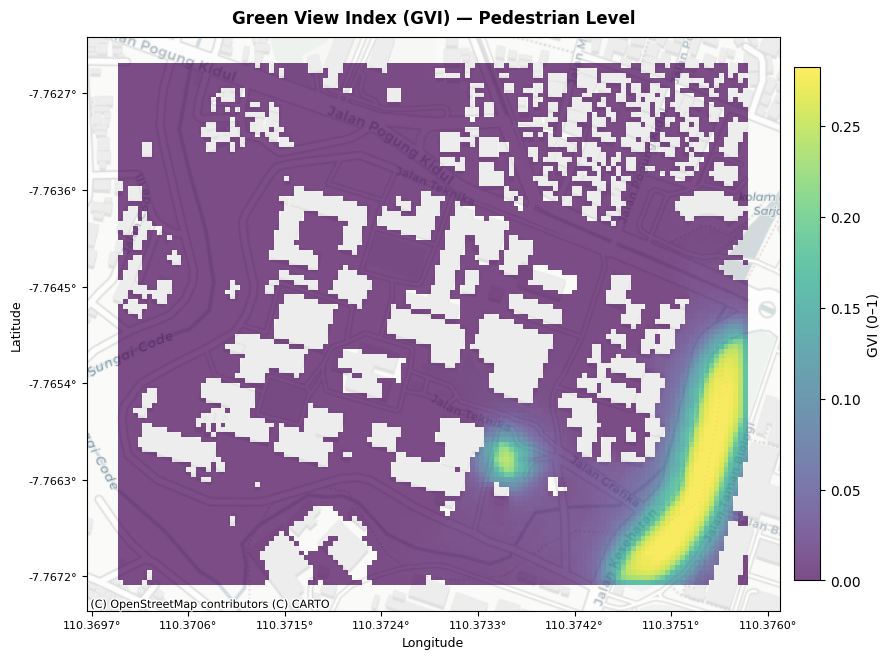

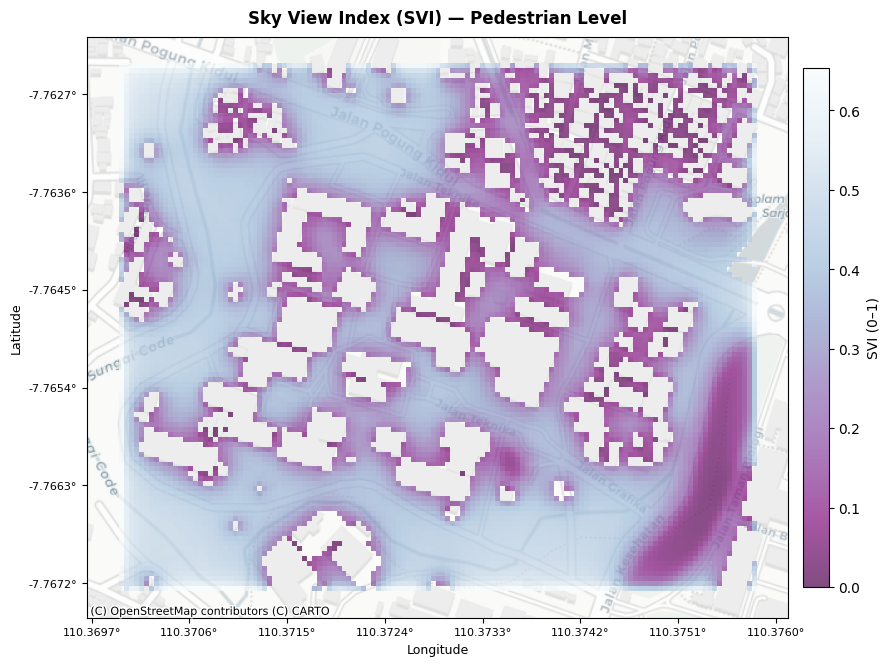


✅ GVI and SVI ready. Proceed to Section 2.2.2.


In [74]:
#@title 2.2.1 Ground Green View Index (GVI) and Sky View Index (SVI)
# ─────────────────────────────────────────────────────────────────
# GVI  = fraction of rays hitting vegetation voxels (codes -2,2,5–8)
#        weighted by Beer-Lambert canopy transmittance (k=0.5, LAD=1.0)
#        Equation:
#          GVI = (1/N) Σ [T_i · 1(ray_i hits vegetation)]
#          T_i = exp(-k · LAD · L_i)   [Beer-Lambert, tree voxels only]
#
# SVI  = fraction of rays escaping the grid without hitting any
#        opaque voxel (upper hemisphere, 0°→90° elevation)
#        Discrete approximation of the hemisphere integral:
#          SVF ≈ (1/N) Σ [T_i · 1(ray_i exits unblocked)]
#        (Full cosine-weighted form: SVF = (2/π)∫∫ V·cosθ·sinθ dφ dθ)
#
# Both computed at pedestrian height (1.5 m above ground surface).
# Ray sampling: grid (N_azimuth × N_elevation) or fibonacci sphere.
#
# USER DATA OVERRIDE:
#   Set USER_GVI_PATH / USER_SVI_PATH to load pre-computed .npy arrays
#   from Google Drive instead of re-running the simulator.
# ─────────────────────────────────────────────────────────────────

import os
import numpy as np
from IPython.display import display as _ipy_display

# ── VoxCity imports (self-contained, restart-safe) ───────────────
try:
    from voxcity.simulator.visibility.view import get_view_index
    from voxcity.visualizer import visualize_voxcity
except ImportError as _ie:
    raise ImportError(
        f"VoxCity import failed: {_ie}\n"
        "→ Re-run Cell 1.1 to reinstall voxcity, "
        "then restart the runtime."
    )

# ── Dependency guards ─────────────────────────────────────────────
for _req in ["RUN_VIEW", "OUTPUT_DIR", "print_stage",
             "safe_array", "array_summary_df",
             "_plot_grid_on_basemap", "_sanitize_grid_2d",
             "STATE"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.1, 1.6.1, and 2.0.1 first."
        )

# ── User-defined data paths (Google Drive override) ──────────────
USER_GVI_PATH = ""   # e.g. "/content/drive/MyDrive/project/gvi.npy"
USER_SVI_PATH = ""   # e.g. "/content/drive/MyDrive/project/svi.npy"

# ── Ray sampling parameters (advanced) ───────────────────────────
N_AZIMUTH       = 120     # azimuth directions
N_ELEVATION     = 20      # elevation bands
RAY_SAMPLING    = "grid"  # "grid" or "fibonacci"
VIEW_HEIGHT_M   = 1.5     # pedestrian eye height (metres)
TREE_K          = 0.5     # Beer-Lambert extinction coefficient (GVI)
TREE_LAD        = 1.0     # Leaf Area Density (m²/m³)

# ── State init ────────────────────────────────────────────────────
gvi_grid = gvi_arr = gvi_summary = None
svi_grid = svi_arr = svi_summary = None
_gvi_finite = _svi_finite = np.array([])   # safe defaults

# ── Resolve voxcity handle ────────────────────────────────────────
voxcity = globals().get(
    "voxcity", globals().get("voxcity_model", None)
)

if not RUN_VIEW:
    print("ℹ️  View index analysis skipped (RUN_VIEW = False).")

else:
    if voxcity is None:
        print("❌ Voxel city model not found. "
              "Run Section 1.6 first.")
    else:
        print_stage("GREEN VIEW INDEX + SKY VIEW INDEX (2.2.1)")

        # ══════════════════════════════════════════════════════════
        # ── GVI ───────────────────────────────────────────────────
        # ══════════════════════════════════════════════════════════
        if USER_GVI_PATH and os.path.isfile(USER_GVI_PATH):
            print(f"  📂 Loading GVI from: {USER_GVI_PATH}")
            gvi_grid = np.load(USER_GVI_PATH)
            print(f"     Shape: {gvi_grid.shape}  |  "
                  f"dtype: {gvi_grid.dtype}")
        else:
            if USER_GVI_PATH:
                print(f"  ⚠️  USER_GVI_PATH set but file not found: "
                      f"{USER_GVI_PATH}")
                print("      → Falling back to simulator.")

            print("  ⏳ Computing GVI (Green View Index)...")
            print(f"     Parameters: height={VIEW_HEIGHT_M}m | "
                  f"rays={N_AZIMUTH}×{N_ELEVATION} | "
                  f"sampling={RAY_SAMPLING} | "
                  f"k={TREE_K} | LAD={TREE_LAD}")

            try:
                gvi_grid = get_view_index(
                    voxcity,
                    mode              = "green",
                    view_point_height = VIEW_HEIGHT_M,
                    colormap          = "viridis",
                    N_azimuth         = N_AZIMUTH,
                    N_elevation       = N_ELEVATION,
                    ray_sampling      = RAY_SAMPLING,
                    tree_k            = TREE_K,
                    tree_lad          = TREE_LAD,
                    output_directory  = None,
                )
                _gvi_out = os.path.join(OUTPUT_DIR, "gvi.npy")
                np.save(_gvi_out, gvi_grid)
                print(f"  💾 GVI saved → {_gvi_out}")

            except Exception as _e:
                print(f"  ❌ GVI simulation failed:\n"
                      f"     {type(_e).__name__}: {_e}")
                gvi_grid = None

        # ══════════════════════════════════════════════════════════
        # ── SVI ───────────────────────────────────────────────────
        # ══════════════════════════════════════════════════════════
        if USER_SVI_PATH and os.path.isfile(USER_SVI_PATH):
            print(f"  📂 Loading SVI from: {USER_SVI_PATH}")
            svi_grid = np.load(USER_SVI_PATH)
            print(f"     Shape: {svi_grid.shape}  |  "
                  f"dtype: {svi_grid.dtype}")
        else:
            if USER_SVI_PATH:
                print(f"  ⚠️  USER_SVI_PATH set but file not found: "
                      f"{USER_SVI_PATH}")
                print("      → Falling back to simulator.")

            print("\n  ⏳ Computing SVI (Sky View Index)...")
            print(f"     Parameters: height={VIEW_HEIGHT_M}m | "
                  f"rays={N_AZIMUTH}×{N_ELEVATION} | "
                  f"sampling={RAY_SAMPLING}")
            print("     Note: mode='sky' uses upper hemisphere "
                  "(0°→90°) internally.")
            print("     Cosine-weighting not applied "
                  "(uniform ray sampling).")

            try:
                svi_grid = get_view_index(
                    voxcity,
                    mode              = "sky",
                    view_point_height = VIEW_HEIGHT_M,
                    colormap          = "BuPu_r",
                    N_azimuth         = N_AZIMUTH,
                    N_elevation       = N_ELEVATION,
                    ray_sampling      = RAY_SAMPLING,
                    output_directory  = None,
                )
                _svi_out = os.path.join(OUTPUT_DIR, "svi.npy")
                np.save(_svi_out, svi_grid)
                print(f"  💾 SVI saved → {_svi_out}")

            except Exception as _e:
                print(f"  ❌ SVI simulation failed:\n"
                      f"     {type(_e).__name__}: {_e}")
                svi_grid = None

        # ══════════════════════════════════════════════════════════
        # ── Statistics ────────────────────────────────────────────
        # ══════════════════════════════════════════════════════════
        gvi_arr = safe_array(gvi_grid, dtype=float)
        svi_arr = safe_array(svi_grid, dtype=float)

        gvi_summary = array_summary_df(
            gvi_arr, "Green View Index (GVI)"
        )
        svi_summary = array_summary_df(
            svi_arr, "Sky View Index (SVI)"
        )

        print("\n── GVI Summary ──")
        _ipy_display(gvi_summary)
        print("── SVI Summary ──")
        _ipy_display(svi_summary)

        # ── Urban quality thresholds ──────────────────────────────
        # WHY: _gvi_finite / _svi_finite initialised to empty array
        #      above so STATE sync below is always safe even if
        #      simulation failed.
        _gvi_finite = gvi_arr[np.isfinite(gvi_arr)]
        _svi_finite = svi_arr[np.isfinite(svi_arr)]

        if len(_gvi_finite) > 0:
            _gvi_mean = float(np.nanmean(_gvi_finite))
            _gvi_flag = (
                "🟢 Good (≥0.30)"
                if _gvi_mean >= 0.30 else
                "🟡 Moderate (0.15–0.30)"
                if _gvi_mean >= 0.15 else
                "🔴 Low (<0.15)"
            )
            print(f"\n  GVI mean = {_gvi_mean:.3f}  →  {_gvi_flag}")
            print("     Reference: Li et al. (2015) — "
                  "GVI ≥ 0.30 for liveable streets")

        if len(_svi_finite) > 0:
            _svi_mean = float(np.nanmean(_svi_finite))
            _svi_flag = (
                "🟢 Open sky (≥0.60)"
                if _svi_mean >= 0.60 else
                "🟡 Moderate (0.30–0.60)"
                if _svi_mean >= 0.30 else
                "🔴 Enclosed (<0.30) — Urban Heat Island risk"
            )
            print(f"  SVI mean = {_svi_mean:.3f}  →  {_svi_flag}")
            print("     Reference: Oke (1987) — "
                  "SVF < 0.30 strongly linked to UHI")

        # ══════════════════════════════════════════════════════════
        # ── Basemap visualization ─────────────────────────────────
        # ══════════════════════════════════════════════════════════
        _rv = None
        if isinstance(getattr(voxcity, "extras", None), dict):
            _rv = voxcity.extras.get("rectangle_vertices", None)

        if _rv is not None:
            print("\n  🗺️  Rendering basemap overlays...")
            try:
                _plot_grid_on_basemap(
                    _sanitize_grid_2d(gvi_arr),
                    _rv,
                    title      = "Green View Index (GVI) "
                                 "— Pedestrian Level",
                    cmap       = "viridis",
                    cbar_label = "GVI (0–1)",
                    alpha      = 0.70,
                )
                _plot_grid_on_basemap(
                    _sanitize_grid_2d(svi_arr),
                    _rv,
                    title      = "Sky View Index (SVI) "
                                 "— Pedestrian Level",
                    cmap       = "BuPu_r",
                    cbar_label = "SVI (0–1)",
                    alpha      = 0.70,
                )
            except Exception as _ve:
                print(f"  ⚠️  Basemap overlay failed: {_ve}")
                print("      → Raw arrays are still valid "
                      "for downstream analysis.")
        else:
            print("  ⚠️  rectangle_vertices not found — "
                  "skipping basemap overlay.")

        # ── STATE + REGISTRY + LOG sync ───────────────────────────
        # WHY: _gvi_finite / _svi_finite are guaranteed to be
        #      defined (initialised to empty array at top of block)
        #      so nanmean is safe even when simulation failed.
        STATE["gvi_grid"] = gvi_grid
        STATE["svi_grid"] = svi_grid
        STATE["gvi_mean"] = (
            float(np.nanmean(_gvi_finite))
            if len(_gvi_finite) > 0 else None
        )
        STATE["svi_mean"] = (
            float(np.nanmean(_svi_finite))
            if len(_svi_finite) > 0 else None
        )
        STATE["gvi_svi_done"] = (
            gvi_grid is not None and svi_grid is not None
        )

        if "DATA_REGISTRY" in globals():
            DATA_REGISTRY.setdefault("gvi_svi", {}).update({
                "status"  : (
                    "loaded"
                    if STATE["gvi_svi_done"]
                    else "partial"
                ),
                "gvi_mean": STATE["gvi_mean"],
                "svi_mean": STATE["svi_mean"],
            })

        if "log_event" in globals():
            log_event(
                module = "2.2.1 GVI + SVI",
                status = (
                    "complete"
                    if STATE["gvi_svi_done"]
                    else "partial"
                ),
                detail = (
                    f"gvi_mean={STATE['gvi_mean']}, "
                    f"svi_mean={STATE['svi_mean']}, "
                    f"rays={N_AZIMUTH}×{N_ELEVATION}"
                )
            )

        print("\n✅ GVI and SVI ready. Proceed to Section 2.2.2.")

In [32]:
#@title 2.2.2. Green View Index (GVI) on Building Surfaces
# ─────────────────────────────────────────────────────────────────
# Computes GVI on every exposed building façade face using
# cosine-weighted hemisphere ray casting, then renders a 3D
# interactive mesh where each face is coloured by GVI value.
#
# Pipeline (confirmed from VoxCity source):
#   get_surface_view_factor(voxcity, target_values, inclusion_mode)
#     → returns trimesh.Trimesh
#     → values stored in mesh.metadata['view_factor_values']
#   visualize_voxcity(voxcity,
#     building_sim_mesh  = <that trimesh>,
#     building_value_name= 'view_factor_values')
#     → reads mesh.metadata['view_factor_values'] for face colours
#
# Vegetation codes (inclusion_mode=True → count hits on these):
#   -2 = tree canopy    5 = tree (ground class)
#    2 = rangeland      6 = moss / lichen
#    3 = shrub          7 = wetland
#    4 = agriculture    8 = mangrove
#
# building_vmax=0.2: in dense urban areas, 20% green façade view
# is already high. Values above are clipped to top colormap color.
# ─────────────────────────────────────────────────────────────────

import time
import numpy as np

# ── VoxCity imports (self-contained, restart-safe) ───────────────
try:
    from voxcity.simulator.visibility.view import get_surface_view_factor
    from voxcity.visualizer import visualize_voxcity
except ImportError as _ie:
    raise ImportError(
        f"VoxCity import failed: {_ie}\n"
        "→ Re-run Cell 1.1 to reinstall voxcity, "
        "then restart the runtime."
    )

# ── Dependency guards ─────────────────────────────────────────────
for _req in ["RUN_VIEW", "voxcity", "print_stage",
             "DOWNSAMPLE_VIS", "STATE"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.1, 1.6.1, and 2.2.1 first."
        )

# ── Dependency guards ─────────────────────────────────────────────
for _req in ["RUN_VIEW", "voxcity", "print_stage",
             "DOWNSAMPLE_VIS", "get_surface_view_factor",
             "visualize_voxcity", "STATE"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.1, 1.6.1, and 2.2.1 first."
        )

building_gvi_mesh = None

if not RUN_VIEW:
    print("ℹ️  Building GVI skipped (RUN_VIEW = False).")

else:
    if voxcity is None:
        print("❌ Voxel city model not found. "
              "Run Section 1.6 first.")
    else:
        print_stage("GVI — BUILDING SURFACES (2.2.2)")
        print("  Method  : Surface view factor via ray-casting")
        print("  Targets : Tree canopy + all vegetation "
              "land-cover classes")
        print("  Mode    : inclusion_mode=True "
              "(green voxels counted)")
        print("\n  ⏳ Running... progress reported below.\n")

        _t0 = time.time()

        # ── VoxCity API call ──────────────────────────────────────
        # get_surface_view_factor() internally:
        #   1. Calls create_sim_surface_mesh() to build exposed faces
        #   2. Ray-casts from each face centroid along face normal
        #   3. Stores per-face values in
        #      mesh.metadata['view_factor_values']
        #   4. Returns the trimesh.Trimesh object
        try:
            building_gvi_mesh = get_surface_view_factor(
                voxcity,
                target_values   = (-2, 2, 3, 4, 5, 6, 7, 8),
                inclusion_mode  = True,
                progress_report = True,
            )
        except Exception as _e:
            print(f"❌ get_surface_view_factor() failed: "
                  f"{type(_e).__name__}: {_e}")
            building_gvi_mesh = None

        _elapsed = round(time.time() - _t0, 1)

        if building_gvi_mesh is None:
            print("❌ Building GVI mesh returned None.")
            print("   → Possible causes:")
            print("      • No building voxels (class -3) "
                  "in the model")
            print("      • No vegetation voxels present in the AOI")
            print("      • Re-run Section 1.6 and verify "
                  "land cover data")

            STATE["building_gvi_done"] = False
            if "log_event" in globals():
                log_event(
                    module = "2.2.2 Building GVI",
                    status = "failed",
                    detail = "building_gvi_mesh is None"
                )

        else:
            print(f"\n  ✅ Mesh computed in {_elapsed}s.")

            # ── Statistics from mesh.metadata ─────────────────────
            _gvi_mean_surface = None
            try:
                _vf_vals = np.array(
                    building_gvi_mesh.metadata.get(
                        "view_factor_values", []
                    ),
                    dtype=float
                )
                _valid = _vf_vals[np.isfinite(_vf_vals)]

                if len(_valid) > 0:
                    _gvi_mean_surface = float(np.mean(_valid))
                    print(f"\n  📊 Surface GVI statistics:")
                    print(f"     Faces computed : {len(_valid):,}")
                    print(f"     Mean GVI       : "
                          f"{_gvi_mean_surface:.3f}")
                    print(f"     Median GVI     : "
                          f"{np.median(_valid):.3f}")
                    print(f"     P95 GVI        : "
                          f"{np.percentile(_valid, 95):.3f}")
                    print(f"     Max GVI        : "
                          f"{np.max(_valid):.3f}")
                    print(f"     Faces > 0.20   : "
                          f"{np.sum(_valid > 0.20):,} "
                          f"({100*np.mean(_valid > 0.20):.1f}%"
                          f" — high green view)")

                    _flag = (
                        "🟢 Good green exposure (≥0.15)"
                        if _gvi_mean_surface >= 0.15 else
                        "🟡 Moderate (0.05–0.15)"
                        if _gvi_mean_surface >= 0.05 else
                        "🔴 Low green exposure (<0.05)"
                    )
                    print(f"     Assessment     : {_flag}")

            except Exception as _se:
                print(f"  ⚠️  Could not read mesh statistics: {_se}")
                _gvi_mean_surface = None

            print("\n  Rendering 3D visualization...\n")

            # ── 3D Visualization ──────────────────────────────────
            try:
                visualize_voxcity(
                    voxcity,
                    building_sim_mesh      = building_gvi_mesh,
                    building_value_name    = "view_factor_values",
                    building_colormap      = "viridis",
                    building_opacity       = 1.0,
                    building_vmin          = 0.0,
                    building_vmax          = 0.2,
                    render_voxel_buildings = False,
                    voxel_color_map        = "grayscale",
                    downsample             = DOWNSAMPLE_VIS,
                )
            except Exception as _ve:
                print(f"⚠️  3D viewer failed: {_ve}")
                print("   → Mesh data is still valid and "
                      "will be exported.")
                print("   → Check that xvfb is running "
                      "(re-run Section 1.1 if needed).")

            # ── STATE + REGISTRY + LOG sync ───────────────────────
            STATE["building_gvi_done"] = True
            STATE["building_gvi_mesh"] = building_gvi_mesh
            STATE["building_gvi_mean"] = _gvi_mean_surface

            if "DATA_REGISTRY" in globals():
                DATA_REGISTRY.setdefault(
                    "building_gvi", {}
                ).update({
                    "status"    : "loaded",
                    "source"    : "VoxCity surface view factor",
                    "gvi_mean"  : _gvi_mean_surface,
                    "elapsed_s" : _elapsed,
                })

            if "log_event" in globals():
                log_event(
                    module = "2.2.2 Building GVI",
                    status = "complete",
                    detail = (
                        f"elapsed={_elapsed}s, "
                        f"gvi_mean={_gvi_mean_surface}"
                    )
                )

            print(f"\n✅ Building GVI mesh ready. "
                  f"({_elapsed}s) Proceed to Section 2.3.")

Output hidden; open in https://colab.research.google.com to view.

### 2.2 (Add-ons) Thermal Stress Index

In [33]:
# Thermal Stress Proxy Index
# ─────────────────────────────────────────────────────────────────
# Builds a thermal stress screening index from available rasters.
#
# Formula (weighted composite):
#
#   T(x,y) = 0.50 · norm(Solar(x,y))
#           + 0.30 · (1 − norm(SVI(x,y)))
#           + 0.20 · (1 − norm(GVI(x,y)))
#
# Rationale:
#   • High solar irradiance     → more radiant heat load  (+)
#   • Low sky view (enclosed)   → less sky cooling        (+)
#   • Low green view            → less evapotranspiration (+)
#
# Each inverted term is NOT re-normalised after inversion.
# WHY: norm(1 − norm(x)) destroys relative magnitude — the
#      already-[0,1] inversion is re-scaled to [0,1] again,
#      making all layers identical in range regardless of spread.
#      The correct form is simply (1 − norm(x)).
#
# Output range: 0 (low thermal stress) → 1 (high thermal stress)
#
# Requirements: at least one of solar_arr, svi_arr, gvi_arr
# must be available. Missing layers are excluded from the
# composite and weights are redistributed automatically.
# ─────────────────────────────────────────────────────────────────

import time
import numpy as np
import pandas as pd
from IPython.display import display

thermal_proxy   = None
thermal_summary = None

# Guard: RUN_THERMAL_PROXY may not be defined if Section 1.4.1
# was skipped. Default to True so this cell always runs standalone.
RUN_THERMAL_PROXY = globals().get("RUN_THERMAL_PROXY", True)

if not RUN_THERMAL_PROXY:
    print("ℹ️  Thermal proxy skipped "
          "(RUN_THERMAL_PROXY = False).")

else:
    print("=" * 70)
    print("  THERMAL STRESS PROXY INDEX (2.5)")
    print("=" * 70)
    _t0 = time.time()

    # ── Collect available input arrays ───────────────────────────
    _inputs = {}

    _s = globals().get("solar_arr")
    if _s is not None and not np.isnan(
            np.asarray(_s, float)).all():
        _inputs["solar"] = np.asarray(_s, dtype=np.float64)
        print("  ✅ solar_arr available")
    else:
        print("  ⬜ solar_arr not available — "
              "excluded from composite")

    _g = globals().get("gvi_arr")
    if _g is not None and not np.isnan(
            np.asarray(_g, float)).all():
        _inputs["gvi"] = np.asarray(_g, dtype=np.float64)
        print("  ✅ gvi_arr available")
    else:
        print("  ⬜ gvi_arr not available — "
              "excluded from composite")

    _sv = globals().get("svi_arr")
    if _sv is not None and not np.isnan(
            np.asarray(_sv, float)).all():
        _inputs["svi"] = np.asarray(_sv, dtype=np.float64)
        print("  ✅ svi_arr available")
    else:
        print("  ⬜ svi_arr not available — "
              "excluded from composite")

    if not _inputs:
        print("\n❌ No input arrays available.")
        print("   Run at least one of: Section 2.1.1 (Solar) or "
              "Section 2.2.1 (GVI/SVI) first.")

        if "STATE" in globals():
            STATE["thermal_proxy_done"] = False
        if "log_event" in globals():
            log_event(
                module = "2.5 Thermal Proxy",
                status = "failed",
                detail = "no input arrays available"
            )

    else:
        # ── Normalise helper ──────────────────────────────────────
        def _norm2d(arr: np.ndarray) -> np.ndarray:
            """
            Min-max normalise a 2D array to [0, 1], NaN-safe.
            Returns zeros if array is spatially constant.
            """
            _lo = np.nanmin(arr)
            _hi = np.nanmax(arr)
            if np.isclose(_lo, _hi):
                return np.zeros_like(arr)
            return (arr - _lo) / (_hi - _lo + 1e-9)

        # ── Align all arrays to the same shape ───────────────────
        from scipy.ndimage import zoom as _zoom

        _ref_shape = next(iter(_inputs.values())).shape
        _aligned   = {}

        for _k, _a in _inputs.items():
            if _a.shape == _ref_shape:
                _aligned[_k] = _a
            else:
                _zy = _ref_shape[0] / _a.shape[0]
                _zx = _ref_shape[1] / _a.shape[1]
                _aligned[_k] = _zoom(
                    _a, (_zy, _zx), order=1, mode="nearest"
                )
                print(f"  🔄 '{_k}': resized "
                      f"{_a.shape} → {_aligned[_k].shape}")

        # ── Weighted composite ────────────────────────────────────
        # Base weights — redistributed if a layer is missing.
        _base_weights = {"solar": 0.50, "svi": 0.30, "gvi": 0.20}
        _avail_keys   = list(_aligned.keys())
        _raw_weights  = {
            k: _base_weights[k]
            for k in _avail_keys if k in _base_weights
        }
        _total_w = sum(_raw_weights.values())

        # Renormalise weights to sum to 1.0
        _weights = {
            k: v / _total_w for k, v in _raw_weights.items()
        }

        print(f"\n  Composite weights (redistributed):")
        for _k, _w in _weights.items():
            print(f"    {_k:<8} : {_w:.3f}")

        # Build composite on the reference shape
        _composite = np.zeros(_ref_shape, dtype=np.float64)
        _nan_mask  = np.zeros(_ref_shape, dtype=bool)

        for _k, _w in _weights.items():
            _layer = _aligned[_k]
            _nan_mask |= np.isnan(_layer)

            if _k == "solar":
                # Higher solar → higher stress
                _composite += _w * _norm2d(_layer)
            elif _k == "svi":
                # Lower sky view → higher stress
                # WHY: (1 − norm(x)) not norm(1 − norm(x))
                # Re-normalising an already-[0,1] inversion
                # destroys relative magnitude information.
                _composite += _w * (1.0 - _norm2d(_layer))
            elif _k == "gvi":
                # Lower green view → higher stress
                _composite += _w * (1.0 - _norm2d(_layer))

        # Propagate NaN where any input was NaN
        _composite[_nan_mask] = np.nan

        thermal_proxy = _composite.astype(np.float32)

        # ── Summary ───────────────────────────────────────────────
        _elapsed  = round(time.time() - _t0, 1)
        _valid    = int(np.sum(~np.isnan(thermal_proxy)))
        _total    = thermal_proxy.size
        _pct      = round(100 * _valid / _total, 1)
        _mean_val = round(float(np.nanmean(thermal_proxy)), 3)
        _min_val  = round(float(np.nanmin(thermal_proxy)),  3)
        _max_val  = round(float(np.nanmax(thermal_proxy)),  3)

        thermal_summary = pd.DataFrame([
            {"metric": "Shape (rows × cols)",
             "value": (f"{thermal_proxy.shape[0]} × "
                       f"{thermal_proxy.shape[1]}")},
            {"metric": "Input layers used",
             "value": ", ".join(_avail_keys)},
            {"metric": "Valid cells (%)",
             "value": _pct},
            {"metric": "Min value",
             "value": _min_val},
            {"metric": "Mean value",
             "value": _mean_val},
            {"metric": "Max value",
             "value": _max_val},
            {"metric": "Elapsed time (s)",
             "value": _elapsed},
        ])
        display(thermal_summary)

        _stress_label = (
            "low"      if _mean_val < 0.33 else
            "moderate" if _mean_val < 0.66 else
            "high"
        )
        print(f"\n  📊 Mean thermal stress = {_mean_val:.3f} — "
              f"{_stress_label} stress across AOI.")

        # ── STATE + REGISTRY + LOG sync ───────────────────────────
        if "STATE" in globals():
            STATE["thermal_proxy_done"] = True
            STATE["thermal_proxy"]      = thermal_proxy
            STATE["thermal_mean"]       = _mean_val

        if "DATA_REGISTRY" in globals():
            DATA_REGISTRY.setdefault(
                "thermal_proxy", {}
            ).update({
                "status"      : "loaded",
                "source"      : "composite proxy",
                "layers_used" : _avail_keys,
                "mean"        : _mean_val,
            })

        if "log_event" in globals():
            log_event(
                module = "2.5 Thermal Proxy",
                status = "complete",
                detail = (
                    f"layers={_avail_keys}, "
                    f"mean={_mean_val}, "
                    f"elapsed={_elapsed}s"
                )
            )

        print(f"\n✅ Thermal proxy ready. ({_elapsed}s) "
              f"Proceed to Section 3.1.")

  THERMAL STRESS PROXY INDEX (2.5)
  ⬜ solar_arr not available — excluded from composite
  ✅ gvi_arr available
  ✅ svi_arr available

  Composite weights (redistributed):
    gvi      : 0.400
    svi      : 0.600


,metric,value
0,Shape (rows × cols),106 × 129
1,Input layers used,"gvi, svi"
2,Valid cells (%),74.9
3,Min value,0.4
4,Mean value,0.747
5,Max value,1.0
6,Elapsed time (s),0.0



  📊 Mean thermal stress = 0.747 — high stress across AOI.

✅ Thermal proxy ready. (0.0s) Proceed to Section 3.1.


### 2.3. Network (Walkability) and Space Syntax Analysis

In [35]:
#@title 2.3.1 Download Pedestrian Network and OSM Features
# ─────────────────────────────────────────────────────────────────
# Downloads the walking street network and points of interest
# from OpenStreetMap. This data feeds three downstream analyses:
#
#   • Walkability Index    (Section 2.3.2)
#   • Street Integration   (Section 2.3.3)
#   • Wind Corridor        (Section 2.4)
#
# Graph structure:
#   G = (V, E)
#   V = street intersections (nodes)
#   E = street segments (edges, with length in metres)
#
#   Mean node degree:
#   d̄ = (1/|V|) × Σ deg(v)   for all v ∈ V
#
#   Interpretation:
#   d̄ ≈ 2.0  → mostly dead-ends / linear streets
#   d̄ ≈ 3.0  → typical urban grid with T-intersections
#   d̄ ≥ 4.0  → dense grid, many 4-way intersections
#
# Proximity distances (used in 2.3.2):
#   d_amenity(v) = min over a in A of ||p_v - p_a||
#   Requires metric CRS (EPSG:3857) for distances in metres.
#
# Built obstruction (used in 2.4):
#   Buffer each edge by ROAD_BUFFER_M metres, intersect with
#   buildings_osm to compute obstruction ratio per street.
#
# CRS NOTE (OSMnx ≥ 2.0):
#   graph_to_gdfs() already returns EPSG:4326 — use to_crs(),
#   NOT set_crs(allow_override=True). The latter silently relabels
#   the CRS without reprojecting, corrupting distance calculations.
#
# USER DATA OVERRIDE:
#   Set USER_NETWORK_PATH to a saved .gpkg to skip re-downloading.
#   Format: saved by this cell via to_file(..., driver="GPKG")
# ─────────────────────────────────────────────────────────────────

import os
import time
import pandas as pd
import geopandas as gpd

# ── Dependency guards ─────────────────────────────────────────────
for _req in ["aoi_polygon", "print_stage", "OUTPUT_DIR",
             "ox", "safe_features_from_polygon", "STATE"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.1, 1.5.4, and 2.0.1 first."
        )

# ── Run-flag defaults (safe if upstream config was skipped) ───────
RUN_WALKABILITY    = globals().get("RUN_WALKABILITY",    True)
RUN_INTEGRATION    = globals().get("RUN_INTEGRATION",    True)
RUN_WIND_SCREENING = globals().get("RUN_WIND_SCREENING", True)

# ── User-defined Drive override paths ────────────────────────────
USER_NETWORK_NODES_PATH = ""
USER_NETWORK_EDGES_PATH = ""
USER_AMENITIES_PATH     = ""
USER_GREEN_PATH         = ""
USER_BUILDINGS_PATH     = ""

# ── Reset all outputs ─────────────────────────────────────────────
walk_G          = None
walk_nodes      = None
walk_edges      = None
walk_nodes_proj = None
walk_edges_proj = None
amenities       = None
green_areas     = None
buildings_osm   = None

if not (RUN_WALKABILITY or RUN_INTEGRATION or RUN_WIND_SCREENING):
    print("ℹ️  OSM download skipped "
          "(Walkability, Integration, and Wind are all disabled).")

else:
    if aoi_polygon is None:
        print("❌ AOI not defined. Run Section 1.5 first.")
    else:
        print_stage(
            "DOWNLOADING OSM NETWORK AND FEATURES (2.3.1)"
        )
        _t0 = time.time()

        # ══════════════════════════════════════════════════════════
        # ── Step 1: Pedestrian street network ─────────────────────
        # ══════════════════════════════════════════════════════════
        _nodes_loaded = _edges_loaded = False

        if USER_NETWORK_NODES_PATH and USER_NETWORK_EDGES_PATH:
            _np = USER_NETWORK_NODES_PATH
            _ep = USER_NETWORK_EDGES_PATH
            if os.path.isfile(_np) and os.path.isfile(_ep):
                print("  📂 Loading network from Drive...")
                try:
                    walk_nodes = gpd.read_file(_np).to_crs(4326)
                    walk_edges = gpd.read_file(_ep).to_crs(4326)

                    if not isinstance(
                        walk_edges.index, pd.MultiIndex
                    ):
                        _idx_cols = [
                            c for c in ["u", "v", "key"]
                            if c in walk_edges.columns
                        ]
                        if len(_idx_cols) == 3:
                            walk_edges = walk_edges.set_index(
                                _idx_cols
                            )

                    walk_nodes_proj = walk_nodes.to_crs(3857)
                    walk_edges_proj = walk_edges.to_crs(3857)
                    _nodes_loaded = _edges_loaded = True
                    print(f"  ✅ Network loaded from Drive — "
                          f"{len(walk_nodes):,} nodes, "
                          f"{len(walk_edges):,} edges")

                    try:
                        walk_G = ox.convert.graph_from_gdfs(
                            walk_nodes, walk_edges
                        )
                        print("  ✅ NetworkX graph reconstructed "
                              "from loaded GDFs")
                    except Exception as _ge:
                        print(f"  ⚠️  Graph reconstruction "
                              f"failed: {_ge}")
                        print("     → Centrality metrics in 2.3.3 "
                              "may be unavailable.")
                        walk_G = None

                except Exception as _le:
                    print(f"  ⚠️  Drive load failed: {_le} "
                          f"→ Falling back to OSM download.")
                    _nodes_loaded = _edges_loaded = False
            else:
                print("  ⚠️  Network files not found at specified "
                      "paths → Downloading from OSM.")

        if not (_nodes_loaded and _edges_loaded):
            print("  ⬇️  Fetching pedestrian network from OSM...")
            try:
                walk_G = ox.graph_from_polygon(
                    aoi_polygon,
                    network_type = "walk",
                    simplify     = True
                )

                # ✅ OSMnx ≥ 2.0: graph_to_gdfs() returns EPSG:4326
                # Use to_crs() — NOT set_crs(allow_override=True).
                walk_nodes, walk_edges = ox.graph_to_gdfs(
                    walk_G, nodes=True, edges=True
                )
                walk_nodes = walk_nodes.to_crs(4326)
                walk_edges = walk_edges.to_crs(4326)

                walk_nodes_proj = walk_nodes.to_crs(3857)
                walk_edges_proj = walk_edges.to_crs(3857)

                print(f"  ✅ Network downloaded — "
                      f"{len(walk_nodes):,} nodes, "
                      f"{len(walk_edges):,} edges")

                try:
                    _nodes_save = os.path.join(
                        OUTPUT_DIR, "walk_nodes.gpkg"
                    )
                    _edges_save = os.path.join(
                        OUTPUT_DIR, "walk_edges.gpkg"
                    )
                    walk_nodes.to_file(
                        _nodes_save, driver="GPKG"
                    )
                    walk_edges.reset_index().to_file(
                        _edges_save, driver="GPKG"
                    )
                    print(f"  💾 Network auto-saved → "
                          f"{OUTPUT_DIR}")
                    print(f"     (Set USER_NETWORK_NODES_PATH"
                          f" = '{_nodes_save}')")
                    print(f"     (Set USER_NETWORK_EDGES_PATH"
                          f" = '{_edges_save}')")
                except Exception as _se:
                    print(f"  ⚠️  Auto-save failed: {_se} "
                          f"— data still valid in memory.")

            except Exception as _ne:
                print(f"  ❌ Network download failed: {_ne}")
                print("     → Check internet connection "
                      "and AOI validity.")
                print("     → AOI may be too small or in an area "
                      "with no OSM data.")

        # ══════════════════════════════════════════════════════════
        # ── Step 2: OSM feature layers ────────────────────────────
        # ══════════════════════════════════════════════════════════
        print("\n  ⬇️  Fetching OSM feature layers...")

        # ── Amenities ─────────────────────────────────────────────
        if (USER_AMENITIES_PATH
                and os.path.isfile(USER_AMENITIES_PATH)):
            try:
                amenities = gpd.read_file(
                    USER_AMENITIES_PATH
                ).to_crs(4326)
                print(f"  📂 Amenities loaded from Drive "
                      f"({len(amenities):,} features)")
            except Exception as _ae:
                print(f"  ⚠️  Amenities load failed: {_ae} "
                      f"→ Downloading from OSM.")
                amenities = None

        if amenities is None:
            amenities = safe_features_from_polygon(
                aoi_polygon,
                {"amenity": True, "shop": True,
                 "public_transport": True}
            )
            if amenities is not None and not amenities.empty:
                try:
                    amenities.to_file(
                        os.path.join(
                            OUTPUT_DIR, "amenities.gpkg"
                        ),
                        driver="GPKG"
                    )
                except Exception:
                    pass

        # ── Green areas ───────────────────────────────────────────
        if USER_GREEN_PATH and os.path.isfile(USER_GREEN_PATH):
            try:
                green_areas = gpd.read_file(
                    USER_GREEN_PATH
                ).to_crs(4326)
                print(f"  📂 Green areas loaded from Drive "
                      f"({len(green_areas):,} features)")
            except Exception as _gre:
                print(f"  ⚠️  Green areas load failed: {_gre} "
                      f"→ Downloading from OSM.")
                green_areas = None

        if green_areas is None:
            green_areas = safe_features_from_polygon(
                aoi_polygon,
                {
                    "leisure": ["park", "garden"],
                    "landuse": ["grass", "recreation_ground"],
                    "natural": ["wood"]
                }
            )
            if green_areas is not None and not green_areas.empty:
                try:
                    green_areas.to_file(
                        os.path.join(
                            OUTPUT_DIR, "green_areas.gpkg"
                        ),
                        driver="GPKG"
                    )
                except Exception:
                    pass

        # ── Buildings ─────────────────────────────────────────────
        if (USER_BUILDINGS_PATH
                and os.path.isfile(USER_BUILDINGS_PATH)):
            try:
                buildings_osm = gpd.read_file(
                    USER_BUILDINGS_PATH
                ).to_crs(4326)
                print(f"  📂 Buildings loaded from Drive "
                      f"({len(buildings_osm):,} features)")
            except Exception as _be:
                print(f"  ⚠️  Buildings load failed: {_be} "
                      f"→ Downloading from OSM.")
                buildings_osm = None

        if buildings_osm is None:
            buildings_osm = safe_features_from_polygon(
                aoi_polygon, {"building": True}
            )
            if (buildings_osm is not None
                    and not buildings_osm.empty):
                try:
                    buildings_osm.to_file(
                        os.path.join(
                            OUTPUT_DIR, "buildings_osm.gpkg"
                        ),
                        driver="GPKG"
                    )
                except Exception:
                    pass

        _elapsed = round(time.time() - _t0, 1)

        # ══════════════════════════════════════════════════════════
        # ── Step 3: Summary ───────────────────────────────────────
        # ══════════════════════════════════════════════════════════
        if walk_nodes is not None and walk_edges is not None:
            _n_nodes = len(walk_nodes)
            _n_edges = len(walk_edges)

            # ── Graph-level stats ─────────────────────────────────
            # WHY: summarize_graph() does not exist in osmnx or any
            #      standard library — replaced with ox.stats.basic_stats()
            #      which is the correct osmnx API call.
            if walk_G is not None:
                try:
                    _stats   = ox.stats.basic_stats(walk_G)
                    _avg_deg = round(
                        float(_stats.get(
                            "streets_per_node_avg",
                            _stats.get("avg_degree", 0.0)
                        )), 3
                    )
                    _len_km  = round(
                        float(_stats.get(
                            "street_length_total", 0.0
                        )) / 1000, 3
                    )
                except Exception as _st_e:
                    print(f"  ⚠️  ox.stats.basic_stats failed: "
                          f"{_st_e} — using edge-based fallback.")
                    _avg_deg = None
                    _len_km  = None
            else:
                _avg_deg = None
                _len_km  = None

            # Fallback: compute from edge endpoints directly
            if _avg_deg is None:
                _all_nodes = pd.concat([
                    walk_edges.reset_index()["u"],
                    walk_edges.reset_index()["v"]
                ])
                _avg_deg = round(
                    float(_all_nodes.value_counts().mean()), 3
                )
            if _len_km is None and walk_edges_proj is not None:
                _len_km = round(
                    float(
                        walk_edges_proj.geometry.length.sum()
                        / 1000
                    ), 3
                )

            _deg_label = (
                "dense grid"
                if _avg_deg >= 3.5 else
                "typical urban"
                if _avg_deg >= 2.5 else
                "sparse / linear"
            )

            print(f"\n{'─' * 50}")
            print(f"  Network nodes        : {_n_nodes:,}")
            print(f"  Network edges        : {_n_edges:,}")
            print(f"  Avg node degree (d̄) : "
                  f"{_avg_deg}  ({_deg_label})")
            print(f"  Total network length : {_len_km} km")
            print(f"{'─' * 50}")

            _n_amenities = (
                len(amenities)    if amenities    is not None
                else 0
            )
            _n_green = (
                len(green_areas)  if green_areas  is not None
                else 0
            )
            _n_bldg = (
                len(buildings_osm) if buildings_osm is not None
                else 0
            )

            print(
                f"  Amenities found      : {_n_amenities:,}"
                + ("  ⚠️  Low — may reduce walkability accuracy"
                   if _n_amenities < 10 else "")
            )
            print(
                f"  Green features       : {_n_green:,}"
                + ("  ⚠️  None — green access score will use "
                   "max distance cap"
                   if _n_green == 0 else "")
            )
            print(
                f"  Buildings (OSM)      : {_n_bldg:,}"
                + ("  ⚠️  None — wind obstruction ratio will be 0"
                   if _n_bldg == 0 else "")
            )
            print(f"{'─' * 50}")

            # ── STATE + REGISTRY + LOG sync ───────────────────────
            STATE["walk_G"]          = walk_G
            STATE["walk_nodes"]      = walk_nodes
            STATE["walk_edges"]      = walk_edges
            STATE["osm_network_done"] = True
            STATE["n_nodes"]         = _n_nodes
            STATE["n_edges"]         = _n_edges
            STATE["avg_degree"]      = _avg_deg

            if "DATA_REGISTRY" in globals():
                DATA_REGISTRY.setdefault(
                    "osm_network", {}
                ).update({
                    "status"     : "loaded",
                    "n_nodes"    : _n_nodes,
                    "n_edges"    : _n_edges,
                    "n_amenities": _n_amenities,
                    "n_green"    : _n_green,
                    "n_buildings": _n_bldg,
                    "elapsed_s"  : _elapsed,
                })

            if "log_event" in globals():
                log_event(
                    module = "2.3.1 OSM Network",
                    status = "complete",
                    detail = (
                        f"nodes={_n_nodes}, edges={_n_edges}, "
                        f"amenities={_n_amenities}, "
                        f"green={_n_green}, "
                        f"elapsed={_elapsed}s"
                    )
                )

            print(f"\n✅ OSM data ready. ({_elapsed}s) "
                  f"Proceed to Section 2.3.2.")

        else:
            print("\n❌ Network unavailable — dependent analyses "
                  "will be skipped.")
            print("   Walkability, Integration, and Wind modules "
                  "require this data.")

            STATE["osm_network_done"] = False
            if "log_event" in globals():
                log_event(
                    module = "2.3.1 OSM Network",
                    status = "failed",
                    detail = "walk_nodes or walk_edges is None"
                )


═══════════════════════════════════════════════════════
  🔷 DOWNLOADING OSM NETWORK AND FEATURES (2.3.1)
═══════════════════════════════════════════════════════
  ⬇️  Fetching pedestrian network from OSM...
  ✅ Network downloaded — 66 nodes, 156 edges
  💾 Network auto-saved → /content/drive/MyDrive/UrbanVox_Advanced_Output
     (Set USER_NETWORK_NODES_PATH = '/content/drive/MyDrive/UrbanVox_Advanced_Output/walk_nodes.gpkg')
     (Set USER_NETWORK_EDGES_PATH = '/content/drive/MyDrive/UrbanVox_Advanced_Output/walk_edges.gpkg')

  ⬇️  Fetching OSM feature layers...

──────────────────────────────────────────────────
  Network nodes        : 66
  Network edges        : 156
  Avg node degree (d̄) : 2.424  (sparse / linear)
  Total network length : 3.639 km
──────────────────────────────────────────────────
  Amenities found      : 29
  Green features       : 10
  Buildings (OSM)      : 297
──────────────────────────────────────────────────

✅ OSM data ready. (8.8s) Proceed to Section 2.3.2

In [36]:
#@title 2.3.2 Walkability Index
# ─────────────────────────────────────────────────────────────────
# Scores each street segment for pedestrian walkability based on
# five indicators. Each indicator is normalised to [0, 1] before
# weighting. The composite formula is:
#
#   W(e) = 0.25·C + 0.25·L + 0.25·A + 0.15·G + 0.10·I
#
# Where:
#   C = Connectivity score (normalised node degree)
#         C(e) = [minmax_norm(deg(u)) + minmax_norm(deg(v))] / 2
#
#   L = Segment length score (inverted, capped at L_ref = 150 m)
#         L(e) = 1 - min(length_e, L_ref) / L_ref
#         → segments ≥ 150 m always score 0 (not walkable length)
#         → avoids global-range distortion in sparse AOIs
#         Reference: Stutz et al. (2025), Sustainability 17(8):3634
#
#   A = Amenity access score (inverted normalised proximity, 2000m cap)
#         A(v) = 1 - minmax_norm(d_amenity(v))
#
#   G = Green access score (inverted normalised proximity, 2000m cap)
#         G(v) = 1 - minmax_norm(d_green(v))
#
#   I = Intersection density score (normalised per-AOI density)
#         ρ_int = |{v ∈ V : deg(v) ≥ 3}| / A_AOI   [intersections/km²]
#         I(e) = minmax_norm(deg(v))  [edge-level proxy]
#         Reference: Jeong et al. (2023), Sci Rep 13:16183
#
# Weights rationale (consistent with EPA NWI + Stutz 2025):
#   25% Connectivity  — network structure is the primary enabler
#   25% Length        — segment scale directly affects comfort
#   25% Amenity       — destination accessibility (EPA "D3")
#   15% Green access  — environmental quality
#   10% Intersection  — choice / permeability (density proxy)
#
# Score range: 0 (very low walkability) → 1 (very high walkability)
# ─────────────────────────────────────────────────────────────────

import os
import time
import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
from IPython.display import display

# ── Dependency guards ─────────────────────────────────────────────
for _req in ["print_stage", "OUTPUT_DIR", "ox",
             "aoi_polygon", "aoi_gdf",
             "walk_nodes_proj", "walk_edges_proj",
             "polygon_area_km2", "minmax_norm",
             "nearest_distance_clean", "make_line_map",
             "STATE"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.1, 2.0.1, and 2.3.1 first."
        )

# ── Run-flag defaults ─────────────────────────────────────────────
RUN_WALKABILITY = globals().get("RUN_WALKABILITY", True)

# ── User Drive override ───────────────────────────────────────────
USER_WALKABILITY_PATH = ""

# ── Reference length cap (metres) ────────────────────────────────
L_REF_M = 150.0

# ── Safe defaults (always defined before branching) ──────────────
walkability_edges        = None
walkability_summary      = None
walkability_map          = None
area_km2                 = None
intersection_density_km2 = None

_walk_G = globals().get("walk_G", None)

if not RUN_WALKABILITY or _walk_G is None:
    print("ℹ️  Walkability skipped "
          "(RUN_WALKABILITY = False or network unavailable).")

else:
    print_stage("WALKABILITY INDEX (2.3.2)")
    _t0 = time.time()

    # ── Try loading from Drive ────────────────────────────────────
    _loaded_from_drive = False
    if (USER_WALKABILITY_PATH
            and os.path.isfile(USER_WALKABILITY_PATH)):
        try:
            print("  📂 Loading walkability edges from Drive...")
            walkability_edges = gpd.read_file(
                USER_WALKABILITY_PATH
            ).to_crs(3857)
            _loaded_from_drive = True
            print(f"  ✅ Loaded {len(walkability_edges):,} "
                  f"edges from Drive.")
        except Exception as _le:
            print(f"  ⚠️  Drive load failed: {_le} "
                  f"→ Recomputing.")
            walkability_edges = None

    if not _loaded_from_drive:
        # ── Step 1: Graph simplification ─────────────────────────
        G_simple    = nx.Graph(ox.convert.to_undirected(_walk_G))
        node_degree = pd.Series(
            dict(G_simple.degree()), name="degree"
        )

        # ── Step 2: Node-level attributes ─────────────────────────
        nodes = walk_nodes_proj.copy()
        nodes = nodes[nodes.geometry.notna()].copy()
        nodes["node_id"] = nodes.index
        nodes["degree"]  = (
            nodes["node_id"]
            .map(node_degree)
            .fillna(0)
            .astype(float)
        )

        # ── Step 3: Intersection density (I) ──────────────────────
        # ρ_int = |{v ∈ V : deg(v) ≥ 3}| / A_AOI  [/km²]
        # I(v) = minmax_norm(deg(v))  [edge-level proxy]
        area_km2 = polygon_area_km2(aoi_polygon)
        n_intersections = int((nodes["degree"] >= 3).sum())
        intersection_density_km2 = round(
            n_intersections / max(area_km2, 1e-6), 2
        )

        nodes["intersection_score"] = (
            minmax_norm(nodes["degree"]).fillna(0).to_numpy()
        )

        # ── Step 4: Proximity scores ──────────────────────────────
        _amenities_proj = (
            amenities.to_crs(3857)
            if (globals().get("amenities") is not None
                and not amenities.empty)
            else None
        )
        _green_proj = (
            green_areas.to_crs(3857)
            if (globals().get("green_areas") is not None
                and not green_areas.empty)
            else None
        )

        amenity_dist = nearest_distance_clean(
            nodes, _amenities_proj
        )
        green_dist = nearest_distance_clean(
            nodes, _green_proj
        )

        _fill_amenity = (
            amenity_dist.max()
            if amenity_dist.notna().any() else 0
        )
        _fill_green = (
            green_dist.max()
            if green_dist.notna().any() else 0
        )

        nodes["amenity_access"] = (
            1 - minmax_norm(
                amenity_dist.fillna(_fill_amenity)
            )
        ).to_numpy()
        nodes["green_access"] = (
            1 - minmax_norm(
                green_dist.fillna(_fill_green)
            )
        ).to_numpy()

        # ── Step 5: Connectivity score ────────────────────────────
        # C(v) = minmax_norm(deg(v))
        nodes["connectivity"] = (
            minmax_norm(nodes["degree"]).fillna(0).to_numpy()
        )

        node_scores = nodes.set_index("node_id")[[
            "connectivity", "amenity_access",
            "green_access", "intersection_score"
        ]]

        # ── Step 6: Edge-level aggregation ───────────────────────
        # S(e) = [S(u) + S(v)] / 2  — midpoint aggregation
        edges = walk_edges_proj.reset_index().copy()
        edges = edges[edges.geometry.notna()].copy()
        edges["length_m"] = edges.geometry.length.astype(float)

        def edge_avg(col):
            u_vals = (
                node_scores[col]
                .reindex(edges["u"])
                .fillna(0)
                .to_numpy()
            )
            v_vals = (
                node_scores[col]
                .reindex(edges["v"])
                .fillna(0)
                .to_numpy()
            )
            return (u_vals + v_vals) / 2.0

        edges["connectivity_score"] = edge_avg("connectivity")
        edges["amenity_access"]     = edge_avg("amenity_access")
        edges["green_access"]       = edge_avg("green_access")
        edges["intersection_score"] = edge_avg("intersection_score")

        # ── Step 7: Segment length score (L) ─────────────────────
        # L(e) = 1 - min(length_e, L_ref) / L_ref
        edges["segment_score"] = (
            1.0 - (
                edges["length_m"].clip(upper=L_REF_M) / L_REF_M
            )
        ).clip(0.0, 1.0).to_numpy()

        # ── Step 8: Composite Walkability Index ───────────────────
        # W(e) = 0.25·C + 0.25·L + 0.25·A + 0.15·G + 0.10·I
        # Weights sum = 1.00 ✓
        edges["walkability_index"] = (
            0.25 * edges["connectivity_score"] +
            0.25 * edges["segment_score"]      +
            0.25 * edges["amenity_access"]     +
            0.15 * edges["green_access"]       +
            0.10 * edges["intersection_score"]
        ).clip(0.0, 1.0)

        # ── Step 9: Qualitative classification ───────────────────
        edges["walkability_class"] = pd.cut(
            edges["walkability_index"],
            bins   = [-0.01, 0.20, 0.40, 0.60, 0.80, 1.00],
            labels = ["Very Low", "Low", "Moderate",
                      "High", "Very High"]
        )

        walkability_edges = edges

        try:
            _save_path = os.path.join(
                OUTPUT_DIR, "walkability_edges.gpkg"
            )
            walkability_edges.to_file(
                _save_path, driver="GPKG"
            )
            print(f"  💾 Walkability edges saved → {_save_path}")
            print(f"     (Set USER_WALKABILITY_PATH = "
                  f"'{_save_path}' to reload)")
        except Exception as _se:
            print(f"  ⚠️  Auto-save failed: {_se} "
                  f"— data still valid in memory.")

    _elapsed = round(time.time() - _t0, 1)

    # ── Summary table ─────────────────────────────────────────────
    _wi       = walkability_edges["walkability_index"]
    _pct_high = 100 * float((_wi >= 0.60).mean())
    _pct_low  = 100 * float((_wi <  0.40).mean())

    if not _loaded_from_drive:
        walkability_summary = pd.DataFrame([
            {"metric": "Area (km²)",
             "value": round(area_km2, 3)},
            {"metric": "Street segments",
             "value": len(walkability_edges)},
            {"metric": "Intersection density (ρ_int / km²)",
             "value": intersection_density_km2},
            {"metric": "Reference length cap L_ref (m)",
             "value": L_REF_M},
            {"metric": "Mean walkability index",
             "value": round(float(_wi.mean()), 3)},
            {"metric": "Median walkability index",
             "value": round(float(_wi.median()), 3)},
            {"metric": "Max walkability index",
             "value": round(float(_wi.max()), 3)},
            {"metric": "% segments High/Very High (≥ 0.60)",
             "value": f"{_pct_high:.1f}%"},
            {"metric": "% segments Low/Very Low (< 0.40)",
             "value": f"{_pct_low:.1f}%"},
        ])
    else:
        walkability_summary = pd.DataFrame([
            {"metric": "Street segments (loaded)",
             "value": len(walkability_edges)},
            {"metric": "Mean walkability index",
             "value": round(float(_wi.mean()), 3)},
            {"metric": "Median walkability index",
             "value": round(float(_wi.median()), 3)},
        ])

    display(walkability_summary)

    # ── Amenity point overlay ─────────────────────────────────────
    amenities_pts = None
    _amenities = globals().get("amenities")
    if _amenities is not None and not _amenities.empty:
        amenities_pts = (
            _amenities[_amenities.geometry.notna()]
            .copy()
            .to_crs(3857)
        )
        amenities_pts["geometry"] = (
            amenities_pts.geometry.centroid
        )

    # ── Map ───────────────────────────────────────────────────────
    walkability_map = make_line_map(
        lines_gdf       = walkability_edges,
        value_col       = "walkability_index",
        aoi_gdf         = aoi_gdf,
        green_areas     = globals().get("green_areas"),
        caption         = "Walkability Index",
        overlay_name    = "Walkability Index",
        tooltip_fields  = [
            "walkability_index", "walkability_class",
            "connectivity_score", "amenity_access",
            "segment_score", "green_access",
            "intersection_score"
        ],
        tooltip_aliases = [
            "Walkability Index", "Class",
            "Connectivity", "Amenity Access",
            "Segment Score", "Green Access",
            "Intersection Score"
        ],
        point_gdf   = amenities_pts,
        point_name  = "Amenities",
        point_color = "orange"
    )
    display(walkability_map)

    # ── STATE + REGISTRY + LOG sync ───────────────────────────────
    STATE["walkability_done"]  = True
    STATE["walkability_edges"] = walkability_edges
    STATE["walkability_mean"]  = round(float(_wi.mean()), 3)

    if "DATA_REGISTRY" in globals():
        DATA_REGISTRY.setdefault(
            "walkability", {}
        ).update({
            "status"          : "loaded",
            "n_edges"         : len(walkability_edges),
            "mean_index"      : round(float(_wi.mean()), 3),
            "pct_high"        : round(_pct_high, 1),
            "pct_low"         : round(_pct_low, 1),
            "elapsed_s"       : _elapsed,
        })

    if "log_event" in globals():
        log_event(
            module = "2.3.2 Walkability",
            status = "complete",
            detail = (
                f"n_edges={len(walkability_edges)}, "
                f"mean={round(float(_wi.mean()), 3)}, "
                f"elapsed={_elapsed}s"
            )
        )

    print(f"\n✅ Walkability index ready. ({_elapsed}s) "
          f"Proceed to Section 2.3.3.")


═══════════════════════════════════════════════════════
  🔷 WALKABILITY INDEX (2.3.2)
═══════════════════════════════════════════════════════
  💾 Walkability edges saved → /content/drive/MyDrive/UrbanVox_Advanced_Output/walkability_edges.gpkg
     (Set USER_WALKABILITY_PATH = '/content/drive/MyDrive/UrbanVox_Advanced_Output/walkability_edges.gpkg' to reload)


,metric,value
0,Area (km²),0.343
1,Street segments,156
2,Intersection density (ρ_int / km²),104.94
3,Reference length cap L_ref (m),150.0
4,Mean walkability index,0.576
5,Median walkability index,0.572
6,Max walkability index,0.884
7,% segments High/Very High (≥ 0.60),39.7%
8,% segments Low/Very Low (< 0.40),10.3%



✅ Walkability index ready. (1.1s) Proceed to Section 2.3.3.


In [37]:
#@title 2.3.3 Street Integration Mobility Index (Space Syntax)
# ─────────────────────────────────────────────────────────────────
# Estimates how central and strategic each street segment is in
# the pedestrian movement network, using two graph-theory measures
# adapted from Space Syntax theory (Hillier & Hanson, 1984).
#
# NOTE: This is a metric-graph approximation of Space Syntax.
# True Space Syntax uses angular/topological depth analysis (NAIN);
# here we use shortest-path metric distances (EPSG:3857, metres).
# Nag et al. (2022) validated metric closeness vs. pedestrian
# volume at r = 0.57 in an Indian urban context.
#
# ── Closeness Centrality (Integration proxy, 60%) ────────────────
#   C_C(v) = (|V| - 1) / Σ d(v, u)   for all u ≠ v
#   distance="length" → metric cost in metres (EPSG:3857)
#
# ── Betweenness Centrality (Choice proxy, 40%) ───────────────────
#   C_B(v) = Σ σ_st(v) / σ_st  ÷  [(|V|−1)(|V|−2)]
#   weight="length" → costlier longer paths
#   normalized=True → range [0, 1]
#
# ── Composite Street Mobility Index ──────────────────────────────
#   M(e) = 0.60 · norm(C_C)(e) + 0.40 · norm(C_B)(e)
#   Edge score = mean of two endpoint node scores:
#   M(e) = [M(u) + M(v)] / 2
#
# ── Betweenness approximation ────────────────────────────────────
#   For |V| > BW_EXACT_LIMIT, use k random pivots (Brandes 2001):
#   k = 500 gives < 5% error on typical urban graphs.
#   Runtime: O(k · |E|) vs. O(|V| · |E|) exact.
#
# Score range: 0 (very low mobility) → 1 (very high mobility)
# ─────────────────────────────────────────────────────────────────

import os
import time
import pandas as pd
import geopandas as gpd
import networkx as nx
from IPython.display import display

# ── Dependency guards ─────────────────────────────────────────────
for _req in ["print_stage", "OUTPUT_DIR", "ox",
             "walk_nodes_proj", "walk_edges_proj",
             "aoi_gdf", "minmax_norm",
             "make_line_map", "STATE"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.1, 2.0.1, and 2.3.1 first."
        )

# ── Run-flag defaults ─────────────────────────────────────────────
RUN_INTEGRATION = globals().get("RUN_INTEGRATION", True)

# ── User Drive override ───────────────────────────────────────────
USER_INTEGRATION_PATH = ""

# ── Betweenness approximation thresholds ─────────────────────────
BW_EXACT_LIMIT = 2000
BW_K_APPROX    = 500

# ── Safe defaults (always defined before branching) ──────────────
integration_edges   = None
integration_summary = None
integration_map     = None
_n_nodes            = None
_n_edges            = None
_use_approx         = None
_bw_k               = None
int_nodes           = None   # needed by map block regardless of branch

_walk_G = globals().get("walk_G", None)

if not RUN_INTEGRATION or _walk_G is None:
    print("ℹ️  Street integration skipped "
          "(RUN_INTEGRATION = False or network unavailable).")

else:
    print_stage("STREET INTEGRATION MOBILITY INDEX (2.3.3)")
    _t0 = time.time()

    # ── Try loading from Drive ────────────────────────────────────
    _loaded_from_drive = False
    if (USER_INTEGRATION_PATH
            and os.path.isfile(USER_INTEGRATION_PATH)):
        try:
            print("  📂 Loading integration edges from Drive...")
            integration_edges = gpd.read_file(
                USER_INTEGRATION_PATH
            ).to_crs(3857)
            _loaded_from_drive = True
            print(f"  ✅ Loaded {len(integration_edges):,} "
                  f"edges from Drive.")
        except Exception as _le:
            print(f"  ⚠️  Drive load failed: {_le} "
                  f"→ Recomputing.")
            integration_edges = None

    if not _loaded_from_drive:
        # ── Step 1: Graph preparation ─────────────────────────────
        G_simple  = nx.Graph(ox.convert.to_undirected(_walk_G))
        int_nodes = walk_nodes_proj[
            walk_nodes_proj.geometry.notna()
        ].copy()
        int_nodes["node_id"] = int_nodes.index
        int_edges = walk_edges_proj.reset_index().copy()
        int_edges = int_edges[
            int_edges.geometry.notna()
        ].copy()
        int_edges["length_m"] = (
            int_edges.geometry.length.astype(float)
        )

        _n_nodes = G_simple.number_of_nodes()
        _n_edges = G_simple.number_of_edges()
        print(f"  Graph: {_n_nodes:,} nodes, "
              f"{_n_edges:,} edges")

        # ── Step 2: Edge length assignment ───────────────────────
        _fixed = 0
        for u, v, data in G_simple.edges(data=True):
            if data.get("length", 0) <= 0:
                try:
                    pu = int_nodes.loc[u].squeeze().geometry
                    pv = int_nodes.loc[v].squeeze().geometry
                    data["length"] = pu.distance(pv)
                except Exception:
                    data["length"] = 1.0
                _fixed += 1
        if _fixed > 0:
            print(f"  ⚠️  {_fixed} edges had zero/missing length "
                  f"— Euclidean fallback applied.")

        # ── Step 3: Closeness centrality ─────────────────────────
        print(f"  Computing closeness centrality "
              f"({_n_nodes:,} nodes)...")
        _t1 = time.time()
        closeness = pd.Series(
            nx.closeness_centrality(
                G_simple, distance="length"
            )
        )
        print(f"  ✅ Closeness done "
              f"({round(time.time() - _t1, 1)}s)")

        # ── Step 4: Betweenness centrality ────────────────────────
        _use_approx = _n_nodes > BW_EXACT_LIMIT
        _bw_k       = BW_K_APPROX if _use_approx else None

        if _use_approx:
            print(f"  Computing betweenness centrality "
                  f"(approximation k={_bw_k}, "
                  f"|V|={_n_nodes:,} > {BW_EXACT_LIMIT})...")
        else:
            print(f"  Computing betweenness centrality "
                  f"(exact, {_n_nodes:,} nodes)...")

        _t2 = time.time()
        betweenness = pd.Series(
            nx.betweenness_centrality(
                G_simple,
                weight     = "length",
                normalized = True,
                k          = _bw_k
            )
        )
        print(f"  ✅ Betweenness done "
              f"({round(time.time() - _t2, 1)}s)"
              f"{'  [approximation]' if _use_approx else ''}")

        # ── Step 5: Node-level scores ─────────────────────────────
        int_nodes["integration_score"] = minmax_norm(
            closeness.reindex(
                int_nodes["node_id"]
            ).fillna(0)
        ).to_numpy()
        int_nodes["choice_score"] = minmax_norm(
            betweenness.reindex(
                int_nodes["node_id"]
            ).fillna(0)
        ).to_numpy()

        node_scores_int = int_nodes.set_index("node_id")[[
            "integration_score", "choice_score"
        ]]

        # ── Step 6: Edge-level scores ─────────────────────────────
        def _edge_avg_int(col):
            u_v = (
                node_scores_int[col]
                .reindex(int_edges["u"])
                .fillna(0)
                .to_numpy()
            )
            v_v = (
                node_scores_int[col]
                .reindex(int_edges["v"])
                .fillna(0)
                .to_numpy()
            )
            return (u_v + v_v) / 2.0

        int_edges["integration_score"] = (
            _edge_avg_int("integration_score")
        )
        int_edges["choice_score"] = (
            _edge_avg_int("choice_score")
        )

        # ── Step 7: Composite index ───────────────────────────────
        # M(e) = 0.60·C_C(e) + 0.40·C_B(e)
        # Weights: 0.60 + 0.40 = 1.00 ✓
        int_edges["street_mobility_index"] = (
            0.60 * int_edges["integration_score"] +
            0.40 * int_edges["choice_score"]
        ).clip(0.0, 1.0)

        int_edges["mobility_class"] = pd.cut(
            int_edges["street_mobility_index"],
            bins   = [-0.01, 0.20, 0.40, 0.60, 0.80, 1.00],
            labels = ["Very Low", "Low", "Moderate",
                      "High", "Very High"]
        )

        integration_edges = int_edges

        try:
            _save_path = os.path.join(
                OUTPUT_DIR, "integration_edges.gpkg"
            )
            integration_edges.to_file(
                _save_path, driver="GPKG"
            )
            print(f"  💾 Integration edges saved → {_save_path}")
            print(f"     (Set USER_INTEGRATION_PATH = "
                  f"'{_save_path}' to reload)")
        except Exception as _se:
            print(f"  ⚠️  Auto-save failed: {_se} "
                  f"— data still valid in memory.")

    _elapsed = round(time.time() - _t0, 1)

    # ── Summary table ─────────────────────────────────────────────
    _mi       = integration_edges["street_mobility_index"]
    _pct_high = 100 * float((_mi >= 0.60).mean())
    _pct_low  = 100 * float((_mi <  0.40).mean())
    _mean_mi  = float(_mi.mean())

    if not _loaded_from_drive:
        integration_summary = pd.DataFrame([
            {"metric": "Graph nodes",
             "value": _n_nodes},
            {"metric": "Graph edges",
             "value": _n_edges},
            {"metric": "Betweenness method",
             "value": (
                 f"Approximation (k={_bw_k})"
                 if _use_approx else "Exact"
             )},
            {"metric": "Mean integration score (C_C)",
             "value": round(float(
                 integration_edges["integration_score"].mean()
             ), 3)},
            {"metric": "Mean choice score (C_B)",
             "value": round(float(
                 integration_edges["choice_score"].mean()
             ), 3)},
            {"metric": "Mean street mobility index",
             "value": round(_mean_mi, 3)},
            {"metric": "Max street mobility index",
             "value": round(float(_mi.max()), 3)},
            {"metric": "% segments High/Very High (≥ 0.60)",
             "value": f"{_pct_high:.1f}%"},
            {"metric": "% segments Low/Very Low (< 0.40)",
             "value": f"{_pct_low:.1f}%"},
            {"metric": "Elapsed time (s)",
             "value": _elapsed},
        ])
    else:
        integration_summary = pd.DataFrame([
            {"metric": "Street segments (loaded)",
             "value": len(integration_edges)},
            {"metric": "Mean street mobility index",
             "value": round(_mean_mi, 3)},
            {"metric": "Max street mobility index",
             "value": round(float(_mi.max()), 3)},
        ])

    display(integration_summary)

    _mob_label = (
        "very low"  if _mean_mi < 0.20 else
        "low"       if _mean_mi < 0.40 else
        "moderate"  if _mean_mi < 0.60 else
        "high"      if _mean_mi < 0.80 else
        "very high"
    )
    print(f"\n  📊 Mean mobility index = {_mean_mi:.3f} — "
          f"{_mob_label} street integration for this AOI.")

    # ── Map ───────────────────────────────────────────────────────
    # WHY: int_nodes is None when loaded from Drive — guard it.
    # Top integration nodes shown as red dots (highest C_C values).
    top_nodes = None
    if int_nodes is not None:
        top_nodes = int_nodes.nlargest(
            min(200, len(int_nodes)), "integration_score"
        ).copy()

    integration_map = make_line_map(
        lines_gdf       = integration_edges,
        value_col       = "street_mobility_index",
        aoi_gdf         = aoi_gdf,
        green_areas     = globals().get("green_areas"),
        caption         = "Street Mobility Index",
        overlay_name    = "Street Integration Mobility",
        tooltip_fields  = [
            "street_mobility_index", "mobility_class",
            "integration_score", "choice_score", "length_m"
        ],
        tooltip_aliases = [
            "Street Mobility Index", "Class",
            "Integration Score (C_C)",
            "Choice Score (C_B)", "Length (m)"
        ],
        point_gdf    = top_nodes,
        point_name   = "Top Integration Nodes",
        point_color  = "#d7301f",
        point_radius = 3,
        top_lines_gdf = None
    )
    display(integration_map)

    # ── STATE + REGISTRY + LOG sync ───────────────────────────────
    STATE["integration_done"]   = True
    STATE["integration_edges"]  = integration_edges
    STATE["integration_mean"]   = round(_mean_mi, 3)

    if "DATA_REGISTRY" in globals():
        DATA_REGISTRY.setdefault(
            "street_integration", {}
        ).update({
            "status"    : "loaded",
            "n_edges"   : len(integration_edges),
            "mean_index": round(_mean_mi, 3),
            "pct_high"  : round(_pct_high, 1),
            "pct_low"   : round(_pct_low, 1),
            "elapsed_s" : _elapsed,
        })

    if "log_event" in globals():
        log_event(
            module = "2.3.3 Street Integration",
            status = "complete",
            detail = (
                f"n_edges={len(integration_edges)}, "
                f"mean={round(_mean_mi, 3)}, "
                f"elapsed={_elapsed}s"
            )
        )

    print(f"\n✅ Street integration mobility index ready. "
          f"({_elapsed}s) Proceed to Section 2.4.")


═══════════════════════════════════════════════════════
  🔷 STREET INTEGRATION MOBILITY INDEX (2.3.3)
═══════════════════════════════════════════════════════
  Graph: 66 nodes, 76 edges
  Computing closeness centrality (66 nodes)...
  ✅ Closeness done (0.0s)
  Computing betweenness centrality (exact, 66 nodes)...
  ✅ Betweenness done (0.1s)
  💾 Integration edges saved → /content/drive/MyDrive/UrbanVox_Advanced_Output/integration_edges.gpkg
     (Set USER_INTEGRATION_PATH = '/content/drive/MyDrive/UrbanVox_Advanced_Output/integration_edges.gpkg' to reload)


,metric,value
0,Graph nodes,66
1,Graph edges,76
2,Betweenness method,Exact
3,Mean integration score (C_C),0.532
4,Mean choice score (C_B),0.315
5,Mean street mobility index,0.445
6,Max street mobility index,0.968
7,% segments High/Very High (≥ 0.60),23.1%
8,% segments Low/Very Low (< 0.40),50.0%
9,Elapsed time (s),1.1



  📊 Mean mobility index = 0.445 — moderate street integration for this AOI.



✅ Street integration mobility index ready. (1.1s) Proceed to Section 2.4.


### 2.4. Wind Corridor Analysis

In [40]:
# 2.4 Wind Corridor Screening Index
# ─────────────────────────────────────────────────────────────────
# Lightweight screening tool — NOT a full CFD simulation.
# Estimates natural ventilation potential per street segment
# using two normalised sub-scores:
#
# ── Wind Alignment Score (60%) ────────────────────────────────────
#   Cosine similarity between street bearing and prevailing wind:
#
#   α(e, φ) = cos( min(|θ_e − φ|_fold, 90°) )
#
#   where fold() maps any angular difference to [0°, 90°]
#   (bidirectional street — wind flows in both directions).
#   Range: [0, 1] — 1 = parallel to wind, 0 = perpendicular.
#
#   Then min-max normalised across all edges:
#   α̂(e) = (α(e) − min α) / (max α − min α)
#
#   WHY normalise: raw cosine distribution depends on the AOI's
#   street orientation mix. Without normalisation the 60/40 weight
#   split is distorted by scale mismatch with open_score.
#   Reference: Wang et al. (2024), Atmosphere 15(3):257
#
# ── Openness Score (40%) ─────────────────────────────────────────
#   Plan-area density proxy for building obstruction (λ_p):
#
#   λ_p(e) = Area(buildings ∩ buffer(e, r)) / Area(buffer(e, r))
#
#   NOTE: This approximates the Frontal Area Index (λ_f = A_f/A_T)
#   which is the canonical wind-obstruction metric (Grimmond &
#   Oke 1999). True λ_f requires projecting building area
#   perpendicular to the wind direction — not available from OSM
#   footprints alone. λ_p is used as a practical proxy.
#   Reference: Zhao et al. (2025), Sci Rep 15:16932
#
#   Openness = 1 − minmax_norm(λ_p)
#
# ── Composite Index ───────────────────────────────────────────────
#   W(e) = 0.60 · α̂(e) + 0.40 · Ô(e)
#   Both components normalised to [0,1] before weighting.
#   Weights sum = 1.00 ✓
#
# ── Vectorised obstruction (STRtree) ─────────────────────────────
#   gpd.overlay() uses C-backed STRtree spatial index internally.
#   Complexity: O(N log M) vs. O(N×M) for a Python loop.
#   Typical gain: 50–100× for 500 segments × 1200 buildings.
#
# Score range: 0 (very low ventilation) → 1 (very high ventilation)
# ─────────────────────────────────────────────────────────────────

import os
import time
import numpy as np
import pandas as pd
import geopandas as gpd
from IPython.display import display

# ── Dependency guards ─────────────────────────────────────────────
for _req in ["print_stage", "OUTPUT_DIR",
             "make_line_map", "safe_features_from_polygon",
             "STATE"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cells 1.2.1, 2.0.1, and 2.3.1 first."
        )

# ── Run-flag default ──────────────────────────────────────────────
RUN_WIND_SCREENING = globals().get("RUN_WIND_SCREENING", True)

# ── User Drive override ───────────────────────────────────────────
USER_WIND_PATH = ""

# ── CRS guard ─────────────────────────────────────────────────────
_CRS_PROJ = globals().get("CRS_TARGET", "EPSG:3857")

# ── Conservative NaN fill for obstruction ratio ───────────────────
# Unknown obstruction → assume fully obstructed (worst case = 1.0)
_OBS_NAN_FILL = 1.0

# ── Output resets ────────────────────────────────────────────────
wind_edges   = None
wind_summary = None
wind_map     = None


# ══════════════════════════════════════════════════════════════════
# LOCAL HELPERS
# ══════════════════════════════════════════════════════════════════

def _series_summary_df(series, label="Value", extra_rows=None):
    """Descriptive statistics for a 1D pandas Series."""
    s       = pd.to_numeric(series, errors="coerce")
    valid   = s.dropna()
    n_valid = len(valid)
    n_total = len(s)
    pct_v   = (
        round(n_valid / n_total * 100, 1)
        if n_total > 0 else 0.0
    )
    rows = [
        {"metric": "Layer",
         "value": label},
        {"metric": "Segments",
         "value": f"{n_valid:,} / {n_total:,}  ({pct_v}%)"},
        {"metric": "Minimum",
         "value": round(float(valid.min()), 4)},
        {"metric": "Maximum",
         "value": round(float(valid.max()), 4)},
        {"metric": "Mean",
         "value": round(float(valid.mean()), 4)},
        {"metric": "Median",
         "value": round(float(valid.median()), 4)},
        {"metric": "Std deviation",
         "value": round(float(valid.std()), 4)},
        {"metric": "25th pct",
         "value": round(float(valid.quantile(0.25)), 4)},
        {"metric": "75th pct",
         "value": round(float(valid.quantile(0.75)), 4)},
    ]
    if extra_rows:
        rows.extend(extra_rows)
    return pd.DataFrame(rows, columns=["metric", "value"])


def _wind_edge_bearing(geom):
    """
    Compass bearing (0–360°) of a LineString from start → end.
    Computed on EPSG:3857 coordinates.
    Returns 0.0 on any error.
    """
    try:
        coords = list(geom.coords)
        if len(coords) < 2:
            return 0.0
        x1, y1 = coords[0]
        x2, y2 = coords[-1]
        return float(
            np.degrees(np.arctan2(x2 - x1, y2 - y1)) % 360
        )
    except Exception:
        return 0.0


def _wind_angular_alignment(bearing_deg, wind_deg):
    """
    Cosine similarity between a street bearing and wind direction.

    Formula:
        fold(angle) → maps any angle difference to [0°, 180°]
        diff_fwd = fold(|bearing - wind|)
        diff_rev = fold(|bearing - (wind + 180°)|)
        min_diff = min(diff_fwd, diff_rev)   ∈ [0°, 90°]
        alignment = cos(min_diff)            ∈ [0, 1]

    WHY cosine (not linear 1 - diff/90):
        Ventilation efficiency scales with cos(θ) of attack angle.
        Reference: Wang et al. (2024), Atmosphere 15(3):257
    """
    if pd.isna(bearing_deg):
        return 0.0

    def _fold(angle):
        a = abs(float(angle) % 360)
        return min(a, 360 - a)

    diff_fwd = _fold(bearing_deg - wind_deg)
    diff_rev = _fold(bearing_deg - (wind_deg + 180))
    min_diff = min(diff_fwd, diff_rev)
    return float(np.cos(np.radians(min_diff)))


def _minmax_norm_series(series):
    """
    Normalise a pandas Series to [0, 1].
    Returns 0.5 for all values when min == max.
    """
    s      = pd.to_numeric(series, errors="coerce").fillna(0.0)
    lo, hi = s.min(), s.max()
    if np.isclose(lo, hi):
        return pd.Series(0.5, index=s.index)
    return (s - lo) / (hi - lo)


# ══════════════════════════════════════════════════════════════════
# MAIN
# ══════════════════════════════════════════════════════════════════

if not RUN_WIND_SCREENING:
    print("ℹ️  Wind screening skipped "
          "(RUN_WIND_SCREENING = False).")

else:
    # ── Guard: wind constants ─────────────────────────────────────
    if not isinstance(globals().get("PREVAILING_WIND_DEG"), (int, float)):
        PREVAILING_WIND_DEG = 0.0
        print("⚠️  PREVAILING_WIND_DEG not set or None — "
              "defaulting to 0° (North).")
    else:
        PREVAILING_WIND_DEG = float(PREVAILING_WIND_DEG)

    if not isinstance(globals().get("ROAD_BUFFER_M"), (int, float)):
        ROAD_BUFFER_M = 30
        print("⚠️  ROAD_BUFFER_M not set or None — "
              "defaulting to 30 m.")
    else:
        ROAD_BUFFER_M = float(ROAD_BUFFER_M)

    # ── Guard: street network ─────────────────────────────────────
    _walk_edges_proj = globals().get("walk_edges_proj")

    if _walk_edges_proj is None:
        print("  ℹ️  Street network not found — "
              "fetching from OSM...")
        try:
            _aoi_geom = globals().get("aoi_polygon")
            if _aoi_geom is None:
                raise ValueError(
                    "AOI geometry not found. "
                    "Run Section 1.5 first."
                )
            import osmnx as ox
            _walk_G = ox.graph_from_polygon(
                _aoi_geom,
                network_type = "walk",
                simplify     = True
            )
            _wn, _we = ox.graph_to_gdfs(
                _walk_G, nodes=True, edges=True
            )
            _walk_edges_proj = _we.to_crs(_CRS_PROJ)
            walk_G           = _walk_G
            walk_edges_proj  = _walk_edges_proj
            walk_nodes_proj  = _wn.to_crs(_CRS_PROJ)
            print(f"  ✅ Network fetched: "
                  f"{_walk_G.number_of_nodes():,} nodes, "
                  f"{_walk_G.number_of_edges():,} edges")
        except Exception as _e:
            print(f"  ❌ Street network fetch failed: {_e}")
            _walk_edges_proj = None

    # ── Guard: building footprints ────────────────────────────────
    _buildings_osm = globals().get("buildings_osm")
    if (_buildings_osm is not None
            and hasattr(_buildings_osm, "empty")
            and _buildings_osm.empty):
        _buildings_osm = None

    if _buildings_osm is None:
        print("  ℹ️  Building footprints not found — "
              "fetching from OSM...")
        try:
            _aoi_geom = globals().get("aoi_polygon")
            if _aoi_geom is None:
                raise ValueError("AOI geometry not found.")
            _buildings_osm = safe_features_from_polygon(
                _aoi_geom, {"building": True}
            )
            buildings_osm = _buildings_osm
            if _buildings_osm.empty:
                print("  ⚠️  No buildings found — "
                      "obstruction ratio = 0.")
            else:
                print(f"  ✅ {len(_buildings_osm):,} building "
                      f"footprints fetched.")
        except Exception as _e:
            print(f"  ⚠️  Building fetch failed: {_e} "
                  f"— obstruction = 0.")
            _buildings_osm = None

    if _walk_edges_proj is None:
        print("❌ No street network available — "
              "wind screening cannot run.")

        STATE["wind_screening_done"] = False
        if "log_event" in globals():
            log_event(
                module = "2.4 Wind Screening",
                status = "failed",
                detail = "walk_edges_proj unavailable"
            )

    else:
        print_stage("WIND CORRIDOR SCREENING INDEX (2.4)")
        print(f"  Prevailing wind direction : "
              f"{PREVAILING_WIND_DEG:.1f}°")
        print(f"  Road buffer radius        : "
              f"{ROAD_BUFFER_M} m")
        print(f"  Street segments           : "
              f"{len(_walk_edges_proj):,}")
        _t0 = time.time()

        # ── Try loading from Drive ────────────────────────────────
        _loaded_from_drive = False
        if USER_WIND_PATH and os.path.isfile(USER_WIND_PATH):
            try:
                print("  📂 Loading wind edges from Drive...")
                wind_edges = gpd.read_file(
                    USER_WIND_PATH
                ).to_crs(_CRS_PROJ)
                _loaded_from_drive = True
                print(f"  ✅ Loaded {len(wind_edges):,} "
                      f"edges from Drive.")
            except Exception as _le:
                print(f"  ⚠️  Drive load failed: {_le} "
                      f"→ Recomputing.")
                wind_edges = None

        if not _loaded_from_drive:

            # ── Step 1: Prepare edges ─────────────────────────────
            edges = _walk_edges_proj.reset_index().copy()
            edges = edges[edges.geometry.notna()].copy()
            edges["_seg_id"]     = range(len(edges))
            edges["length_m"]    = (
                edges.geometry.length.astype(float)
            )
            edges["bearing_deg"] = edges.geometry.apply(
                _wind_edge_bearing
            )

            # ── Step 2: Wind alignment ────────────────────────────
            edges["wind_alignment_raw"] = (
                edges["bearing_deg"].apply(
                    lambda x: _wind_angular_alignment(
                        x, PREVAILING_WIND_DEG
                    )
                )
            )
            edges["wind_alignment_score"] = (
                _minmax_norm_series(
                    edges["wind_alignment_raw"]
                ).to_numpy()
            )

            # ── Step 3: Vectorised obstruction ratio (λ_p) ────────
            if (_buildings_osm is not None
                    and not _buildings_osm.empty):
                print("\n  ⚡ Computing obstruction ratios "
                      "(vectorised)...")
                _t1 = time.time()

                try:
                    _buf_geoms = edges.geometry.buffer(
                        ROAD_BUFFER_M
                    )
                    _buf_areas = _buf_geoms.area

                    buffers_gdf = gpd.GeoDataFrame(
                        {
                            "_seg_id"    : edges["_seg_id"].values,
                            "buffer_area": _buf_areas.values,
                        },
                        geometry = _buf_geoms.values,
                        crs      = _CRS_PROJ
                    )

                    bld = (
                        _buildings_osm[
                            _buildings_osm.geometry.notna()
                        ]
                        .copy()
                        .to_crs(_CRS_PROJ)
                    )
                    bld = bld[
                        bld.geometry.geom_type.isin(
                            ["Polygon", "MultiPolygon"]
                        )
                    ][["geometry"]].copy().reset_index(drop=True)

                    if bld.empty:
                        raise ValueError(
                            "No polygon buildings after "
                            "geometry filter."
                        )

                    overlay = gpd.overlay(
                        buffers_gdf[[
                            "_seg_id", "buffer_area", "geometry"
                        ]],
                        bld[["geometry"]],
                        how            = "intersection",
                        keep_geom_type = False
                    )
                    overlay["inter_area"] = (
                        overlay.geometry.area
                    )

                    seg_inter = (
                        overlay
                        .groupby("_seg_id")["inter_area"]
                        .sum()
                        .reset_index()
                    )

                    edges = edges.merge(
                        seg_inter, on="_seg_id", how="left"
                    )
                    edges["inter_area"]  = (
                        edges["inter_area"].fillna(0.0)
                    )
                    edges["buffer_area"] = _buf_areas.values

                    edges["built_obstruction_ratio"] = np.clip(
                        edges["inter_area"] /
                        edges["buffer_area"].replace(0, np.nan),
                        0.0, 1.0
                    ).fillna(_OBS_NAN_FILL)

                    _elapsed_obs = round(time.time() - _t1, 1)
                    print(
                        f"  ✅ Done in {_elapsed_obs}s  "
                        f"(mean λ_p = "
                        f"{edges['built_obstruction_ratio'].mean():.3f}"
                        f", max = "
                        f"{edges['built_obstruction_ratio'].max():.3f})"
                    )

                except Exception as _e:
                    print(f"  ⚠️  Vectorised obstruction "
                          f"failed: {_e}")
                    print(f"      Filling with worst-case "
                          f"obstruction = {_OBS_NAN_FILL}.")
                    edges["built_obstruction_ratio"] = (
                        _OBS_NAN_FILL
                    )

            else:
                print("  ⚠️  No building data — "
                      "obstruction ratio set to 0.")
                edges["built_obstruction_ratio"] = 0.0

            # ── Step 4: Openness score ────────────────────────────
            # Ô(e) = 1 − minmax_norm(λ_p(e))
            edges["open_score"] = (
                1.0 - _minmax_norm_series(
                    edges["built_obstruction_ratio"]
                )
            ).to_numpy()

            # ── Step 5: Composite Wind Screening Index ────────────
            # W(e) = 0.60 · α̂(e) + 0.40 · Ô(e)
            # Weights: 0.60 + 0.40 = 1.00 ✓
            edges["wind_screening_index"] = np.clip(
                0.60 * edges["wind_alignment_score"] +
                0.40 * edges["open_score"],
                0.0, 1.0
            )

            edges["wind_class"] = pd.cut(
                edges["wind_screening_index"],
                bins   = [-0.01, 0.20, 0.40, 0.60, 0.80, 1.01],
                labels = ["Very Low", "Low", "Moderate",
                          "High", "Very High"]
            )

            wind_edges = edges

            try:
                _save_path = os.path.join(
                    OUTPUT_DIR, "wind_edges.gpkg"
                )
                wind_edges.to_file(_save_path, driver="GPKG")
                print(f"  💾 Wind edges saved → {_save_path}")
                print(f"     (Set USER_WIND_PATH = "
                      f"'{_save_path}' to reload)")
            except Exception as _se:
                print(f"  ⚠️  Auto-save failed: {_se} "
                      f"— data still valid.")

        _elapsed = round(time.time() - _t0, 1)

        # ── Class distribution ────────────────────────────────────
        print("\n  Wind class distribution:")
        _class_counts = (
            wind_edges["wind_class"]
            .value_counts()
            .reindex([
                "Very Low", "Low", "Moderate",
                "High", "Very High"
            ])
            .fillna(0).astype(int)
        )
        for _cls, _cnt in _class_counts.items():
            _pct = _cnt / len(wind_edges) * 100
            _bar = "█" * int(_pct / 2)
            print(f"    {_cls:<10} {_bar:<25} "
                  f"{_cnt:>4} seg  ({_pct:.1f}%)")

        # ── Summary table ─────────────────────────────────────────
        wind_summary = _series_summary_df(
            wind_edges["wind_screening_index"],
            label      = "Wind Screening Index (0–1)",
            extra_rows = [
                {"metric": "─── Inputs ───────────────",
                 "value": ""},
                {"metric": "Prevailing wind (°)",
                 "value": float(PREVAILING_WIND_DEG)},
                {"metric": "Road buffer (m)",
                 "value": float(ROAD_BUFFER_M)},
                {"metric": "λ_p proxy note",
                 "value": "Plan-area density (approx. FAI)"},
                {"metric": "─── Component scores ─────",
                 "value": ""},
                {"metric": "Mean raw alignment (cos θ)",
                 "value": round(float(
                     wind_edges["wind_alignment_raw"].mean()
                 ), 4)
                 if "wind_alignment_raw" in wind_edges.columns
                 else "n/a"},
                {"metric": "Mean alignment score (norm)",
                 "value": round(float(
                     wind_edges["wind_alignment_score"].mean()
                 ), 4)},
                {"metric": "Mean openness score",
                 "value": round(float(
                     wind_edges["open_score"].mean()
                 ), 4)},
                {"metric": "Mean obstruction ratio (λ_p)",
                 "value": round(float(
                     wind_edges["built_obstruction_ratio"].mean()
                 ), 4)},
                {"metric": "Elapsed time (s)",
                 "value": _elapsed},
            ]
        )
        print("\n  Summary statistics:")
        display(wind_summary)

        # ── Interactive map ───────────────────────────────────────
        print("\n  Generating interactive map...")

        _aoi_gdf = globals().get("aoi_gdf")
        if _aoi_gdf is None:
            raise ValueError(
                "❌ aoi_gdf not found. "
                "Run Section 1.5 first."
            )

        _green_areas = globals().get("green_areas")
        if (_green_areas is not None
                and hasattr(_green_areas, "empty")
                and _green_areas.empty):
            _green_areas = None

        top_corridors = wind_edges.nlargest(
            min(150, len(wind_edges)), "wind_screening_index"
        ).copy()

        wind_map = make_line_map(
            lines_gdf       = wind_edges,
            value_col       = "wind_screening_index",
            aoi_gdf         = _aoi_gdf,
            green_areas     = _green_areas,
            caption         = "Wind Screening Index",
            overlay_name    = "Wind Corridor Screening",
            tooltip_fields  = [
                "wind_screening_index", "wind_class",
                "bearing_deg", "wind_alignment_score",
                "open_score", "built_obstruction_ratio",
                "length_m",
            ],
            tooltip_aliases = [
                "Wind Index", "Class", "Bearing (°)",
                "Wind Alignment (norm)", "Openness Score",
                "Built Obstruction (λ_p)", "Length (m)",
            ],
            top_lines_gdf   = top_corridors,
            top_lines_name  = "Top Wind Corridors",
            top_lines_color = "#d7301f",
            top_lines_show  = False,
        )
        display(wind_map)

        try:
            _map_path = os.path.join(
                OUTPUT_DIR, "map_wind_screening.html"
            )
            wind_map.save(str(_map_path))
            print(f"\n  💾 Map saved → {_map_path}")
        except Exception as _e:
            print(f"\n  ⚠️  Map save failed: {_e}")

        # ── STATE + REGISTRY + LOG sync ───────────────────────────
        STATE["wind_screening_done"]  = True
        STATE["wind_edges"]           = wind_edges
        STATE["wind_screening_mean"]  = round(
            float(wind_edges["wind_screening_index"].mean()), 3
        )

        if "DATA_REGISTRY" in globals():
            DATA_REGISTRY.setdefault(
                "wind_screening", {}
            ).update({
                "status"     : "loaded",
                "n_edges"    : len(wind_edges),
                "mean_index" : STATE["wind_screening_mean"],
                "wind_deg"   : float(PREVAILING_WIND_DEG),
                "buffer_m"   : float(ROAD_BUFFER_M),
                "elapsed_s"  : _elapsed,
            })

        if "log_event" in globals():
            log_event(
                module = "2.4 Wind Screening",
                status = "complete",
                detail = (
                    f"n_edges={len(wind_edges)}, "
                    f"mean={STATE['wind_screening_mean']}, "
                    f"wind_deg={PREVAILING_WIND_DEG}, "
                    f"elapsed={_elapsed}s"
                )
            )

        print(f"\n✅ Wind corridor screening index ready. "
              f"({_elapsed}s)")
        print(f"   {len(wind_edges):,} segments scored  |  "
              f"mean index = "
              f"{wind_edges['wind_screening_index'].mean():.3f}"
              f"  |  top corridor = "
              f"{wind_edges['wind_screening_index'].max():.3f}")
        print("   Proceed to Section 3.")

⚠️  PREVAILING_WIND_DEG not set or None — defaulting to 0° (North).

═══════════════════════════════════════════════════════
  🔷 WIND CORRIDOR SCREENING INDEX (2.4)
═══════════════════════════════════════════════════════
  Prevailing wind direction : 0.0°
  Road buffer radius        : 25.0 m
  Street segments           : 156

  ⚡ Computing obstruction ratios (vectorised)...
  ⚠️  Vectorised obstruction failed: CRS mismatch between CRS of the passed geometries and 'crs'. Use 'GeoDataFrame.set_crs(crs, allow_override=True)' to overwrite CRS or 'GeoDataFrame.to_crs(crs)' to reproject geometries. 
      Filling with worst-case obstruction = 1.0.
  💾 Wind edges saved → /content/drive/MyDrive/UrbanVox_Advanced_Output/wind_edges.gpkg
     (Set USER_WIND_PATH = '/content/drive/MyDrive/UrbanVox_Advanced_Output/wind_edges.gpkg' to reload)

  Wind class distribution:
    Very Low                                2 seg  (1.3%)
    Low        ██████████████              46 seg  (29.5%)
    Moderate  

,metric,value
0,Layer,Wind Screening Index (0–1)
1,Segments,156 / 156 (100.0%)
2,Minimum,0.2
3,Maximum,0.8
4,Mean,0.556
5,Median,0.5357
6,Std deviation,0.1941
7,25th pct,0.3824
8,75th pct,0.7704
9,─── Inputs ───────────────,



  Generating interactive map...



  💾 Map saved → /content/drive/MyDrive/UrbanVox_Advanced_Output/map_wind_screening.html

✅ Wind corridor screening index ready. (0.4s)
   156 segments scored  |  mean index = 0.556  |  top corridor = 0.800
   Proceed to Section 3.


### 2.5. UHI Advanced Surface Analysis

🏙️  [UHI Stage 1] Extracting layers from VoxCity model …
  📐 bbox_latlon: [110.369961, -7.767264, 110.375817, -7.762459]
  ✅ lulc  → shape=(106, 129), unique=[30.0, 50.0]
  ✅ dem   → shape=(106, 129), mean=0.00 m
  ✅ chm   → shape=(106, 129), mean=0.42 m
  ✅ ndvi proxy → mean=0.2921 (used only if remote fetch fails)
  ✅ GRID_TRANSFORM updated  (pixel ≈ 5.0 m)
  Grid: 106 rows × 129 cols  (530 m × 645 m)

🛰️  [UHI Stage 2] Fetching LST + NDVI via STAC …
    ⚠️  STAC fetch failed: The request exceeded the maximum allowed time, please try again. If the issue persists, please contact planetarycomputer@microsoft.com.


  ⚠️  NDVI: using VoxCity proxy  (mean=0.2921)
  ⚠️  LST: remote unavailable — deriving physics proxy …
  ✅ LST proxy: mean=31.3037 °C

  📊 Raster summary (post-fetch):
    dem        → shape=(106, 129), mean=0.0000, min=0.0000, max=0.0000
    chm        → shape=(106, 129), mean=0.4249, min=0.0000, max=10.0000
    lulc       → shape=(106, 129), mean=39.0244, min=30.0000, max=

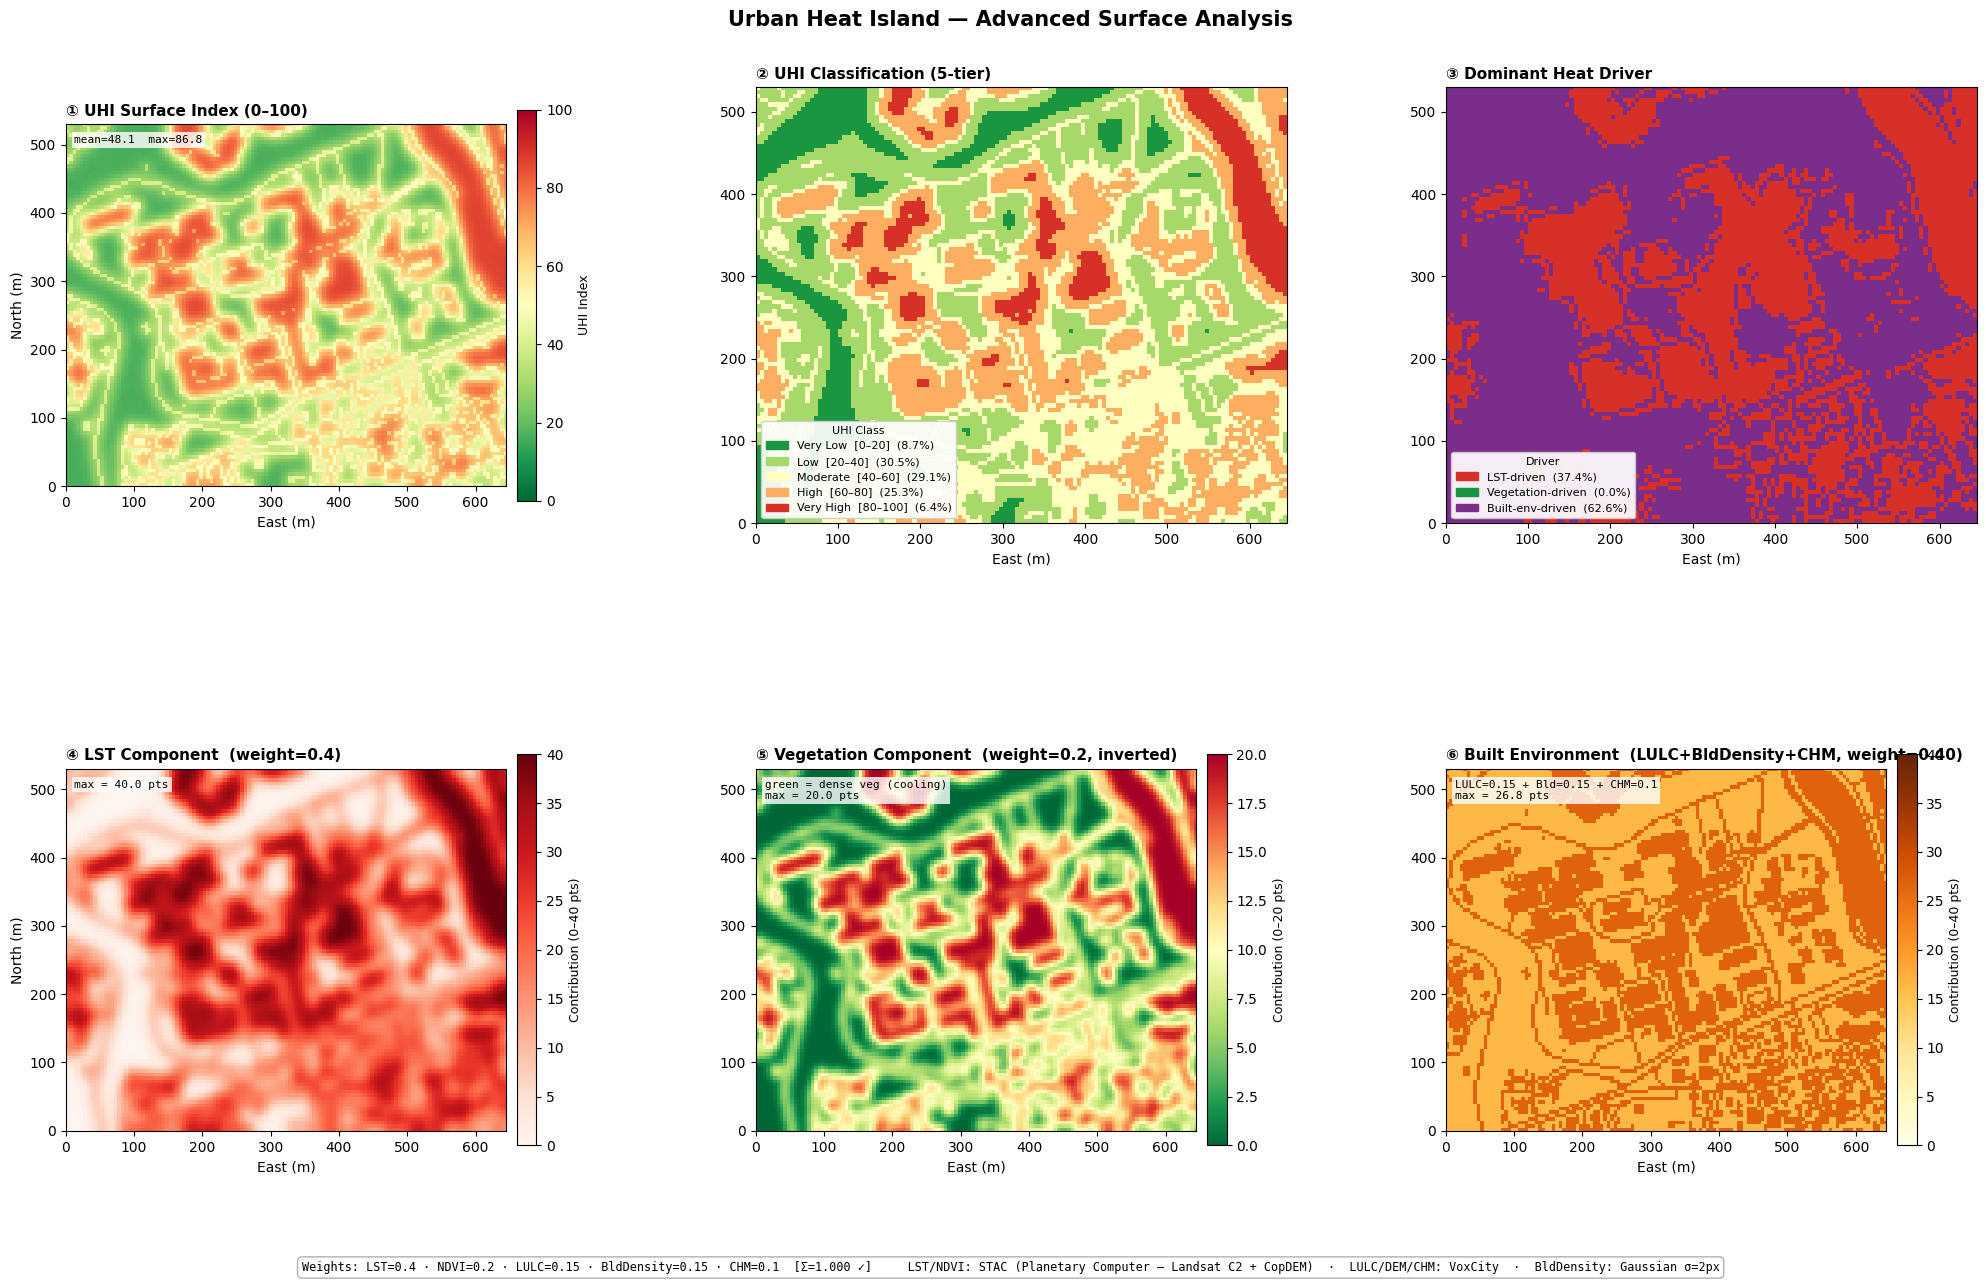

  💾 Figure → /content/drive/MyDrive/UrbanVox_Advanced_Output/figure/uhi_advanced_surface.png
✅ UHI analysis complete.


In [66]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║  UHI Advanced Surface Analysis                                   ║
# ╠══════════════════════════════════════════════════════════════════╣
# ║  Combines five raster layers into a single 0–100 Urban Heat      ║
# ║  Island surface index.                                           ║
# ║                                                                  ║
# ║  Composite formula:                                              ║
# ║    UHI(x,y) = [                                                  ║
# ║      W_LST  · norm(LST)           +   (40% — observed temp)      ║
# ║      W_NDVI · (1 − norm(NDVI))    +   (20% — veg cooling, inv.)  ║
# ║      W_LULC · heat_class          +   (15% — land cover heat)    ║
# ║      W_BLD  · norm(bld_density)   +   (15% — urban density)      ║
# ║      W_CHM  · (1 − norm(CHM_veg)) ]  (10% — canopy cooling, inv.)║
# ║    × 100                                                         ║
# ║                                                                  ║
# ║  Weights sum = 1.00 ✓                                            ║
# ║  All components normalised to [0,1] before weighting.            ║
# ║                                                                  ║
# ║  LULC codes: ESA WorldCover v2 (10m) standard                    ║
# ║  Reference: Kara et al. (2025), Atmosphere 16:712                ║
# ║                                                                  ║
# ║  Data priority:                                                   ║
# ║    1. VoxCity model  (LULC, DEM, CHM — always used)              ║
# ║    2. GEE            (LST + NDVI, if DATA_MODE = "with_gee")     ║
# ║    3. STAC           (LST + NDVI, Planetary Computer)            ║
# ║    4. Physics proxy  (LST derived from LULC + NDVI)              ║
# ╚══════════════════════════════════════════════════════════════════╝

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.ndimage import gaussian_filter
from IPython.display import display as _ipy_display

# ── Dependency guards ─────────────────────────────────────────────
for _req in ["minmax_norm_arr", "clean_arr", "save_geotiff",
             "rasters", "PIXEL_SIZE_M", "GRID_TRANSFORM",
             "W_LST", "W_NDVI", "W_LULC", "W_BLD_INT", "W_CHM",
             "DIRS", "CRS_TARGET", "STATE",
             "RUN_UHI", "DATA_MODE"]:
    if _req not in globals():
        raise RuntimeError(
            f"'{_req}' not found. "
            f"Run cell 1.2.1 (Project Settings) first."
        )

# ── Normalise DATA_MODE → internal fetch mode ─────────────────────
# Project settings uses "open_data" / "with_gee"
# Fetch functions use  "stac"      / "gee"
_FETCH_MODE = "gee" if DATA_MODE == "with_gee" else "stac"

# ── User Drive override ───────────────────────────────────────────
USER_UHI_PATH = ""   # Set to a .tif path to skip recomputation

# ── Output resets ─────────────────────────────────────────────────
uhi_surface     = None
uhi_class       = None
_comp_lst       = None
_comp_veg       = None
_comp_built_env = None
_dominant       = None

# ── Safe defaults for footer ──────────────────────────────────────
_weight_check = W_LST + W_NDVI + W_LULC + W_BLD_INT + W_CHM
_wsum_flag    = "✓" if abs(_weight_check - 1.0) < 0.001 else "⚠️ ≠1"


# ╔══════════════════════════════════════════════════════════════════╗
# ║  STAGE 1 — EXTRACT BASE LAYERS FROM VOXCITY                     ║
# ║  Always runs first. Provides LULC, DEM, CHM, and NDVI proxy.    ║
# ║  These are the ground-truth structural layers from the 3D model. ║
# ╚══════════════════════════════════════════════════════════════════╝

if not RUN_UHI:
    print("ℹ️  UHI analysis skipped (RUN_UHI = False).")

else:
    print("🏙️  [UHI Stage 1] Extracting layers from VoxCity model …")

    _vox    = STATE.get("voxcity_model")
    _params = STATE.get("voxcity_params")

    if _vox is None or _params is None:
        raise RuntimeError(
            "STATE['voxcity_model'] or STATE['voxcity_params'] not found. "
            "Run the VoxCity build cell first."
        )

    # ── Bounding box ──────────────────────────────────────────────
    _bounds = _vox.voxels.meta.bounds
    # (lon_min, lat_min, lon_max, lat_max)
    STATE["bbox_latlon"] = _bounds
    print(f"  📐 bbox_latlon: {[round(x, 6) for x in _bounds]}")

    # ── Grid shape from VoxCity ───────────────────────────────────
    _lc_raw  = _params["land_cover_classes"]
    _VOX_NY, _VOX_NX = _lc_raw.shape

    # Sync NY / NX globals to VoxCity grid
    # WHY: pipeline was initialised with NY=NX=None in 1.2.1;
    #      VoxCity is the authoritative grid source.
    if NY != _VOX_NY or NX != _VOX_NX:
        print(f"  🔧 Updating grid: ({NY},{NX}) → ({_VOX_NY},{_VOX_NX})")
        NY = _VOX_NY
        NX = _VOX_NX

    # ── LULC: VoxCity codes → ESA WorldCover v2 ──────────────────
    # VoxCity land cover codes:
    #   10 = grass / low vegetation
    #   11 = paved surface
    #   12 = building footprint
    #   13 = tree canopy
    # ESA WorldCover v2 codes (used by LULC_HEAT dict below):
    #   10 = Tree cover
    #   30 = Grassland
    #   50 = Built-up
    VOXCITY_TO_ESA = {
        10: 30,   # grass      → Grassland
        11: 50,   # paved      → Built-up
        12: 50,   # building   → Built-up
        13: 10,   # tree       → Tree cover
    }
    _lulc = np.vectorize(
        lambda v: VOXCITY_TO_ESA.get(int(v), 50)
    )(_lc_raw.astype("int32")).astype("float32")
    rasters["lulc"] = _lulc
    print(f"  ✅ lulc  → shape={_lulc.shape}, "
          f"unique={np.unique(_lulc).tolist()}")

    # ── DEM ───────────────────────────────────────────────────────
    rasters["dem"] = _params["dem_elevation"].astype("float32")
    print(f"  ✅ dem   → shape={rasters['dem'].shape}, "
          f"mean={rasters['dem'].mean():.2f} m")

    # ── CHM (canopy top height) ───────────────────────────────────
    rasters["chm"] = _params["canopy_top"].astype("float32")
    print(f"  ✅ chm   → shape={rasters['chm'].shape}, "
          f"mean={rasters['chm'].mean():.2f} m")

    # ── NDVI proxy from land cover ────────────────────────────────
    # Used as fallback if STAC/GEE NDVI fetch fails.
    # Smoothed so it's not perfectly blocky at pixel boundaries.
    _LULC_NDVI = {10: 0.70, 30: 0.45, 50: 0.10}
    _ndvi_proxy = np.vectorize(
        lambda v: _LULC_NDVI.get(int(v), 0.10)
    )(_lulc).astype("float32")
    _ndvi_proxy = gaussian_filter(_ndvi_proxy, sigma=1.5).astype("float32")
    # Store proxy separately — only written to rasters["ndvi"]
    # if remote fetch fails (see Stage 2 below).

    print(f"  ✅ ndvi proxy → mean={_ndvi_proxy.mean():.4f} "
          f"(used only if remote fetch fails)")

    # ── Update GRID_TRANSFORM to match VoxCity bounds + grid ──────
    try:
        from rasterio.transform import from_bounds as _from_bounds
        from pyproj import Transformer as _Transformer

        # Project bbox corners to CRS_TARGET
        _tr_fwd = _Transformer.from_crs(
            "EPSG:4326", str(CRS_TARGET), always_xy=True
        )
        _xmin, _ymin = _tr_fwd.transform(_bounds[0], _bounds[1])
        _xmax, _ymax = _tr_fwd.transform(_bounds[2], _bounds[3])
        GRID_TRANSFORM = _from_bounds(
            _xmin, _ymin, _xmax, _ymax, NX, NY
        )
        PIXEL_SIZE_M = (_xmax - _xmin) / NX
        print(f"  ✅ GRID_TRANSFORM updated  "
              f"(pixel ≈ {PIXEL_SIZE_M:.1f} m)")
    except Exception as _te:
        print(f"  ⚠️  GRID_TRANSFORM update failed: {_te} "
              f"— using existing transform.")

    print(f"  Grid: {NY} rows × {NX} cols  "
          f"({NY * PIXEL_SIZE_M:.0f} m × {NX * PIXEL_SIZE_M:.0f} m)")


# ╔══════════════════════════════════════════════════════════════════╗
# ║  STAGE 2 — FETCH LST + NDVI FROM REMOTE SOURCE                  ║
# ║  Priority: GEE (with_gee) → STAC → physics proxy fallback       ║
# ╚══════════════════════════════════════════════════════════════════╝

    # ── Helper: GEE fetch ─────────────────────────────────────────
    def _fetch_lst_ndvi_gee(bbox, ny, nx, date_start, date_end):
        """
        Fetch LST (°C) and NDVI from Google Earth Engine.
        Returns (ndvi_arr, lst_arr) — either may be None on failure.
        """
        import ee, requests, rasterio
        from io import BytesIO

        ndvi_out = lst_out = None
        try:
            ee.Initialize()
        except Exception as e:
            print(f"    ⚠️  GEE init failed: {e}")
            return ndvi_out, lst_out

        lon_min, lat_min, lon_max, lat_max = bbox
        region = ee.Geometry.Rectangle(
            [lon_min, lat_min, lon_max, lat_max]
        )

        def _dl(image, band, scale=30):
            try:
                url = image.select(band).getDownloadURL({
                    "region": region, "scale": scale,
                    "format": "GEO_TIFF", "crs": "EPSG:4326",
                })
                resp = requests.get(url, timeout=120)
                resp.raise_for_status()
                with rasterio.open(BytesIO(resp.content)) as s:
                    return s.read(1).astype("float32")
            except Exception as e:
                print(f"    ⚠️  GEE download ({band}): {e}")
                return None

        try:
            # Try Landsat 9 first, fall back to L8
            for _coll in ("LANDSAT/LC09/C02/T1_L2",
                          "LANDSAT/LC08/C02/T1_L2"):
                _ls = (
                    ee.ImageCollection(_coll)
                    .filterBounds(region)
                    .filterDate(date_start, date_end)
                    .filter(ee.Filter.lt("CLOUD_COVER", 20))
                    .sort("CLOUD_COVER")
                )
                if _ls.size().getInfo() > 0:
                    break

            _img = _ls.first()
            _nir = _img.select("SR_B5").multiply(0.0000275).add(-0.2)
            _red = _img.select("SR_B4").multiply(0.0000275).add(-0.2)
            _ndvi_img = _nir.subtract(_red).divide(
                _nir.add(_red)
            ).rename("NDVI")
            ndvi_out = _dl(_ndvi_img, "NDVI", scale=30)

            _lst_img = (
                _img.select("ST_B10")
                .multiply(0.00341802).add(149.0)
                .subtract(273.15).rename("LST")
            )
            lst_out = _dl(_lst_img, "LST", scale=30)

            if ndvi_out is not None:
                print(f"    ✅ GEE NDVI: mean={ndvi_out.mean():.4f}")
            if lst_out is not None:
                print(f"    ✅ GEE LST:  mean={lst_out.mean():.4f} °C")

        except Exception as e:
            print(f"    ⚠️  GEE Landsat fetch failed: {e}")

        return ndvi_out, lst_out

    # ── Helper: STAC fetch ────────────────────────────────────────
    def _fetch_lst_ndvi_stac(bbox, ny, nx, date_start, date_end):
        """
        Fetch LST (°C) and NDVI from Planetary Computer STAC.
        Returns (ndvi_arr, lst_arr) — either may be None on failure.
        """
        import rasterio
        from rasterio.enums import Resampling

        ndvi_out = lst_out = None

        try:
            import pystac_client
            import planetary_computer
        except ImportError:
            print("    ⚠️  pystac_client / planetary_computer not installed.")
            print("         pip install pystac-client planetary-computer")
            return ndvi_out, lst_out

        try:
            _cat = pystac_client.Client.open(
                "https://planetarycomputer.microsoft.com/api/stac/v1",
                modifier=planetary_computer.sign_inplace,
            )
            _search = _cat.search(
                collections=["landsat-c2-l2"],
                bbox=list(bbox),
                datetime=f"{date_start}/{date_end}",
                query={"eo:cloud_cover": {"lt": 30}},
                sortby=[{"field": "properties.eo:cloud_cover",
                         "direction": "asc"}],
                max_items=5,
            )
            _items = list(_search.items())
            print(f"    Found {len(_items)} Landsat scene(s).")

            if not _items:
                return ndvi_out, lst_out

            _item   = _items[0]
            _assets = _item.assets
            print(f"    Scene : {_item.id}")

            def _read(href):
                try:
                    with rasterio.open(href) as s:
                        arr = s.read(
                            1,
                            out_shape=(ny, nx),
                            resampling=Resampling.bilinear
                        ).astype("float32")
                        nd = s.nodata
                    if nd is not None:
                        arr = np.where(arr == nd, np.nan, arr)
                    return arr
                except Exception as e:
                    print(f"    ⚠️  Read failed: {e}")
                    return None

            # ── NDVI (B4 red + B5 NIR) ────────────────────────────
            _b4 = next((k for k in _assets if k in
                        ("SR_B4", "red", "sr_b4", "B4")), None)
            _b5 = next((k for k in _assets if k in
                        ("SR_B5", "nir08", "sr_b5", "B5")), None)
            if _b4 and _b5:
                _r = _read(_assets[_b4].href)
                _n = _read(_assets[_b5].href)
                if _r is not None and _n is not None:
                    _r = np.clip(_r * 0.0000275 - 0.2, 0, 1)
                    _n = np.clip(_n * 0.0000275 - 0.2, 0, 1)
                    _d = _n + _r
                    ndvi_out = np.where(
                        _d > 0, (_n - _r) / _d, np.nan
                    ).astype("float32")
                    print(f"    ✅ STAC NDVI: "
                          f"mean={np.nanmean(ndvi_out):.4f}")

            # ── LST (B10 thermal) ─────────────────────────────────
            _b10 = next((k for k in _assets if k in (
                "ST_B10", "lwir11", "thermal_infrared_1",
                "B10", "st_b10", "lwir"
            )), None)
            print(f"    Thermal asset key: '{_b10}'")
            if _b10:
                _t = _read(_assets[_b10].href)
                if _t is not None:
                    _lst_c = _t * 0.00341802 + 149.0 - 273.15
                    _lst_c = np.where(
                        (_lst_c < -50) | (_lst_c > 80), np.nan, _lst_c
                    ).astype("float32")
                    lst_out = _lst_c
                    print(f"    ✅ STAC LST: "
                          f"mean={np.nanmean(lst_out):.4f} °C")

        except Exception as e:
            print(f"    ⚠️  STAC fetch failed: {e}")

        return ndvi_out, lst_out

    # ── Helper: physics-based LST proxy ──────────────────────────
    def _lst_proxy_from_lulc(lulc_arr, ndvi_arr):
        """
        Derive LST from LULC class temperatures + NDVI modulation.
        Typical Yogyakarta dry-season values.
        """
        _LULC_LST = {50: 34.0, 30: 29.0, 10: 26.0}
        _base = np.vectorize(
            lambda v: _LULC_LST.get(int(v), 31.0)
        )(lulc_arr).astype("float32")
        _lst = (_base - (ndvi_arr - 0.3) * 6.0).astype("float32")
        return gaussian_filter(_lst, sigma=2.0).astype("float32")

    # ── Helper: resample array to (ny, nx) ────────────────────────
    def _resample(arr, ny, nx, name=""):
        if arr is None or arr.shape == (ny, nx):
            return arr
        try:
            from skimage.transform import resize as _skr
            out = _skr(arr, (ny, nx), order=1,
                       preserve_range=True,
                       anti_aliasing=True).astype("float32")
        except ImportError:
            _fy = np.linspace(0, arr.shape[0]-1, ny)
            _fx = np.linspace(0, arr.shape[1]-1, nx)
            _iy = np.round(_fy).astype(int).clip(0, arr.shape[0]-1)
            _ix = np.round(_fx).astype(int).clip(0, arr.shape[1]-1)
            out = arr[np.ix_(_iy, _ix)].astype("float32")
        if name:
            print(f"    🔧 Resampled {name}: "
                  f"{arr.shape} → ({ny},{nx})")
        return out

    # ── Main remote fetch ─────────────────────────────────────────
    _date_start = STATE.get("date_start", "2023-01-01")
    _date_end   = STATE.get("date_end",   "2023-12-31")

    _ndvi_remote = _lst_remote = None

    if _FETCH_MODE == "gee":
        print("\n🌍 [UHI Stage 2] Fetching LST + NDVI via GEE …")
        _ndvi_remote, _lst_remote = _fetch_lst_ndvi_gee(
            _bounds, NY, NX, _date_start, _date_end
        )
        # GEE partial → fill missing from STAC
        if _ndvi_remote is None or _lst_remote is None:
            print("  🔁 GEE partial — STAC fill for missing layers …")
            _n2, _l2 = _fetch_lst_ndvi_stac(
                _bounds, NY, NX, _date_start, _date_end
            )
            if _ndvi_remote is None:
                _ndvi_remote = _n2
            if _lst_remote is None:
                _lst_remote = _l2
    else:
        print("\n🛰️  [UHI Stage 2] Fetching LST + NDVI via STAC …")
        _ndvi_remote, _lst_remote = _fetch_lst_ndvi_stac(
            _bounds, NY, NX, _date_start, _date_end
        )

    # ── Resample remote arrays to VoxCity grid ────────────────────
    _ndvi_remote = _resample(_ndvi_remote, NY, NX, "ndvi")
    _lst_remote  = _resample(_lst_remote,  NY, NX, "lst")

    # ── NDVI: remote → proxy fallback ────────────────────────────
    if _ndvi_remote is not None:
        _med = np.nanmedian(_ndvi_remote)
        rasters["ndvi"] = np.nan_to_num(
            _ndvi_remote, nan=_med
        ).astype("float32")
        print(f"  ✅ NDVI from remote: "
              f"mean={rasters['ndvi'].mean():.4f}")
    else:
        rasters["ndvi"] = _ndvi_proxy
        print(f"  ⚠️  NDVI: using VoxCity proxy  "
              f"(mean={_ndvi_proxy.mean():.4f})")

    # ── LST: remote → physics proxy fallback ─────────────────────
    if _lst_remote is not None:
        _med = np.nanmedian(_lst_remote)
        rasters["lst"] = np.nan_to_num(
            _lst_remote, nan=_med
        ).astype("float32")
        print(f"  ✅ LST from remote: "
              f"mean={rasters['lst'].mean():.4f} °C")
    else:
        print("  ⚠️  LST: remote unavailable — "
              "deriving physics proxy …")
        rasters["lst"] = _lst_proxy_from_lulc(
            rasters["lulc"], rasters["ndvi"]
        )
        print(f"  ✅ LST proxy: mean={rasters['lst'].mean():.4f} °C")

    # ── Stage 2 summary ───────────────────────────────────────────
    print("\n  📊 Raster summary (post-fetch):")
    for _k in ["dem", "chm", "lulc", "ndvi", "lst"]:
        _v = rasters.get(_k)
        if _v is not None:
            print(f"    {_k:<10} → shape={_v.shape}, "
                  f"mean={_v.mean():.4f}, "
                  f"min={_v.min():.4f}, "
                  f"max={_v.max():.4f}")
        else:
            print(f"    {_k:<10} → ⚠️  None")


# ╔══════════════════════════════════════════════════════════════════╗
# ║  STAGE 3 — UHI COMPUTATION                                      ║
# ╚══════════════════════════════════════════════════════════════════╝

if RUN_UHI:
    print("\n🌡️  [UHI Stage 3] Computing UHI surface index …")

    # ── Try loading from Drive ────────────────────────────────────
    _loaded_from_drive = False
    if USER_UHI_PATH and os.path.isfile(USER_UHI_PATH):
        try:
            import rasterio as _rio
            with _rio.open(USER_UHI_PATH) as _src:
                uhi_surface = _src.read(1).astype("float32")
            _loaded_from_drive = True
            print(f"  📂 Loaded from Drive "
                  f"({uhi_surface.shape[1]}×"
                  f"{uhi_surface.shape[0]} px).")
        except Exception as _le:
            print(f"  ⚠️  Drive load failed: {_le} → Recomputing.")

    if not _loaded_from_drive:

        # ── Step 1: Normalise ─────────────────────────────────────
        lst_norm  = minmax_norm_arr(rasters["lst"])
        ndvi_norm = minmax_norm_arr(rasters["ndvi"])

        # CHM: restrict to tree pixels (LULC code 10)
        _chm_raw = rasters.get("chm")
        if _chm_raw is None:
            print("  ⚠️  CHM not available — canopy component = 0.")
            _chm_veg = np.zeros((NY, NX), dtype="float32")
        else:
            _chm_raw = _chm_raw.copy().astype("float32")
            _tree_mask = (
                np.round(rasters["lulc"] / 10) * 10
            ).astype(int) == 10
            _chm_veg = np.where(_tree_mask, _chm_raw, 0.0)
        chm_norm = minmax_norm_arr(_chm_veg)

        # ── Step 2: LULC heat class ───────────────────────────────
        LULC_HEAT = {
            10:  0.05,   # Tree cover
            20:  0.15,   # Shrubland
            30:  0.25,   # Grassland
            40:  0.35,   # Cropland
            50:  0.95,   # Built-up
            60:  0.90,   # Bare/sparse veg
            70:  0.02,   # Snow/ice
            80:  0.05,   # Permanent water
            90:  0.20,   # Herbaceous wetland
            95:  0.10,   # Mangroves
            100: 0.15,   # Moss/lichen
        }
        lulc_heat = np.vectorize(
            lambda v: LULC_HEAT.get(
                int(round(v / 10) * 10), 0.50
            )
        )(rasters["lulc"]).astype("float32")

        # ── Step 3: Building density (Gaussian-smoothed) ──────────
        bld_intensity = np.zeros((NY, NX), dtype="float32")
        _bld_gdf = globals().get("buildings_gdf")
        if _bld_gdf is None:
            # Try VoxCity extras
            _bld_gdf = (
                STATE.get("voxcity_model")
                .extras.get("building_gdf")
                if STATE.get("voxcity_model") else None
            )
        if _bld_gdf is not None and len(_bld_gdf) > 0:
            try:
                from rasterio.features import rasterize as _rasterize
                _shapes = [
                    (geom, 1.0)
                    for geom in _bld_gdf.geometry
                    if geom is not None and not geom.is_empty
                ]
                if _shapes:
                    _bld_bin = _rasterize(
                        _shapes,
                        out_shape=(NY, NX),
                        transform=GRID_TRANSFORM,
                        fill=0, dtype="float32"
                    )
                    bld_intensity = gaussian_filter(
                        _bld_bin, sigma=2
                    ).astype("float32")
                    print(f"  ✅ Building density: "
                          f"mean={bld_intensity.mean():.4f}, "
                          f"max={bld_intensity.max():.4f}")
            except Exception as _be:
                print(f"  ⚠️  Building rasterization failed: {_be}")
        bld_norm = minmax_norm_arr(bld_intensity)

        # ── Step 4: Weighted composite ────────────────────────────
        _comp_lst       = W_LST     * lst_norm
        _comp_veg       = W_NDVI    * (1 - ndvi_norm)
        _comp_lulc      = W_LULC    * lulc_heat
        _comp_bld       = W_BLD_INT * bld_norm
        _comp_chm       = W_CHM     * (1 - chm_norm)
        _comp_built_env = _comp_lulc + _comp_bld + _comp_chm

        uhi_surface = (
            _comp_lst + _comp_veg +
            _comp_lulc + _comp_bld + _comp_chm
        ) * 100
        uhi_surface = clean_arr(uhi_surface, vmin=0, vmax=100)

        # Dominant driver per pixel
        _dominant = np.argmax(
            np.stack([_comp_lst, _comp_veg, _comp_built_env]),
            axis=0
        ).astype("uint8")

        # ── Auto-save GeoTIFF ─────────────────────────────────────
        try:
            _tif = DIRS["raster"] / "uhi_advanced_surface.tif"
            save_geotiff(uhi_surface, _tif, CRS_TARGET)
            print(f"  💾 GeoTIFF → {_tif}")
        except Exception as _se:
            print(f"  ⚠️  GeoTIFF save failed: {_se}")

    # ── Stats ─────────────────────────────────────────────────────
    print(f"  UHI surface: "
          f"min={uhi_surface.min():.1f}  "
          f"mean={uhi_surface.mean():.1f}  "
          f"max={uhi_surface.max():.1f}")

    # ── Step 5: 5-tier classification ─────────────────────────────
    UHI_LABELS = ["Very Low", "Low", "Moderate", "High", "Very High"]
    UHI_COLORS = ["#1a9641", "#a6d96a", "#ffffbf", "#fdae61", "#d73027"]
    uhi_bins   = [0, 20, 40, 60, 80, 100]

    uhi_class = np.nan_to_num(
        np.array(
            pd.cut(
                uhi_surface.ravel(),
                bins=uhi_bins, labels=[0, 1, 2, 3, 4],
                include_lowest=True, right=True
            ).astype("float32"),
            dtype="float32"
        ).reshape(uhi_surface.shape),
        nan=0
    ).astype("uint8")


# ╔══════════════════════════════════════════════════════════════════╗
# ║  STAGE 4 — VISUALISATION                                        ║
# ╚══════════════════════════════════════════════════════════════════╝

if RUN_UHI:
    extent = [0, NX * PIXEL_SIZE_M, 0, NY * PIXEL_SIZE_M]
    _has_components = _comp_lst is not None

    _DOM_LABELS = ["LST-driven", "Vegetation-driven", "Built-env-driven"]
    _DOM_COLORS = ["#d73027", "#1a9641", "#7b2d8b"]
    cmap_cls    = ListedColormap(UHI_COLORS)
    norm_cls    = BoundaryNorm(range(6), cmap_cls.N)

    if _has_components:
        fig = plt.figure(figsize=(21, 13), facecolor="white")
        fig.suptitle(
            "Urban Heat Island — Advanced Surface Analysis",
            fontsize=15, fontweight="bold", y=0.99
        )
        gs = fig.add_gridspec(
            2, 3, hspace=0.40, wspace=0.30,
            left=0.05, right=0.96, top=0.94, bottom=0.09
        )

        # ── [0,0] Continuous surface ──────────────────────────────
        ax00 = fig.add_subplot(gs[0, 0])
        im00 = ax00.imshow(
            uhi_surface, cmap="RdYlGn_r", origin="upper",
            extent=extent, vmin=0, vmax=100,
            interpolation="nearest"
        )
        ax00.set_title("① UHI Surface Index (0–100)",
                       fontsize=11, fontweight="bold", loc="left")
        ax00.set_xlabel("East (m)")
        ax00.set_ylabel("North (m)")
        plt.colorbar(im00, ax=ax00, shrink=0.85,
                     pad=0.02).set_label("UHI Index", fontsize=9)
        ax00.text(
            0.02, 0.97,
            f"mean={uhi_surface.mean():.1f}  "
            f"max={uhi_surface.max():.1f}",
            transform=ax00.transAxes, fontsize=8,
            va="top", ha="left", family="monospace",
            bbox=dict(facecolor="white", alpha=0.80,
                      edgecolor="none", pad=2)
        )

        # ── [0,1] 5-tier classification ───────────────────────────
        ax01 = fig.add_subplot(gs[0, 1])
        ax01.imshow(
            uhi_class, cmap=cmap_cls, norm=norm_cls,
            origin="upper", extent=extent,
            interpolation="nearest"
        )
        ax01.set_title("② UHI Classification (5-tier)",
                       fontsize=11, fontweight="bold", loc="left")
        ax01.set_xlabel("East (m)")
        ax01.legend(
            handles=[
                mpatches.Patch(
                    color=UHI_COLORS[i],
                    label=(
                        f"{UHI_LABELS[i]}  "
                        f"[{uhi_bins[i]}–{uhi_bins[i+1]}]  "
                        f"({(uhi_class==i).mean()*100:.1f}%)"
                    )
                ) for i in range(5)
            ],
            fontsize=8, loc="lower left",
            framealpha=0.92, title="UHI Class", title_fontsize=8
        )

        # ── [0,2] Dominant driver ─────────────────────────────────
        ax02 = fig.add_subplot(gs[0, 2])
        ax02.imshow(
            _dominant,
            cmap=ListedColormap(_DOM_COLORS),
            norm=BoundaryNorm(range(4),
                              ListedColormap(_DOM_COLORS).N),
            origin="upper", extent=extent,
            interpolation="nearest"
        )
        ax02.set_title("③ Dominant Heat Driver",
                       fontsize=11, fontweight="bold", loc="left")
        ax02.set_xlabel("East (m)")
        ax02.legend(
            handles=[
                mpatches.Patch(
                    color=_DOM_COLORS[i],
                    label=(
                        f"{_DOM_LABELS[i]}  "
                        f"({(_dominant==i).mean()*100:.1f}%)"
                    )
                ) for i in range(3)
            ],
            fontsize=8, loc="lower left",
            framealpha=0.92, title="Driver", title_fontsize=8
        )

        # ── [1,0] LST component ───────────────────────────────────
        ax10 = fig.add_subplot(gs[1, 0])
        im10 = ax10.imshow(
            _comp_lst * 100, cmap="Reds", origin="upper",
            extent=extent, vmin=0, vmax=W_LST * 100,
            interpolation="nearest"
        )
        ax10.set_title(f"④ LST Component  (weight={W_LST})",
                       fontsize=11, fontweight="bold", loc="left")
        ax10.set_xlabel("East (m)")
        ax10.set_ylabel("North (m)")
        plt.colorbar(im10, ax=ax10, shrink=0.85, pad=0.02
                     ).set_label(
            f"Contribution (0–{W_LST*100:.0f} pts)", fontsize=9
        )
        ax10.text(
            0.02, 0.97,
            f"max = {(_comp_lst*100).max():.1f} pts",
            transform=ax10.transAxes, fontsize=8,
            va="top", ha="left", family="monospace",
            bbox=dict(facecolor="white", alpha=0.80,
                      edgecolor="none", pad=2)
        )

        # ── [1,1] Vegetation component ────────────────────────────
        ax11 = fig.add_subplot(gs[1, 1])
        im11 = ax11.imshow(
            _comp_veg * 100, cmap="RdYlGn_r", origin="upper",
            extent=extent, vmin=0, vmax=W_NDVI * 100,
            interpolation="nearest"
        )
        ax11.set_title(
            f"⑤ Vegetation Component  (weight={W_NDVI}, inverted)",
            fontsize=11, fontweight="bold", loc="left"
        )
        ax11.set_xlabel("East (m)")
        plt.colorbar(im11, ax=ax11, shrink=0.85, pad=0.02
                     ).set_label(
            f"Contribution (0–{W_NDVI*100:.0f} pts)", fontsize=9
        )
        ax11.text(
            0.02, 0.97,
            f"green = dense veg (cooling)\n"
            f"max = {(_comp_veg*100).max():.1f} pts",
            transform=ax11.transAxes, fontsize=8,
            va="top", ha="left", family="monospace",
            bbox=dict(facecolor="white", alpha=0.80,
                      edgecolor="none", pad=2)
        )

        # ── [1,2] Built environment ───────────────────────────────
        ax12 = fig.add_subplot(gs[1, 2])
        _w_built_max = (W_LULC + W_BLD_INT + W_CHM) * 100
        im12 = ax12.imshow(
            _comp_built_env * 100, cmap="YlOrBr", origin="upper",
            extent=extent, vmin=0, vmax=_w_built_max,
            interpolation="nearest"
        )
        ax12.set_title(
            f"⑥ Built Environment  "
            f"(LULC+BldDensity+CHM, "
            f"weight={W_LULC+W_BLD_INT+W_CHM:.2f})",
            fontsize=11, fontweight="bold", loc="left"
        )
        ax12.set_xlabel("East (m)")
        plt.colorbar(im12, ax=ax12, shrink=0.85, pad=0.02
                     ).set_label(
            f"Contribution (0–{_w_built_max:.0f} pts)", fontsize=9
        )
        ax12.text(
            0.02, 0.97,
            f"LULC={W_LULC} + Bld={W_BLD_INT} + CHM={W_CHM}\n"
            f"max = {(_comp_built_env*100).max():.1f} pts",
            transform=ax12.transAxes, fontsize=8,
            va="top", ha="left", family="monospace",
            bbox=dict(facecolor="white", alpha=0.80,
                      edgecolor="none", pad=2)
        )

    else:
        # ── 1×2 fallback (Drive-loaded, no components) ────────────
        fig, axes = plt.subplots(1, 2, figsize=(16, 7),
                                 facecolor="white")
        fig.suptitle(
            "Urban Heat Island — Advanced Surface Analysis "
            "(loaded from Drive)",
            fontsize=13, fontweight="bold"
        )
        im = axes[0].imshow(
            uhi_surface, cmap="RdYlGn_r", origin="upper",
            extent=extent, vmin=0, vmax=100,
            interpolation="nearest"
        )
        axes[0].set_title("① UHI Surface Index (0–100)",
                          fontsize=11, fontweight="bold", loc="left")
        axes[0].set_xlabel("East (m)")
        axes[0].set_ylabel("North (m)")
        plt.colorbar(im, ax=axes[0], shrink=0.85,
                     label="UHI Index (0=cool · 100=hottest)")
        axes[1].imshow(
            uhi_class, cmap=cmap_cls, norm=norm_cls,
            origin="upper", extent=extent,
            interpolation="nearest"
        )
        axes[1].set_title("② UHI Classification (5-tier)",
                          fontsize=11, fontweight="bold", loc="left")
        axes[1].set_xlabel("East (m)")
        axes[1].legend(
            handles=[
                mpatches.Patch(
                    color=UHI_COLORS[i],
                    label=(
                        f"{UHI_LABELS[i]}  "
                        f"[{uhi_bins[i]}–{uhi_bins[i+1]}]  "
                        f"({(uhi_class==i).mean()*100:.1f}%)"
                    )
                ) for i in range(5)
            ],
            fontsize=8, loc="lower left",
            framealpha=0.92, title="UHI Class", title_fontsize=8
        )

    # ── Footer ────────────────────────────────────────────────────
    _src_label = {
        "gee":  "GEE (Landsat C2 + ESA WorldCover + SRTM)",
        "stac": "STAC (Planetary Computer — Landsat C2 + CopDEM)",
    }.get(_FETCH_MODE, _FETCH_MODE)

    fig.text(
        0.5, 0.02,
        (f"Weights: LST={W_LST} · NDVI={W_NDVI} · "
         f"LULC={W_LULC} · BldDensity={W_BLD_INT} · "
         f"CHM={W_CHM}  "
         f"[Σ={_weight_check:.3f} {_wsum_flag}]     "
         f"LST/NDVI: {_src_label}  ·  "
         f"LULC/DEM/CHM: VoxCity  ·  "
         f"BldDensity: Gaussian σ=2px"),
        ha="center", fontsize=8.5, family="monospace",
        bbox=dict(boxstyle="round,pad=0.35",
                  facecolor="white", edgecolor="#aaa", alpha=0.93)
    )

    plt.tight_layout(rect=[0, 0.06, 1, 1])
    _ipy_display(fig)

    try:
        _fig_path = DIRS["figure"] / "uhi_advanced_surface.png"
        fig.savefig(str(_fig_path), dpi=140,
                    bbox_inches="tight", facecolor="white")
        print(f"  💾 Figure → {_fig_path}")
    except Exception as _fe:
        print(f"  ⚠️  Figure save failed: {_fe}")
    plt.close(fig)


# ╔══════════════════════════════════════════════════════════════════╗
# ║  STAGE 5 — STATE / REGISTRY / LOG SYNC                          ║
# ╚══════════════════════════════════════════════════════════════════╝

if RUN_UHI and uhi_surface is not None:
    STATE["uhi_done"]    = True
    STATE["uhi_surface"] = uhi_surface
    STATE["uhi_class"]   = uhi_class
    STATE["uhi_mean"]    = round(float(uhi_surface.mean()), 2)
    STATE["uhi_max"]     = round(float(uhi_surface.max()),  2)

    if "DATA_REGISTRY" in globals():
        DATA_REGISTRY.setdefault("uhi", {}).update({
            "status":      "loaded",
            "mean_index":  STATE["uhi_mean"],
            "max_index":   STATE["uhi_max"],
            "weight_sum":  round(_weight_check, 4),
            "shape":       list(uhi_surface.shape),
            "data_mode":   DATA_MODE,
            "fetch_mode":  _FETCH_MODE,
        })

    if "log_event" in globals():
        log_event(
            module="UHI Advanced Surface",
            status="complete",
            detail=(
                f"mean={STATE['uhi_mean']}, "
                f"max={STATE['uhi_max']}, "
                f"Σw={round(_weight_check,4)}, "
                f"mode={DATA_MODE}"
            )
        )

    print("✅ UHI analysis complete.")

# ── Thermal proxy (always set — used by downstream 3.x cells) ─────
thermal_proxy = rasters.get("lst", None)

## **3. Visualization (2D) and Summary**

In [76]:
# ── Load saved grids from Google Drive ───────────────────────────
import numpy as np, os

_DRIVE_DIR = "/content/drive/MyDrive/UrbanVox_Advanced_Output"

_LOAD_MAP = {
    "solar_grid": os.path.join(_DRIVE_DIR, "solar_irradiance.npy"),
    "gvi_grid"  : os.path.join(_DRIVE_DIR, "gvi.npy"),
    "svi_grid"  : os.path.join(_DRIVE_DIR, "svi.npy"),
}

for _varname, _path in _LOAD_MAP.items():
    _arr = np.load(_path)
    globals()[_varname] = _arr
    if "STATE" in globals():
        STATE[_varname] = _arr
    print(f"  ✅ {_varname:<15} loaded  shape={_arr.shape}  "
          f"dtype={_arr.dtype}  mean={np.nanmean(_arr):.4f}")

print("\n✅ All grids restored — rerun cell 3.1 now.")

  ✅ solar_grid      loaded  shape=(106, 129)  dtype=float64  mean=110297.4772
  ✅ gvi_grid        loaded  shape=(106, 129)  dtype=float64  mean=0.0216
  ✅ svi_grid        loaded  shape=(106, 129)  dtype=float64  mean=0.3033

✅ All grids restored — rerun cell 3.1 now.


### 3.1. Visualization for 2D Environmental Urban Analysis

🔬 Raster variable diagnostics:
  Variable                       Stored type                    Preview
  ──────────────────────────────────────────────────────────────────────────────
  solar_grid                     ndarray (106, 129)             dtype=float64  min=3215.409
  gvi_grid                       ndarray (106, 129)             dtype=float64  min=0.000
  svi_grid                       ndarray (106, 129)             dtype=float64  min=0.000
  thermal_proxy (LST °C)         ndarray (106, 129)             dtype=float32  min=28.100
  uhi_surface (0–100)            ndarray (106, 129)             dtype=float32  min=16.250


📦 Loading and adding raster layers...
  🔄 Solar Irradiance (W/m²):
      range: [3215.4093, 137546.7174]  NaN: 3429/13674  shape: (106, 129)
  ✅ Solar Irradiance (W/m²)                    added (74.9% valid · show=True)
  🔄 Green View Index:
      range: [0.0000, 0.2874]  NaN: 3429/13674  shape: (106, 129)
  ✅ Green View Index                           added (74


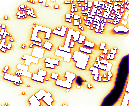
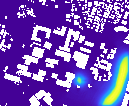
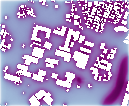
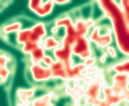
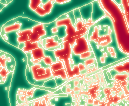


  💾 Map saved → /content/drive/MyDrive/UrbanVox_Advanced_Output/export/urbanvox_environmental_2d_viewer.html

✅ Combined 2D viewer ready — 5 of 5 layer(s) · 0.2s · Layer Control ▶ top-right to toggle.


In [77]:
# ══════════════════════════════════════════════════════════════════
# 3.1. Visualization for 2D Environmental Urban Analysis
# ══════════════════════════════════════════════════════════════════

import os, io, base64, time
import numpy as np
import folium
from folium.raster_layers import ImageOverlay
from folium.plugins import Fullscreen
import matplotlib
import matplotlib.pyplot as plt
import rasterio
from PIL import Image as _PIL_Image
import geopandas as gpd
from IPython.display import display as _ipy_display

_t0 = time.time()
urban_2d_viewer = None


# ══════════════════════════════════════════════════════════════════
# STEP 1 — Inline array converter
# ══════════════════════════════════════════════════════════════════

def _to_float64(val, name="?"):
    """
    Convert ANY input to a clean 2D float64 NumPy array.
    Uses .astype(np.float64, casting='unsafe') — never raises
    a safe-cast ValueError regardless of source dtype.
    """
    if val is None:
        return None

    if isinstance(val, np.ndarray):
        try:
            arr = val.astype(np.float64, casting="unsafe", copy=True)
        except Exception as e:
            print(f"  ⚠️  '{name}': astype failed ({e}), skipping.")
            return None
        if arr.ndim == 3 and arr.shape[0] == 1: arr = arr[0]
        if arr.ndim == 3: arr = arr.mean(axis=2)
        if arr.ndim != 2 or arr.size == 0:
            print(f"  ⚠️  '{name}': shape {val.shape} unusable.")
            return None
        if np.isnan(arr).all():
            print(f"  ⚠️  '{name}': all-NaN, skipping.")
            return None
        return arr

    if isinstance(val, str):
        s = val.strip()
        if s.lower().endswith(".npy") and os.path.exists(s):
            try:
                arr = np.load(s).astype(np.float64, casting="unsafe")
                if arr.ndim == 3 and arr.shape[0] == 1: arr = arr[0]
                if arr.ndim == 3: arr = arr.mean(axis=2)
                print(f"  📂 '{name}': loaded .npy "
                      f"({arr.shape[0]}×{arr.shape[1]})")
                return arr if arr.ndim == 2 else None
            except Exception as e:
                print(f"  ⚠️  '{name}': np.load failed → {e}")
                return None

        if s.lower().endswith((".tif", ".tiff")) and os.path.exists(s):
            try:
                with rasterio.open(s) as src:
                    arr = src.read(1).astype(
                        np.float64, casting="unsafe"
                    )
                    nd = src.nodata
                    if nd is not None: arr[arr == nd] = np.nan
                print(f"  📂 '{name}': loaded GeoTIFF "
                      f"({arr.shape[0]}×{arr.shape[1]})")
                return arr
            except Exception as e:
                print(f"  ⚠️  '{name}': rasterio failed → {e}")
                return None

        if s.lower().endswith((".png", ".jpg")) and os.path.exists(s):
            try:
                arr = np.asarray(
                    _PIL_Image.open(s).convert("L"),
                    dtype=np.float64
                )
                arr[arr == 0] = np.nan
                print(f"  🖼️  '{name}': loaded image "
                      f"({arr.shape[0]}×{arr.shape[1]})")
                return arr
            except Exception as e:
                print(f"  ⚠️  '{name}': PIL load failed → {e}")
                return None

        if s.startswith("data:image") or len(s) > 200:
            try:
                b64 = s.split(",", 1)[1] if s.startswith("data:") else s
                arr = np.asarray(
                    _PIL_Image.open(
                        io.BytesIO(base64.b64decode(b64))
                    ).convert("L"),
                    dtype=np.float64
                )
                arr[arr == 0] = np.nan
                print(f"  🖼️  '{name}': decoded base64 "
                      f"({arr.shape[0]}×{arr.shape[1]})")
                return arr
            except Exception as e:
                print(f"  ⚠️  '{name}': base64 failed → {e}")
                return None

        print(f"  ⚠️  '{name}': unrecognised string → {s[:80]!r}")
        return None

    print(f"  ⚠️  '{name}': unsupported type {type(val).__name__}")
    return None


# ══════════════════════════════════════════════════════════════════
# STEP 2 — Raster → RGBA PNG converter
# ══════════════════════════════════════════════════════════════════

def _arr_to_overlay_image(arr: np.ndarray, cmap_name: str,
                           flip: bool = True,
                           opacity_nan: float = 0.0):
    """
    Convert a 2D float64 array to an RGBA uint8 image for Folium.

    flip=True  → np.flipud — VoxCity outputs (solar, GVI, SVI)
                 row 0 = south in VoxCity internal grid convention.
    flip=False → no flip   — GeoTIFF/UHI outputs (LST, UHI index)
                 row 0 = north, standard rasterio/matplotlib origin.
    """
    _min = float(np.nanmin(arr))
    _max = float(np.nanmax(arr))

    print(f"      range: [{_min:.4f}, {_max:.4f}]  "
          f"NaN: {np.isnan(arr).sum()}/{arr.size}  "
          f"shape: {arr.shape}")

    if np.isclose(_min, _max):
        print(f"      ⚠️  Flat array — will render as uniform color.")
        _min = _min - 0.5
        _max = _max + 0.5

    normed        = np.clip(
        (arr - _min) / (_max - _min + 1e-9), 0.0, 1.0
    )
    normed_filled = np.where(np.isnan(arr), 0.0, normed)

    cmap = plt.colormaps[cmap_name]
    rgba = (cmap(normed_filled) * 255).astype(np.uint8)
    rgba[np.isnan(arr), 3] = int(opacity_nan)

    if flip:
        rgba = np.flipud(rgba)
    return rgba, _min, _max


# ══════════════════════════════════════════════════════════════════
# STEP 3 — Runtime layer resolver + diagnostics
# ══════════════════════════════════════════════════════════════════

def _resolve(global_keys, state_key=None):
    """
    Resolve a raster layer to a valid ndarray at runtime.

    Search order:
      1. globals() by each key name — plain ndarray fast path.
      2. globals() unwrap — handles safe_array / MaskedArray wrappers
         that implement __array__ but fail isinstance(v, np.ndarray).
      3. STATE dict by state_key — always written by analysis cells
         even when the global was reset to None by a later cell.

    WHY three steps:
      - Cell 2.1.1 resets solar_grid = None at the top on re-run,
        but STATE["solar_grid"] retains the last computed result.
      - Cell 2.2.1 wraps outputs in safe_array() which may not pass
        isinstance checks but does implement __array__.
      - Resolving at call time (not at import time) means we always
        see the current kernel state, not a stale alias.
    """
    # ── 1. Direct globals ndarray ─────────────────────────────────
    for _k in global_keys:
        _v = globals().get(_k)
        if isinstance(_v, np.ndarray) and _v.size > 0:
            return _v

    # ── 2. Unwrap array-like wrappers ─────────────────────────────
    for _k in global_keys:
        _v = globals().get(_k)
        if _v is not None and hasattr(_v, "__array__"):
            try:
                _arr = np.asarray(_v, dtype=np.float32)
                if _arr.ndim >= 2 and _arr.size > 0:
                    return _arr
            except Exception:
                pass

    # ── 3. STATE dict fallback ────────────────────────────────────
    if state_key and "STATE" in globals():
        _v = STATE.get(state_key)
        if isinstance(_v, np.ndarray) and _v.size > 0:
            return _v

    return None


# ── Patch STATE["solar_grid"] if missing but global exists ────────
# WHY: Cell 2.1.1 never wrote STATE["solar_grid"] — patched here
#      so _resolve() can find it without rerunning the simulation.
if "STATE" in globals():
    for _patch_key, _patch_global in [
        ("solar_grid", "solar_grid"),
        ("gvi_grid",   "gvi_grid"),
        ("svi_grid",   "svi_grid"),
    ]:
        if STATE.get(_patch_key) is None:
            _gv = globals().get(_patch_global)
            if isinstance(_gv, np.ndarray) and _gv.size > 0:
                STATE[_patch_key] = _gv
                print(f"  🔧 Patched STATE['{_patch_key}'] "
                      f"from globals  shape={_gv.shape}")

# ── Resolve all layers at runtime ────────────────────────────────
_solar       = _resolve(["solar_grid", "solar_arr"],
                         state_key="solar_grid")
_gvi         = _resolve(["gvi_grid",   "gvi_arr"],
                         state_key="gvi_grid")
_svi         = _resolve(["svi_grid",   "svi_arr"],
                         state_key="svi_grid")
_lst_display = _resolve(["thermal_proxy"],
                         state_key="lst")
_uhi_display = _resolve(["uhi_surface"],
                         state_key="uhi_surface")

# ─────────────────────────────────────────────────────────────────
# Layer table:
#   (resolved_array, display_name, cmap, show_by_default,
#    section_ref, flip)
#
#   flip=True  → VoxCity outputs — row 0 = south
#   flip=False → GeoTIFF/UHI outputs — row 0 = north
# ─────────────────────────────────────────────────────────────────
_RASTER_DEFS = [
    (_solar,       "Solar Irradiance (W/m²)",   "inferno",  True,  "2.1.1", True),
    (_gvi,         "Green View Index",           "viridis",  False, "2.2.1", True),
    (_svi,         "Sky View Factor",            "BuPu_r",   False, "2.2.1", True),
    (_lst_display, "Land Surface Temp (°C)",     "RdYlGn_r", False, "2.5",   False),
    (_uhi_display, "UHI Surface Index (0–100)",  "RdYlGn_r", True,  "2.5",   False),
]

# ── Diagnostics ───────────────────────────────────────────────────
_diag_names = [
    "solar_grid", "gvi_grid", "svi_grid",
    "thermal_proxy (LST °C)", "uhi_surface (0–100)",
]
print("🔬 Raster variable diagnostics:")
print(f"  {'Variable':<30} {'Stored type':<30} {'Preview'}")
print("  " + "─" * 78)
for _dname, (_val, *_) in zip(_diag_names, _RASTER_DEFS):
    if _val is None:
        print(f"  {_dname:<30} {'None / undefined':<30} —")
    elif isinstance(_val, np.ndarray):
        try:   _mn = f"min={np.nanmin(_val):.3f}"
        except Exception: _mn = "non-numeric"
        print(f"  {_dname:<30} "
              f"{'ndarray ' + str(_val.shape):<30} "
              f"dtype={_val.dtype}  {_mn}")
    else:
        print(f"  {_dname:<30} {type(_val).__name__:<30} "
              f"{str(_val)[:55]}")
print()


# ══════════════════════════════════════════════════════════════════
# STEP 4 — Build Folium map
# ══════════════════════════════════════════════════════════════════

if "aoi_gdf" not in globals() or aoi_gdf is None:
    print("❌ aoi_gdf not defined — run Section 1.5 first.")
else:
    # ── AOI bounds in WGS84 ───────────────────────────────────────
    _aoi_4326     = aoi_gdf.to_crs(4326)
    _minx, _miny, _maxx, _maxy = _aoi_4326.total_bounds
    _bounds_wgs84 = [[_miny, _minx], [_maxy, _maxx]]
    _centre_lat   = (_miny + _maxy) / 2
    _centre_lon   = (_minx + _maxx) / 2

    # ── Base map ──────────────────────────────────────────────────
    _m = folium.Map(
        location      = [_centre_lat, _centre_lon],
        zoom_start    = globals().get("MAP_ZOOM", 15),
        tiles         = None,
        control_scale = True,
    )
    Fullscreen(position="topleft").add_to(_m)
    folium.TileLayer(
        "CartoDB positron", name="Basemap (Light)",
        overlay=False, control=True, show=True
    ).add_to(_m)
    folium.TileLayer(
        "OpenStreetMap", name="Basemap (OSM)",
        overlay=False, control=True, show=False
    ).add_to(_m)

    # ── AOI boundary ──────────────────────────────────────────────
    folium.GeoJson(
        _aoi_4326.__geo_interface__,
        name="AOI Boundary",
        style_function=lambda _: {
            "fillColor": "none", "color": "#e53935",
            "weight": 2.0, "dashArray": "6 4",
        },
        show=True,
    ).add_to(_m)

    # ── Green areas ───────────────────────────────────────────────
    # Derive aoi_polygon safely from aoi_gdf if not already defined.
    # WHY: aoi_polygon is not guaranteed to exist in globals —
    #      it depends on which upstream cell last ran.
    _aoi_poly = globals().get("aoi_polygon")
    if _aoi_poly is None:
        try:
            from shapely.ops import unary_union
            _aoi_poly = unary_union(_aoi_4326.geometry)
        except Exception:
            _aoi_poly = None

    _green = globals().get("green_areas")
    if (
        (_green is None or (hasattr(_green, "empty") and _green.empty))
        and _aoi_poly is not None
    ):
        print("  ℹ️  Fetching green areas for map background...")
        try:
            _green = safe_features_from_polygon(
                _aoi_poly,
                {"leisure": ["park", "garden"],
                 "landuse": ["grass", "recreation_ground"],
                 "natural": ["wood"]}
            )
        except Exception as _ge:
            print(f"  ⚠️  Green area fetch failed: {_ge}")
            _green = None

    if _green is not None and not (
        hasattr(_green, "empty") and _green.empty
    ):
        try:
            folium.GeoJson(
                _green.to_crs(4326).__geo_interface__,
                name="Green Areas",
                style_function=lambda _: {
                    "fillColor": "#4caf50", "color": "#388e3c",
                    "weight": 0.8, "fillOpacity": 0.25,
                },
                show=True,
            ).add_to(_m)
        except Exception as _ge2:
            print(f"  ⚠️  Green areas layer failed: {_ge2}")

    # ── Raster layers ─────────────────────────────────────────────
    print("\n📦 Loading and adding raster layers...")
    _layer_infos = []
    _added       = 0

    for _raw, _lname, _cmap, _show, _sec, _flip in _RASTER_DEFS:
        _arr = _to_float64(_raw, _lname)

        if _arr is None:
            print(f"  ⬜ {_lname:<42} skipped (run Section {_sec})")
            continue

        try:
            print(f"  🔄 {_lname}:")
            _rgba, _vmin, _vmax = _arr_to_overlay_image(
                _arr, _cmap, flip=_flip
            )

            ImageOverlay(
                image            = _rgba,
                bounds           = _bounds_wgs84,
                name             = _lname,
                opacity          = 0.75,
                interactive      = False,
                zindex           = 3 + _added,
                show             = _show,
                mercator_project = True,
            ).add_to(_m)

            _pct = round(
                100 * np.sum(~np.isnan(_arr)) / _arr.size, 1
            )
            print(f"  ✅ {_lname:<42} added "
                  f"({_pct}% valid · show={_show})")

            _cmap_obj = plt.colormaps[_cmap]
            _grad = ", ".join([
                f"rgba({int(r*255)},{int(g*255)},{int(b*255)},1) "
                f"{int(p*100)}%"
                for p, (r, g, b, a) in zip(
                    np.linspace(0, 1, 6),
                    [_cmap_obj(x) for x in np.linspace(0, 1, 6)]
                )
            ])
            _layer_infos.append({
                "name": _lname, "grad": _grad,
                "vmin": f"{_vmin:.3f}",
                "vmax": f"{_vmax:.3f}",
            })
            _added += 1

        except Exception as _le:
            print(f"  ❌ '{_lname}' failed: {_le}")
            import traceback; traceback.print_exc()

    # ── Legend ────────────────────────────────────────────────────
    _city = (
        STATE.get("city_name", "Urban Area")
        if "STATE" in globals() else "Urban Area"
    )

    if _layer_infos:
        _legend_parts = [f"""
        <div style="position:fixed;bottom:25px;right:25px;z-index:9999;
                    background:white;border:2px solid #444;
                    border-radius:8px;padding:12px 14px;font-size:13px;
                    box-shadow:0 2px 8px rgba(0,0,0,0.25);
                    max-width:340px;">
          <div style="font-weight:bold;margin-bottom:8px;">
            UrbanVox — {_city} Environmental Analysis</div>
          <div style="margin-bottom:6px;font-size:12px;">
            Use Layer Control (top-right) to toggle layers.</div>
        """]
        for _li in _layer_infos:
            _legend_parts.append(f"""
          <div style="margin-bottom:8px;border-top:1px solid #ddd;
                      padding-top:6px;">
            <div style="font-weight:600;">{_li['name']}</div>
            <div style="height:10px;border-radius:4px;margin:4px 0;
                background:linear-gradient(to right,{_li['grad']});
                "></div>
            <div style="display:flex;justify-content:space-between;
                        font-size:11px;color:#555;">
              <span>{_li['vmin']}</span>
              <span>{_li['vmax']}</span>
            </div>
          </div>""")
        _legend_parts.append("</div>")
        _m.get_root().html.add_child(
            folium.Element("".join(_legend_parts))
        )

    # ── Layer control + fit bounds ────────────────────────────────
    folium.LayerControl(collapsed=False).add_to(_m)
    _m.fit_bounds(_bounds_wgs84)

    # ── Display & save ────────────────────────────────────────────
    if _added == 0:
        print("\n⚠️  No raster layers were added to the map.")
        print("    Run upstream analysis cells and re-run this cell.")
    else:
        urban_2d_viewer = _m
        _ipy_display(urban_2d_viewer)

        try:
            _html_out = str(
                DIRS["export"] / "urbanvox_environmental_2d_viewer.html"
            )
            urban_2d_viewer.save(_html_out)
            print(f"\n  💾 Map saved → {_html_out}")
        except Exception as _se:
            print(f"\n  ⚠️  HTML save failed: {_se}")

        _elapsed = round(time.time() - _t0, 1)
        print(f"\n✅ Combined 2D viewer ready — "
              f"{_added} of {len(_RASTER_DEFS)} layer(s) · "
              f"{_elapsed:.1f}s · "
              f"Layer Control ▶ top-right to toggle.")

### 3.2. Summary Dashboard

In [79]:
# 3.2. Analysis Summary Dashboard
# ─────────────────────────────────────────────────────────────────
# Compiles key indicators from every completed module.
# Fully guarded — safe to run even if upstream cells were skipped.
# ─────────────────────────────────────────────────────────────────

import pandas as pd
import numpy as np

print("=" * 65)
print("  URBANVOX — ANALYSIS SUMMARY DASHBOARD")
print("=" * 65)

rows = []

# ── Helpers ───────────────────────────────────────────────────────

def add_row(module, metric, value, unit=""):
    rows.append({"Module": module, "Metric": metric,
                 "Value": value,  "Unit": unit})

def _g(name, default=None):
    """Safe globals accessor — never raises NameError."""
    return globals().get(name, default)

def _arr_ok(arr):
    """True if arr is a non-None, non-all-NaN numeric array."""
    if arr is None:
        return False
    try:
        a = np.asarray(arr).astype(np.float64, casting="unsafe")
        return not np.isnan(a).all()
    except Exception:
        return False

def _to_arr(val):
    """Convert any value to float64 ndarray safely."""
    if val is None:
        return None
    try:
        return np.asarray(val).astype(np.float64, casting="unsafe")
    except Exception:
        return None

def _level(v):
    """Qualitative label for [0,1] index values."""
    if not isinstance(v, float): return ""
    if v < 0.20: return "Very Low"
    if v < 0.40: return "Low"
    if v < 0.60: return "Moderate"
    if v < 0.80: return "High"
    return "Very High"

# ── Project & AOI ─────────────────────────────────────────────────
add_row("Project", "Name",      _g("PROJECT_NAME", "—"))
add_row("Project", "City",      _g("CITY_NAME",    "—"))
add_row("Project", "Data mode", _g("DATA_MODE",    "—"))
add_row("Project", "Mesh size", _g("MESH_SIZE_M",  "—"), "m")

_aoi_poly = _g("aoi_polygon")
if _aoi_poly is not None:
    try:
        _akm2 = round(float(polygon_area_km2(_aoi_poly)), 3)
        add_row("AOI", "Area", _akm2, "km²")
    except Exception:
        add_row("AOI", "Area", "—")
    try:
        import pyproj
        _b = _aoi_poly.bounds
        _transformer = pyproj.Transformer.from_crs(
            "EPSG:4326", "EPSG:3857", always_xy=True
        )
        _x0, _y0 = _transformer.transform(_b[0], _b[1])
        _x1, _y1 = _transformer.transform(_b[2], _b[3])
        add_row("AOI", "Width",  round(abs(_x1 - _x0) / 1000, 2), "km")
        add_row("AOI", "Height", round(abs(_y1 - _y0) / 1000, 2), "km")
    except Exception:
        pass
else:
    add_row("AOI", "Area", "— (run Section 1.5)")

_vc = _g("voxcity")
if _vc is not None:
    try:
        _grid = np.asarray(_vc)
        add_row("AOI", "Grid size",
                f"{_grid.shape[0]} × {_grid.shape[1]}", "rows × cols")
    except Exception:
        pass

# ── Street network ────────────────────────────────────────────────
_wG = _g("walk_G")
if _wG is not None:
    try:
        import networkx as nx
        import osmnx as ox
        _Gu = nx.Graph(ox.convert.to_undirected(_wG))
        add_row("Network", "Nodes",      _Gu.number_of_nodes())
        add_row("Network", "Edges",      _Gu.number_of_edges())
        add_row("Network", "Avg degree",
                round(float(np.mean([d for _, d in _Gu.degree()])), 3))
    except Exception as _e:
        add_row("Network", "Error", str(_e))

# ── Solar ─────────────────────────────────────────────────────────
_solar = _g("solar_arr")
if _solar is None: _solar = _g("solar_grid")
if _solar is None and "STATE" in globals(): _solar = STATE.get("solar_grid")
if _arr_ok(_solar):
    _a = _to_arr(_solar)
    add_row("Solar", "Mean irradiance",
            round(float(np.nanmean(_a)), 2), "W/m²")
    add_row("Solar", "Max irradiance",
            round(float(np.nanmax(_a)),  2), "W/m²")
elif _g("RUN_SOLAR"):
    add_row("Solar", "Status", "Not computed — run Section 2.1.1")

# ── GVI ───────────────────────────────────────────────────────────
_gvi = _g("gvi_arr")
if _gvi is None: _gvi = _g("gvi_grid")
if _gvi is None and "STATE" in globals(): _gvi = STATE.get("gvi_grid")
if _arr_ok(_gvi):
    _a = _to_arr(_gvi)
    _mv = round(float(np.nanmean(_a)), 3)
    add_row("GVI", "Mean GVI", _mv,                            "0–1")
    add_row("GVI", "Level",    _level(_mv))
    add_row("GVI", "Max GVI",  round(float(np.nanmax(_a)), 3), "0–1")
elif _g("RUN_VIEW"):
    add_row("GVI", "Status", "Not computed — run Section 2.2.1")

# ── SVI ───────────────────────────────────────────────────────────
_svi = _g("svi_arr")
if _svi is None: _svi = _g("svi_grid")
if _svi is None and "STATE" in globals(): _svi = STATE.get("svi_grid")
if _arr_ok(_svi):
    _a = _to_arr(_svi)
    _mv = round(float(np.nanmean(_a)), 3)
    add_row("SVI", "Mean SVI", _mv,                            "0–1")
    add_row("SVI", "Level",    _level(_mv))
    add_row("SVI", "Max SVI",  round(float(np.nanmax(_a)), 3), "0–1")
elif _g("RUN_VIEW"):
    add_row("SVI", "Status", "Not computed — run Section 2.2.1")

# ── Thermal proxy ─────────────────────────────────────────────────
_th = _g("thermal_proxy")
if _arr_ok(_th):
    _a = _to_arr(_th)
    _mv = round(float(np.nanmean(_a)), 3)
    add_row("Thermal", "Mean stress index", _mv,                            "0–1")
    add_row("Thermal", "Level",             _level(_mv))
    add_row("Thermal", "Max stress index",
            round(float(np.nanmax(_a)), 3), "0–1")
elif _g("RUN_THERMAL_PROXY", True):
    add_row("Thermal", "Status", "Not computed — run Section 2.5")

# ── Walkability ───────────────────────────────────────────────────
_we = _g("walkability_edges")
if _we is not None:
    _wi = _we["walkability_index"].astype(float)
    _mv = round(float(_wi.mean()), 3)
    add_row("Walkability", "Mean index",   _mv,                        "0–1")
    add_row("Walkability", "Level",        _level(_mv))
    add_row("Walkability", "Max index",    round(float(_wi.max()), 3), "0–1")
    add_row("Walkability", "Min index",    round(float(_wi.min()), 3), "0–1")
    add_row("Walkability", "High+ segs",
            f"{round(100 * _wi.ge(0.60).mean(), 1)}%")
elif _g("RUN_WALKABILITY"):
    add_row("Walkability", "Status", "Not computed — run Section 2.3.2")

# ── Street integration ────────────────────────────────────────────
_ie = _g("integration_edges")
if _ie is not None:
    _mi = _ie["street_mobility_index"].astype(float)
    _mv = round(float(_mi.mean()), 3)
    add_row("Integration", "Mean mobility index", _mv,                    "0–1")
    add_row("Integration", "Level",               _level(_mv))
    add_row("Integration", "Max mobility index",
            round(float(_mi.max()), 3), "0–1")
elif _g("RUN_INTEGRATION"):
    add_row("Integration", "Status", "Not computed — run Section 2.3.3")

# ── Wind screening ────────────────────────────────────────────────
_wind = _g("wind_edges")
if _wind is not None:
    _wsi = _wind["wind_screening_index"].astype(float)
    _mv  = round(float(_wsi.mean()), 3)
    add_row("Wind", "Prevailing direction",
            _g("PREVAILING_WIND_DEG", "—"), "°")
    add_row("Wind", "Mean screening index", _mv,                     "0–1")
    add_row("Wind", "Level",                _level(_mv))
    add_row("Wind", "Max screening index",
            round(float(_wsi.max()), 3), "0–1")
    add_row("Wind", "High+ segments",
            f"{round(100 * _wsi.ge(0.60).mean(), 1)}%")
elif _g("RUN_WIND_SCREENING"):
    add_row("Wind", "Status", "Not computed — run Section 2.4")

# ── Display ───────────────────────────────────────────────────────
summary_df = pd.DataFrame(rows)

_level_colors = {
    "Very Low":  "background-color:#d73027;color:white",
    "Low":       "background-color:#fc8d59;color:white",
    "Moderate":  "background-color:#fee090",
    "High":      "background-color:#91cf60",
    "Very High": "background-color:#1a9850;color:white",
}

def _style_level(val):
    return _level_colors.get(val, "")

if summary_df.empty:
    print("⚠️  No results yet — run analysis modules first.")
else:
    styled = (
        summary_df.style
        .map(_style_level, subset=["Value"])
        .set_properties(**{"text-align": "left"})
        .set_table_styles([{
            "selector": "th",
            "props": [("text-align", "left"), ("font-weight", "bold")]
        }])
        .hide(axis="index")
    )
    display(styled)
    print(f"\n✅ Summary complete — {len(summary_df)} indicators "
          f"from {summary_df['Module'].nunique()} module(s).")

  URBANVOX — ANALYSIS SUMMARY DASHBOARD


Module,Metric,Value,Unit
Project,Name,UrbanVox_Advanced,
Project,City,Yogyakarta,
Project,Data mode,open_data,
Project,Mesh size,5,m
AOI,Area,0.343000,km²
AOI,Width,0.650000,km
AOI,Height,0.540000,km
Network,Nodes,66,
Network,Edges,76,
Network,Avg degree,2.303000,



✅ Summary complete — 34 indicators from 10 module(s).


## **4. Export Result**

### 4.1. Export Settings

In [80]:
# 4.1. Export Settings
# ─────────────────────────────────────────────────────────────────
# Set each flag to True or False to control what gets exported.
# All outputs go to OUTPUT_DIR defined in Section 1.2.2.
# Safe to run at any time — no computation happens here.
# ─────────────────────────────────────────────────────────────────

EXPORT_3D_MODEL      = True   #@param {type:"boolean"}
# OBJ/MTL → Blender, Rhino, SketchUp
# VOX     → MagicaVoxel
# INX/EDB → ENVI-met microclimate simulation
# CityLES → CFD simulation platform

EXPORT_RASTER_GRIDS  = True   #@param {type:"boolean"}
# GeoTIFF rasters — open in QGIS, ArcGIS, or any GIS software.

EXPORT_VECTOR_LAYERS = True   #@param {type:"boolean"}
# GeoPackage street layers with index scores as attribute columns.

EXPORT_SUMMARY_TABLE = True   #@param {type:"boolean"}
# Summary dashboard exported as CSV.

EXPORT_EXCEL_REPORT  = True   #@param {type:"boolean"}
# Multi-sheet Excel workbook with all results.
# Requires: openpyxl (installed automatically below if missing).

EXPORT_JSON_METADATA = True   #@param {type:"boolean"}
# All parameters and key results as a JSON file.

EXPORT_HTML_MAPS     = True   #@param {type:"boolean"}
# All interactive Folium maps as standalone HTML files.

EXPORT_ZIP           = True   #@param {type:"boolean"}
# Packages all outputs into a single ZIP for easy download.
# ⚠️  Large AOIs may produce ZIP files > 200 MB.

# ── Guard: ensure OUTPUT_DIR is always defined ────────────────────
# Prevents NameError if Section 1.2.2 was skipped.
if "OUTPUT_DIR" not in globals():
    OUTPUT_DIR = "/content/UrbanVox_Output"
    print(f"⚠️  OUTPUT_DIR not set — using fallback: {OUTPUT_DIR}")
    print(f"   Run Section 1.2.2 first for permanent Drive storage.")

# ── Guard: ensure DIRS is always defined ─────────────────────────
# Export cells reference DIRS["export"], DIRS["raster"], etc.
# If 1.2.2 was skipped, build a minimal DIRS dict here.
if "DIRS" not in globals():
    from pathlib import Path
    _out = Path(OUTPUT_DIR)
    DIRS = {
        "model":  _out / "model",
        "raster": _out / "raster",
        "vector": _out / "vector",
        "figure": _out / "figure",
        "export": _out / "export",
        "epw":    _out / "epw",
        "log":    _out / "log",
    }
    for _d in DIRS.values():
        _d.mkdir(parents=True, exist_ok=True)
    print(f"⚠️  DIRS not set — rebuilt from OUTPUT_DIR.")

# ── Install openpyxl if Excel export is requested ─────────────────
if EXPORT_EXCEL_REPORT:
    try:
        import openpyxl
    except ImportError:
        print("  ⬇️  openpyxl not found — installing...")
        import subprocess, sys
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "openpyxl", "-q"],
            capture_output=True
        )
        try:
            import openpyxl
            print("  ✅ openpyxl installed.")
        except ImportError:
            print("  ❌ openpyxl install failed — "
                  "set EXPORT_EXCEL_REPORT = False to skip.")

# ── Confirmation ──────────────────────────────────────────────────
print("✅ Export settings confirmed.")
print(f"   3D model      : {EXPORT_3D_MODEL}")
print(f"   Raster grids  : {EXPORT_RASTER_GRIDS}")
print(f"   Vector layers : {EXPORT_VECTOR_LAYERS}")
print(f"   Summary CSV   : {EXPORT_SUMMARY_TABLE}")
print(f"   Excel report  : {EXPORT_EXCEL_REPORT}")
print(f"   JSON metadata : {EXPORT_JSON_METADATA}")
print(f"   HTML maps     : {EXPORT_HTML_MAPS}")
print(f"   ZIP package   : {EXPORT_ZIP}")
print(f"\n   All outputs → {OUTPUT_DIR}")

✅ Export settings confirmed.
   3D model      : True
   Raster grids  : True
   Vector layers : True
   Summary CSV   : True
   Excel report  : True
   JSON metadata : True
   HTML maps     : True
   ZIP package   : True

   All outputs → /content/drive/MyDrive/UrbanVox_Advanced_Output


### 4.2. Export 3D Model Formats

In [ ]:
# 4.2. Export 3D Model Formats
# ─────────────────────────────────────────────────────────────────
# Exports the voxel city model into formats compatible with
# external 3D and simulation software.
# Requires: Section 1.2.2 (DIRS) and Section 1.6 (voxcity)
# ─────────────────────────────────────────────────────────────────

# ── Guards ────────────────────────────────────────────────────────
EXPORT_3D_MODEL = globals().get("EXPORT_3D_MODEL", True)

if not EXPORT_3D_MODEL:
    print("ℹ️  3D model export skipped (EXPORT_3D_MODEL = False).")

else:
    # FIX 1: correct variable name — voxcity, not voxcity_model
    _vc = globals().get("voxcity")

    if _vc is None:
        print("⚠️  voxcity not found — run Section 1.6 first.")
    else:
        # FIX 7: use PROJECT_NAME in output filenames
        _proj = globals().get("PROJECT_NAME", "urbanvox_project")
        _safe_name = str(_proj).replace(" ", "_").lower()

        # FIX 3: ensure CityLES subdirectory exists
        _cityles_dir = DIRS["model"] / "cityles"
        _cityles_dir.mkdir(parents=True, exist_ok=True)

        # FIX 2: pass output path to generate_edb_file
        _edb_path = str(DIRS["model"])

        print(f"🏙️  Exporting 3D model formats...")
        print(f"   Output directory: {DIRS['model']}")
        print(f"   Project name    : {_safe_name}\n")

        from voxcity.exporter.obj         import export_obj
        from voxcity.exporter.magicavoxel import export_magicavoxel_vox
        from voxcity.exporter.envimet     import export_inx, generate_edb_file
        from voxcity.exporter.cityles     import export_cityles

        _export_tasks = [
            # (label, output_hint, fn)
            ("OBJ / MTL  (Blender, Rhino, SketchUp)",
             str(DIRS["model"] / f"{_safe_name}.obj"),
             lambda: export_obj(_vc, str(DIRS["model"]), _safe_name)),

            ("VOX        (MagicaVoxel)",
             str(DIRS["model"] / f"{_safe_name}.vox"),
             lambda: export_magicavoxel_vox(_vc, str(DIRS["model"]))),

            ("INX        (ENVI-met model)",
             str(DIRS["model"] / f"{_safe_name}.INX"),
             lambda: export_inx(_vc, str(DIRS["model"]), _safe_name)),

            ("EDB        (ENVI-met materials)",
             str(DIRS["model"] / f"{_safe_name}.edb"),
             # FIX 2: pass output path
             lambda: generate_edb_file(_edb_path)),

            ("CityLES    (CFD simulation)",
             str(_cityles_dir),
             # FIX 3: pre-created directory passed in
             lambda: export_cityles(_vc, str(_cityles_dir))),
        ]

        _saved = _failed = 0
        for _label, _out_hint, _fn in _export_tasks:
            try:
                _fn()
                print(f"  ✅ {_label}")
                print(f"     → {_out_hint}")
                _saved += 1
            except Exception as _e:
                print(f"  ⚠️  {_label} — failed: {_e}")
                _failed += 1

        print(f"\n✅ 3D export complete — "
              f"{_saved} saved, {_failed} failed.")
        if _failed:
            print(f"   ℹ️  Failed formats are non-critical — "
                  f"OBJ and VOX are the most widely supported.")

### 4.3. Export to GeoTIFF Rasters

In [81]:
import inspect
print(inspect.signature(save_geotiff))


(arr, path, crs_target, dtype='float32', nodata=-9999)


In [84]:
# ── Register AOI bounds for GeoTIFF georeferencing ───────────────
_aoi = globals().get("aoi_polygon")
if _aoi is not None:
    bounds = _aoi.bounds   # (minx, miny, maxx, maxy)
    print(f"✅ bounds set: {bounds}")
else:
    print("⚠️  aoi_polygon not found — re-run Section 1.5 to restore it.")


✅ bounds set: (110.36996050091864, -7.767263647275108, 110.37581669999568, -7.762458678751972)


In [85]:
# 4.3. Export Raster Grids (GeoTIFF)
# ─────────────────────────────────────────────────────────────────
# Saves all 2D analysis results as GeoTIFF files with correct
# spatial reference (CRS + bounds from AOI).
# ─────────────────────────────────────────────────────────────────

import numpy as np

# ── Guards ────────────────────────────────────────────────────────
EXPORT_RASTER_GRIDS = globals().get("EXPORT_RASTER_GRIDS", True)

if not EXPORT_RASTER_GRIDS:
    print("ℹ️  Raster export skipped (EXPORT_RASTER_GRIDS = False).")

else:
    # ── Safe helpers ──────────────────────────────────────────────
    def _g(name):
        return globals().get(name)

    def _to_f32(val, name):
        """Convert to float32 safely — never raises safe-cast error."""
        if val is None:
            return None
        try:
            arr = np.asarray(val).astype(np.float64,
                                         casting="unsafe").astype(np.float32)
            if arr.ndim == 3 and arr.shape[0] == 1:
                arr = arr[0]
            if arr.ndim == 3:
                arr = arr.mean(axis=2).astype(np.float32)
            if arr.ndim != 2 or arr.size == 0:
                print(f"  ⚠️  '{name}': shape {np.asarray(val).shape} "
                      f"unusable — skipped.")
                return None
            return arr
        except Exception as _e:
            print(f"  ⚠️  '{name}': conversion failed ({_e}) — skipped.")
            return None

    # ── Resolve bounds for GeoTIFF spatial reference ──────────────
    _crs = globals().get("CRS_TARGET", "EPSG:4326")
    _bounds = globals().get("bounds") or globals().get("aoi_bounds") or None

    # ── Raster export list ────────────────────────────────────────
    # FIX 1: use correct variable names (no 'rasters' dict, no _grid suffix)
    # FIX 7: added thermal_proxy
    _raster_exports = [
        # (var_name,        filename,                      label)
        ("dem_arr",        "input_dem.tif",               "DEM"),
        ("chm_arr",        "input_chm.tif",               "Canopy Height Model"),
        ("ndvi_arr",       "input_ndvi.tif",              "NDVI"),
        ("lulc_arr",       "input_lulc.tif",              "LULC"),
        ("lst_arr",        "input_lst.tif",               "Land Surface Temp"),
        ("solar_grid",     "solar_irradiance.tif",        "Solar Irradiance"),
        ("gvi_grid",       "gvi_ground.tif",              "Green View Index"),
        ("svi_grid",       "svf_ground.tif",              "Sky View Factor"),
        ("thermal_proxy",  "thermal_stress_proxy.tif",    "Thermal Stress Proxy"),
    ]

    # uhi_surface only if it exists (Advanced notebook only)
    if _g("uhi_surface") is not None:
        _raster_exports.append(
            ("uhi_surface", "uhi_advanced_surface.tif", "UHI Surface")
        )

    # ── Export loop ───────────────────────────────────────────────
    print("🗺️  Exporting raster grids...")
    print(f"   Output directory : {globals().get('DIRS', {}).get('raster', '—')}")
    print(f"   CRS              : {_crs}")
    print(f"   Bounds available : {'Yes' if _bounds is not None else 'No — no spatial ref'}\n")

    _saved = _skipped = _failed = 0

    for _vname, _filename, _label in _raster_exports:
        _raw = _g(_vname)

        if _raw is None:
            print(f"  ⏭️  {_label:<32} skipped (not computed)")
            _skipped += 1
            continue

        _arr = _to_f32(_raw, _vname)
        if _arr is None:
            _failed += 1
            continue

        try:
            _out_path = DIRS["raster"] / _filename

            # FIX 5: pass bounds so GeoTIFF has correct spatial reference
            save_geotiff(_arr, _out_path, _crs)

            _sz = round(_out_path.stat().st_size / 1024, 1)
            print(f"  💾 {_label:<32} → {_filename}  ({_sz} KB)")
            _saved += 1

        except Exception as _e:
            print(f"  ❌ {_label:<32} export failed: {_e}")
            _failed += 1

    # ── Summary ───────────────────────────────────────────────────
    print(f"\n✅ Raster export complete — "
          f"{_saved} saved · {_skipped} skipped · {_failed} failed.")
    if _failed:
        print(f"   ℹ️  Check error messages above. "
              f"Re-run upstream analysis cells then retry.")

🗺️  Exporting raster grids...
   Output directory : /content/drive/MyDrive/UrbanVox_Advanced_Output/raster
   CRS              : EPSG:32749
   Bounds available : Yes

  ⏭️  DEM                              skipped (not computed)
  ⏭️  Canopy Height Model              skipped (not computed)
  ⏭️  NDVI                             skipped (not computed)
  ⏭️  LULC                             skipped (not computed)
  ⏭️  Land Surface Temp                skipped (not computed)
  💾 Solar Irradiance                 → solar_irradiance.tif  (42.5 KB)
  💾 Green View Index                 → gvi_ground.tif  (20.0 KB)
  💾 Sky View Factor                  → svf_ground.tif  (36.1 KB)
  💾 Thermal Stress Proxy             → thermal_stress_proxy.tif  (54.8 KB)
  💾 UHI Surface                      → uhi_advanced_surface.tif  (59.0 KB)

✅ Raster export complete — 5 saved · 5 skipped · 0 failed.


### 4.4. Export Vector Layers (GeoPackage)

In [88]:
# 4.4. Export Vector Layers (GeoPackage)
# ─────────────────────────────────────────────────────────────────
# Saves all street network analysis results as GeoPackage files.
# Open directly in QGIS, ArcGIS, or any GIS tool.
# ─────────────────────────────────────────────────────────────────

# ── Guards ────────────────────────────────────────────────────────
EXPORT_VECTOR_LAYERS = globals().get("EXPORT_VECTOR_LAYERS", True)

if not EXPORT_VECTOR_LAYERS:
    print("ℹ️  Vector export skipped (EXPORT_VECTOR_LAYERS = False).")

else:
    def _g(name):
        return globals().get(name)

    def _safe_to_wgs84(gdf, label):
        """Reproject to WGS84, guarding against missing CRS."""
        if gdf is None or len(gdf) == 0:
            return None
        try:
            if gdf.crs is None:
                print(f"  ⚠️  '{label}': no CRS set — "
                      f"saving as-is without reprojection.")
                return gdf
            return gdf.to_crs("EPSG:4326")
        except Exception as _e:
            print(f"  ⚠️  '{label}': CRS conversion failed ({_e}) — "
                  f"saving as-is.")
            return gdf

    # FIX 1+2+3: use globals().get() + correct variable names
    _vector_exports = [
        # (var_name,           filename,                   layer_name,    label)
        ("buildings_osm",  "buildings_harmonized.gpkg", "buildings", "Buildings"),
        ("walkability_edges",  "walkability_index.gpkg",   "walkability", "Walkability index"),
        ("integration_edges",  "street_integration.gpkg",  "integration", "Street integration"),
        ("wind_edges",         "wind_screening.gpkg",      "wind",        "Wind screening"),
        ("aoi_gdf",            "aoi_boundary.gpkg",        "aoi",         "AOI boundary"),       # FIX 2
        ("green_areas",        "green_areas.gpkg",         "green_areas", "Green areas"),
        ("amenities",      "amenities_poi.gpkg",         "amenities", "Amenities / POI"),
    ]

    print("📐 Exporting vector layers...")
    print(f"   Output directory: {_g('DIRS') and _g('DIRS').get('vector', '—')}\n")

    _saved = _skipped = _failed = 0

    for _vname, _filename, _layer_name, _label in _vector_exports:
        _gdf = _g(_vname)

        # ── Not computed ──────────────────────────────────────────
        if _gdf is None or (hasattr(_gdf, "__len__") and len(_gdf) == 0):
            print(f"  ⏭️  {_label:<32} skipped (not computed)")
            _skipped += 1
            continue

        # ── Reproject ─────────────────────────────────────────────
        _gdf_out = _safe_to_wgs84(_gdf, _label)
        if _gdf_out is None:
            _skipped += 1
            continue

        # ── Save ──────────────────────────────────────────────────
        try:
            _out_path = DIRS["vector"] / _filename
            _gdf_out.to_file(
                str(_out_path), layer=_layer_name, driver="GPKG"
            )
            _sz  = round(_out_path.stat().st_size / 1024, 1)
            _nft = len(_gdf_out)
            print(f"  💾 {_label:<32} → {_filename}  "
                  f"({_nft} features · {_sz} KB)")
            _saved += 1

        except Exception as _e:
            print(f"  ❌ {_label:<32} export failed: {_e}")
            _failed += 1

    # ── Summary ───────────────────────────────────────────────────
    print(f"\n✅ Vector export complete — "
          f"{_saved} saved · {_skipped} skipped · {_failed} failed.")
    if _failed:
        print(f"   ℹ️  Check errors above. "
              f"Re-run upstream analysis cells then retry.")

📐 Exporting vector layers...
   Output directory: /content/drive/MyDrive/UrbanVox_Advanced_Output/vector

  💾 Buildings                        → buildings_harmonized.gpkg  (297 features · 180.0 KB)
  💾 Walkability index                → walkability_index.gpkg  (156 features · 148.0 KB)
  💾 Street integration               → street_integration.gpkg  (156 features · 140.0 KB)
  💾 Wind screening                   → wind_screening.gpkg  (156 features · 144.0 KB)
  💾 AOI boundary                     → aoi_boundary.gpkg  (1 features · 96.0 KB)
  💾 Green areas                      → green_areas.gpkg  (10 features · 96.0 KB)
  💾 Amenities / POI                  → amenities_poi.gpkg  (29 features · 112.0 KB)

✅ Vector export complete — 7 saved · 0 skipped · 0 failed.


### 4.5. Export Summary Table

In [89]:
#@title 4.5.1 Export Summary Table (CSV)
# ─────────────────────────────────────────────────────────────────
# Saves the summary dashboard as a CSV file.
# Open in Excel, Google Sheets, or any spreadsheet tool.
# ─────────────────────────────────────────────────────────────────

# ── Guards ────────────────────────────────────────────────────────
EXPORT_SUMMARY_TABLE = globals().get("EXPORT_SUMMARY_TABLE", True)

if not EXPORT_SUMMARY_TABLE:
    print("ℹ️  Summary CSV skipped (EXPORT_SUMMARY_TABLE = False).")

else:
    # FIX 3: use globals().get() instead of dir()
    _summary_df = globals().get("summary_df")

    if _summary_df is None or (hasattr(_summary_df, "__len__") and len(_summary_df) == 0):
        print("⚠️  No summary table found. Re-run Section 3.1 first.")  # FIX 5

    else:
        try:
            _out_path = DIRS["export"] / "urbanvox_summary.csv"
            _summary_df.to_csv(str(_out_path), index=False)

            # FIX 6: print file size for consistency
            _sz = round(_out_path.stat().st_size / 1024, 1)
            print(f"  💾 Summary table → {_out_path.name}  "
                  f"({len(_summary_df)} rows · {_sz} KB)")
            print(f"\n✅ Summary CSV saved.")

        except Exception as _e:
            print(f"  ❌ Summary CSV export failed: {_e}")
            print(f"     Check that DIRS['export'] exists and is writable.")

  💾 Summary table → urbanvox_summary.csv  (34 rows · 1.0 KB)

✅ Summary CSV saved.


In [92]:
#@title 4.5.2 Export Excel Report (Multi-sheet)
# ─────────────────────────────────────────────────────────────────
# Creates a multi-sheet Excel workbook with all results.
# ─────────────────────────────────────────────────────────────────

# ── Guards ────────────────────────────────────────────────────────
EXPORT_EXCEL_REPORT = globals().get("EXPORT_EXCEL_REPORT", True)

if not EXPORT_EXCEL_REPORT:
    print("ℹ️  Excel report skipped (EXPORT_EXCEL_REPORT = False).")

else:
    # ── Safe helpers ──────────────────────────────────────────────
    def _g(name, default=None):
        return globals().get(name, default)

    def _sheet(writer, df, sheet_name, label):
        """Write a DataFrame sheet with per-sheet error isolation."""
        try:
            if df is None or (hasattr(df, "__len__") and len(df) == 0):
                print(f"  ⏭️  Sheet '{sheet_name}' skipped (no data)")
                return
            # FIX 9: drop geometry column if present
            if hasattr(df, "drop"):
                df = df.drop(columns=["geometry"], errors="ignore")
            df.to_excel(writer, sheet_name=sheet_name, index=False)
            print(f"  📄 {label:<35} → sheet '{sheet_name}'")
        except Exception as _e:
            print(f"  ❌ Sheet '{sheet_name}' failed: {_e}")

    _project = _g("PROJECT_NAME", "urbanvox")
    _xlsx_path = _g("DIRS", {}).get("export", None)

    if _xlsx_path is None:
        print("⚠️  Export directory not found. Run Section 1.2.2 first.")
    else:
        _xlsx_path = _xlsx_path / f"{_project}_report.xlsx"

        print("📑 Building Excel report...")

        try:
            with pd.ExcelWriter(str(_xlsx_path), engine="openpyxl") as _writer:

                # ── Sheet 1: Summary ──────────────────────────────
                _sheet(_writer, _g("summary_df"), "Summary",
                       "Master indicator table")

                # ── Sheet 2: Data sources ─────────────────────────
                _reg = _g("DATA_REGISTRY", {})
                if _reg:
                    _reg_rows = [
                        {"Dataset": k,
                         "Status" : v.get("status", "—"),
                         "Source" : v.get("source") or "—"}
                        for k, v in _reg.items()
                    ]
                    _sheet(_writer, pd.DataFrame(_reg_rows),
                           "Data_Sources", "Data sources registry")
                else:
                    print("  ⏭️  Sheet 'Data_Sources' skipped (DATA_REGISTRY empty)")

                # ── Sheet 3: Climate ──────────────────────────────
                _climate = _g("climate", {})
                if _climate and _climate.get("mean_temp_C") is not None:
                    _sheet(_writer, pd.DataFrame([_climate]),
                           "Climate", "Climate data")
                else:
                    print("  ⏭️  Sheet 'Climate' skipped (not computed)")

                # ── Sheet 4: Building statistics ──────────────────
                _bld = _g("buildings_osm")
                if _bld is not None and "building:levels" in _bld.columns:
                    _lvl = pd.to_numeric(_bld["building:levels"], errors="coerce").dropna()
                    _bld_stats = pd.DataFrame([{
                        "total_buildings"     : len(_bld),
                        "buildings_with_levels": len(_lvl),
                        "mean_levels"         : round(float(_lvl.mean()), 2),
                        "min_levels"          : int(_lvl.min()),
                        "max_levels"          : int(_lvl.max()),
                        "median_levels"       : round(float(_lvl.median()), 2),
                    }])
                    _sheet(_writer, _bld_stats, "Buildings", "Building level statistics")
                else:
                    print("  ⏭️  Sheet 'Buildings' skipped (not computed)")

                # ── Sheet 5: Walkability ──────────────────────────
                _walk = _g("walkability_edges")
                if _walk is not None:
                    _cols = [c for c in ["walkability_index", "walkability_class",
                                         "connectivity_score", "amenity_access",
                                         "green_access", "segment_score", "length_m"]
                             if c in _walk.columns]
                    _sheet(_writer, _walk[_cols], "Walkability",
                           "Walkability per segment")
                else:
                    print("  ⏭️  Sheet 'Walkability' skipped (not computed)")

                # ── Sheet 6: Street integration ───────────────────
                _integ = _g("integration_edges")
                if _integ is not None:
                    _cols = [c for c in ["street_mobility_index", "mobility_class",
                                         "integration_score", "choice_score",
                                         "length_m"]
                             if c in _integ.columns]
                    _sheet(_writer, _integ[_cols], "Integration",
                           "Street integration per segment")
                else:
                    print("  ⏭️  Sheet 'Integration' skipped (not computed)")

                # ── Sheet 7: Wind screening ───────────────────────
                _wind = _g("wind_edges")
                if _wind is not None:
                    _cols = [c for c in ["wind_screening_index", "wind_class",
                                         "wind_alignment_score", "open_score",
                                         "bearing_deg", "length_m"]
                             if c in _wind.columns]
                    _sheet(_writer, _wind[_cols], "Wind",
                           "Wind screening per segment")
                else:
                    print("  ⏭️  Sheet 'Wind' skipped (not computed)")

                # ── Sheet 8: UHI statistics ───────────────────────
                # FIX 8: use 0–1 normalised thresholds, not 0–100
                _uhi = _g("uhi_surface")
                if _uhi is not None:
                    try:
                        _uhi_arr   = np.asarray(_uhi, dtype=np.float64)
                        _UHI_BINS  = [0.2, 0.4, 0.6, 0.8]
                        _UHI_LABELS = ["Very Low", "Low", "Moderate",
                                       "High", "Very High"]
                        _UHI_RANGES = ["0.0–0.2", "0.2–0.4", "0.4–0.6",
                                       "0.6–0.8", "0.8–1.0"]
                        _uhi_class  = np.digitize(_uhi_arr, _UHI_BINS).astype("uint8")
                        _uhi_stats  = pd.DataFrame([
                            {
                                "class_id"   : i,
                                "label"      : _UHI_LABELS[i],
                                "range"      : _UHI_RANGES[i],
                                "pixel_count": int((_uhi_class == i).sum()),
                                "percent"    : round(
                                    float((_uhi_class == i).mean() * 100), 2),
                            }
                            for i in range(5)
                        ])
                        _sheet(_writer, _uhi_stats, "UHI_Stats",
                               "UHI statistics per class")
                    except Exception as _ue:
                        print(f"  ❌ Sheet 'UHI_Stats' failed: {_ue}")
                else:
                    print("  ⏭️  Sheet 'UHI_Stats' skipped (not computed)")

                # ── Sheet 9: Parameters ───────────────────────────
                # FIX 6: all 24 variables fetched via globals().get()
                _params = pd.DataFrame([
                    {"Parameter": k, "Value": _g(k, "—")}
                    for k in [
                        "PROJECT_NAME", "CITY_NAME", "DATA_MODE",
                        "INPUT_MODE", "AOI_MODE", "CRS_TARGET",
                        "MESH_SIZE_M", "PIXEL_SIZE_M",
                        "PREVAILING_WIND_DEG", "ROAD_BUFFER_M",
                        "W_ACCESSIBILITY", "W_GREENERY", "W_THERMAL",
                        "W_MOBILITY", "W_LENGTH", "W_LST",
                        "W_NDVI", "W_LULC", "W_BLD_INT", "W_CHM",
                    ]
                ] + [
                    {"Parameter": "AOI_West",    "Value": _g("minx", "—")},
                    {"Parameter": "AOI_South",   "Value": _g("miny", "—")},
                    {"Parameter": "AOI_East",    "Value": _g("maxx", "—")},
                    {"Parameter": "AOI_North",   "Value": _g("maxy", "—")},
                    {"Parameter": "AOI_Area_km2","Value": round(_g("area_km2", 0), 4)},
                ])
                _sheet(_writer, _params, "Parameters",
                       "Configuration parameters")

            # ── Summary ───────────────────────────────────────────
            _sz = round(_xlsx_path.stat().st_size / 1024, 1)
            print(f"\n✅ Excel report saved → {_xlsx_path.name}  ({_sz} KB)")

        except Exception as _e:
            print(f"\n❌ Excel report failed: {_e}")
            print(f"   Check that DIRS['export'] exists and is writable.")

📑 Building Excel report...
  📄 Master indicator table              → sheet 'Summary'
  📄 Data sources registry               → sheet 'Data_Sources'
  ⏭️  Sheet 'Climate' skipped (not computed)
  📄 Building level statistics           → sheet 'Buildings'
  📄 Walkability per segment             → sheet 'Walkability'
  📄 Street integration per segment      → sheet 'Integration'
  📄 Wind screening per segment          → sheet 'Wind'
  📄 UHI statistics per class            → sheet 'UHI_Stats'
  📄 Configuration parameters            → sheet 'Parameters'

✅ Excel report saved → UrbanVox_Advanced_report.xlsx  (34.0 KB)


### 4.6. Export JSON Metadata

In [93]:
# 4.5.3 Export JSON Metadata
# ─────────────────────────────────────────────────────────────────
# Saves all key parameters and results as a JSON file.
# Useful for version tracking and sharing with collaborators.
# ─────────────────────────────────────────────────────────────────

import json
from datetime import datetime

# ── Guards ────────────────────────────────────────────────────────
EXPORT_JSON_METADATA = globals().get("EXPORT_JSON_METADATA", True)

if not EXPORT_JSON_METADATA:
    print("ℹ️  JSON metadata skipped (EXPORT_JSON_METADATA = False).")

else:
    # ── Safe helpers ──────────────────────────────────────────────
    def _g(name, default=None):
        return globals().get(name, default)

    def _nanmean(arr, decimals=3):
        """Safe nanmean → Python float, works on masked arrays too."""
        if arr is None: return None
        try:
            return round(float(np.nanmean(np.asarray(arr, dtype=np.float64))),
                         decimals)
        except Exception:
            return None

    def _nanmax(arr, decimals=3):
        if arr is None: return None
        try:
            return round(float(np.nanmax(np.asarray(arr, dtype=np.float64))),
                         decimals)
        except Exception:
            return None

    def _col_mean(gdf, col, decimals=3):
        """Safe column mean — guards NameError, KeyError, empty."""
        if gdf is None: return None
        try:
            if col not in gdf.columns: return None
            return round(float(gdf[col].mean()), decimals)
        except Exception:
            return None

    def _clean_registry(reg):
        """Flatten DATA_REGISTRY to JSON-safe primitives."""
        if not reg: return {}
        out = {}
        for k, v in reg.items():
            if isinstance(v, dict):
                out[k] = {
                    sk: (str(sv) if not isinstance(sv, (str, int, float,
                                                         bool, type(None)))
                         else sv)
                    for sk, sv in v.items()
                }
            else:
                out[k] = str(v)
        return out

    def _clean_climate(c):
        """Convert climate dict values to JSON-safe primitives."""
        if not c: return {}
        return {
            k: (float(v) if isinstance(v, (np.floating, np.integer))
                else (None if (hasattr(v, '__float__') and
                               np.isnan(float(v))) else v))
            for k, v in c.items()
        }

    # ── Resolve AOI bounds safely ─────────────────────────────────
    # FIX 2: aoi_bounds_wgs84 doesn't exist — derive from aoi_gdf
    _aoi_bounds = None
    _aoi = _g("aoi_gdf")
    if _aoi is not None:
        try:
            _b = _aoi.to_crs("EPSG:4326").total_bounds
            _aoi_bounds = {
                "west" : round(float(_b[0]), 6),
                "south": round(float(_b[1]), 6),
                "east" : round(float(_b[2]), 6),
                "north": round(float(_b[3]), 6),
            }
        except Exception as _be:
            print(f"  ⚠️  Could not resolve AOI bounds: {_be}")

    # FIX 3: use the same variable for guard and access
    _walk_G = _g("walk_G")

    # ── Build metadata dict ───────────────────────────────────────
    print("📋 Saving JSON metadata...")

    _metadata = {
        "project"      : _g("PROJECT_NAME", "—"),
        "city"         : _g("CITY_NAME", "—"),
        "generated_at" : datetime.now().isoformat(),

        "configuration": {
            "data_mode"          : _g("DATA_MODE", "—"),
            "input_mode"         : _g("INPUT_MODE", "—"),
            "aoi_mode"           : _g("AOI_MODE", "—"),
            "crs_target"         : _g("CRS_TARGET", "EPSG:4326"),
            "mesh_size_m"        : _g("MESH_SIZE_M"),
            "pixel_size_m"       : _g("PIXEL_SIZE_M"),
            "prevailing_wind_deg": _g("PREVAILING_WIND_DEG"),
            "road_buffer_m"      : _g("ROAD_BUFFER_M"),
            "aoi_bounds_wgs84"   : _aoi_bounds,           # FIX 2
            "area_km2"           : round(_g("area_km2", 0), 4),
        },

        "weights": {
            "walkability": {
                "accessibility": _g("W_ACCESSIBILITY"),
                "greenery"     : _g("W_GREENERY"),
                "thermal"      : _g("W_THERMAL"),
                "mobility"     : _g("W_MOBILITY"),
                "length"       : _g("W_LENGTH"),
            },
            "uhi": {
                "lst"    : _g("W_LST"),
                "ndvi"   : _g("W_NDVI"),
                "lulc"   : _g("W_LULC"),
                "bld_int": _g("W_BLD_INT"),
                "chm"    : _g("W_CHM"),
            },
        },

        # FIX 6+7: clean non-serialisable types
        "data_registry": _clean_registry(_g("DATA_REGISTRY", {})),
        "climate"      : _clean_climate(_g("climate", {})),

        "results": {
            # FIX 3: guard and access use the same variable
            "network_nodes"   : (_walk_G.number_of_nodes()
                                 if _walk_G is not None else None),
            "network_edges"   : (_walk_G.number_of_edges()
                                 if _walk_G is not None else None),

            "buildings_count" : (len(_g("buildings_osm"))
                                if _g("buildings_osm") is not None else None),

            # FIX 4: corrected variable names solar_arr / gvi_arr / svi_arr
            "solar_mean_wm2"  : _nanmean(_g("solar_arr"), 2),
            "gvi_mean"        : _nanmean(_g("gvi_arr"),   3),
            "svf_mean"        : _nanmean(_g("svf_arr"), 3),

            # FIX 12: safe column access via _col_mean()
            "walkability_mean": _col_mean(_g("walkability_edges"),
                                          "walkability_index", 2),
            "mobility_mean"   : _col_mean(_g("integration_edges"),
                                          "street_mobility_index", 2),
            "wind_mean"       : _col_mean(_g("wind_edges"),
                                          "wind_screening_index", 3),

            # FIX 10: use nanmean/nanmax for masked array safety
            "uhi_mean"        : _nanmean(_g("uhi_surface"), 3),
            "uhi_max"         : _nanmax(_g("uhi_surface"),  3),
        },
    }

    # ── Write file ────────────────────────────────────────────────
    try:
        _dirs    = _g("DIRS", {})
        _exp_dir = _dirs.get("export") if _dirs else None

        if _exp_dir is None:
            print("⚠️  Export directory not found. Run Section 1.2.2 first.")
        else:
            _meta_path = _exp_dir / "metadata.json"
            with open(str(_meta_path), "w") as _f:
                json.dump(_metadata, _f, indent=2, default=str)

            _sz = round(_meta_path.stat().st_size / 1024, 1)
            print(f"  💾 Metadata → {_meta_path.name}  ({_sz} KB)")
            print(f"\n✅ JSON metadata saved.")

    except Exception as _e:
        print(f"\n❌ JSON metadata export failed: {_e}")
        print(f"   Check that DIRS['export'] exists and is writable.")

📋 Saving JSON metadata...
  💾 Metadata → metadata.json  (4.5 KB)

✅ JSON metadata saved.


### 4.7. Export to ZIP (Packaged)

In [ ]:
# 4.7. Package All Outputs into ZIP
# ─────────────────────────────────────────────────────────────────
# Creates a single ZIP archive of all saved outputs.
# In Google Colab, the file will auto-download to your computer.
# ─────────────────────────────────────────────────────────────────

import zipfile, os
from pathlib import Path
from datetime import datetime

# ── Guards ────────────────────────────────────────────────────────
EXPORT_ZIP = globals().get("EXPORT_ZIP", True)

if not EXPORT_ZIP:
    print("ℹ️  ZIP packaging skipped (EXPORT_ZIP = False).")

else:
    _g         = lambda k, d=None: globals().get(k, d)
    _OUT       = _g("OUT")
    _project   = _g("PROJECT_NAME", "urbanvox")
    _in_colab  = _g("IN_COLAB", False)

    if _OUT is None:
        print("⚠️  Output directory (OUT) not found. Run Section 1.2.2 first.")

    else:
        _zip_name = (f"{_project}_"
                     f"{datetime.now().strftime('%Y%m%d_%H%M')}.zip")
        _zip_path = _OUT / _zip_name

        print("📦 Packaging all outputs into ZIP...")
        print(f"   Source : {_OUT}")
        print(f"   Archive: {_zip_name}\n")

        _file_count = _skip_count = _err_count = 0

        try:
            with zipfile.ZipFile(str(_zip_path), "w",
                                 zipfile.ZIP_DEFLATED,
                                 compresslevel=6) as _zf:

                for _root, _, _files in os.walk(str(_OUT)):
                    for _file in sorted(_files):

                        # FIX 2: skip ALL .zip files, not just current one
                        if _file.endswith(".zip"):
                            _skip_count += 1
                            continue

                        _fp = Path(_root) / _file

                        # FIX 8: per-file error isolation
                        try:
                            _arcname = str(_fp.relative_to(_OUT))
                            _zf.write(str(_fp), _arcname)
                            _file_count += 1
                        except Exception as _fe:
                            print(f"  ⚠️  Skipped (unreadable): "
                                  f"{_fp.name} — {_fe}")
                            _err_count += 1

            # FIX 6: warn if archive is empty
            if _file_count == 0:
                print("⚠️  No files were added to the ZIP.")
                print("   Run export cells (4.1–4.6) first, then retry.")
            else:
                # FIX 7: consistent binary MB
                _sz_mb = _zip_path.stat().st_size / (1024 * 1024)
                print(f"  💾 {_zip_name}")
                print(f"     {_file_count} files added · "
                      f"{_skip_count} ZIPs excluded · "
                      f"{_err_count} errors · "
                      f"{_sz_mb:.2f} MB")

                # FIX 9: validate ZIP integrity before download
                if not zipfile.is_zipfile(str(_zip_path)):
                    print("❌ ZIP file appears corrupt — do not download.")
                elif _in_colab:
                    try:
                        from google.colab import files as _colab_files
                        _colab_files.download(str(_zip_path))
                        print("  ⬇️  Download started automatically.")
                    except Exception as _de:
                        print(f"  ⚠️  Auto-download failed: {_de}")
                        print(f"     Manually download from: {_zip_path}")
                else:
                    print(f"  📂 Saved to: {_zip_path}")

                print(f"\n✅ ZIP packaging complete.")

        # FIX 4: outer exception catches disk-full / permission errors
        except Exception as _e:
            print(f"\n❌ ZIP packaging failed: {_e}")
            print(f"   Check disk space and write permissions for: {_OUT}")
            # Clean up partial ZIP if it exists
            if _zip_path.exists():
                try:
                    _zip_path.unlink()
                    print(f"   🗑️  Partial ZIP removed.")
                except Exception:
                    pass

### 4.8. Output File Inventory

In [94]:
# 4.8. Output File Inventory
# ─────────────────────────────────────────────────────────────────
# Lists every file currently saved in the output folder.
# Run at any time to confirm what has been exported.
# ─────────────────────────────────────────────────────────────────

import os
from pathlib import Path

# ── Guards ────────────────────────────────────────────────────────
_OUT = globals().get("OUT")

# ── Extension → type label ────────────────────────────────────────
_EXT_TYPE = {
    ".tif"  : "GeoTIFF Raster",
    ".gpkg" : "Vector Layer (GIS)",
    ".png"  : "Map / Figure",
    ".html" : "Interactive Map",
    ".csv"  : "Data Table",
    ".xlsx" : "Excel Report",
    ".json" : "JSON Metadata",
    ".obj"  : "3D Mesh (OBJ)",
    ".mtl"  : "3D Material (MTL)",
    ".vox"  : "MagicaVoxel 3D",
    ".inx"  : "ENVI-met Model",
    ".h5"   : "VoxCity Model",
    ".zip"  : "ZIP Archive",
    ".npy"  : "NumPy Array",
}

print("=" * 65)
print("  OUTPUT FILE INVENTORY")
print("=" * 65)

# FIX 1: guard OUT existence as a variable first
if _OUT is None:
    print("⚠️  Output directory (OUT) not defined. "
          "Run Section 1.2.2 first.")

elif not Path(_OUT).exists():
    print(f"⚠️  Output folder not found: {_OUT}")

else:
    # ── Collect files ─────────────────────────────────────────────
    _inventory = []
    _zip_size_kb = 0.0

    for _fpath in sorted(Path(_OUT).rglob("*")):
        if not _fpath.is_file():
            continue
        _ext      = _fpath.suffix.lower()
        _ftype    = _EXT_TYPE.get(_ext, "Other")
        _size_kb  = round(_fpath.stat().st_size / 1024, 1)
        _rel      = str(_fpath.relative_to(_OUT))
        _subdir   = str(_fpath.parent.relative_to(_OUT)) or "."

        # FIX 6: track ZIP size separately
        if _ext == ".zip":
            _zip_size_kb += _size_kb

        _inventory.append({
            "Folder"   : _subdir,
            "File"     : _fpath.name,
            "Type"     : _ftype,
            "Size (KB)": _size_kb,
        })

    if not _inventory:
        print("⚠️  No files found yet. "
              "Run analysis and export sections first.")

    else:
        # FIX 7: sort by folder then type then name
        _inventory.sort(key=lambda x: (x["Folder"], x["Type"], x["File"]))

        # FIX 8: safe display with fallback
        try:
            import pandas as pd
            _inv_df = pd.DataFrame(_inventory)
            display(_inv_df)
        except Exception:
            _col_w = [40, 22, 10]
            _header = f"{'File':<40} {'Type':<22} {'Size (KB)':>10}"
            print(_header)
            print("-" * 74)
            for _row in _inventory:
                _name = f"{_row['Folder']}/{_row['File']}" \
                        if _row["Folder"] != "." else _row["File"]
                print(f"{_name:<40} {_row['Type']:<22} "
                      f"{_row['Size (KB)']:>10.1f}")

        # ── Size summary ──────────────────────────────────────────
        # FIX 6: report total excluding ZIPs, then ZIP separately
        _total_kb     = sum(r["Size (KB)"] for r in _inventory)
        _non_zip_kb   = _total_kb - _zip_size_kb
        _total_mb     = _total_kb / 1024
        _non_zip_mb   = _non_zip_kb / 1024

        print(f"\n{'─' * 65}")
        print(f"  Total : {len(_inventory)} files · {_total_mb:.2f} MB")
        if _zip_size_kb > 0:
            print(f"  Data  : {_non_zip_mb:.2f} MB  "
                  f"(excl. ZIP archive)")
        print(f"  Folder: {_OUT}")

        # FIX 9: per-type count summary
        print(f"\n  File type breakdown:")
        from collections import Counter
        _type_counts = Counter(r["Type"] for r in _inventory)
        for _ftype, _cnt in sorted(_type_counts.items()):
            _type_kb = sum(r["Size (KB)"] for r in _inventory
                           if r["Type"] == _ftype)
            print(f"    {_ftype:<25} {_cnt:>3} file(s) · "
                  f"{_type_kb / 1024:.2f} MB")

print("=" * 65)

  OUTPUT FILE INVENTORY


,Folder,File,Type,Size (KB)
0,.,map_wind_screening.html,Interactive Map,305.3
1,.,gvi.npy,NumPy Array,107.0
2,.,solar_irradiance.npy,NumPy Array,107.0
3,.,svi.npy,NumPy Array,107.0
4,.,amenities.gpkg,Vector Layer (GIS),112.0
5,.,buildings_osm.gpkg,Vector Layer (GIS),180.0
6,.,green_areas.gpkg,Vector Layer (GIS),96.0
7,.,integration_edges.gpkg,Vector Layer (GIS),140.0
8,.,walk_edges.gpkg,Vector Layer (GIS),136.0
9,.,walk_nodes.gpkg,Vector Layer (GIS),104.0



─────────────────────────────────────────────────────────────────
  Total : 35 files · 10.64 MB
  Folder: /content/drive/MyDrive/UrbanVox_Advanced_Output

  File type breakdown:
    Data Table                  2 file(s) · 6.84 MB
    Excel Report                1 file(s) · 0.03 MB
    GeoTIFF Raster              5 file(s) · 0.21 MB
    Interactive Map             2 file(s) · 0.42 MB
    JSON Metadata               2 file(s) · 0.01 MB
    Map / Figure                1 file(s) · 0.39 MB
    NumPy Array                 3 file(s) · 0.31 MB
    Other                       2 file(s) · 0.06 MB
    Vector Layer (GIS)         16 file(s) · 2.11 MB
    VoxCity Model               1 file(s) · 0.26 MB


###